# Comprehensive Exploratory Data Analysis (EDA) for VLST Dataset

## Overview

This notebook performs a thorough exploratory data analysis of the VLST (Very Late Stent Thrombosis) dataset. The analysis focuses on understanding the relationship between various clinical, procedural, and laboratory variables with the target outcome: **Stent thrombosis**.

### Objectives

1. **Data Quality Assessment**: Understand data completeness, missing values, and data types
2. **Target Variable Analysis**: Examine the distribution and characteristics of stent thrombosis cases
3. **Univariate Analysis**: Explore individual features and their distributions
4. **Bivariate Analysis**: Identify relationships between features and the target variable
5. **Statistical Testing**: Determine statistically significant associations
6. **Visualization**: Create high-quality visualizations to communicate findings
7. **Key Insights**: Extract actionable insights for further analysis and modeling

### Dataset Information

- **Target Variable**: `Stent thrombosis` (Binary: 0 = No, 1 = Yes)
- **Total Features**: 85 columns including clinical, procedural, and laboratory variables
- **Sample Size**: ~5,186 patients

---



## 1. Setup and Imports

First, we'll import all necessary libraries for data manipulation, statistical analysis, and visualization.


In [321]:
# PEP 668 safe environment setup (creates/uses local venv)
import os
import sys
import subprocess
import importlib

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}


def module_available(module_name: str) -> bool:
    try:
        importlib.import_module(module_name)
        return True
    except ImportError:
        return False


missing = [pip_name for mod, pip_name in required.items() if not module_available(mod)]

print("Active Python:", sys.executable)
print("In venv:", sys.prefix != getattr(sys, "base_prefix", sys.prefix))

if not missing:
    print("\nAll required packages already available. No action needed.")
else:
    PROJECT_DIR = os.getcwd()
    VENV_DIR = os.path.join(PROJECT_DIR, "venv")
    VENV_PY = os.path.join(VENV_DIR, "bin", "python")

    print("\nMissing packages detected:", missing)
    print("\nSystem installation is blocked (externally-managed environment).")
    print(f"Using local venv at: {VENV_DIR}")

    if not os.path.exists(VENV_DIR):
        subprocess.check_call([sys.executable, "-m", "venv", VENV_DIR])

    # Install into the local venv
    subprocess.check_call([VENV_PY, "-m", "pip", "install", "--upgrade", "pip"])
    subprocess.check_call([VENV_PY, "-m", "pip", "install", *missing])

    # (Optional but recommended) make the venv selectable in Jupyter
    subprocess.check_call([VENV_PY, "-m", "pip", "install", "ipykernel"])
    subprocess.check_call(
        [
            VENV_PY,
            "-m",
            "ipykernel",
            "install",
            "--user",
            "--name",
            "vlst-venv",
            "--display-name",
            "Python (vlst-venv)",
        ]
    )

    print("\nDone installing into venv.")
    print("Restart the notebook kernel and select: `Python (vlst-venv)`")
    print("Then re-run the correlation/preprocessing cells.")

Active Python: /bin/python
In venv: False

All required packages already available. No action needed.


In [322]:
# Install required packages for this notebook (safe to re-run)
import sys
import subprocess
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}

for module_name, pip_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f"✓ {pip_name} already installed")
    except ImportError:
        print(f"Installing {pip_name}...")
        print("Skip system install (PEP 668). Run the venv setup cell at the top instead.")

print("\nAll required packages are available.")

✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
✓ scipy already installed
✓ scikit-learn already installed

All required packages are available.


In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    chi2_contingency,
    skew,
    kurtosis,
    ttest_ind,
    mannwhitneyu,
    levene,
    brunnermunzel,
)
import warnings
import os
from pathlib import Path

warnings.filterwarnings("ignore")

# Set style for better-looking plots
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except Exception:
    try:
        plt.style.use("seaborn-darkgrid")
    except Exception:
        plt.style.use("ggplot")

sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory for plots (works from code/analyzes or repo root)
_plot_candidates = [
    Path("../data/result/eda/plots"),  # running inside code/analyzes
    Path("data/result/eda/plots"),  # running from repo root
    Path("code/data/result/eda/plots"),
]
PLOT_DIR = None
for _cand in _plot_candidates:
    try:
        _cand.mkdir(parents=True, exist_ok=True)
        PLOT_DIR = _cand
        break
    except Exception:
        continue
if PLOT_DIR is None:
    PLOT_DIR = Path("../data/result/eda/plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported successfully!")
print("✓ Plot style configured!")
print(f"✓ Output directory ready: {PLOT_DIR}")


✓ Libraries imported successfully!
✓ Plot style configured!
✓ Output directory ready: ../data/result/eda/plots


## 2. Data Loading

We'll load the VLST dataset from the raw data directory. Let's examine the basic structure and dimensions of the dataset.


In [324]:
# Load the dataset
from pathlib import Path

candidate_paths = [
    Path("vlst - VLST.csv"),
    Path("data/raw/VLST.csv"),
    Path("../../data/raw/VLST.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find VLST dataset in expected locations.")

df = pd.read_csv(csv_path)
df.drop(columns=["NO.", "Name"], inplace=True)

print("=" * 80)
print("DATA LOADING SUMMARY")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n✓ Data loaded successfully!")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

DATA LOADING SUMMARY
Dataset shape: 5,185 rows × 83 columns
Memory usage: 3.52 MB

✓ Data loaded successfully!

First 5 rows of the dataset:


,Stent thrombosis,Age,Men,Time since stent implantation,Diabetes,Hypertension,HL,Current smoker,Current drinking,Stroke/TIA,...,LDL,HDL,TG,Fast-Glu,HbA1c,Fiberinogen,Aspirin,Clopidogrel,Ticagrelor,DAPT
0,0,36,1,1243,1,1,0,1,1,0,...,2.60,0.87,4.20,7.64,6.8,2.14,1,0,0,0
1,0,47,1,1540,0,0,0,1,0,0,...,1.41,1.88,1.37,4.99,4.6,1.71,1,1,0,1
2,0,45,1,1567,1,0,1,1,0,0,...,2.71,1.03,2.38,8.10,9.3,3.01,1,1,0,1
3,0,47,1,1502,0,1,0,0,1,0,...,2.03,1.06,1.77,7.17,6.9,2.11,1,0,0,0
4,0,57,1,1530,0,0,0,1,0,0,...,2.80,1.11,2.15,20.98,9.6,2.17,0,0,0,0


## 3. Data Overview

Let's examine the data types, column names, and get a comprehensive understanding of the dataset structure.


In [325]:
# Display basic information about the dataset
print("=" * 80)
print("DATA OVERVIEW")
print("=" * 80)

print(f"\nDataset Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n\nData Types Summary:")
print(df.dtypes.value_counts())

# Identify target variable
TARGET_COL = "Stent thrombosis"
print(f"\n✓ Target variable identified: '{TARGET_COL}'")

DATA OVERVIEW

Dataset Dimensions: 5,185 rows × 83 columns

Column Names (83 total):
   1. Stent thrombosis
   2. Age
   3. Men
   4. Time since stent implantation
   5. Diabetes
   6. Hypertension
   7. HL
   8. Current smoker
   9. Current drinking
  10. Stroke/TIA
  11. History of peripheral vascualr disease
  12. Chronic renal insufficiency
  13. History of HF
  14. Previous CABG
  15. Previous PCI
  16. Previous MI
  17. Initial diagnosis-AMI
  18. STEMI
  19. NSTEMI
  20. UA
  21. Cardiogenic shock
  22. NO.of vessels
  23. Multi-vessel CAD
  24. Single-vessel disease
  25. 2-vessel disease
  26. 3-vessel disease
  27. Chronic total occlusion
  28. Moderate/severe calcification
  29. Moderate/severe tortuosity
  30. Lesion location-Ostial
  31. Proximal
  32. Bifurcation
  33. Visual thrombus
  34. Aneurysm
  35. Vessel dialation
  36. Ulceration
  37. P-LM
  38. P-LAD
  39. P-LCX
  40. P-RCA
  41. Pre-TIMI flow-3
  42. TIMI-2
  43. TIMI-1
  44. TIMI-0
  45. Staged PCI
  46. Thro

## 4. Missing Value Analysis

Missing data can significantly impact analysis and modeling. We need to:
- Identify which columns have missing values
- Quantify the extent of missingness
- Understand patterns in missing data

This will help us decide on appropriate imputation strategies or feature selection approaches.


In [326]:
# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame(
    {
        "Column": missing_data.index,
        "Missing Count": missing_data.values,
        "Missing Percentage": missing_percent.values,
    }
)
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing Percentage", ascending=False
)

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

if len(missing_df) > 0:
    print(f"\nTotal columns with missing values: {len(missing_df)}")
    print(f"Total missing values: {missing_data.sum():,}")
    total_cells = df.shape[0] * df.shape[1]
    print(
        f"Percentage of missing data: {(missing_data.sum() / total_cells) * 100:.2f}%"
    )
    print("\nTop 20 columns with missing values:")
    print(missing_df.head(20).to_string(index=False))
else:
    print("✓ No missing values found in the dataset!")

MISSING VALUE ANALYSIS
✓ No missing values found in the dataset!


In [327]:
# Visualize missing values
if len(missing_df) > 0:
    top_missing = missing_df.head(20)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_missing, y="Column", x="Missing Percentage", palette="viridis")
    ax.set_title("Top 20 Columns with Missing Values", fontsize=14, fontweight="bold")
    ax.set_xlabel("Missing Percentage (%)", fontsize=12)
    ax.set_ylabel("Column Name", fontsize=12)
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/02_missing_values.png", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("✓ Visualization saved: plots/02_missing_values.png")

## 5. Target Variable Analysis

The target variable **"Stent thrombosis"** is the primary outcome we're trying to predict. Understanding its distribution is crucial for:

- **Class Imbalance Detection**: Severe imbalance may require special techniques (SMOTE, class weights, etc.)
- **Baseline Performance**: Understanding the prevalence helps set expectations for model performance
- **Stratification**: Ensuring proper train/test splits maintain class distribution

Let's examine the distribution of stent thrombosis cases.


In [328]:
# Analyze target variable distribution
target_counts = df[TARGET_COL].value_counts()
target_percent = df[TARGET_COL].value_counts(normalize=True) * 100

print("=" * 80)
print("TARGET VARIABLE ANALYSIS: Stent thrombosis")
print("=" * 80)

print("\nTarget variable distribution:")
print(
    f"  Class 0 (No thrombosis): {target_counts.get(0, 0):,} ({target_percent.get(0, 0):.2f}%)"
)
print(
    f"  Class 1 (Thrombosis):   {target_counts.get(1, 0):,} ({target_percent.get(1, 0):.2f}%)"
)
print(f"  Total:                  {len(df):,}")

# Check for class imbalance
imbalance_ratio = (
    min(target_counts) / max(target_counts) if len(target_counts) > 1 else 1
)
print(f"\nClass imbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.3:
    print("⚠ Warning: Significant class imbalance detected!")
    print(
        "   Consider using techniques like SMOTE, class weights, or stratified sampling."
    )
else:
    print("✓ Class distribution is relatively balanced.")

TARGET VARIABLE ANALYSIS: Stent thrombosis

Target variable distribution:
  Class 0 (No thrombosis): 5,093 (98.23%)
  Class 1 (Thrombosis):   92 (1.77%)
  Total:                  5,185

Class imbalance ratio: 0.018
⚠ Warning: Significant class imbalance detected!
   Consider using techniques like SMOTE, class weights, or stratified sampling.


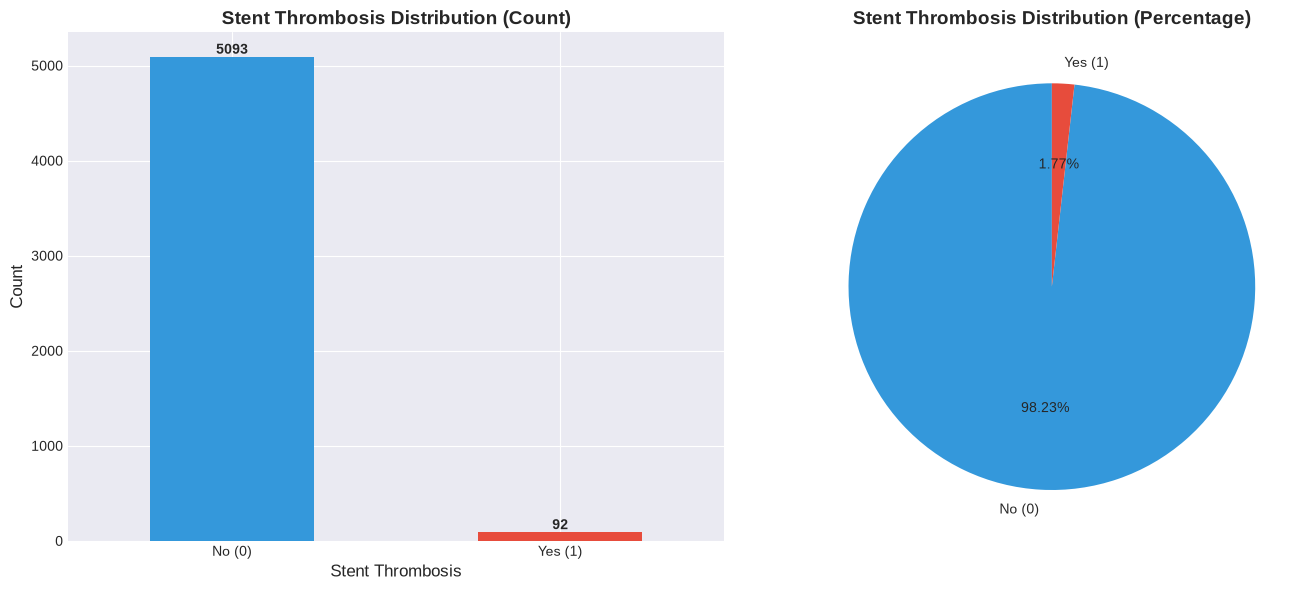

✓ Visualization saved: plots/01_target_distribution.png


In [329]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
target_counts.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title(
    "Stent Thrombosis Distribution (Count)", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Stent Thrombosis", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

# Pie chart
target_percent.plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#3498db", "#e74c3c"],
    labels=["No (0)", "Yes (1)"],
)
axes[1].set_title(
    "Stent Thrombosis Distribution (Percentage)", fontsize=14, fontweight="bold"
)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(
    "../data/result/eda/plots/01_target_distribution.png", dpi=300, bbox_inches="tight"
)
plt.show()
print("✓ Visualization saved: plots/01_target_distribution.png")

## 6. Feature Categorization

Before diving into detailed analysis, we need to categorize features into different types:

- **Binary Features**: Variables that take only 0/1 values (e.g., presence/absence indicators)
- **Continuous Features**: Numeric variables that can take any value in a range (e.g., age, lab values)
- **Categorical Features**: Text or nominal variables (e.g., stent type names)

This categorization helps us choose appropriate statistical tests and visualization methods for each feature type.


In [330]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from numeric for analysis
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# Binary columns (0/1)
binary_cols = []
for col in numeric_cols:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, np.nan}):
        binary_cols.append(col)

# Continuous numeric columns
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

print("=" * 80)
print("FEATURE CATEGORIZATION")
print("=" * 80)

print("\nFeature categories:")
print(f"  Total features: {len(df.columns) - 1} (excluding target)")
print(f"  Binary features: {len(binary_cols)}")
print(f"  Continuous features: {len(continuous_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

print("\n\nSample binary features (first 10):")
for i, col in enumerate(binary_cols[:10], 1):
    print(f"  {i:2d}. {col}")

print("\n\nSample continuous features (first 10):")
for i, col in enumerate(continuous_cols[:10], 1):
    print(f"  {i:2d}. {col}")

if categorical_cols:
    print("\n\nCategorical features:")
    for i, col in enumerate(categorical_cols, 1):
        print(f"  {i:2d}. {col}")

FEATURE CATEGORIZATION

Feature categories:
  Total features: 82 (excluding target)
  Binary features: 57
  Continuous features: 24
  Categorical features: 1


Sample binary features (first 10):
   1. Men
   2. Diabetes
   3. Hypertension
   4. HL
   5. Current smoker
   6. Current drinking
   7. Stroke/TIA
   8. History of peripheral vascualr disease
   9. Chronic renal insufficiency
  10. History of HF


Sample continuous features (first 10):
   1. Age
   2. Time since stent implantation
   3. NO.of vessels
   4. Min-stent diameter
   5. Max-stent diameter
   6. Total stent length
   7. Stent release pressure
   8. No.of stents per lesion
   9. LV
  10. LVEF


Categorical features:
   1. Stent type-SES


## 7. Univariate Analysis - Continuous Variables

Univariate analysis examines individual features in isolation. For continuous variables, we'll look at:

- **Central Tendency**: Mean, median, mode
- **Dispersion**: Standard deviation, range, quartiles
- **Distribution Shape**: Skewness, kurtosis
- **Outliers**: Values that deviate significantly from the norm

Understanding these characteristics helps identify:
- Features that need transformation (e.g., log transformation for skewed data)
- Potential data quality issues
- Features with unusual distributions


In [331]:
# Summary statistics for continuous variables
if len(continuous_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES")
    print("=" * 80)

    continuous_stats = df[continuous_cols].describe()
    print("\nSummary statistics for continuous variables:")
    display(continuous_stats.T.round(2))
else:
    print("No continuous variables found.")

UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES

Summary statistics for continuous variables:


,count,mean,std,min,25%,50%,75%,max
Age,5185.0,59.85,9.95,28.00,53.00,60.00,67.00,89.00
Time since stent implantation,5185.0,1409.96,140.30,380.00,1319.00,1416.00,1514.00,1605.00
NO.of vessels,5185.0,1.87,0.82,1.00,1.00,2.00,3.00,4.00
Min-stent diameter,5185.0,2.99,0.41,2.25,2.75,3.00,3.00,5.00
Max-stent diameter,5185.0,3.06,0.41,2.25,2.75,3.00,3.50,5.00
Total stent length,5185.0,31.82,15.75,8.00,21.00,28.00,36.00,144.00
Stent release pressure,5185.0,13.95,2.98,6.00,12.00,14.00,16.00,24.00
No.of stents per lesion,5185.0,1.22,0.46,1.00,1.00,1.00,1.00,4.00
LV,5185.0,44.63,4.09,37.00,42.00,44.00,46.00,73.00
LVEF,5185.0,55.14,4.50,22.00,53.00,55.00,58.00,68.00


In [332]:
# Outlier detection using IQR method
if len(continuous_cols) > 0:
    print("\n" + "-" * 80)
    print("OUTLIER DETECTION (IQR Method)")
    print("-" * 80)

    outlier_summary = []
    for col in continuous_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:  # Avoid division by zero
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_count = len(outliers)
            if outlier_count > 0:
                outlier_summary.append(
                    {
                        "Column": col,
                        "Outliers": outlier_count,
                        "Percentage": (outlier_count / len(df)) * 100,
                        "Lower Bound": lower_bound,
                        "Upper Bound": upper_bound,
                    }
                )

    if outlier_summary:
        outlier_df = pd.DataFrame(outlier_summary).sort_values(
            "Outliers", ascending=False
        )
        print("\nColumns with outliers (top 20):")
        display(outlier_df.head(20))
    else:
        print("✓ No outliers detected using IQR method")


--------------------------------------------------------------------------------
OUTLIER DETECTION (IQR Method)
--------------------------------------------------------------------------------

Columns with outliers (top 20):


,Column,Outliers,Percentage,Lower Bound,Upper Bound
2,Min-stent diameter,1348,25.998071,2.375,3.375
8,CaI,645,12.439730,-56.200,100.440
4,Total stent length,434,8.370299,-1.500,58.500
18,Fast-Glu,418,8.061716,1.620,10.820
6,LV,247,4.763742,36.000,52.000
7,LVEF,231,4.455159,45.500,65.500
12,Cre,194,3.741562,26.000,114.000
20,Fiberinogen,193,3.722276,1.240,4.920
19,HbA1c,159,3.066538,1.450,9.850
9,WBC,153,2.950820,0.135,16.415


## 8. Univariate Analysis - Binary Variables

For binary variables, we examine:
- **Prevalence**: What percentage of cases have the feature present (value = 1)?
- **Distribution**: Are the classes balanced or is one value much more common?

This helps identify:
- Rare features (very low or very high prevalence) that may have limited predictive power
- Features with balanced distributions that might be more informative


In [333]:
# Binary variable analysis
if len(binary_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - BINARY VARIABLES")
    print("=" * 80)

    binary_summary = []
    for col in binary_cols:
        positive_count = df[col].sum()
        positive_pct = (positive_count / len(df)) * 100
        binary_summary.append(
            {
                "Column": col,
                "Positive (1)": positive_count,
                "Negative (0)": len(df) - positive_count,
                "Percentage Positive": positive_pct,
            }
        )

    binary_df = pd.DataFrame(binary_summary).sort_values("Percentage Positive")
    print("\nBinary variable distribution (sorted by prevalence):")
    display(binary_df.head(20))

    print("\n...")
    print(f"\nTotal binary variables analyzed: {len(binary_df)}")

UNIVARIATE ANALYSIS - BINARY VARIABLES

Binary variable distribution (sorted by prevalence):


,Column,Positive (1),Negative (0),Percentage Positive
29,Aneurysm,28.0,5157.0,0.540019
31,Ulceration,39.0,5146.0,0.752170
43,No reflow,44.0,5141.0,0.848602
44,Dissection,53.0,5132.0,1.022179
30,Vessel dialation,59.0,5126.0,1.137898
24,Moderate/severe tortuosity,60.0,5125.0,1.157184
8,Chronic renal insufficiency,64.0,5121.0,1.234330
7,History of peripheral vascualr disease,88.0,5097.0,1.697203
55,Ticagrelor,91.0,5094.0,1.755063
11,Previous PCI,104.0,5081.0,2.005786



...

Total binary variables analyzed: 57


## 9. Bivariate Analysis - Correlations

Bivariate analysis examines relationships between features and the target variable. Correlation analysis helps us:

- **Identify Important Features**: Features with strong correlations are likely to be predictive
- **Understand Direction**: Positive correlation means feature increases with target, negative means it decreases
- **Detect Multicollinearity**: High correlations between features can indicate redundancy

We'll calculate Pearson correlation coefficients for numeric features with the target variable.


In [334]:
# Calculate correlations with target
if TARGET_COL in df.columns:
    correlations = (
        df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)
    )
    correlations = correlations[correlations.index != TARGET_COL]

    print("=" * 80)
    print("BIVARIATE ANALYSIS - CORRELATIONS")
    print("=" * 80)

    print("\nTop 20 features most correlated with Stent thrombosis:")
    print(correlations.head(20).to_string())

    print("\n\nBottom 20 features least correlated with Stent thrombosis:")
    print(correlations.tail(20).to_string())

    # Strong correlations (absolute value > 0.3)
    strong_corr = correlations[abs(correlations) > 0.3]
    if len(strong_corr) > 0:
        print(f"\n✓ Found {len(strong_corr)} features with |correlation| > 0.3:")
        print(strong_corr.to_string())
    else:
        print("\n⚠ No features found with |correlation| > 0.3")

BIVARIATE ANALYSIS - CORRELATIONS

Top 20 features most correlated with Stent thrombosis:
WBC                        0.150203
LV                         0.147245
No postdilation            0.089266
Previous PCI               0.084973
CKD90                      0.062602
No.of stents per lesion    0.060360
Total stent length         0.056651
Fast-Glu                   0.053844
3-vessel disease           0.052003
NO.of vessels              0.051149
CKD5                       0.048615
Diabetes                   0.041555
PES                        0.039530
HbA1c                      0.038787
Multi-vessel CAD           0.038040
stent overlap              0.034669
TIMI-0                     0.033180
LDL                        0.029883
Stroke/TIA                 0.029607
Fiberinogen                0.029211


Bottom 20 features least correlated with Stent thrombosis:
Visual thrombus                 -0.002793
HL                              -0.003454
History of HF                   -0.003924
P-L

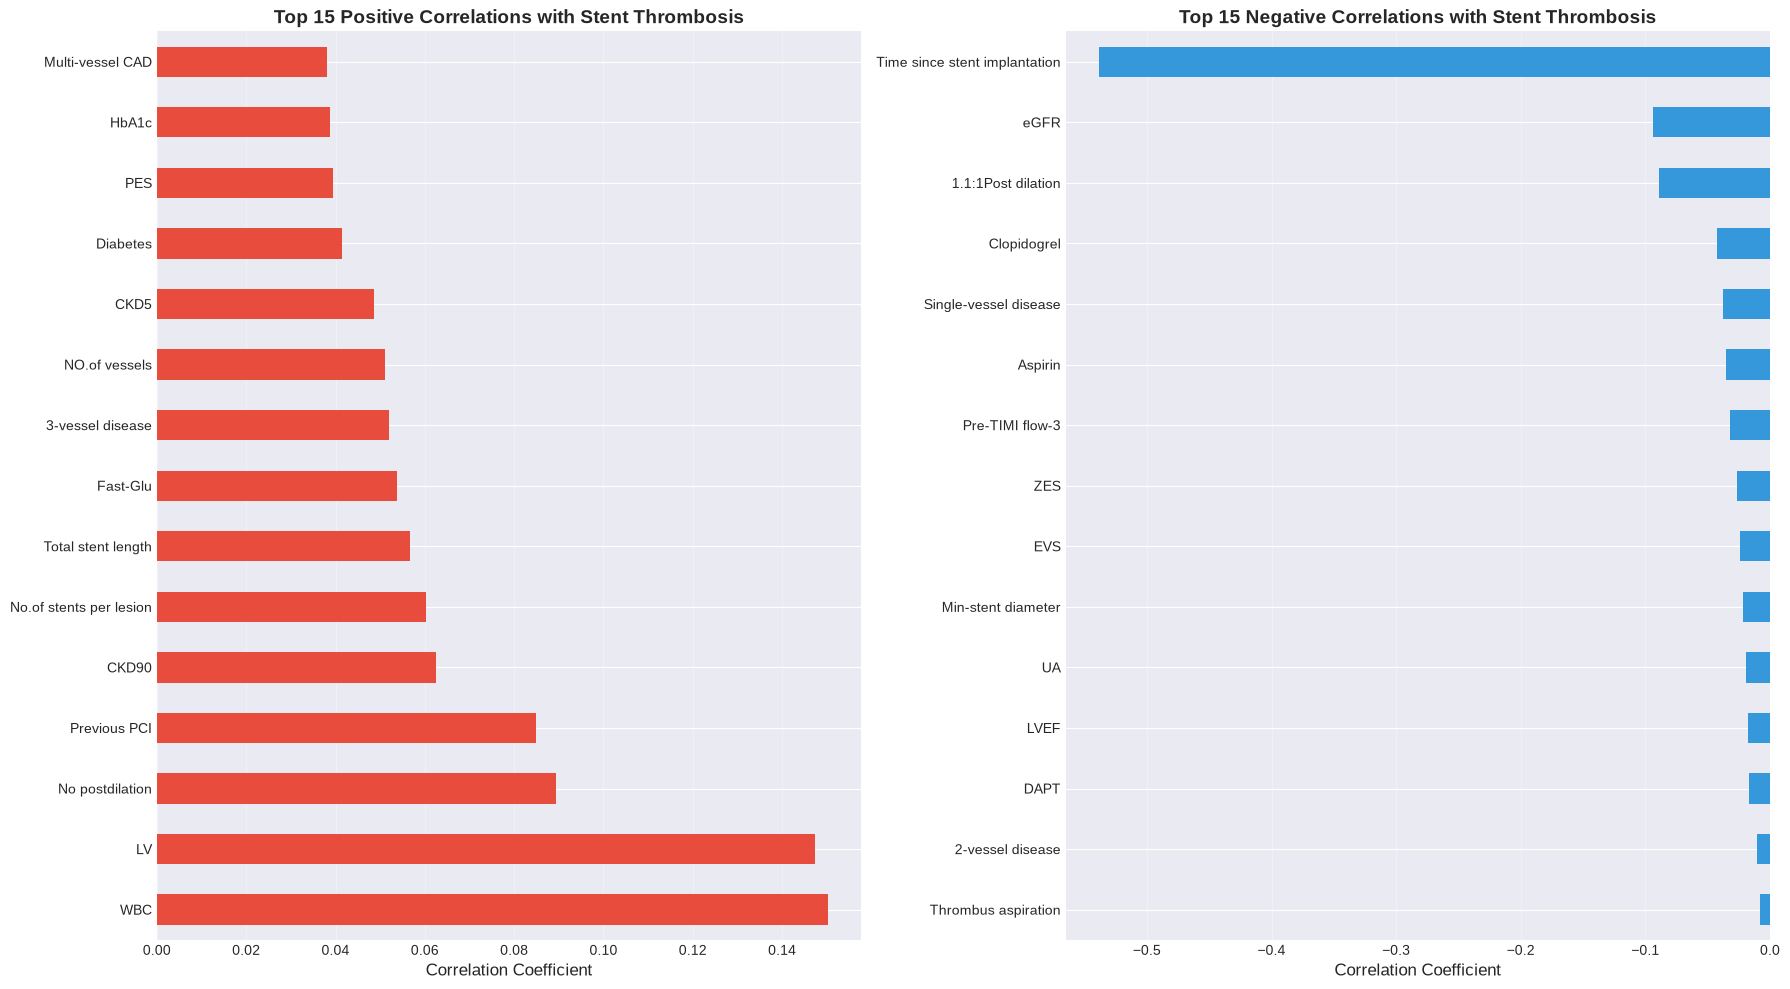

✓ Visualization saved: plots/07_top_correlations.png


In [335]:
# Visualize top correlations
if TARGET_COL in df.columns and len(correlations) > 0:
    top_pos = correlations.head(15)
    top_neg = correlations.tail(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Positive correlations
    top_pos.plot(kind="barh", ax=axes[0], color="#e74c3c")
    axes[0].set_title(
        "Top 15 Positive Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Correlation Coefficient", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")

    # Negative correlations
    top_neg.plot(kind="barh", ax=axes[1], color="#3498db")
    axes[1].set_title(
        "Top 15 Negative Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Correlation Coefficient", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/07_top_correlations.png", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("✓ Visualization saved: plots/07_top_correlations.png")

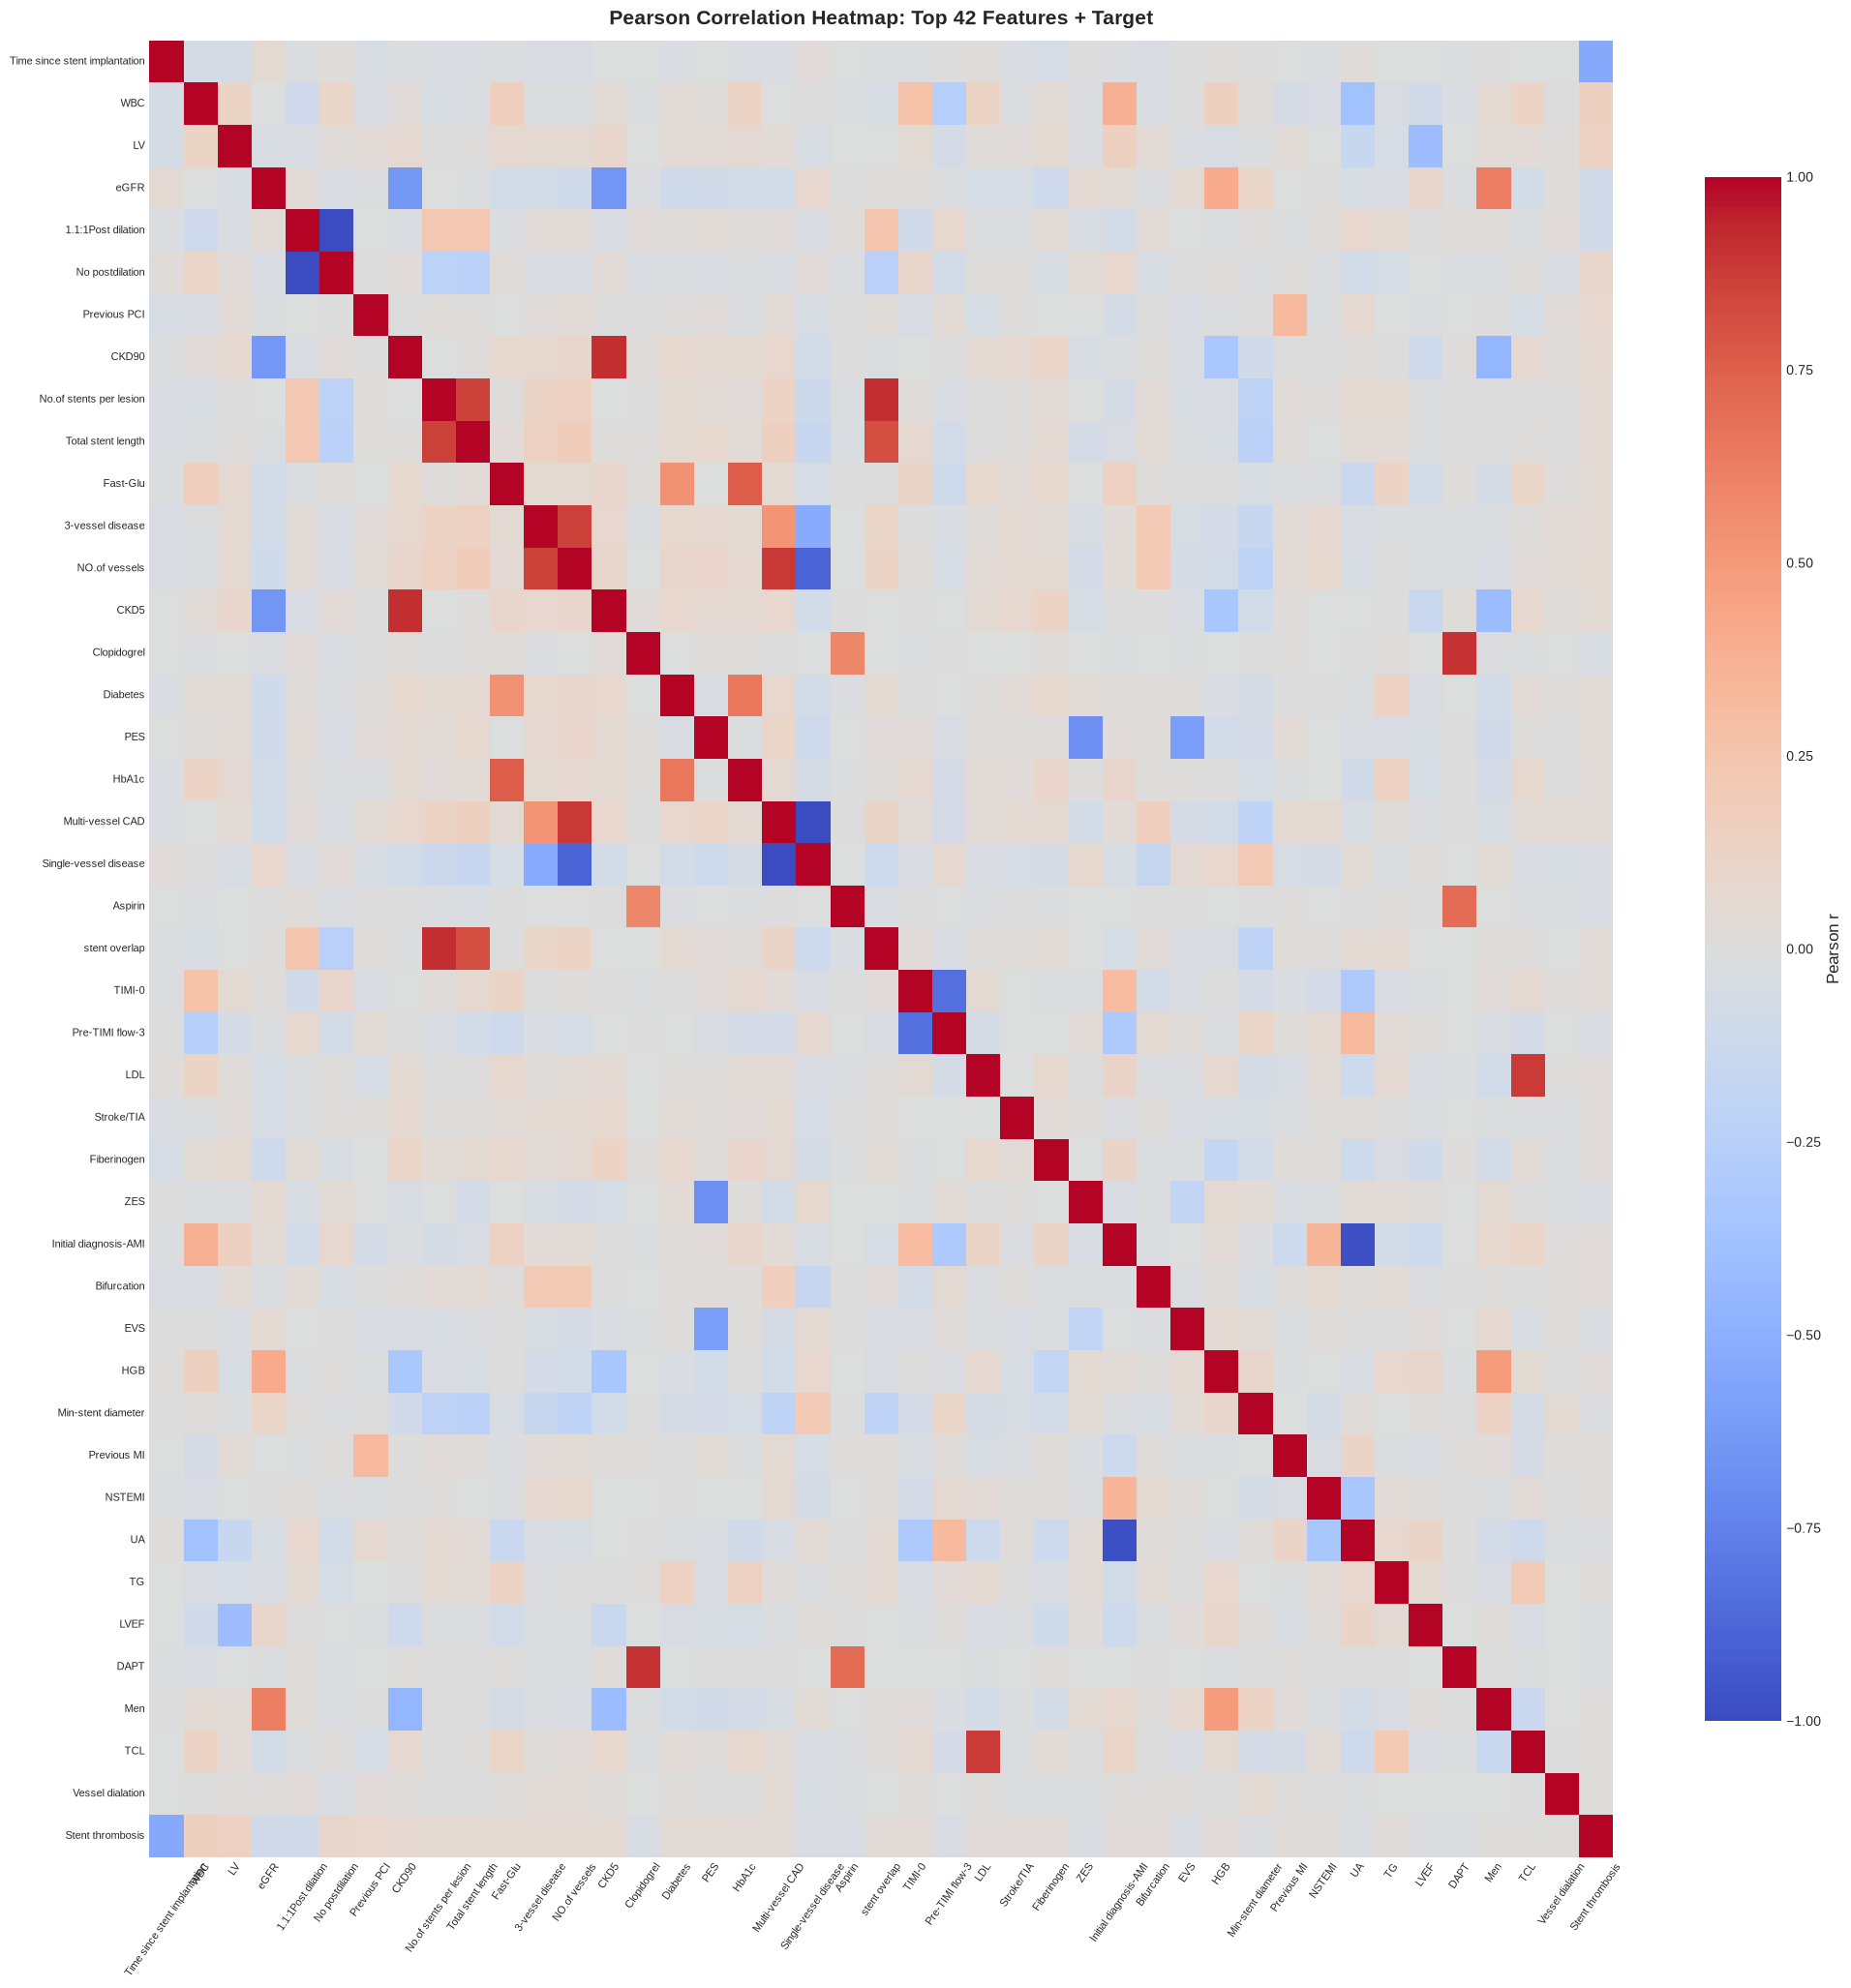

✓ Visualization saved: 03_correlation_heatmap_top42_target.png (43×43)


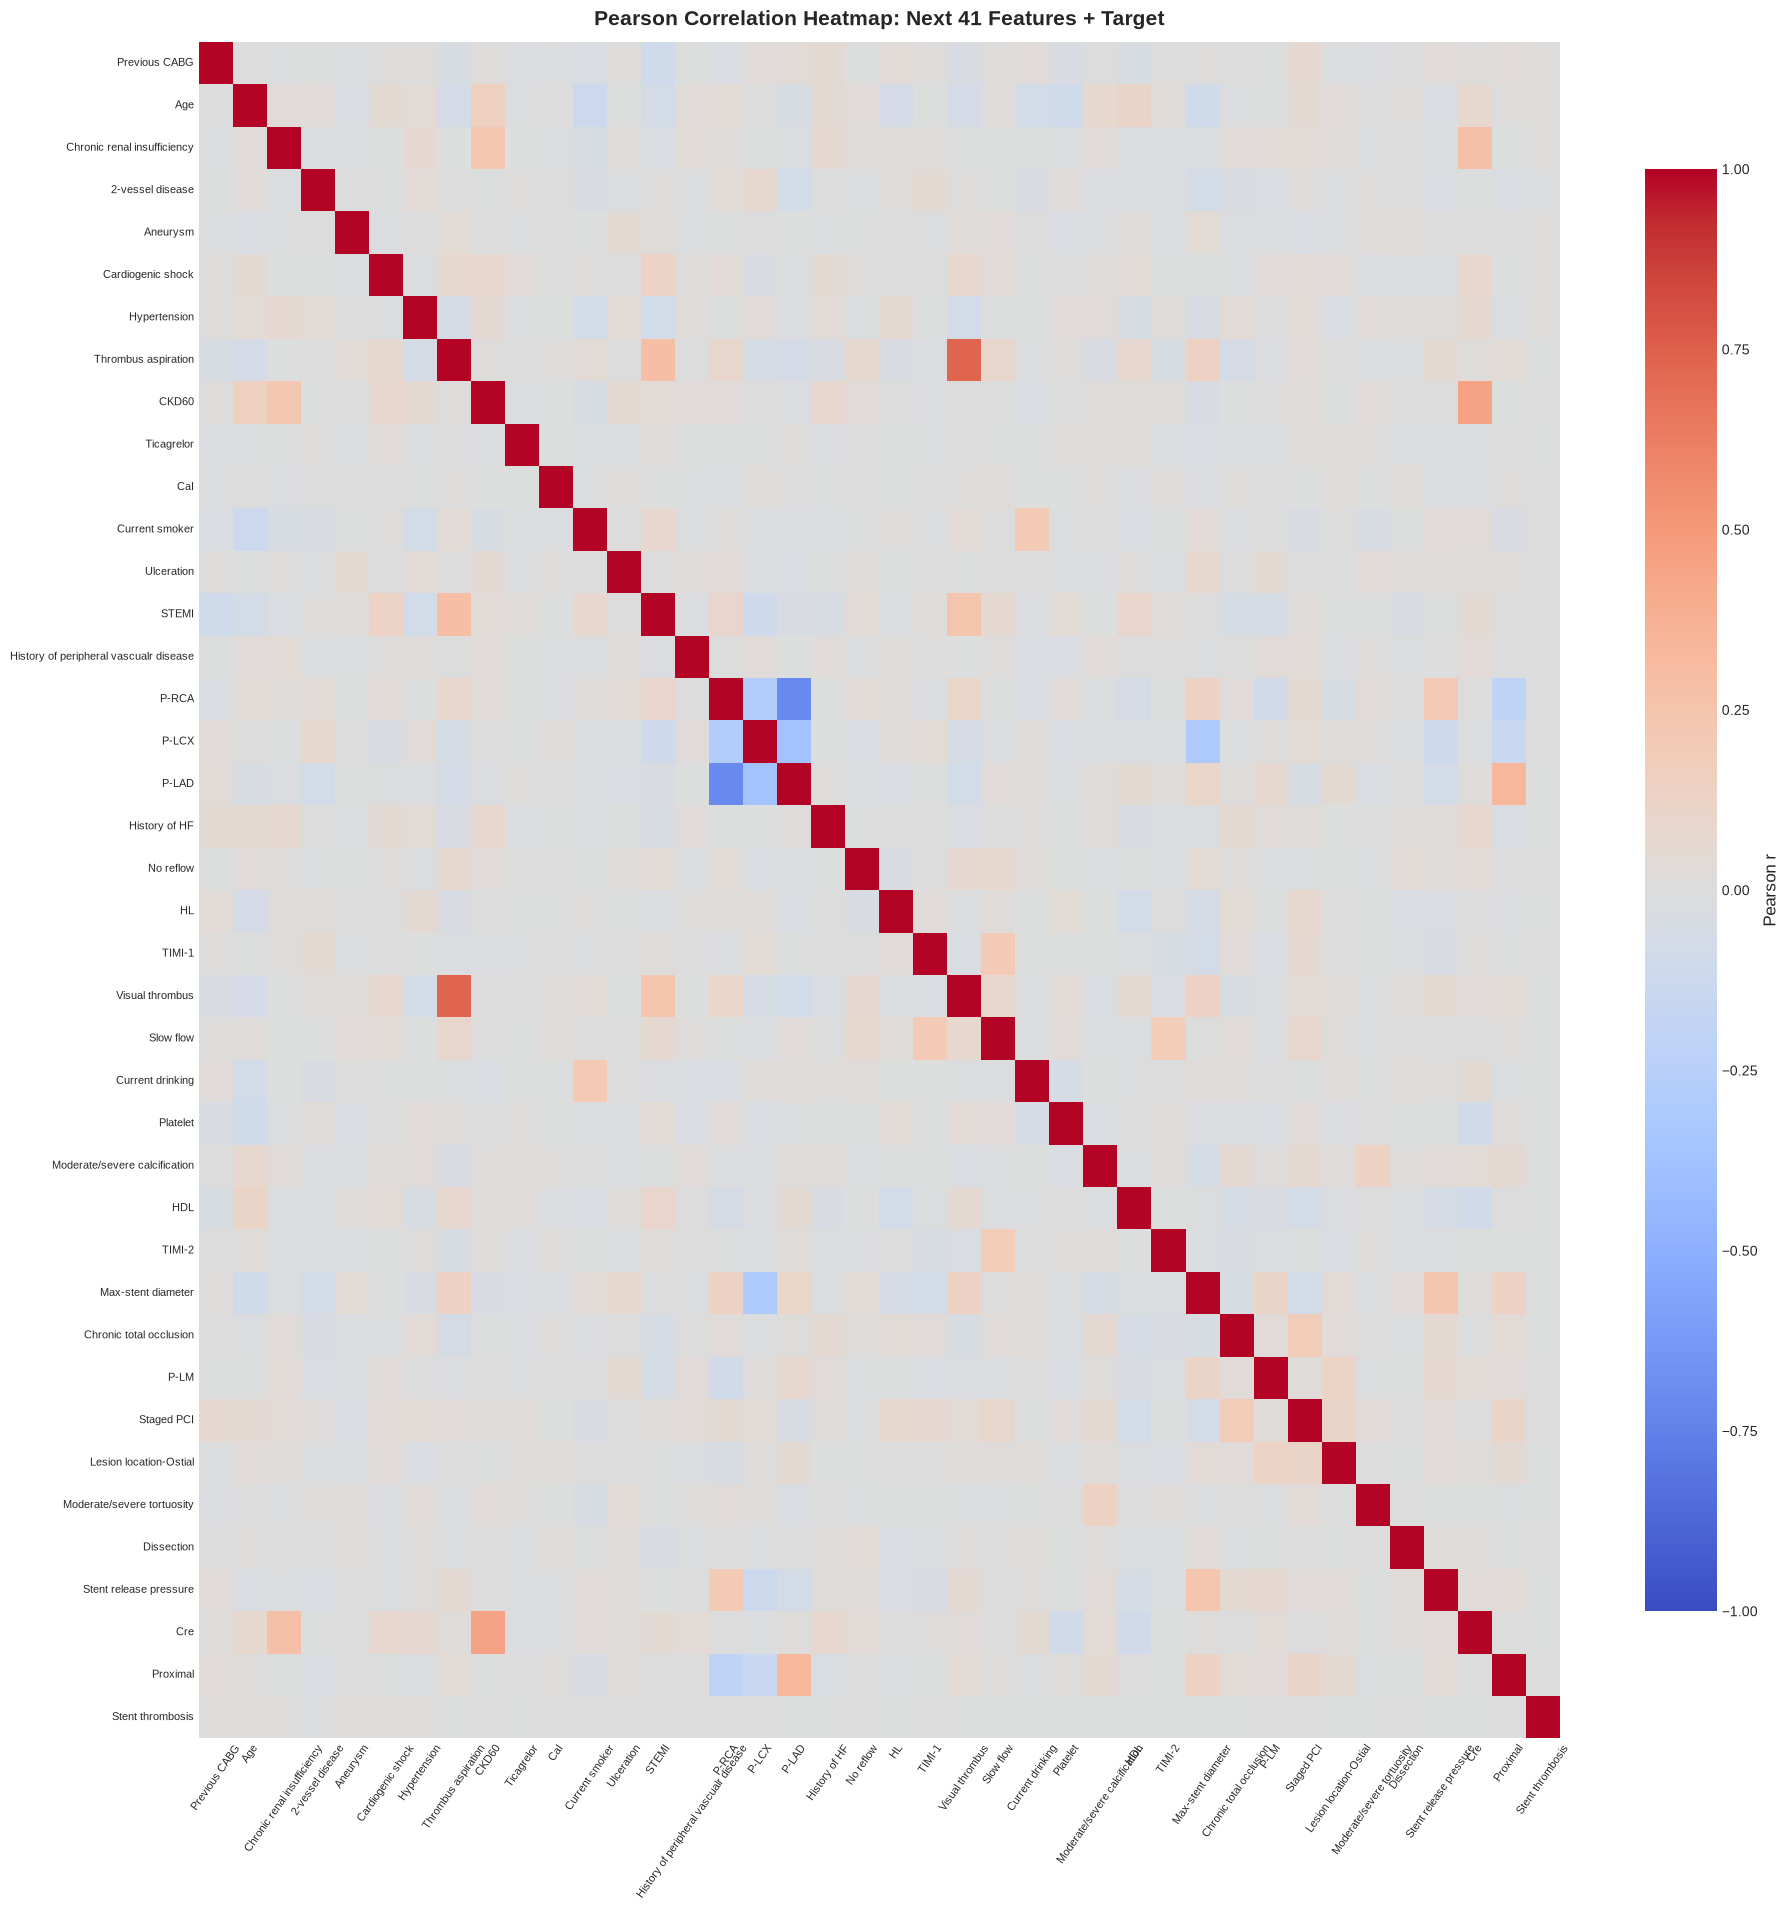

✓ Visualization saved: 03_correlation_heatmap_next41_target.png (40×40)


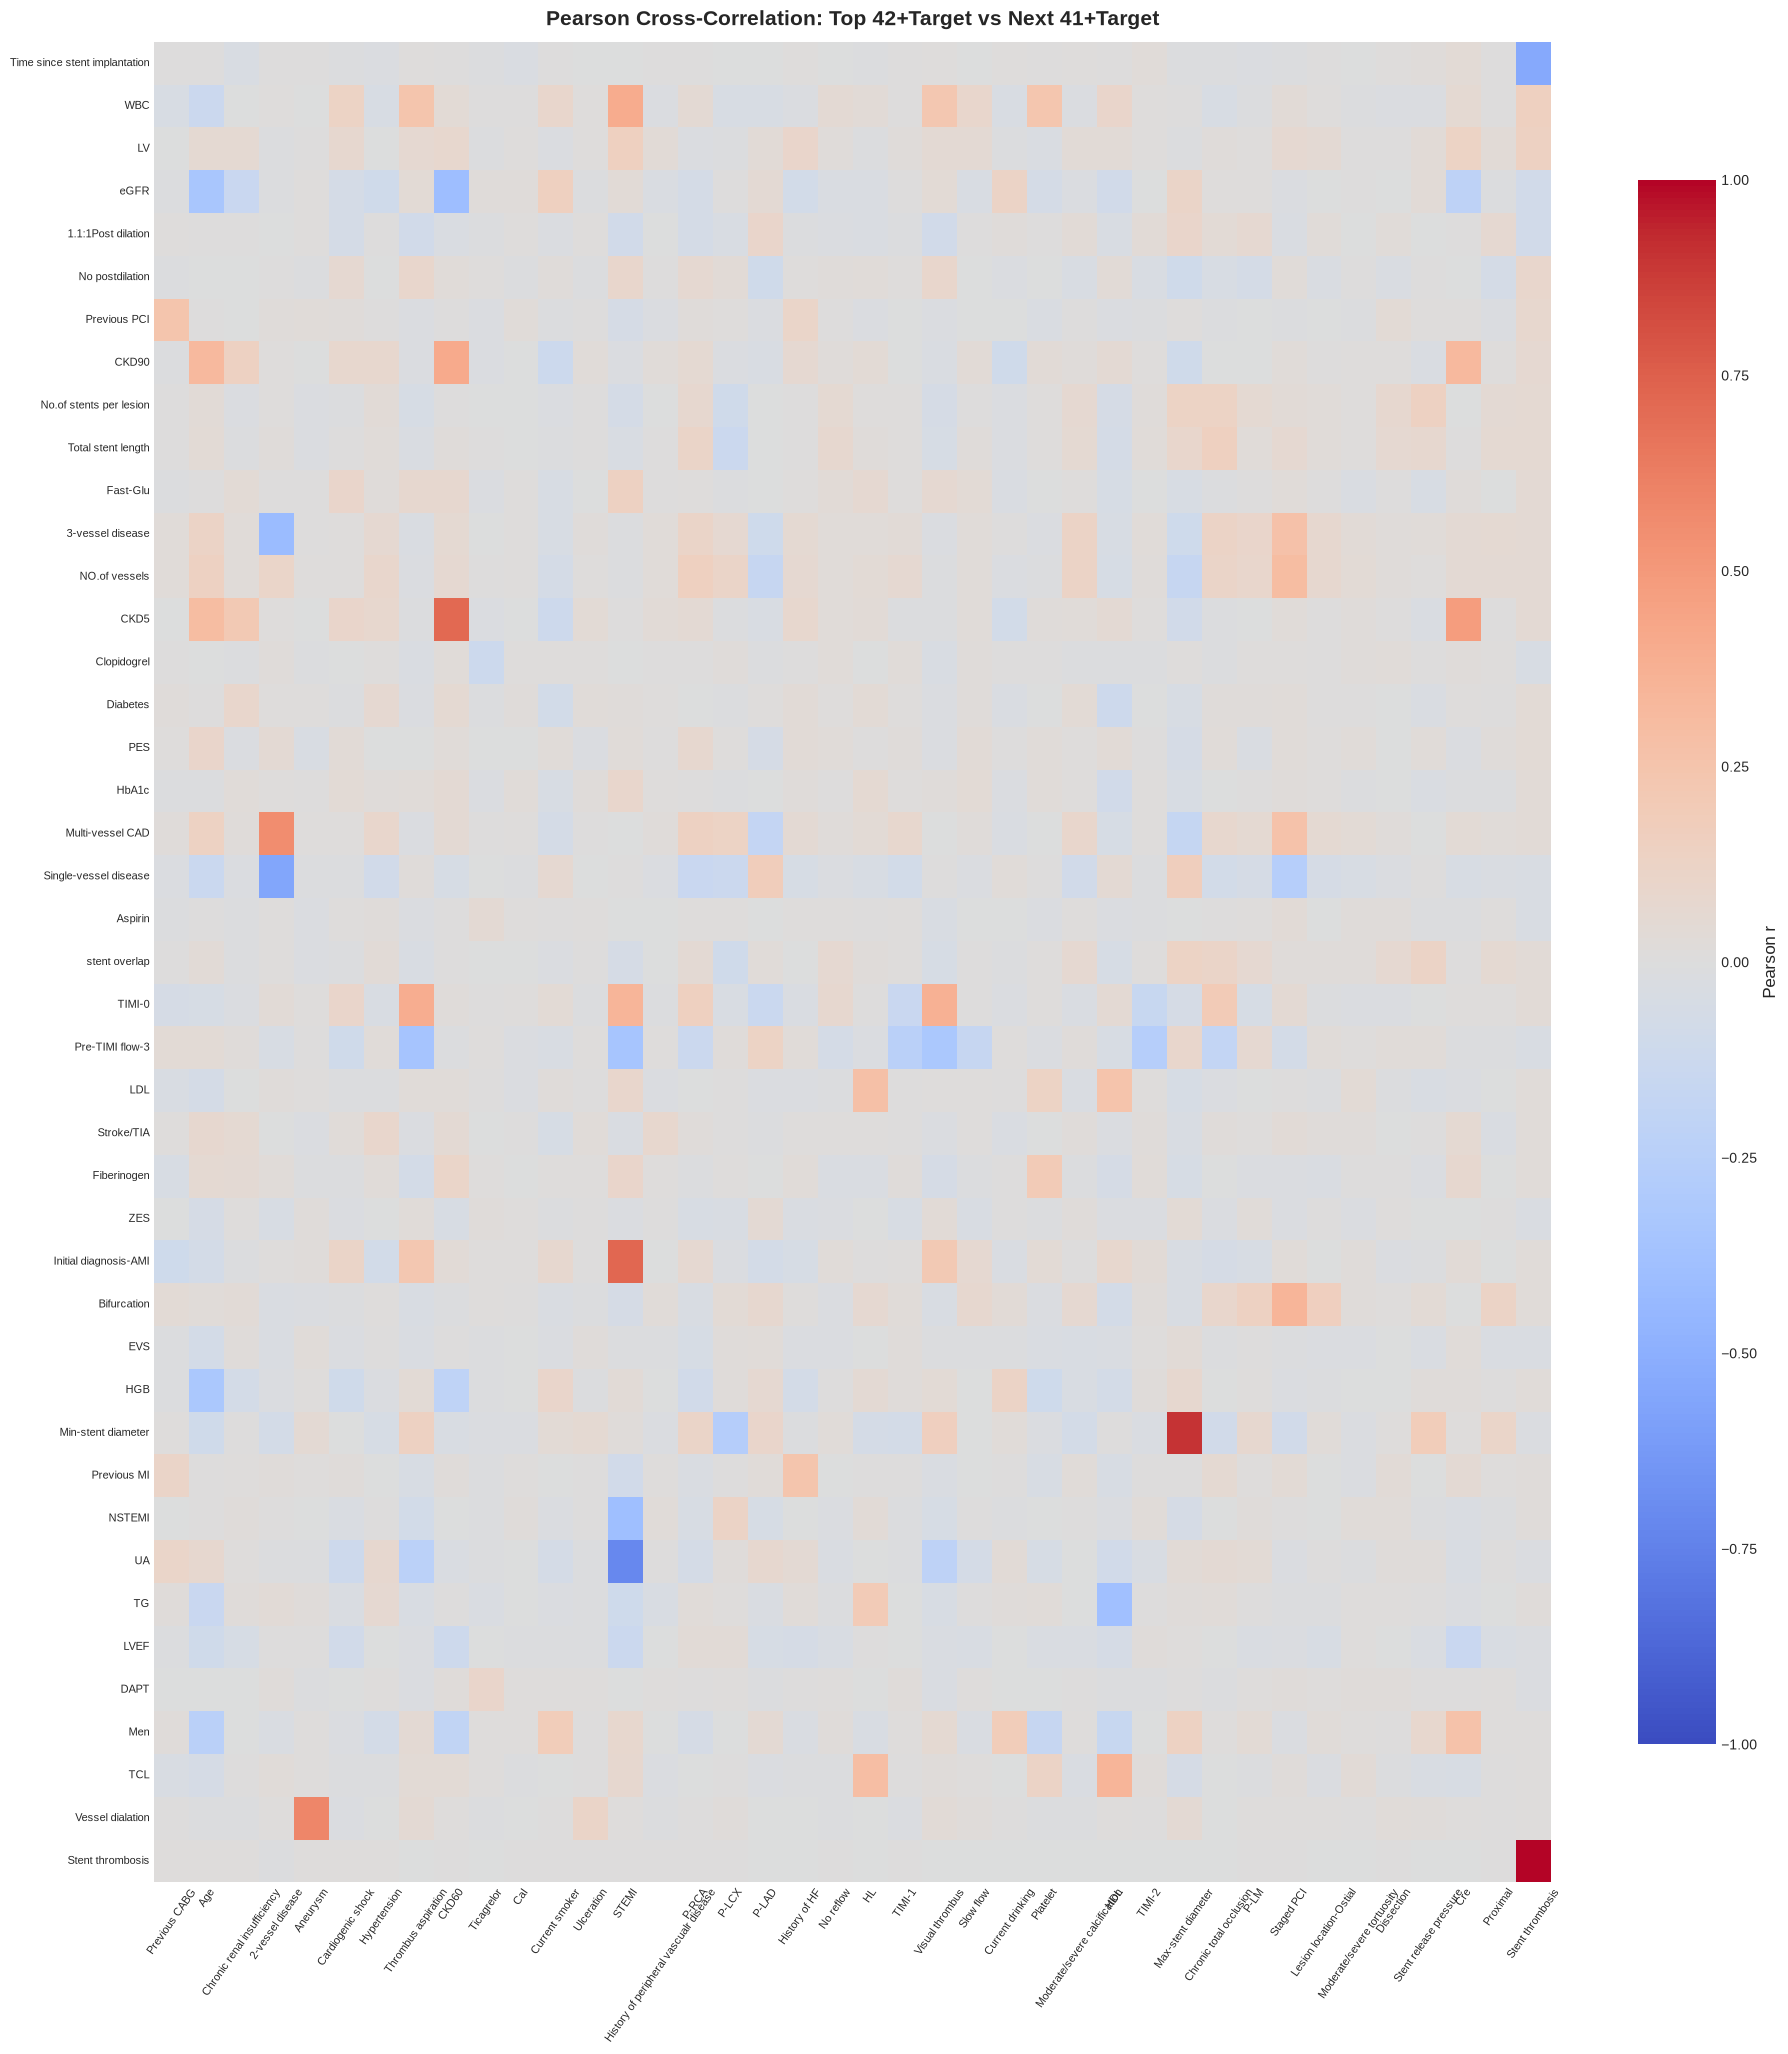

✓ Visualization saved: 03_correlation_heatmap_top42_vs_next41_with_target.png (43×40)


In [336]:
# Clean Pearson correlation heatmaps (top 42 / next 41 blocks)
TOP_N = 42
NEXT_N = 41

if len(continuous_cols) > 0:
    top_corr_features = correlations.abs().nlargest(TOP_N).index.tolist()
    next_corr_features = (
        correlations.abs().drop(top_corr_features, errors="ignore").nlargest(NEXT_N).index.tolist()
    )
    next_corr_features = [f for f in next_corr_features if f not in set(top_corr_features)]

    def _heatmap_figsize(n_rows, n_cols):
        # ~0.48 inches per label keeps ~40x40 matrices readable at 300 dpi
        return (max(18, n_cols * 0.48), max(18, n_rows * 0.48))

    def plot_corr_heatmap(corr_data, title, out_path, figsize=None):
        if figsize is None:
            figsize = _heatmap_figsize(*corr_data.shape)
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(
            corr_data,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0,
            cbar_kws={"shrink": 0.85, "label": "Pearson r"},
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
        ax.tick_params(axis="x", labelrotation=55, labelsize=8)
        ax.tick_params(axis="y", labelrotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_path.split('/')[-1]} ({corr_data.shape[0]}×{corr_data.shape[1]})")

    def features_with_target(feature_list):
        """Append target once (avoid duplicate Stent thrombosis labels)."""
        return list(dict.fromkeys(list(feature_list) + [TARGET_COL]))

    def block_corr_matrix(row_features, col_features, method=None):
        """Build cross-block correlation without duplicate target columns."""
        row_labels = features_with_target(row_features)
        col_labels = features_with_target(col_features)
        all_unique = list(dict.fromkeys(row_labels + col_labels))
        corr_kwargs = {"method": method} if method else {}
        full_corr = df[all_unique].corr(**corr_kwargs)
        return full_corr.loc[row_labels, col_labels]

    top_with_target = features_with_target(top_corr_features)
    next_with_target = features_with_target(next_corr_features)

    # 1) Top 42 features + target (43×43)
    corr_top42_target = block_corr_matrix(top_corr_features, top_corr_features)
    plot_corr_heatmap(
        corr_top42_target,
        f"Pearson Correlation Heatmap: Top {TOP_N} Features + Target",
        "../data/result/eda/plots/03_correlation_heatmap_top42_target.png",
    )

    # 2) Next 41 features + target (42×42)
    if len(next_corr_features) > 0:
        corr_next41_target = block_corr_matrix(next_corr_features, next_corr_features)
        plot_corr_heatmap(
            corr_next41_target,
            f"Pearson Correlation Heatmap: Next {NEXT_N} Features + Target",
            "../data/result/eda/plots/03_correlation_heatmap_next41_target.png",
        )

        # 3) Cross block: top 42 + target vs next 41 + target
        top_next_cross = block_corr_matrix(top_corr_features, next_corr_features)
        plot_corr_heatmap(
            top_next_cross,
            f"Pearson Cross-Correlation: Top {TOP_N}+Target vs Next {NEXT_N}+Target",
            "../data/result/eda/plots/03_correlation_heatmap_top42_vs_next41_with_target.png",
        )


## 9b. Spearman Correlation Check (Robustness)

Pearson captures **linear** relationships, while Spearman captures **monotonic rank-based** relationships and is more robust to outliers and non-normality.

In this section, we compute Spearman correlations with the target and compare them to Pearson results from Section 9 to decide which metric is more appropriate for this dataset.

In [337]:
# Spearman correlations with target (robust alternative to Pearson)
SPEARMAN_DATA_PATH = "/home/fadia/Documents/vlst/data/raw/VLST.csv"

# Use existing dataframe if available; otherwise load from provided path
if "df" not in locals() or df is None or len(df) == 0:
    df = pd.read_csv(SPEARMAN_DATA_PATH)
    print(f"Loaded data from: {SPEARMAN_DATA_PATH}")

# Ensure numeric columns list exists
if "numeric_cols" not in locals() or numeric_cols is None or len(numeric_cols) == 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in df.columns:
    # Spearman with target
    spearman_correlations = (
        df[numeric_cols + [TARGET_COL]]
        .corr(method="spearman")[TARGET_COL]
        .sort_values(ascending=False)
    )
    spearman_correlations = spearman_correlations[spearman_correlations.index != TARGET_COL]

    # Pearson from previous section (fallback compute if needed)
    if "correlations" not in locals() or correlations is None or len(correlations) == 0:
        correlations = (
            df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)
        )
        correlations = correlations[correlations.index != TARGET_COL]

    # Align and compare
    common_features = correlations.index.intersection(spearman_correlations.index)
    comparison_df = pd.DataFrame(
        {
            "Feature": common_features,
            "Pearson": correlations.loc[common_features].values,
            "Spearman": spearman_correlations.loc[common_features].values,
        }
    )
    comparison_df["Abs_Diff"] = (
        comparison_df["Pearson"].abs() - comparison_df["Spearman"].abs()
    ).abs()

    # Save comparison
    comparison_df.sort_values("Abs_Diff", ascending=False).to_csv(
        "../data/result/eda/plots/pearson_vs_spearman_comparison.csv", index=False
    )

    print("=" * 80)
    print("PEARSON vs SPEARMAN CORRELATION COMPARISON")
    print("=" * 80)
    print(f"Compared features: {len(comparison_df)}")
    print(
        f"Mean |difference| in absolute correlation: {comparison_df['Abs_Diff'].mean():.4f}"
    )

    # Top overlap by absolute importance
    top_k = 10
    top_pearson = set(correlations.abs().nlargest(top_k).index)
    top_spearman = set(spearman_correlations.abs().nlargest(top_k).index)
    overlap = len(top_pearson.intersection(top_spearman))

    print(
        f"Top-{top_k} overlap (by absolute correlation): {overlap}/{top_k} ({overlap/top_k:.0%})"
    )

    print("\nTop 10 Pearson (abs):")
    print(correlations.abs().nlargest(10).to_string())

    print("\nTop 10 Spearman (abs):")
    print(spearman_correlations.abs().nlargest(10).to_string())

    print("\nTop 20 features with largest Pearson-Spearman differences:")
    display(comparison_df.sort_values("Abs_Diff", ascending=False).head(20))

    print("\n✓ Saved: plots/pearson_vs_spearman_comparison.csv")
else:
    print(f"Target column '{TARGET_COL}' not found in dataframe.")

PEARSON vs SPEARMAN CORRELATION COMPARISON
Compared features: 81
Mean |difference| in absolute correlation: 0.0069
Top-10 overlap (by absolute correlation): 9/10 (90%)

Top 10 Pearson (abs):
Time since stent implantation    0.538354
WBC                              0.150203
LV                               0.147245
eGFR                             0.093657
1.1:1Post dilation               0.089266
No postdilation                  0.089266
Previous PCI                     0.084973
CKD90                            0.062602
No.of stents per lesion          0.060360
Total stent length               0.056651

Top 10 Spearman (abs):
Time since stent implantation    0.170127
LV                               0.139046
WBC                              0.130014
eGFR                             0.096342
No postdilation                  0.089266
1.1:1Post dilation               0.089266
Previous PCI                     0.084973
CKD90                            0.062602
CKD5                         

,Feature,Pearson,Spearman,Abs_Diff
80,Time since stent implantation,-0.538354,-0.170127,0.368226
7,Fast-Glu,0.053844,0.031221,0.022623
36,CaI,0.006773,-0.027138,0.020365
0,WBC,0.150203,0.130014,0.020189
17,LDL,0.029883,0.013602,0.016281
13,HbA1c,0.038787,0.051698,0.012910
10,CKD5,0.048615,0.060835,0.012220
69,LVEF,-0.017584,-0.029562,0.011978
6,Total stent length,0.056651,0.045250,0.011401
27,TCL,0.015198,0.004309,0.010889



✓ Saved: plots/pearson_vs_spearman_comparison.csv


In [338]:
# Recommendation: which correlation test to prioritize for this dataset
if "comparison_df" in locals() and len(comparison_df) > 0:
    agreement_ratio = (comparison_df["Abs_Diff"] < 0.05).mean()

    # Compare strength counts
    pearson_strong = (comparison_df["Pearson"].abs() >= 0.1).sum()
    spearman_strong = (comparison_df["Spearman"].abs() >= 0.1).sum()

    print("\n" + "=" * 80)
    print("RECOMMENDATION: PEARSON OR SPEARMAN?")
    print("=" * 80)
    print(f"Agreement ratio (|abs(Pearson)-abs(Spearman)| < 0.05): {agreement_ratio:.1%}")
    print(f"Features with |corr| >= 0.10 -> Pearson: {pearson_strong}, Spearman: {spearman_strong}")

    if agreement_ratio >= 0.80:
        print("\nRecommendation:")
        print(
            "✓ Pearson and Spearman are highly consistent on this dataset. "
            "Use Pearson for primary reporting (easier interpretation of linear effect size), "
            "and keep Spearman as a robustness/sensitivity check."
        )
    elif spearman_strong > pearson_strong:
        print("\nRecommendation:")
        print(
            "⚠ Spearman appears more informative than Pearson for several features. "
            "Prioritize Spearman in EDA summaries because relationships are likely monotonic/non-linear "
            "or influenced by outliers."
        )
    else:
        print("\nRecommendation:")
        print(
            "⚠ Pearson and Spearman differ meaningfully. Report both, "
            "but prioritize interpretation based on model family: Pearson for linear assumptions, "
            "Spearman for robust rank-based screening."
        )
else:
    print("Run the Spearman comparison cell first to generate recommendation metrics.")


RECOMMENDATION: PEARSON OR SPEARMAN?
Agreement ratio (|abs(Pearson)-abs(Spearman)| < 0.05): 98.8%
Features with |corr| >= 0.10 -> Pearson: 3, Spearman: 3

Recommendation:
✓ Pearson and Spearman are highly consistent on this dataset. Use Pearson for primary reporting (easier interpretation of linear effect size), and keep Spearman as a robustness/sensitivity check.


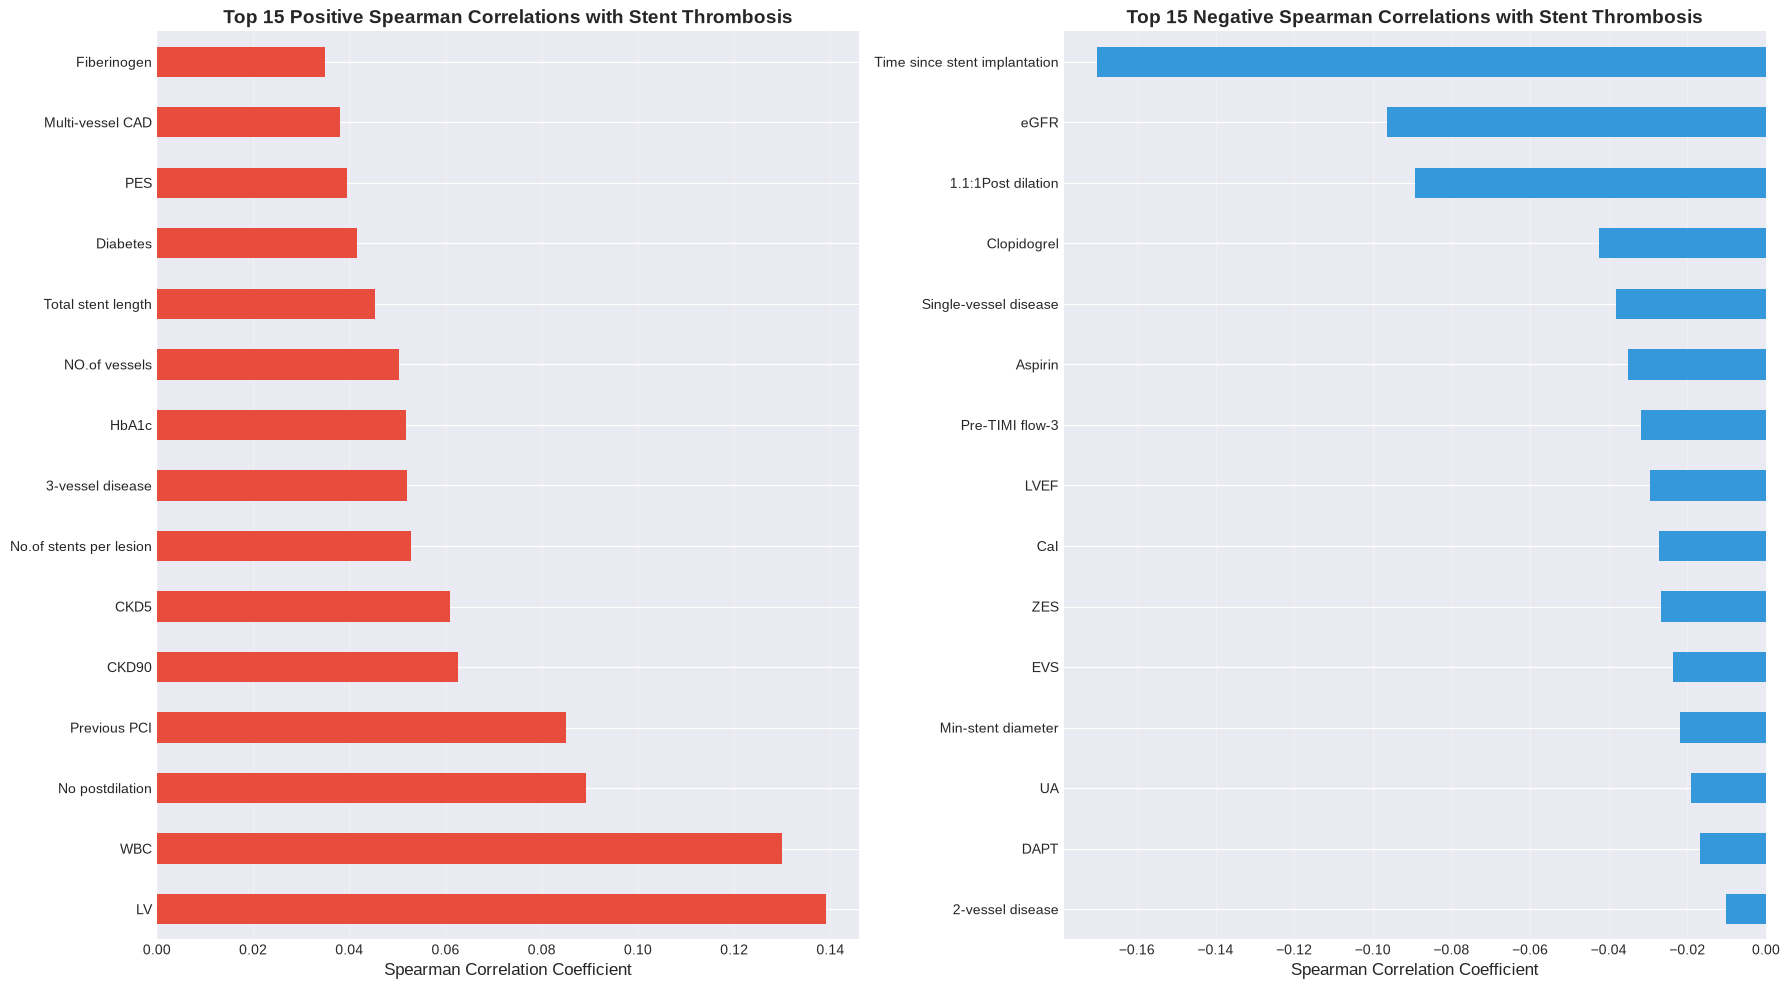

✓ Visualization saved: plots/07b_top_spearman_correlations.png


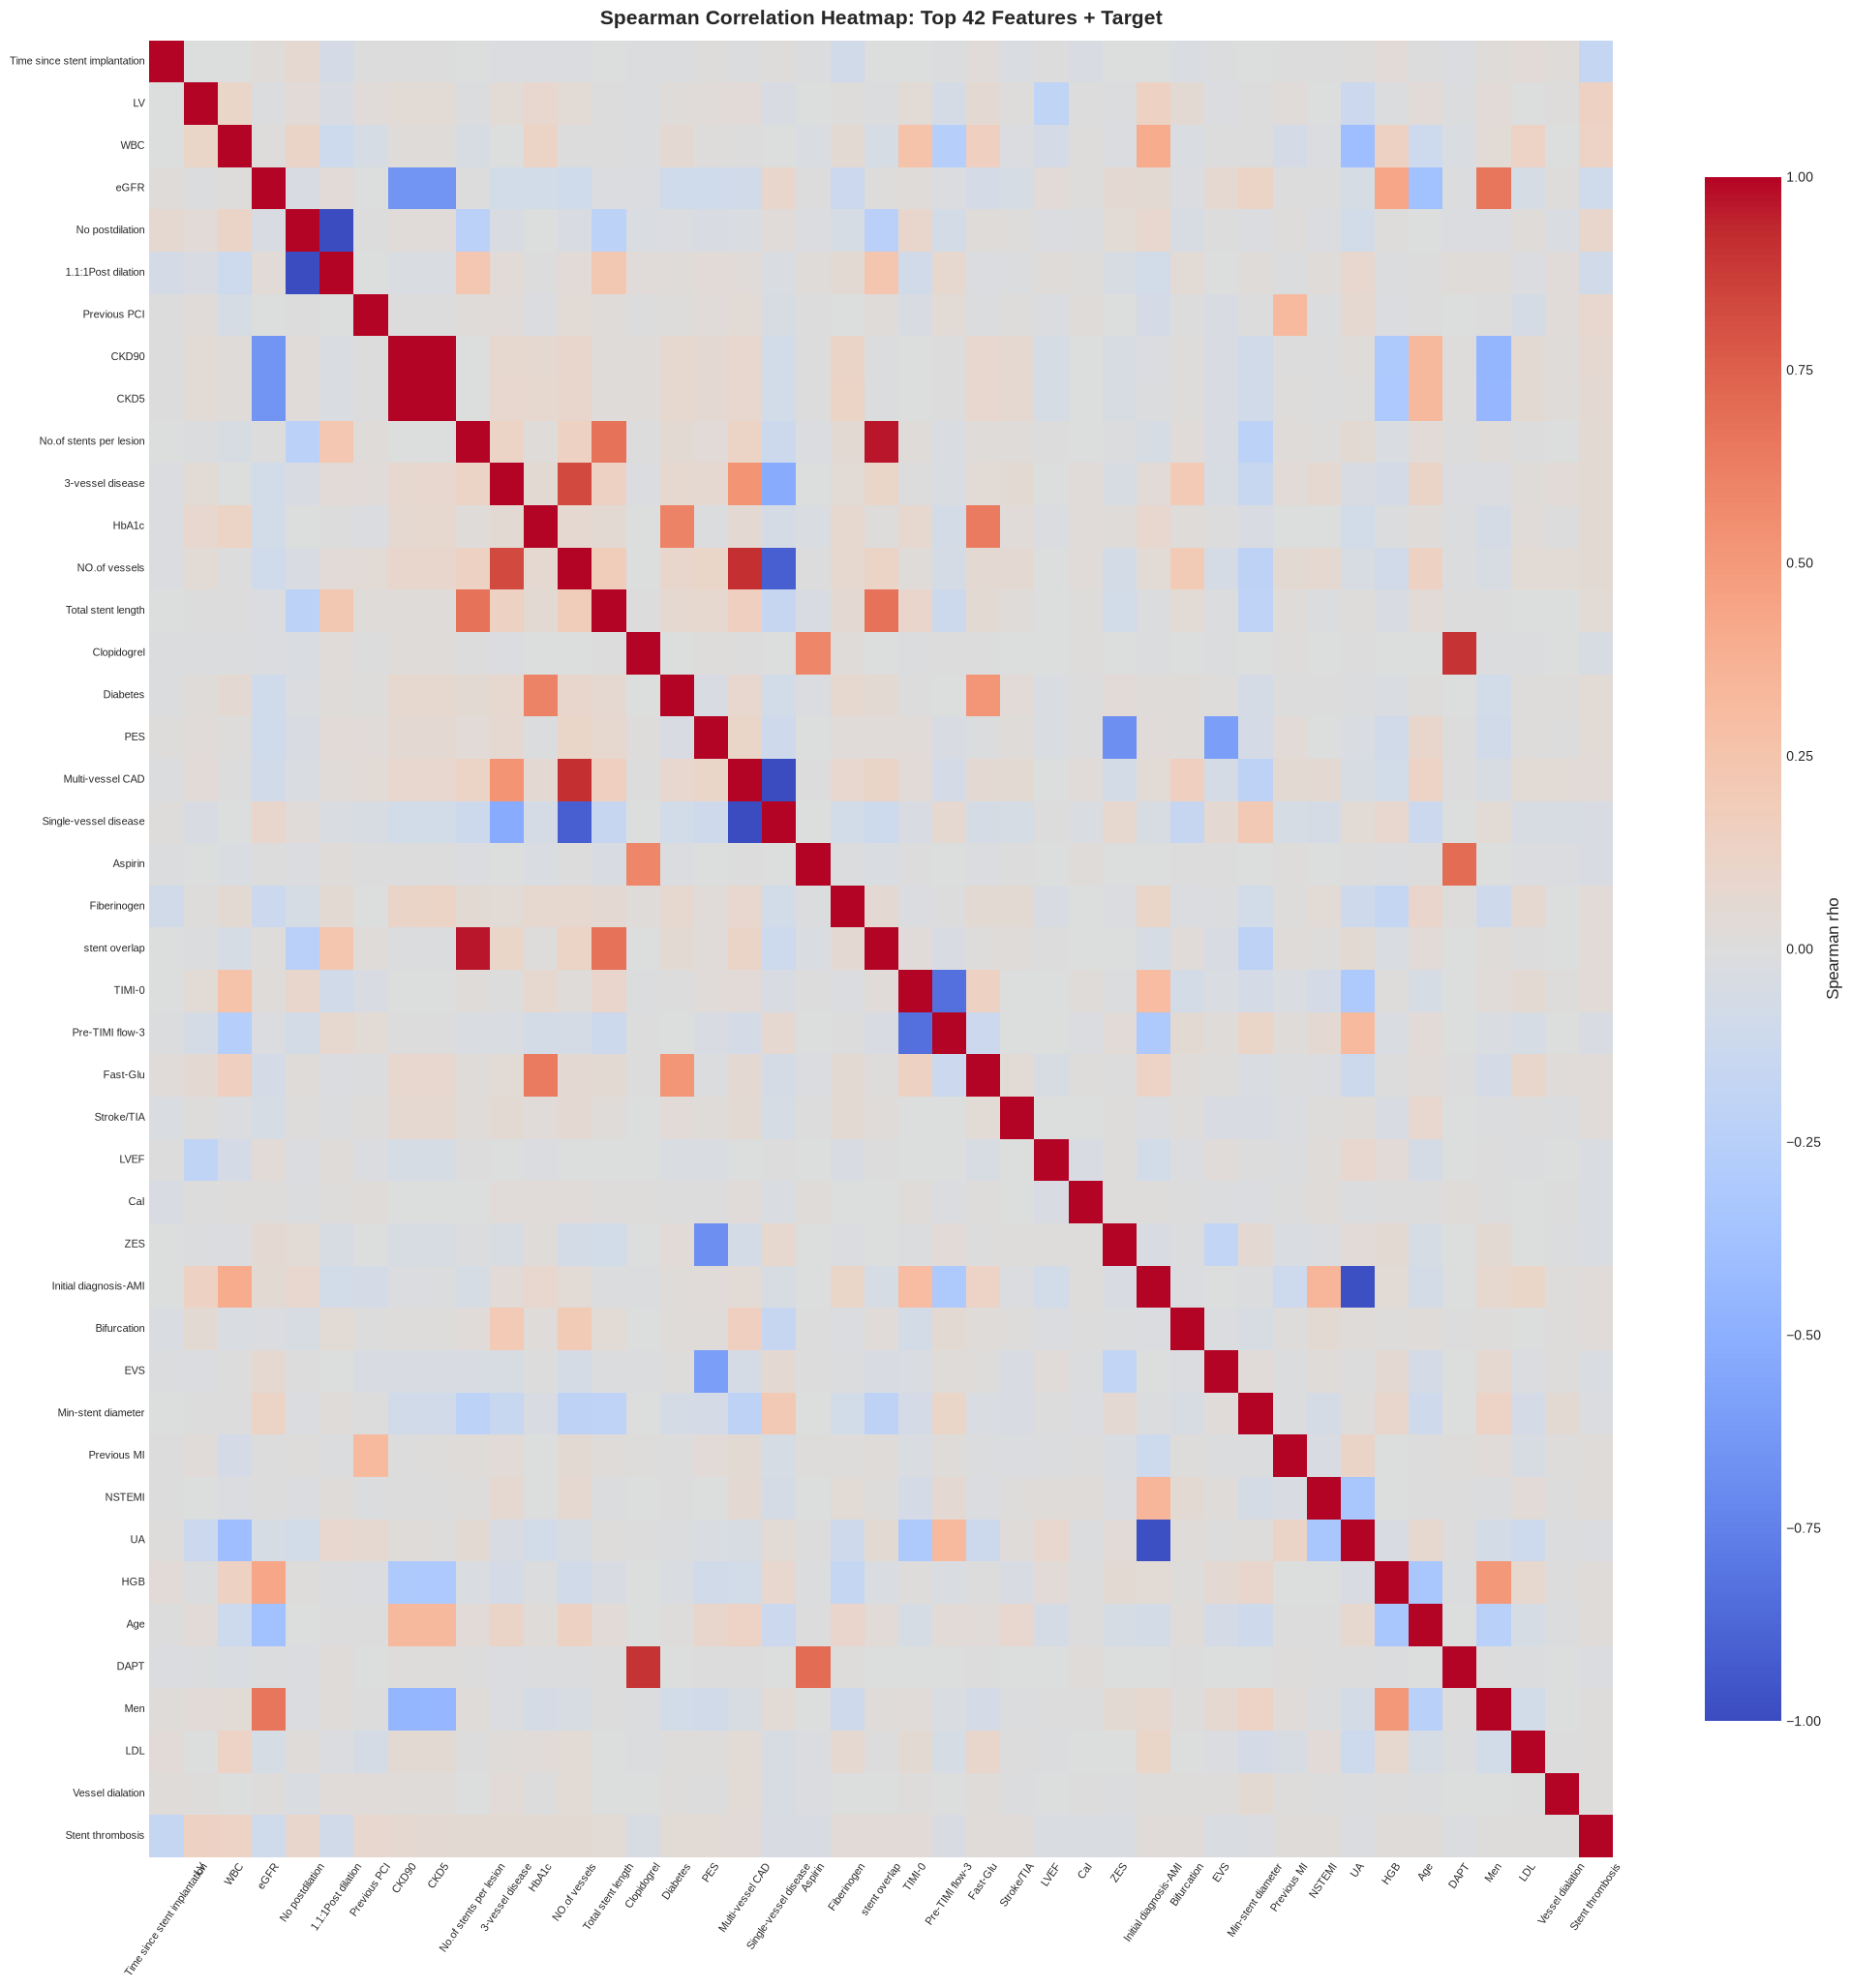

✓ Visualization saved: 03b_spearman_correlation_heatmap_top42_target.png (43×43)


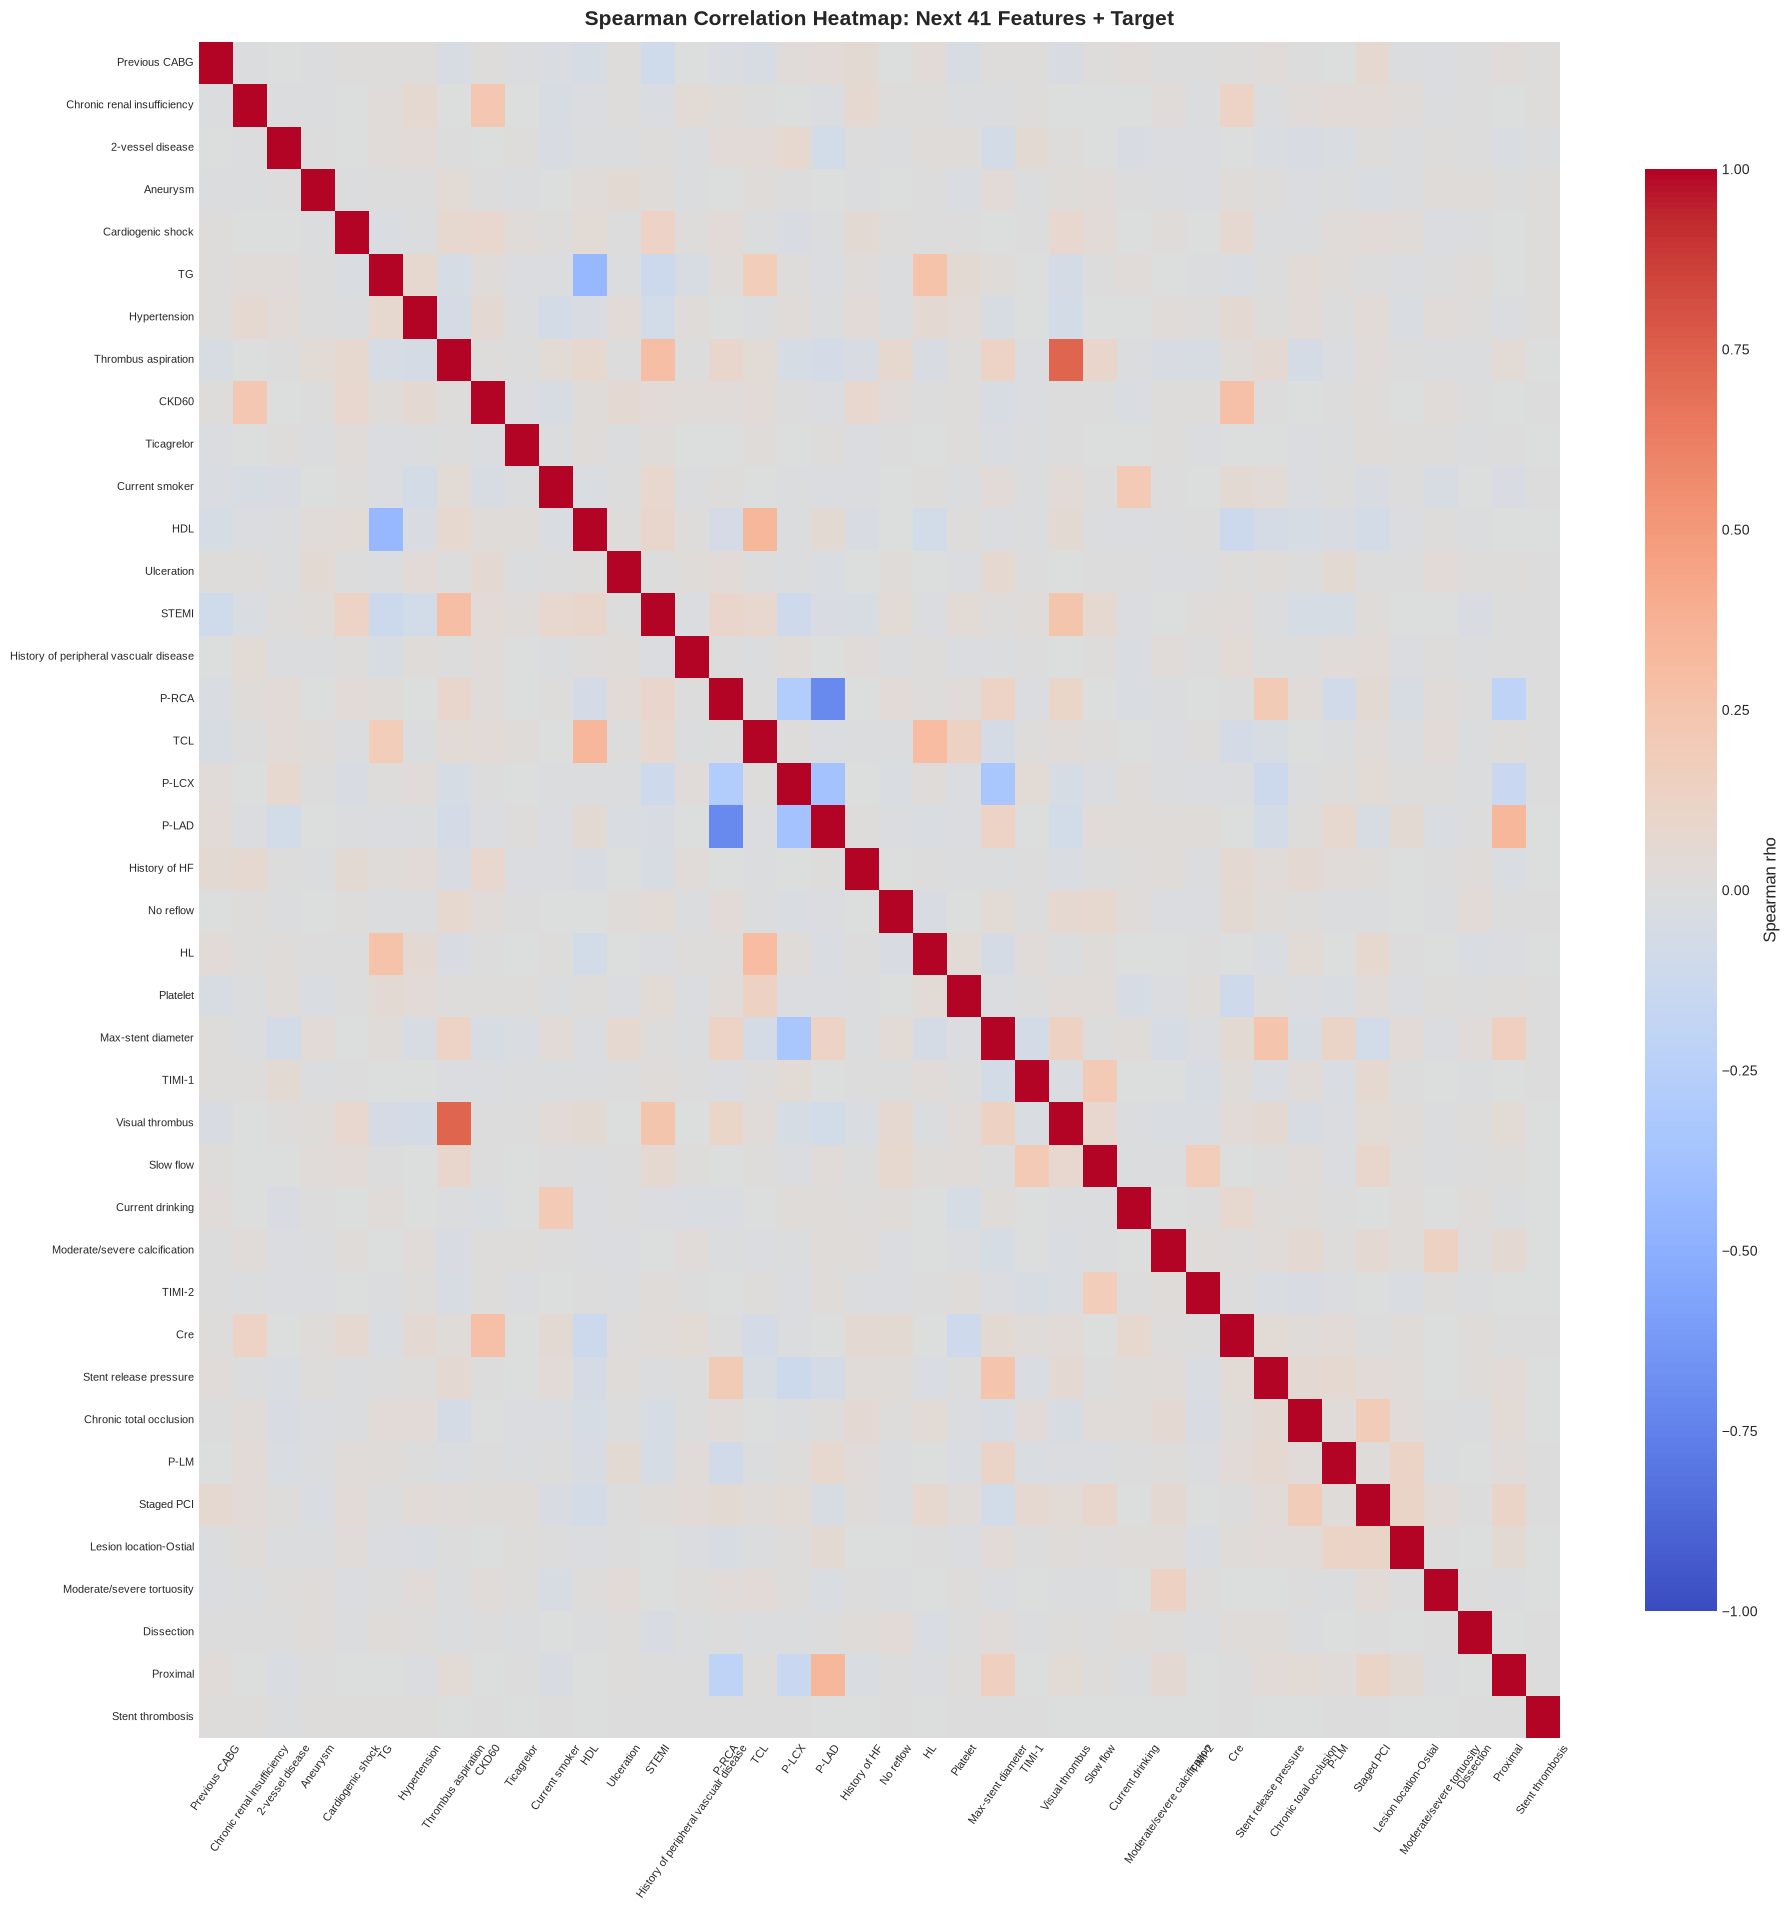

✓ Visualization saved: 03b_spearman_correlation_heatmap_next41_target.png (40×40)


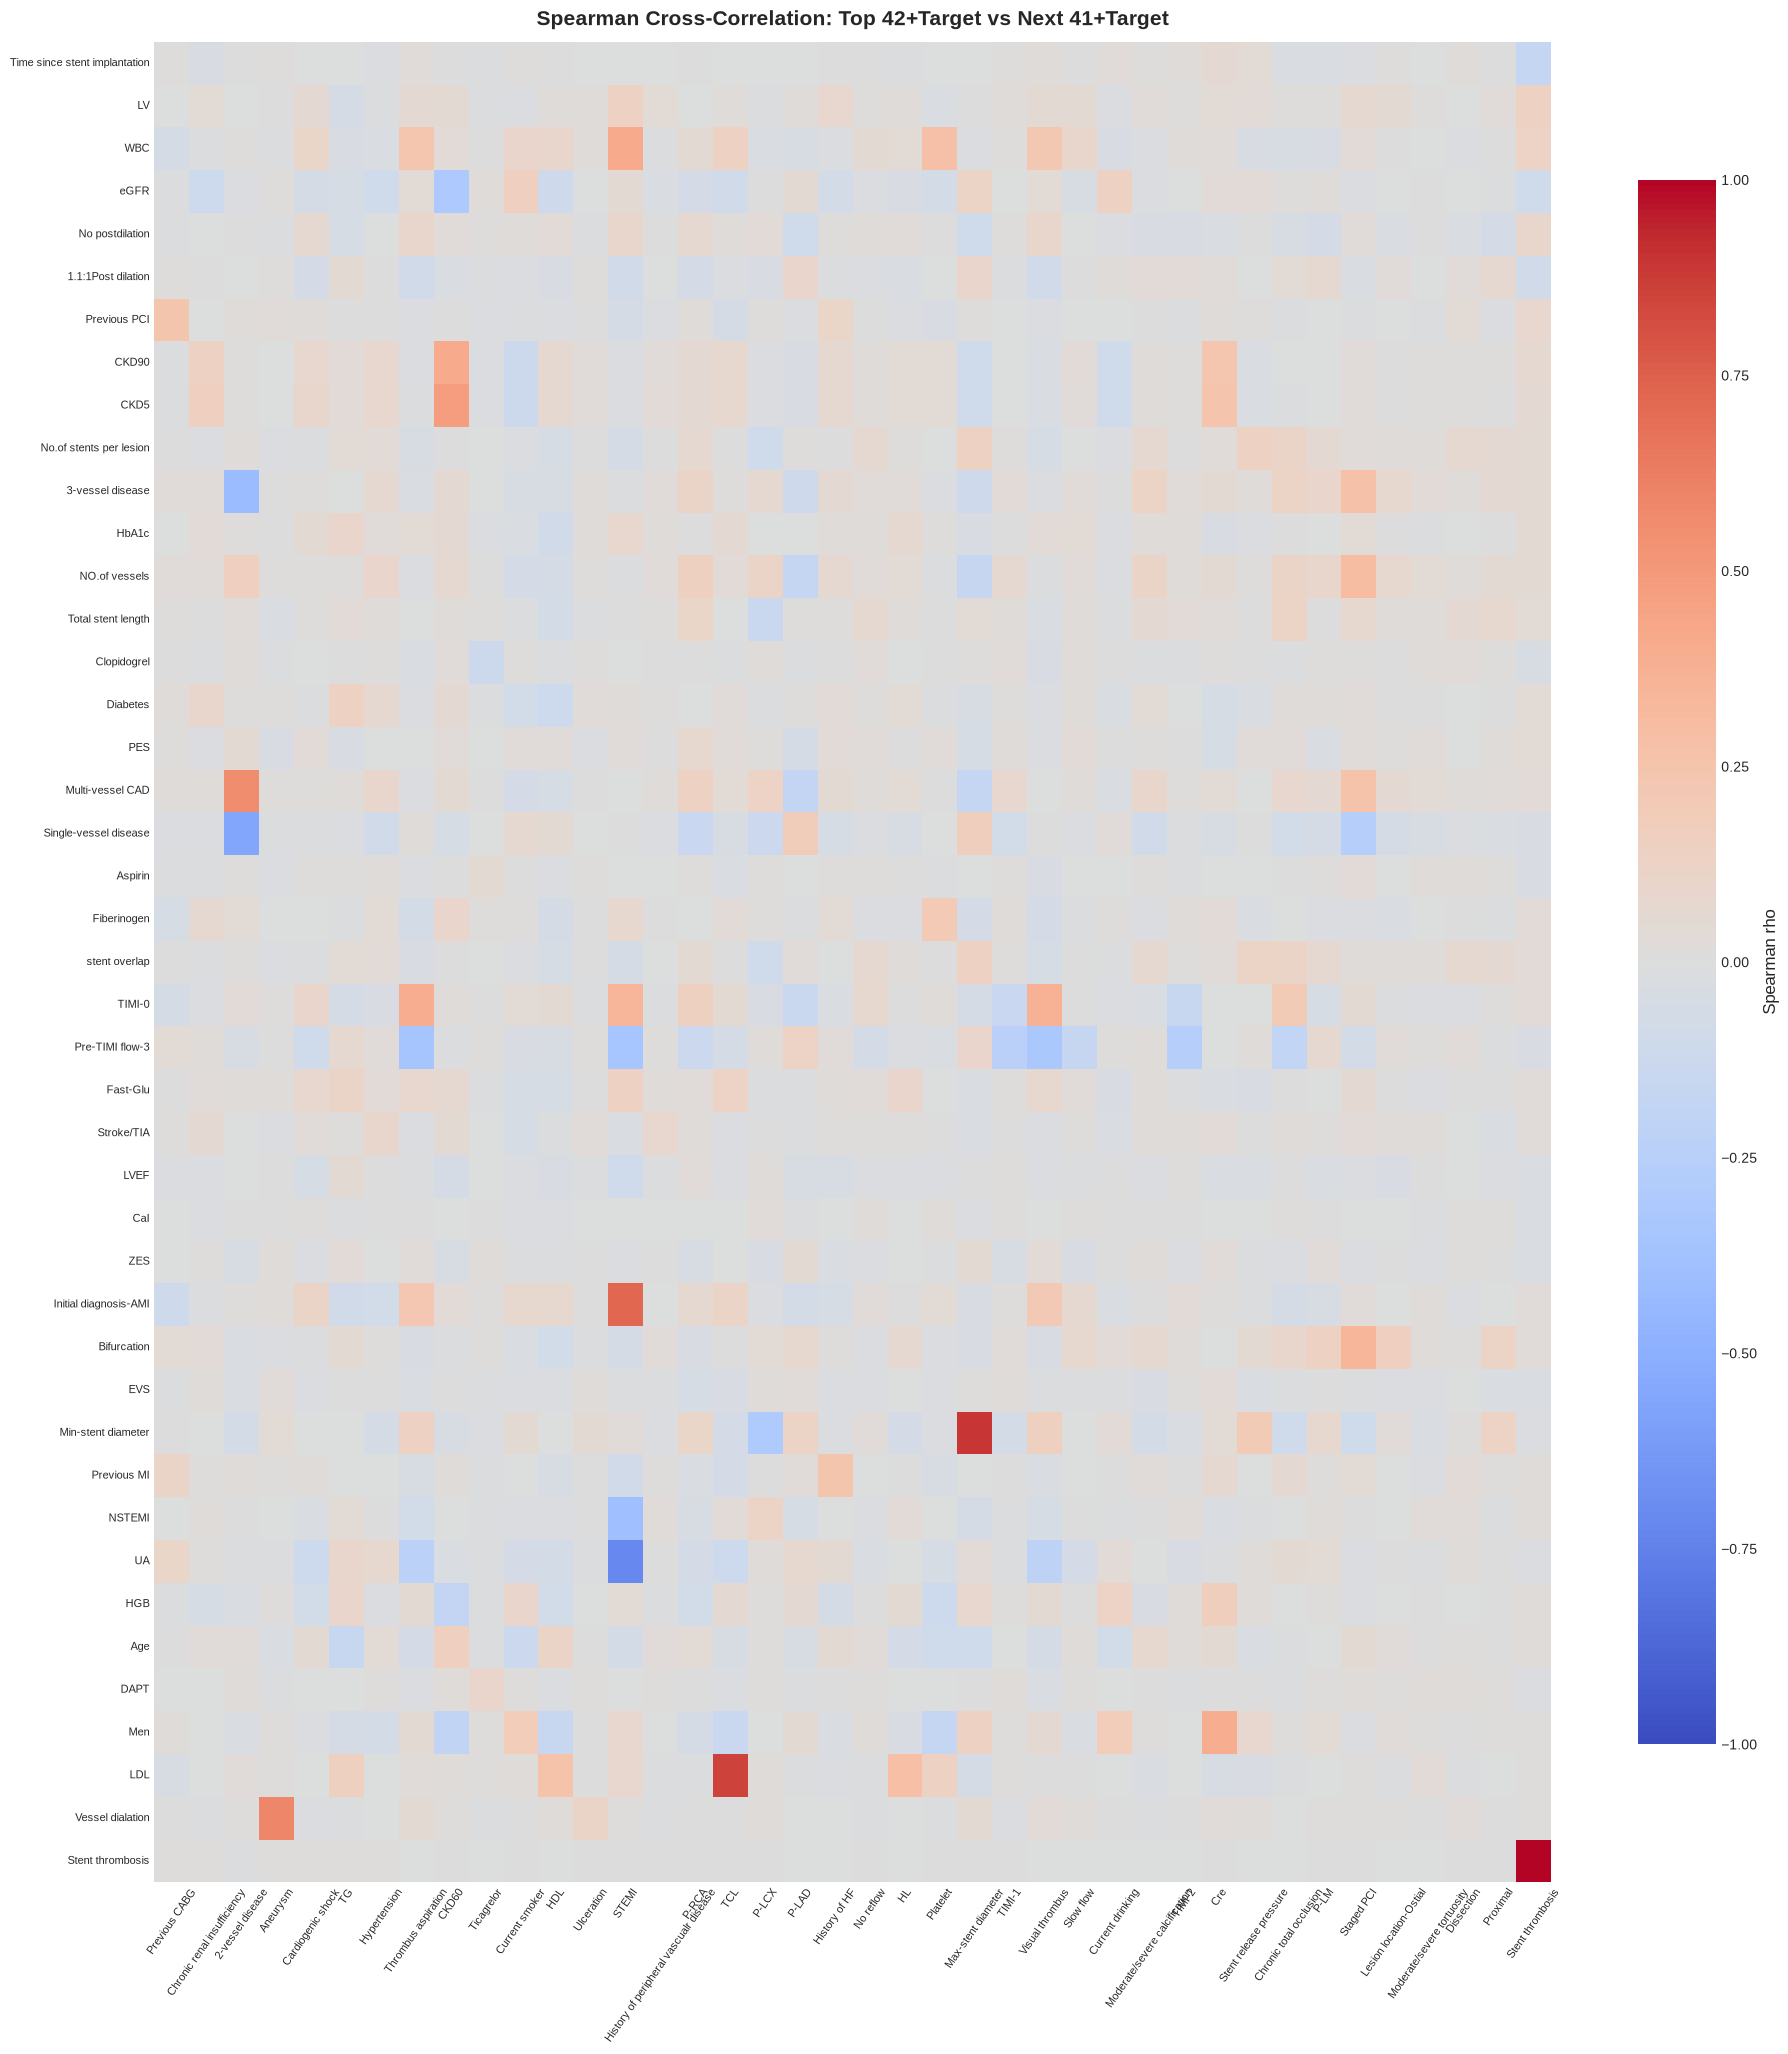

✓ Visualization saved: 03b_spearman_correlation_heatmap_top42_vs_next41_with_target.png (43×40)
✓ Saved: plots/spearman_correlations_with_target.csv


In [339]:
# Spearman visualizations (same presentation style as Pearson)
if TARGET_COL in df.columns and "spearman_correlations" in locals() and len(spearman_correlations) > 0:
    # Top positive / negative Spearman correlations
    top_pos_s = spearman_correlations.head(15)
    top_neg_s = spearman_correlations.tail(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    top_pos_s.plot(kind="barh", ax=axes[0], color="#e74c3c")
    axes[0].set_title(
        "Top 15 Positive Spearman Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Spearman Correlation Coefficient", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")

    top_neg_s.plot(kind="barh", ax=axes[1], color="#3498db")
    axes[1].set_title(
        "Top 15 Negative Spearman Correlations with Stent Thrombosis",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Spearman Correlation Coefficient", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/07b_top_spearman_correlations.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/07b_top_spearman_correlations.png")

    # Spearman heatmaps by ranked feature blocks (top 42 / next 41)
    TOP_N = 42
    NEXT_N = 41

    top_spearman_features = spearman_correlations.abs().nlargest(TOP_N).index.tolist()
    next_spearman_features = (
        spearman_correlations.abs().drop(top_spearman_features, errors="ignore").nlargest(NEXT_N).index.tolist()
    )
    next_spearman_features = [f for f in next_spearman_features if f not in set(top_spearman_features)]

    def _spearman_heatmap_figsize(n_rows, n_cols):
        return (max(18, n_cols * 0.48), max(18, n_rows * 0.48))

    def plot_spearman_heatmap(corr_data, title, out_path, figsize=None):
        if figsize is None:
            figsize = _spearman_heatmap_figsize(*corr_data.shape)
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(
            corr_data,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0,
            cbar_kws={"shrink": 0.85, "label": "Spearman rho"},
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
        ax.tick_params(axis="x", labelrotation=55, labelsize=8)
        ax.tick_params(axis="y", labelrotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_path.split('/')[-1]} ({corr_data.shape[0]}×{corr_data.shape[1]})")

    def features_with_target(feature_list):
        """Append target once (avoid duplicate Stent thrombosis labels)."""
        return list(dict.fromkeys(list(feature_list) + [TARGET_COL]))

    def block_spearman_corr_matrix(row_features, col_features, method=None):
        """Build cross-block correlation without duplicate target columns."""
        row_labels = features_with_target(row_features)
        col_labels = features_with_target(col_features)
        all_unique = list(dict.fromkeys(row_labels + col_labels))
        corr_kwargs = {"method": method} if method else {}
        full_corr = df[all_unique].corr(**corr_kwargs)
        return full_corr.loc[row_labels, col_labels]

    # 1) Top 42 features + target (43×43)
    spearman_top42_target = block_spearman_corr_matrix(top_spearman_features, top_spearman_features, method="spearman")
    plot_spearman_heatmap(
        spearman_top42_target,
        f"Spearman Correlation Heatmap: Top {TOP_N} Features + Target",
        "../data/result/eda/plots/03b_spearman_correlation_heatmap_top42_target.png",
    )

    # 2) Next 41 features + target (42×42)
    if len(next_spearman_features) > 0:
        spearman_next41_target = block_spearman_corr_matrix(
            next_spearman_features, next_spearman_features, method="spearman"
        )
        plot_spearman_heatmap(
            spearman_next41_target,
            f"Spearman Correlation Heatmap: Next {NEXT_N} Features + Target",
            "../data/result/eda/plots/03b_spearman_correlation_heatmap_next41_target.png",
        )

        # 3) Cross block: top 42 + target vs next 41 + target
        top_next_spearman_cross = block_spearman_corr_matrix(
            top_spearman_features, next_spearman_features, method="spearman"
        )
        plot_spearman_heatmap(
            top_next_spearman_cross,
            f"Spearman Cross-Correlation: Top {TOP_N}+Target vs Next {NEXT_N}+Target",
            "../data/result/eda/plots/03b_spearman_correlation_heatmap_top42_vs_next41_with_target.png",
        )


    # Save Spearman ranking table for parity with Pearson outputs
    spearman_df = pd.DataFrame(
        {
            "Feature": spearman_correlations.index,
            "Spearman_Correlation": spearman_correlations.values,
            "Abs_Spearman_Correlation": spearman_correlations.abs().values,
        }
    ).sort_values("Abs_Spearman_Correlation", ascending=False)
    spearman_df.to_csv(
        "../data/result/eda/plots/spearman_correlations_with_target.csv", index=False
    )
    print("✓ Saved: plots/spearman_correlations_with_target.csv")
else:
    print("Run the Spearman correlation calculation cell first.")

## 10. Statistical Tests - Association with Target

While correlation quantifies association strength (Pearson for linear, Spearman for rank/monotonic), statistical tests determine whether observed group differences are likely due to chance.

### Continuous variables — workflow

1. **Shape screening first** (skewness + kurtosis + group variance check)
2. Choose the test:
   - **Welch's t-test** (`ttest_ind`, `equal_var=False`): approximately **symmetric** features without extreme heavy tails (preferred with imbalanced groups ~5,093 vs ~92).
   - **Mann–Whitney U**: **skewed** and/or **heavy-tailed** (high kurtosis) features.
   - **Brunner–Munzel**: robustness check when Mann–Whitney is used and variances differ strongly.

**Decision rule:** Mann–Whitney if `|skewness| > 1` **or** excess kurtosis `> 3`; otherwise Welch's t-test.

**Continuous effect sizes** (sign = VLST − no VLST; positive ⇒ higher in VLST):
- **Cohen's d**, **Glass's Δ**, **Mann–Whitney r** \(= Z/\sqrt{N}\)
- Primary ES: Cohen's d for Welch; MW r for Mann–Whitney

### Binary variables

Full 2×2 suite vs VLST for **all** binary features: Chi-square, Yates, Fisher, Barnard, Boschloo (sparse only); OR, RR, risk difference, Phi.

### Categorical variables

The dataset has one multi-level categorical feature (`Stent type-SES`):
- Normalize labels, collapse rare levels (n < 30) into **Other**
- **Chi-square test of independence** on the r×2 table vs VLST
- Effect size: **Cramér's V**
- Report VLST rate by stent-type level

### Multiple-testing correction (continuous, binary, **and** categorical)

| Method | Controls | Use |
|---|---|---|
| **Bonferroni** | FWER | Strict; often overly conservative if tests are correlated |
| **Holm–Bonferroni** | FWER | Preferable to plain Bonferroni |
| **BH FDR** | False discovery rate | Best default for EDA screening |

Do **not** split correlated features into ad-hoc families to weaken Bonferroni. Prefer FDR/Holm under dependence. Correct within each family, then optionally **jointly** across continuous + binary + categorical.

**Primary EDA threshold:** FDR q < 0.05; Holm/Bonferroni as stricter filters.

### Formal results

Working/debug tables remain above. A dedicated **Results** cell produces publication-style summary tables and figures (FDR discoveries, effect sizes, categorical rates).


In [340]:
# Shared multiple-testing helpers (Bonferroni / Holm / BH-FDR)
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)


def adjust_pvalues(pvalues, method="holm"):
    """Adjusted p-values: 'bonferroni' | 'holm' | 'fdr_bh'."""
    p = np.asarray(pvalues, dtype=float)
    m = len(p)
    adj = np.full(m, np.nan)
    valid = np.isfinite(p)
    if valid.sum() == 0:
        return adj

    pv = p[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    if method == "bonferroni":
        out = np.minimum(1.0, ranked * n)
    elif method == "holm":
        raw = np.minimum(1.0, ranked * (n - np.arange(n)))
        out = np.maximum.accumulate(raw)
    elif method == "fdr_bh":
        ranks = np.arange(1, n + 1)
        raw = np.minimum(1.0, ranked * n / ranks)
        out = np.minimum.accumulate(raw[::-1])[::-1]
    else:
        raise ValueError(f"Unknown method: {method}")

    adj_valid = np.empty(n, dtype=float)
    adj_valid[order] = out
    adj[valid] = adj_valid
    return adj


def add_multiplicity_columns(df, p_col, family_name):
    out = df.copy()
    p = out[p_col].to_numpy(dtype=float)
    out["p_bonferroni"] = adjust_pvalues(p, "bonferroni")
    out["p_holm"] = adjust_pvalues(p, "holm")
    out["p_fdr_bh"] = adjust_pvalues(p, "fdr_bh")
    out["Sig Bonferroni (p_adj<0.05)"] = np.where(out["p_bonferroni"] < 0.05, "Yes", "No")
    out["Sig Holm (p_adj<0.05)"] = np.where(out["p_holm"] < 0.05, "Yes", "No")
    out["Sig FDR (q<0.05)"] = np.where(out["p_fdr_bh"] < 0.05, "Yes", "No")
    out["Multiplicity family"] = family_name
    return out


def summarize_multiplicity(df, family_name):
    raw_col = "P-value" if "P-value" in df.columns else "Recommended p-value"
    print(f"\nMultiple-testing correction — family: {family_name} (m = {len(df)} tests)")
    print(f"  Raw {raw_col}<0.05: {(df[raw_col] < 0.05).sum()}")
    print(f"  Bonferroni <0.05: {(df['p_bonferroni'] < 0.05).sum()}")
    print(f"  Holm <0.05:       {(df['p_holm'] < 0.05).sum()}")
    print(f"  FDR (BH) q<0.05:  {(df['p_fdr_bh'] < 0.05).sum()}")


print("✓ Multiple-testing helpers ready: adjust_pvalues, add_multiplicity_columns")


✓ Multiple-testing helpers ready: adjust_pvalues, add_multiplicity_columns


In [341]:
# 10a. Shape + variance screening BEFORE continuous group tests
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

target_0 = df[df[TARGET_COL] == 0]
target_1 = df[df[TARGET_COL] == 1]

SKEW_THRESHOLD = 1.0
KURTOSIS_THRESHOLD = 3.0  # Fisher excess kurtosis
VAR_RATIO_THRESHOLD = 4.0

print("=" * 80)
print("CONTINUOUS FEATURE SHAPE & VARIANCE SCREENING (pre-test)")
print("=" * 80)
print(f"Group sizes: No VLST = {len(target_0):,}, VLST = {len(target_1):,}")
print(
    f"\nPrimary test rule:\n"
    f"  Mann–Whitney U  if |skew| > {SKEW_THRESHOLD} OR excess kurtosis > {KURTOSIS_THRESHOLD}\n"
    f"  Welch t-test    otherwise\n"
    f"  + Brunner–Munzel if nonparametric AND (var ratio > {VAR_RATIO_THRESHOLD} OR Levene p < 0.05)\n"
)
print("Note: outliers ≠ skewness. Outliers inflate kurtosis and can occur in nearly symmetric data.")

shape_rows = []
for col in continuous_cols:
    pooled = df[col].dropna()
    g0 = target_0[col].dropna()
    g1 = target_1[col].dropna()
    if len(pooled) <= 3 or len(g0) <= 3 or len(g1) <= 3:
        continue

    sk = float(skew(pooled))
    kurt = float(kurtosis(pooled))
    var0, var1 = float(g0.var(ddof=1)), float(g1.var(ddof=1))
    var_ratio = max(var0, var1) / max(min(var0, var1), 1e-12)
    try:
        _, levene_p = levene(g0, g1, center="median")
    except Exception:
        levene_p = np.nan

    skewed = abs(sk) > SKEW_THRESHOLD
    heavy_tails = kurt > KURTOSIS_THRESHOLD
    unequal_var = (var_ratio > VAR_RATIO_THRESHOLD) or (
        np.isfinite(levene_p) and levene_p < 0.05
    )

    if skewed or heavy_tails:
        primary_test = "Mann-Whitney U"
        reasons = []
        if skewed:
            reasons.append(f"|skew|={abs(sk):.2f}>{SKEW_THRESHOLD}")
        if heavy_tails:
            reasons.append(f"kurtosis={kurt:.2f}>{KURTOSIS_THRESHOLD}")
        reason = "; ".join(reasons)
    else:
        primary_test = "Welch t-test"
        reason = "approx symmetric, kurtosis not extreme"

    if abs(sk) <= 0.5:
        skew_label = "Symmetric"
    elif abs(sk) <= SKEW_THRESHOLD:
        skew_label = "Moderate skew"
    else:
        skew_label = "High skew"
    kurt_label = (
        "Heavy tails" if kurt > KURTOSIS_THRESHOLD else ("Light tails / flat" if kurt < -1 else "Typical tails")
    )

    shape_rows.append(
        {
            "Feature": col,
            "n (no VLST)": len(g0),
            "n (VLST)": len(g1),
            "Skewness": sk,
            "Kurtosis (excess)": kurt,
            "Skew label": skew_label,
            "Kurtosis label": kurt_label,
            "Var (no VLST)": var0,
            "Var (VLST)": var1,
            "Variance ratio": var_ratio,
            "Levene p-value": levene_p,
            "Unequal variance flag": "Yes" if unequal_var else "No",
            "Primary test": primary_test,
            "Reason": reason,
            "Brunner-Munzel check": (
                "Yes" if (primary_test == "Mann-Whitney U" and unequal_var) else "No"
            ),
        }
    )

shape_df = pd.DataFrame(shape_rows).sort_values("Feature")
display(
    shape_df[
        [
            "Feature",
            "Skewness",
            "Kurtosis (excess)",
            "Skew label",
            "Kurtosis label",
            "Variance ratio",
            "Levene p-value",
            "Unequal variance flag",
            "Primary test",
            "Brunner-Munzel check",
            "Reason",
        ]
    ].reset_index(drop=True)
)

print(f"\n✓ Screened {len(shape_df)} continuous features")
print(f"  → Welch t-test: {(shape_df['Primary test']=='Welch t-test').sum()}")
print(f"  → Mann–Whitney U: {(shape_df['Primary test']=='Mann-Whitney U').sum()}")
print(f"  → Brunner–Munzel checks: {(shape_df['Brunner-Munzel check']=='Yes').sum()}")
shape_df.to_csv(str(PLOT_DIR / "continuous_shape_variance_screening.csv"), index=False)
print("✓ Saved: plots/continuous_shape_variance_screening.csv")


CONTINUOUS FEATURE SHAPE & VARIANCE SCREENING (pre-test)
Group sizes: No VLST = 5,093, VLST = 92

Primary test rule:
  Mann–Whitney U  if |skew| > 1.0 OR excess kurtosis > 3.0
  Welch t-test    otherwise
  + Brunner–Munzel if nonparametric AND (var ratio > 4.0 OR Levene p < 0.05)

Note: outliers ≠ skewness. Outliers inflate kurtosis and can occur in nearly symmetric data.


,Feature,Skewness,Kurtosis (excess),Skew label,Kurtosis label,Variance ratio,Levene p-value,Unequal variance flag,Primary test,Brunner-Munzel check,Reason
0,Age,-0.071792,-0.277198,Symmetric,Typical tails,1.303066,2.458530e-01,No,Welch t-test,No,"approx symmetric, kurtosis not extreme"
1,CKD5,2.617650,7.507913,High skew,Heavy tails,1.318705,4.620758e-04,Yes,Mann-Whitney U,Yes,|skew|=2.62>1.0; kurtosis=7.51>3.0
2,CaI,2.834164,9.432386,High skew,Heavy tails,1.373965,3.901623e-01,No,Mann-Whitney U,No,|skew|=2.83>1.0; kurtosis=9.43>3.0
3,Cre,7.484056,161.335262,High skew,Heavy tails,1.695576,4.752238e-01,No,Mann-Whitney U,No,|skew|=7.48>1.0; kurtosis=161.34>3.0
4,Fast-Glu,2.417145,7.838604,High skew,Heavy tails,2.133894,5.220410e-05,Yes,Mann-Whitney U,Yes,|skew|=2.42>1.0; kurtosis=7.84>3.0
5,Fiberinogen,1.621689,5.653460,High skew,Heavy tails,1.309276,9.544206e-01,No,Mann-Whitney U,No,|skew|=1.62>1.0; kurtosis=5.65>3.0
6,HDL,0.914837,1.730921,Moderate skew,Typical tails,1.579324,2.786472e-02,Yes,Welch t-test,No,"approx symmetric, kurtosis not extreme"
7,HGB,-0.409105,0.523073,Symmetric,Typical tails,1.536875,1.881683e-02,Yes,Welch t-test,No,"approx symmetric, kurtosis not extreme"
8,HbA1c,1.396370,1.918633,High skew,Typical tails,1.111661,6.074179e-01,No,Mann-Whitney U,No,|skew|=1.40>1.0
9,LDL,1.055899,4.671018,High skew,Heavy tails,1.780126,7.411031e-02,No,Mann-Whitney U,No,|skew|=1.06>1.0; kurtosis=4.67>3.0



✓ Screened 24 continuous features
  → Welch t-test: 10
  → Mann–Whitney U: 14
  → Brunner–Munzel checks: 6
✓ Saved: plots/continuous_shape_variance_screening.csv


In [342]:
# 10b. Continuous tests vs VLST: Welch t-test / Mann–Whitney U + effect sizes + multiplicity
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)


def cohens_d(group_0, group_1):
    n0, n1 = len(group_0), len(group_1)
    pooled = np.sqrt(
        ((n0 - 1) * group_0.var(ddof=1) + (n1 - 1) * group_1.var(ddof=1)) / (n0 + n1 - 2)
    )
    if pooled == 0 or not np.isfinite(pooled):
        return np.nan
    return (group_1.mean() - group_0.mean()) / pooled


def glass_delta(group_0, group_1):
    s0 = group_0.std(ddof=1)
    if s0 == 0 or not np.isfinite(s0):
        return np.nan
    return (group_1.mean() - group_0.mean()) / s0


def mannwhitney_r(group_0, group_1):
    """r = Z/sqrt(N); positive => VLST values tend to rank higher."""
    n0, n1 = len(group_0), len(group_1)
    n = n0 + n1
    if min(n0, n1) == 0 or n <= 1:
        return np.nan
    u_vlst = mannwhitneyu(group_1, group_0, alternative="two-sided").statistic
    mu_u = n0 * n1 / 2.0
    sigma_u = np.sqrt(n0 * n1 * (n0 + n1 + 1) / 12.0)
    if sigma_u == 0 or not np.isfinite(sigma_u):
        return np.nan
    z = (u_vlst - mu_u) / sigma_u
    return float(z / np.sqrt(n))


print("=" * 80)
print("CONTINUOUS VARIABLES vs VLST — WELCH t-TEST / MANN–WHITNEY U")
print("=" * 80)
print(
    "Effect sizes: Cohen's d, Glass's Δ, Mann–Whitney r (=Z/sqrt(N))\n"
    "Sign: positive => higher values among VLST patients"
)

if "shape_df" not in globals() or shape_df.empty:
    raise RuntimeError("Run the shape/variance screening cell (10a) first.")
if "add_multiplicity_columns" not in globals():
    raise RuntimeError("Run the multiple-testing helpers cell first.")

continuous_test_results = []
for _, row in shape_df.iterrows():
    col = row["Feature"]
    try:
        group_0 = target_0[col].dropna()
        group_1 = target_1[col].dropna()
        primary_test = row["Primary test"]

        if primary_test == "Welch t-test":
            stat, p_value = ttest_ind(
                group_0, group_1, equal_var=False, nan_policy="omit"
            )
            test_name = "Welch t-test"
        else:
            stat, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")
            test_name = "Mann-Whitney U"

        bm_p = np.nan
        if row["Brunner-Munzel check"] == "Yes":
            try:
                _, bm_p = brunnermunzel(group_0, group_1, alternative="two-sided")
            except Exception:
                pass

        pearson_r = df[[col, TARGET_COL]].corr().iloc[0, 1]
        spearman_rho = df[[col, TARGET_COL]].corr(method="spearman").iloc[0, 1]
        d = cohens_d(group_0, group_1)
        delta = glass_delta(group_0, group_1)
        r_mw = mannwhitney_r(group_0, group_1)
        primary_es_name = "Cohen's d" if test_name == "Welch t-test" else "Mann-Whitney r"
        primary_es = d if test_name == "Welch t-test" else r_mw

        continuous_test_results.append(
            {
                "Feature": col,
                "Skewness": row["Skewness"],
                "Kurtosis (excess)": row["Kurtosis (excess)"],
                "Variance ratio": row["Variance ratio"],
                "Test": test_name,
                "Statistic": float(stat),
                "P-value": float(p_value),
                "Brunner-Munzel p-value": float(bm_p) if np.isfinite(bm_p) else np.nan,
                "Cohen's d": d,
                "Glass's delta": delta,
                "Mann-Whitney r": r_mw,
                "Primary effect size name": primary_es_name,
                "Primary effect size": primary_es,
                "Pearson r": pearson_r,
                "Spearman rho": spearman_rho,
                "Direction (Pearson)": "Positive" if pearson_r > 0 else "Negative",
                "Direction (Spearman)": "Positive" if spearman_rho > 0 else "Negative",
                "Mean (no VLST)": group_0.mean(),
                "Mean (VLST)": group_1.mean(),
                "Mean diff (VLST - no)": group_1.mean() - group_0.mean(),
                "Median (no VLST)": group_0.median(),
                "Median (VLST)": group_1.median(),
                "Median diff (VLST - no)": group_1.median() - group_0.median(),
                "Significant": "Yes" if p_value < 0.05 else "No",
            }
        )
    except Exception:
        pass

if continuous_test_results:
    continuous_test_df = pd.DataFrame(continuous_test_results).sort_values("P-value")
    continuous_test_df = add_multiplicity_columns(
        continuous_test_df, p_col="P-value", family_name="continuous_vs_VLST"
    )
    summarize_multiplicity(continuous_test_df, "continuous_vs_VLST")

    print("\nAll continuous features (raw + adjusted p, effect sizes):")
    display(
        continuous_test_df[
            [
                "Feature",
                "Test",
                "P-value",
                "p_bonferroni",
                "p_holm",
                "p_fdr_bh",
                "Sig FDR (q<0.05)",
                "Cohen's d",
                "Glass's delta",
                "Mann-Whitney r",
                "Primary effect size name",
                "Primary effect size",
                "Mean diff (VLST - no)",
                "Median diff (VLST - no)",
            ]
        ].reset_index(drop=True)
    )

    significant_continuous = continuous_test_df[continuous_test_df["P-value"] < 0.05]
    print(f"\n✓ Raw p<0.05: {len(significant_continuous)} features")
    fdr_hits = continuous_test_df[continuous_test_df["p_fdr_bh"] < 0.05]
    print(f"✓ FDR q<0.05: {len(fdr_hits)} features (recommended EDA discovery set)")
    if not fdr_hits.empty:
        display(
            fdr_hits[
                [
                    "Feature",
                    "Test",
                    "P-value",
                    "p_fdr_bh",
                    "p_holm",
                    "p_bonferroni",
                    "Primary effect size name",
                    "Primary effect size",
                    "Direction (Spearman)",
                ]
            ].reset_index(drop=True)
        )

    continuous_test_df.to_csv(
        str(PLOT_DIR / "continuous_target_association_tests.csv"), index=False
    )
    print("✓ Saved: plots/continuous_target_association_tests.csv")
else:
    continuous_test_df = pd.DataFrame()
    print("No valid continuous-variable test results obtained.")


CONTINUOUS VARIABLES vs VLST — WELCH t-TEST / MANN–WHITNEY U
Effect sizes: Cohen's d, Glass's Δ, Mann–Whitney r (=Z/sqrt(N))
Sign: positive => higher values among VLST patients

Multiple-testing correction — family: continuous_vs_VLST (m = 24 tests)
  Raw P-value<0.05: 13
  Bonferroni <0.05: 9
  Holm <0.05:       9
  FDR (BH) q<0.05:  10

All continuous features (raw + adjusted p, effect sizes):


,Feature,Test,P-value,p_bonferroni,p_holm,p_fdr_bh,Sig FDR (q<0.05),Cohen's d,Glass's delta,Mann-Whitney r,Primary effect size name,Primary effect size,Mean diff (VLST - no),Median diff (VLST - no)
0,Time since stent implantation,Mann-Whitney U,1.697913e-34,4.074991e-33,4.074991e-33,4.074991e-33,Yes,-4.838038,-5.311694,-0.170110,Mann-Whitney r,-0.170110,-572.054822,-683.000
1,WBC,Mann-Whitney U,7.902144e-21,1.896515e-19,1.817493e-19,9.482573e-20,Yes,1.150583,1.155277,0.129679,Mann-Whitney r,0.129679,3.745038,3.820
2,eGFR,Welch t-test,4.643061e-20,1.114335e-18,1.021473e-18,3.714449e-19,Yes,-0.712424,-0.708230,-0.096333,Cohen's d,-0.712424,-24.152930,-17.575
3,LV,Welch t-test,5.438331e-17,1.305199e-15,1.142049e-15,3.262999e-16,Yes,1.127413,1.128374,0.138001,Cohen's d,1.127413,4.560492,4.000
4,CKD5,Mann-Whitney U,1.186437e-05,2.847449e-04,2.372874e-04,5.694897e-05,Yes,0.368609,0.369639,0.039877,Mann-Whitney r,0.039877,0.184550,0.000
5,No.of stents per lesion,Mann-Whitney U,1.412198e-04,3.389275e-03,2.683176e-03,5.648792e-04,Yes,0.457962,0.462099,0.036544,Mann-Whitney r,0.036544,0.210679,0.000
6,HbA1c,Mann-Whitney U,1.975000e-04,4.740001e-03,3.555000e-03,6.771429e-04,Yes,0.293969,0.293709,0.051597,Mann-Whitney r,0.051597,0.474161,1.050
7,NO.of vessels,Welch t-test,4.766857e-04,1.144046e-02,8.103656e-03,1.430057e-03,Yes,0.387876,0.388008,0.047120,Cohen's d,0.387876,0.318888,0.000
8,Total stent length,Mann-Whitney U,1.122263e-03,2.693432e-02,1.795622e-02,2.992703e-03,Yes,0.429724,0.432569,0.045066,Mann-Whitney r,0.045066,6.758701,2.000
9,Fiberinogen,Mann-Whitney U,1.191098e-02,2.858634e-01,1.786646e-01,2.858634e-02,Yes,0.221316,0.221916,0.034924,Mann-Whitney r,0.034924,0.195236,0.170



✓ Raw p<0.05: 13 features
✓ FDR q<0.05: 10 features (recommended EDA discovery set)


,Feature,Test,P-value,p_fdr_bh,p_holm,p_bonferroni,Primary effect size name,Primary effect size,Direction (Spearman)
0,Time since stent implantation,Mann-Whitney U,1.697913e-34,4.074991e-33,4.074991e-33,4.074991e-33,Mann-Whitney r,-0.170110,Negative
1,WBC,Mann-Whitney U,7.902144e-21,9.482573e-20,1.817493e-19,1.896515e-19,Mann-Whitney r,0.129679,Positive
2,eGFR,Welch t-test,4.643061e-20,3.714449e-19,1.021473e-18,1.114335e-18,Cohen's d,-0.712424,Negative
3,LV,Welch t-test,5.438331e-17,3.262999e-16,1.142049e-15,1.305199e-15,Cohen's d,1.127413,Positive
4,CKD5,Mann-Whitney U,1.186437e-05,5.694897e-05,2.372874e-04,2.847449e-04,Mann-Whitney r,0.039877,Positive
5,No.of stents per lesion,Mann-Whitney U,1.412198e-04,5.648792e-04,2.683176e-03,3.389275e-03,Mann-Whitney r,0.036544,Positive
6,HbA1c,Mann-Whitney U,1.975000e-04,6.771429e-04,3.555000e-03,4.740001e-03,Mann-Whitney r,0.051597,Positive
7,NO.of vessels,Welch t-test,4.766857e-04,1.430057e-03,8.103656e-03,1.144046e-02,Cohen's d,0.387876,Positive
8,Total stent length,Mann-Whitney U,1.122263e-03,2.992703e-03,1.795622e-02,2.693432e-02,Mann-Whitney r,0.045066,Positive
9,Fiberinogen,Mann-Whitney U,1.191098e-02,2.858634e-02,1.786646e-01,2.858634e-01,Mann-Whitney r,0.034924,Positive


✓ Saved: plots/continuous_target_association_tests.csv


VLST CORRELATION DIRECTION — SIGNIFICANT CONTINUOUS FEATURES
Positive: higher feature values associate with higher VLST risk
Negative: higher feature values associate with lower VLST risk


,Feature,Test,P-value,p_fdr_bh,p_holm,p_bonferroni,Cohen's d,Glass's delta,Mann-Whitney r,Primary effect size name,Primary effect size,Pearson r,Direction (Pearson),Spearman rho,Direction (Spearman),Mean (no VLST),Mean (VLST),Median (no VLST),Median (VLST)
0,Time since stent implantation,Mann-Whitney U,1.697913e-34,4.074991e-33,4.074991e-33,4.074991e-33,-4.838038,-5.311694,-0.170110,Mann-Whitney r,-0.170110,-0.538354,Negative,-0.170127,Negative,1420.109169,848.054348,1419.00,736.000
1,LV,Welch t-test,5.438331e-17,3.262999e-16,1.142049e-15,1.305199e-15,1.127413,1.128374,0.138001,Cohen's d,1.127413,0.147245,Positive,0.139046,Positive,44.548203,49.108696,44.00,48.000
2,WBC,Mann-Whitney U,7.902144e-21,9.482573e-20,1.817493e-19,1.896515e-19,1.150583,1.155277,0.129679,Mann-Whitney r,0.129679,0.150203,Positive,0.130014,Positive,8.746701,12.491739,8.00,11.820
3,eGFR,Welch t-test,4.643061e-20,3.714449e-19,1.021473e-18,1.114335e-18,-0.712424,-0.708230,-0.096333,Cohen's d,-0.712424,-0.093657,Negative,-0.096342,Negative,120.028908,95.875978,114.46,96.885
4,CKD5,Mann-Whitney U,1.186437e-05,5.694897e-05,2.372874e-04,2.847449e-04,0.368609,0.369639,0.039877,Mann-Whitney r,0.039877,0.048615,Positive,0.060835,Positive,1.206754,1.391304,1.00,1.000
5,No.of stents per lesion,Mann-Whitney U,1.412198e-04,5.648792e-04,2.683176e-03,3.389275e-03,0.457962,0.462099,0.036544,Mann-Whitney r,0.036544,0.060360,Positive,0.052862,Positive,1.213234,1.423913,1.00,1.000
6,HbA1c,Mann-Whitney U,1.975000e-04,6.771429e-04,3.555000e-03,4.740001e-03,0.293969,0.293709,0.051597,Mann-Whitney r,0.051597,0.038787,Positive,0.051698,Positive,5.800079,6.274239,5.40,6.450
7,NO.of vessels,Welch t-test,4.766857e-04,1.430057e-03,8.103656e-03,1.144046e-02,0.387876,0.388008,0.047120,Cohen's d,0.387876,0.051149,Positive,0.050256,Positive,1.865894,2.184783,2.00,2.000
8,Total stent length,Mann-Whitney U,1.122263e-03,2.992703e-03,1.795622e-02,2.693432e-02,0.429724,0.432569,0.045066,Mann-Whitney r,0.045066,0.056651,Positive,0.045250,Positive,31.697821,38.456522,28.00,30.000
9,Fiberinogen,Mann-Whitney U,1.191098e-02,2.858634e-02,1.786646e-01,2.858634e-01,0.221316,0.221916,0.034924,Mann-Whitney r,0.034924,0.029211,Positive,0.034928,Positive,3.170416,3.365652,3.03,3.200



Significant continuous features (raw p<0.05): 13
  Positive Spearman: 10 | Negative Spearman: 3


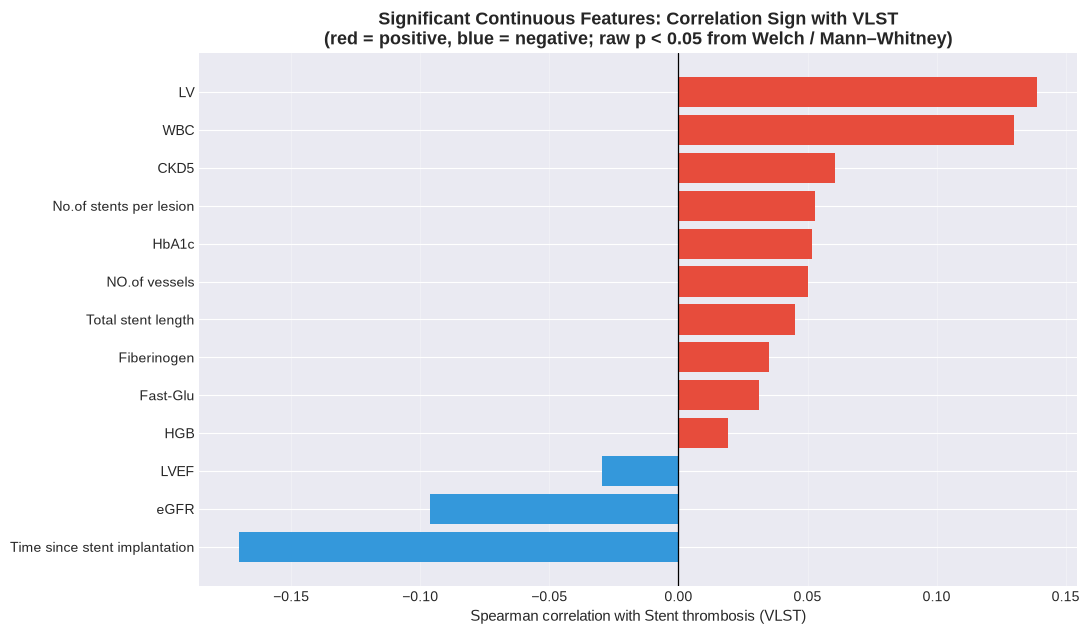

✓ Visualization saved: 10_significant_continuous_vlst_correlation_direction.png
✓ Saved: significant_continuous_vlst_correlation_direction.csv


In [343]:
# Correlation direction + effect sizes for continuous features with significant VLST association
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("VLST CORRELATION DIRECTION — SIGNIFICANT CONTINUOUS FEATURES")
print("=" * 80)
print(
    "Positive: higher feature values associate with higher VLST risk\n"
    "Negative: higher feature values associate with lower VLST risk"
)

if "continuous_test_df" not in globals() or continuous_test_df.empty:
    print("Run the continuous tests cell (10b) first.")
else:
    sig_corr = (
        continuous_test_df[continuous_test_df["P-value"] < 0.05]
        .copy()
        .sort_values("Spearman rho", key=lambda s: s.abs(), ascending=False)
    )
    if sig_corr.empty:
        print("No continuous features with p < 0.05.")
    else:
        display_cols = [
            "Feature",
            "Test",
            "P-value",
            "p_fdr_bh",
            "p_holm",
            "p_bonferroni",
            "Cohen's d",
            "Glass's delta",
            "Mann-Whitney r",
            "Primary effect size name",
            "Primary effect size",
            "Pearson r",
            "Direction (Pearson)",
            "Spearman rho",
            "Direction (Spearman)",
            "Mean (no VLST)",
            "Mean (VLST)",
            "Median (no VLST)",
            "Median (VLST)",
        ]
        display_cols = [c for c in display_cols if c in sig_corr.columns]
        display(sig_corr[display_cols].reset_index(drop=True))

        n_pos = (sig_corr["Spearman rho"] > 0).sum()
        n_neg = (sig_corr["Spearman rho"] < 0).sum()
        print(f"\nSignificant continuous features (raw p<0.05): {len(sig_corr)}")
        print(f"  Positive Spearman: {n_pos} | Negative Spearman: {n_neg}")

        plot_df = sig_corr.sort_values("Spearman rho")
        colors = ["#e74c3c" if v > 0 else "#3498db" for v in plot_df["Spearman rho"]]
        fig_h = max(6, 0.38 * len(plot_df) + 1.5)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        ax.barh(plot_df["Feature"], plot_df["Spearman rho"], color=colors)
        ax.axvline(0, color="black", linewidth=0.9)
        ax.set_xlabel("Spearman correlation with Stent thrombosis (VLST)", fontsize=11)
        ax.set_title(
            "Significant Continuous Features: Correlation Sign with VLST\n"
            "(red = positive, blue = negative; raw p < 0.05 from Welch / Mann–Whitney)",
            fontsize=13,
            fontweight="bold",
        )
        ax.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        out_png = PLOT_DIR / "10_significant_continuous_vlst_correlation_direction.png"
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Visualization saved: {out_png.name}")

        out_csv = PLOT_DIR / "significant_continuous_vlst_correlation_direction.csv"
        sig_corr[display_cols].to_csv(out_csv, index=False)
        print(f"✓ Saved: {out_csv.name}")


In [344]:
# Binary variables vs VLST: all applicable 2x2 tests + full p-values + multiplicity
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

from scipy.stats import fisher_exact, barnard_exact, boschloo_exact

print("\n" + "=" * 80)
print("BINARY VARIABLES vs VLST — FULL STATISTICAL TEST SUITE")
print("=" * 80)
print(f"Testing all {len(binary_cols)} binary features (not limited to top-N).")
print(
    "Tests: Chi-square, Chi-square (Yates), Fisher exact, Barnard exact;\n"
    "       Boschloo exact only when min expected count < 5 (sparse tables).\n"
    "Effect sizes: Odds Ratio, Relative Risk, Risk Difference, Phi.\n"
    "Then Bonferroni / Holm / FDR within the binary family."
)

if "add_multiplicity_columns" not in globals():
    raise RuntimeError("Run the multiple-testing helpers cell first.")

binary_test_results = []
skipped = []

for col in binary_cols:
    try:
        tmp = df[[col, TARGET_COL]].dropna()
        tmp = tmp[tmp[col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]
        contingency = pd.crosstab(tmp[col], tmp[TARGET_COL])
        contingency = contingency.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        table = contingency.values.astype(float)

        if table.sum() == 0 or table.sum(axis=1).min() == 0 or table.sum(axis=0).min() == 0:
            skipped.append((col, "degenerate table (empty row/column)"))
            continue

        a, b, c, d = table[1, 1], table[1, 0], table[0, 1], table[0, 0]
        chi2, chi2_p, _, expected = chi2_contingency(table, correction=False)
        _, chi2_yates_p, _, _ = chi2_contingency(table, correction=True)
        odds_ratio, fisher_p = fisher_exact(table, alternative="two-sided")
        min_expected = float(expected.min())

        barnard_p = np.nan
        try:
            barnard_p = float(barnard_exact(table).pvalue)
        except Exception:
            pass

        boschloo_p = np.nan
        if min_expected < 5:
            try:
                boschloo_p = float(boschloo_exact(table).pvalue)
            except Exception:
                pass

        risk_on = a / (a + b) if (a + b) > 0 else np.nan
        risk_off = c / (c + d) if (c + d) > 0 else np.nan
        risk_diff = risk_on - risk_off if np.isfinite(risk_on) and np.isfinite(risk_off) else np.nan
        rel_risk = (
            risk_on / risk_off
            if np.isfinite(risk_on) and np.isfinite(risk_off) and risk_off > 0
            else np.nan
        )
        n = table.sum()
        phi = (
            (a * d - b * c) / np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
            if n > 0
            else np.nan
        )

        recommended = "Fisher exact" if min_expected < 5 else "Chi-square"
        recommended_p = fisher_p if min_expected < 5 else chi2_p

        binary_test_results.append(
            {
                "Feature": col,
                "n": int(n),
                "VLST rate (feature=1)": risk_on,
                "VLST rate (feature=0)": risk_off,
                "Odds Ratio": odds_ratio,
                "Relative Risk": rel_risk,
                "Risk Difference": risk_diff,
                "Phi": phi,
                "Min Expected": min_expected,
                "Chi-square": chi2,
                "Chi-square p-value": chi2_p,
                "Chi-square Yates p-value": chi2_yates_p,
                "Fisher p-value": fisher_p,
                "Barnard p-value": barnard_p,
                "Boschloo p-value": boschloo_p,
                "Recommended test": recommended,
                "Recommended p-value": recommended_p,
                "P-value": recommended_p,
                "Significant (recommended p<0.05)": "Yes" if recommended_p < 0.05 else "No",
            }
        )
    except Exception as e:
        skipped.append((col, str(e)))

if binary_test_results:
    binary_test_df = pd.DataFrame(binary_test_results).sort_values("P-value")
    chi2_df = binary_test_df[
        ["Feature", "Chi-square", "Chi-square p-value", "Significant (recommended p<0.05)"]
    ].rename(
        columns={
            "Chi-square": "Chi2",
            "Chi-square p-value": "P-value",
            "Significant (recommended p<0.05)": "Significant",
        }
    )

    binary_test_df = add_multiplicity_columns(
        binary_test_df, p_col="P-value", family_name="binary_vs_VLST"
    )
    summarize_multiplicity(binary_test_df, "binary_vs_VLST")

    pd.set_option("display.max_rows", None)
    print(f"\nAll {len(binary_test_df)} binary features — full p-values + adjustments:")
    display(
        binary_test_df[
            [
                "Feature",
                "Recommended test",
                "P-value",
                "p_bonferroni",
                "p_holm",
                "p_fdr_bh",
                "Sig FDR (q<0.05)",
                "Chi-square p-value",
                "Fisher p-value",
                "Barnard p-value",
                "Odds Ratio",
                "Relative Risk",
                "Phi",
            ]
        ].reset_index(drop=True)
    )

    fdr_hits = binary_test_df[binary_test_df["p_fdr_bh"] < 0.05]
    print(f"\n✓ FDR q<0.05 binary discoveries: {len(fdr_hits)}")
    if not fdr_hits.empty:
        display(
            fdr_hits[
                [
                    "Feature",
                    "Recommended test",
                    "P-value",
                    "p_fdr_bh",
                    "p_holm",
                    "p_bonferroni",
                    "Odds Ratio",
                    "Phi",
                ]
            ].reset_index(drop=True)
        )

    out_csv = PLOT_DIR / "binary_target_association_tests_full.csv"
    binary_test_df.to_csv(out_csv, index=False)
    print(f"✓ Saved full results: {out_csv.name}")
else:
    binary_test_df = pd.DataFrame()
    chi2_df = pd.DataFrame()
    print("No valid binary-variable test results obtained.")

if skipped:
    print(f"\nSkipped {len(skipped)} features:")
    for name, reason in skipped:
        print(f"  - {name}: {reason}")



BINARY VARIABLES vs VLST — FULL STATISTICAL TEST SUITE
Testing all 57 binary features (not limited to top-N).
Tests: Chi-square, Chi-square (Yates), Fisher exact, Barnard exact;
       Boschloo exact only when min expected count < 5 (sparse tables).
Effect sizes: Odds Ratio, Relative Risk, Risk Difference, Phi.
Then Bonferroni / Holm / FDR within the binary family.

Multiple-testing correction — family: binary_vs_VLST (m = 57 tests)
  Raw P-value<0.05: 15
  Bonferroni <0.05: 5
  Holm <0.05:       5
  FDR (BH) q<0.05:  10

All 57 binary features — full p-values + adjustments:


,Feature,Recommended test,P-value,p_bonferroni,p_holm,p_fdr_bh,Sig FDR (q<0.05),Chi-square p-value,Fisher p-value,Barnard p-value,Odds Ratio,Relative Risk,Phi
0,1.1:1Post dilation,Chi-square,1.295177e-10,7.382510e-09,7.382510e-09,3.691255e-09,Yes,1.295177e-10,2.347283e-11,0.006686,0.186750,0.191286,-0.089266
1,No postdilation,Chi-square,1.295177e-10,7.382510e-09,7.382510e-09,3.691255e-09,Yes,1.295177e-10,2.347283e-11,0.006686,5.354750,5.227770,0.089266
2,CKD90,Chi-square,6.550244e-06,3.733639e-04,3.602634e-04,1.244546e-04,Yes,6.550244e-06,3.646985e-05,0.015158,2.625116,2.566816,0.062602
3,Previous PCI,Fisher exact,1.250528e-05,7.128009e-04,6.752851e-04,1.782002e-04,Yes,9.435247e-10,1.250528e-05,0.006686,6.485470,5.958021,0.084973
4,3-vessel disease,Chi-square,1.807139e-04,1.030069e-02,9.577836e-03,2.060138e-03,Yes,1.807139e-04,3.856489e-04,0.005294,2.168523,2.135000,0.052003
5,Clopidogrel,Chi-square,2.196625e-03,1.252076e-01,1.142245e-01,2.086793e-02,Yes,2.196625e-03,2.132793e-03,0.005508,0.503458,0.509260,-0.042527
6,Diabetes,Chi-square,2.769502e-03,1.578616e-01,1.412446e-01,2.255166e-02,Yes,2.769502e-03,5.186419e-03,0.006981,1.889294,1.865205,0.041555
7,PES,Chi-square,4.421006e-03,2.519973e-01,2.210503e-01,3.149966e-02,Yes,4.421006e-03,4.185310e-03,0.007382,2.157981,2.133385,0.039530
8,Multi-vessel CAD,Chi-square,6.160274e-03,3.511356e-01,3.018534e-01,3.511356e-02,Yes,6.160274e-03,7.193499e-03,0.009869,1.889548,1.870033,0.038040
9,Single-vessel disease,Chi-square,6.160274e-03,3.511356e-01,3.018534e-01,3.511356e-02,Yes,6.160274e-03,7.193499e-03,0.009869,0.529227,0.534750,-0.038040



✓ FDR q<0.05 binary discoveries: 10


,Feature,Recommended test,P-value,p_fdr_bh,p_holm,p_bonferroni,Odds Ratio,Phi
0,1.1:1Post dilation,Chi-square,1.295177e-10,3.691255e-09,7.382510e-09,7.382510e-09,0.186750,-0.089266
1,No postdilation,Chi-square,1.295177e-10,3.691255e-09,7.382510e-09,7.382510e-09,5.354750,0.089266
2,CKD90,Chi-square,6.550244e-06,1.244546e-04,3.602634e-04,3.733639e-04,2.625116,0.062602
3,Previous PCI,Fisher exact,1.250528e-05,1.782002e-04,6.752851e-04,7.128009e-04,6.485470,0.084973
4,3-vessel disease,Chi-square,1.807139e-04,2.060138e-03,9.577836e-03,1.030069e-02,2.168523,0.052003
5,Clopidogrel,Chi-square,2.196625e-03,2.086793e-02,1.142245e-01,1.252076e-01,0.503458,-0.042527
6,Diabetes,Chi-square,2.769502e-03,2.255166e-02,1.412446e-01,1.578616e-01,1.889294,0.041555
7,PES,Chi-square,4.421006e-03,3.149966e-02,2.210503e-01,2.519973e-01,2.157981,0.039530
8,Multi-vessel CAD,Chi-square,6.160274e-03,3.511356e-02,3.018534e-01,3.511356e-01,1.889548,0.038040
9,Single-vessel disease,Chi-square,6.160274e-03,3.511356e-02,3.018534e-01,3.511356e-01,0.529227,-0.038040


✓ Saved full results: binary_target_association_tests_full.csv


In [345]:
# 10c. Categorical variable vs VLST (Stent type-SES)
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)


print("=" * 80)
print("CATEGORICAL vs VLST — CHI-SQUARE + CRAMÉR'S V")
print("=" * 80)

CAT_MIN_COUNT = 30  # collapse rarer levels into Other

categorical_test_results = []
categorical_level_tables = {}

if not categorical_cols:
    categorical_test_df = pd.DataFrame()
    print("No categorical columns found.")
else:
    for col in categorical_cols:
        raw = df[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})
        cleaned = raw.str.lower()
        n_raw_levels = cleaned.nunique(dropna=True)

        vc = cleaned.value_counts(dropna=True)
        keep = set(vc[vc >= CAT_MIN_COUNT].index)
        collapsed = cleaned.where(cleaned.isin(keep) | cleaned.isna(), other="other")

        tmp = pd.DataFrame({col: collapsed, TARGET_COL: df[TARGET_COL]}).dropna()
        tmp = tmp[tmp[TARGET_COL].isin([0, 1])]
        contingency = pd.crosstab(tmp[col], tmp[TARGET_COL])
        contingency = contingency.reindex(columns=[0, 1], fill_value=0)

        chi2, p_value, dof, expected = chi2_contingency(contingency)
        n = contingency.values.sum()
        r, k = contingency.shape
        cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1))) if n > 0 and min(r, k) > 1 else np.nan

        level_df = contingency.copy()
        level_df["n"] = level_df.sum(axis=1)
        level_df["VLST_rate"] = level_df[1] / level_df["n"]
        level_df = level_df.sort_values("VLST_rate", ascending=False)
        level_df = level_df.rename(columns={0: "No VLST", 1: "VLST"})
        categorical_level_tables[col] = level_df

        categorical_test_results.append(
            {
                "Feature": col,
                "Family": "categorical",
                "Test": "Chi-square",
                "Raw levels": int(n_raw_levels),
                "Levels used (after collapse)": int(contingency.shape[0]),
                "Collapse rule": f"n < {CAT_MIN_COUNT} -> other",
                "n": int(n),
                "Chi-square": float(chi2),
                "df": int(dof),
                "P-value": float(p_value),
                "Cramer's V": float(cramers_v),
                "Min expected": float(expected.min()),
                "Significant": "Yes" if p_value < 0.05 else "No",
            }
        )

        print(f"\nFeature: {col}")
        print(f"  Raw levels: {n_raw_levels} | Used after collapse: {contingency.shape[0]}")
        print(f"  Chi-square = {chi2:.3f}, df = {dof}, p = {p_value:.6g}, Cramér's V = {cramers_v:.3f}")
        print("  VLST rate by level:")
        display(level_df.reset_index().rename(columns={col: "Level"}))

    categorical_test_df = pd.DataFrame(categorical_test_results)
    if not categorical_test_df.empty and "add_multiplicity_columns" in globals():
        categorical_test_df = add_multiplicity_columns(
            categorical_test_df, p_col="P-value", family_name="categorical_vs_VLST"
        )
        summarize_multiplicity(categorical_test_df, "categorical_vs_VLST")

    display(categorical_test_df.reset_index(drop=True))
    categorical_test_df.to_csv(
        str(PLOT_DIR / "categorical_target_association_tests.csv"), index=False
    )
    for col, level_df in categorical_level_tables.items():
        safe = col.replace(" ", "_").replace("/", "_")
        level_df.to_csv(str(PLOT_DIR / f"categorical_levels_{safe}.csv"))
    print("✓ Saved: plots/categorical_target_association_tests.csv")


CATEGORICAL vs VLST — CHI-SQUARE + CRAMÉR'S V

Feature: Stent type-SES
  Raw levels: 99 | Used after collapse: 9
  Chi-square = 44.898, df = 8, p = 3.84805e-07, Cramér's V = 0.093
  VLST rate by level:


Stent thrombosis,Level,No VLST,VLST,n,VLST_rate
0,other,294,17,311,0.054662
1,xiencev,178,6,184,0.032609
2,partner,1010,24,1034,0.023211
3,excel,968,21,989,0.021234
4,firebird,754,12,766,0.015666
5,tivoli,597,5,602,0.008306
6,resolute,845,7,852,0.008216
7,xv,198,0,198,0.000000
8,xx,249,0,249,0.000000



Multiple-testing correction — family: categorical_vs_VLST (m = 1 tests)
  Raw P-value<0.05: 1
  Bonferroni <0.05: 1
  Holm <0.05:       1
  FDR (BH) q<0.05:  1


,Feature,Family,Test,Raw levels,Levels used (after collapse),Collapse rule,n,Chi-square,df,P-value,Cramer's V,Min expected,Significant,p_bonferroni,p_holm,p_fdr_bh,Sig Bonferroni (p_adj<0.05),Sig Holm (p_adj<0.05),Sig FDR (q<0.05),Multiplicity family
0,Stent type-SES,categorical,Chi-square,99,9,n < 30 -> other,5185,44.897654,8,3.848049e-07,0.093055,3.264802,Yes,3.848049e-07,3.848049e-07,3.848049e-07,Yes,Yes,Yes,categorical_vs_VLST


✓ Saved: plots/categorical_target_association_tests.csv


In [346]:
# 10e. JOINT multiplicity correction — continuous + binary + categorical
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)


print("\n" + "=" * 80)
print("JOINT MULTIPLICITY CORRECTION — continuous + binary + categorical vs VLST")
print("=" * 80)
print(
    "Within-family adjustments remain the main EDA report.\n"
    "Joint family is a stricter global view across all univariate association tests.\n"
    "Prefer FDR (BH) or Holm over plain Bonferroni under dependence.\n"
    "Run categorical cell (10c) before this cell."
)

joint_frames = []
if "continuous_test_df" in globals() and isinstance(continuous_test_df, pd.DataFrame) and not continuous_test_df.empty:
    tmp = continuous_test_df[["Feature", "P-value", "Test"]].copy()
    tmp["Family"] = "continuous"
    joint_frames.append(tmp)
if "binary_test_df" in globals() and isinstance(binary_test_df, pd.DataFrame) and not binary_test_df.empty:
    tmp = binary_test_df[["Feature", "P-value"]].copy()
    tmp["Test"] = binary_test_df.get(
        "Recommended test", pd.Series(["binary"] * len(binary_test_df))
    ).values
    tmp["Family"] = "binary"
    joint_frames.append(tmp)
if "categorical_test_df" in globals() and isinstance(categorical_test_df, pd.DataFrame) and not categorical_test_df.empty:
    tmp = categorical_test_df[["Feature", "P-value", "Test"]].copy()
    tmp["Family"] = "categorical"
    joint_frames.append(tmp)

if joint_frames:
    joint_df = pd.concat(joint_frames, ignore_index=True)
    joint_df = add_multiplicity_columns(
        joint_df, p_col="P-value", family_name="all_association_tests"
    )
    summarize_multiplicity(joint_df, "all_association_tests_joint")
    display(
        joint_df.sort_values("P-value")[
            [
                "Family",
                "Feature",
                "Test",
                "P-value",
                "p_bonferroni",
                "p_holm",
                "p_fdr_bh",
                "Sig FDR (q<0.05)",
            ]
        ].reset_index(drop=True)
    )
    hits = joint_df[joint_df["p_fdr_bh"] < 0.05].sort_values("p_fdr_bh")
    print(f"\nJoint FDR q<0.05 discoveries: {len(hits)}")
    if not hits.empty:
        display(
            hits[
                ["Family", "Feature", "Test", "P-value", "p_fdr_bh", "p_holm", "p_bonferroni"]
            ].reset_index(drop=True)
        )
    joint_df.to_csv(str(PLOT_DIR / "joint_association_multiplicity.csv"), index=False)
    print("✓ Saved: plots/joint_association_multiplicity.csv")
else:
    print("Run continuous (10b), binary, and categorical (10c) test cells first.")



JOINT MULTIPLICITY CORRECTION — continuous + binary + categorical vs VLST
Within-family adjustments remain the main EDA report.
Joint family is a stricter global view across all univariate association tests.
Prefer FDR (BH) or Holm over plain Bonferroni under dependence.
Run categorical cell (10c) before this cell.

Multiple-testing correction — family: all_association_tests_joint (m = 82 tests)
  Raw P-value<0.05: 29
  Bonferroni <0.05: 14
  Holm <0.05:       14
  FDR (BH) q<0.05:  23


,Family,Feature,Test,P-value,p_bonferroni,p_holm,p_fdr_bh,Sig FDR (q<0.05)
0,continuous,Time since stent implantation,Mann-Whitney U,1.697913e-34,1.392289e-32,1.392289e-32,1.392289e-32,Yes
1,continuous,WBC,Mann-Whitney U,7.902144e-21,6.479758e-19,6.400737e-19,3.239879e-19,Yes
2,continuous,eGFR,Welch t-test,4.643061e-20,3.807310e-18,3.714449e-18,1.269103e-18,Yes
3,continuous,LV,Welch t-test,5.438331e-17,4.459431e-15,4.296281e-15,1.114858e-15,Yes
4,binary,1.1:1Post dilation,Chi-square,1.295177e-10,1.062045e-08,1.010238e-08,1.770076e-09,Yes
5,binary,No postdilation,Chi-square,1.295177e-10,1.062045e-08,1.010238e-08,1.770076e-09,Yes
6,categorical,Stent type-SES,Chi-square,3.848049e-07,3.155400e-05,2.924517e-05,4.507714e-06,Yes
7,binary,CKD90,Chi-square,6.550244e-06,5.371200e-04,4.912683e-04,6.714000e-05,Yes
8,continuous,CKD5,Mann-Whitney U,1.186437e-05,9.728783e-04,8.779633e-04,1.025433e-04,Yes
9,binary,Previous PCI,Fisher exact,1.250528e-05,1.025433e-03,9.128854e-04,1.025433e-04,Yes



Joint FDR q<0.05 discoveries: 23


,Family,Feature,Test,P-value,p_fdr_bh,p_holm,p_bonferroni
0,continuous,Time since stent implantation,Mann-Whitney U,1.697913e-34,1.392289e-32,1.392289e-32,1.392289e-32
1,continuous,WBC,Mann-Whitney U,7.902144e-21,3.239879e-19,6.400737e-19,6.479758e-19
2,continuous,eGFR,Welch t-test,4.643061e-20,1.269103e-18,3.714449e-18,3.807310e-18
3,continuous,LV,Welch t-test,5.438331e-17,1.114858e-15,4.296281e-15,4.459431e-15
4,binary,1.1:1Post dilation,Chi-square,1.295177e-10,1.770076e-09,1.010238e-08,1.062045e-08
5,binary,No postdilation,Chi-square,1.295177e-10,1.770076e-09,1.010238e-08,1.062045e-08
6,categorical,Stent type-SES,Chi-square,3.848049e-07,4.507714e-06,2.924517e-05,3.155400e-05
7,binary,CKD90,Chi-square,6.550244e-06,6.714000e-05,4.912683e-04,5.371200e-04
8,binary,Previous PCI,Fisher exact,1.250528e-05,1.025433e-04,9.128854e-04,1.025433e-03
9,continuous,CKD5,Mann-Whitney U,1.186437e-05,1.025433e-04,8.779633e-04,9.728783e-04


✓ Saved: plots/joint_association_multiplicity.csv


### Formal Results (paper-ready tables & figures)

Publication-oriented summaries. Working/debug tables above are unchanged.

**Univariate**
- **Figure 1**: Why each continuous test was chosen (skewness × kurtosis map)
- **Figure 2**: Univariate significance overview (−log₁₀ p, FDR threshold, test type)
- **Figure 3**: Continuous effect sizes (FDR discoveries)
- **Figure 4**: Binary odds ratios (FDR discoveries)
- **Figure 5**: Categorical VLST rates by stent type
- **Tables 1–3**: Formal continuous / binary / categorical result tables

**Multivariable**
- **Figure 6 / Table 4**: Firth-like / logistic adjusted ORs for FDR continuous candidates (**excluding** `Time since stent implantation`) plus key binary covariates when available


FORMAL RESULTS (PAPER-READY)


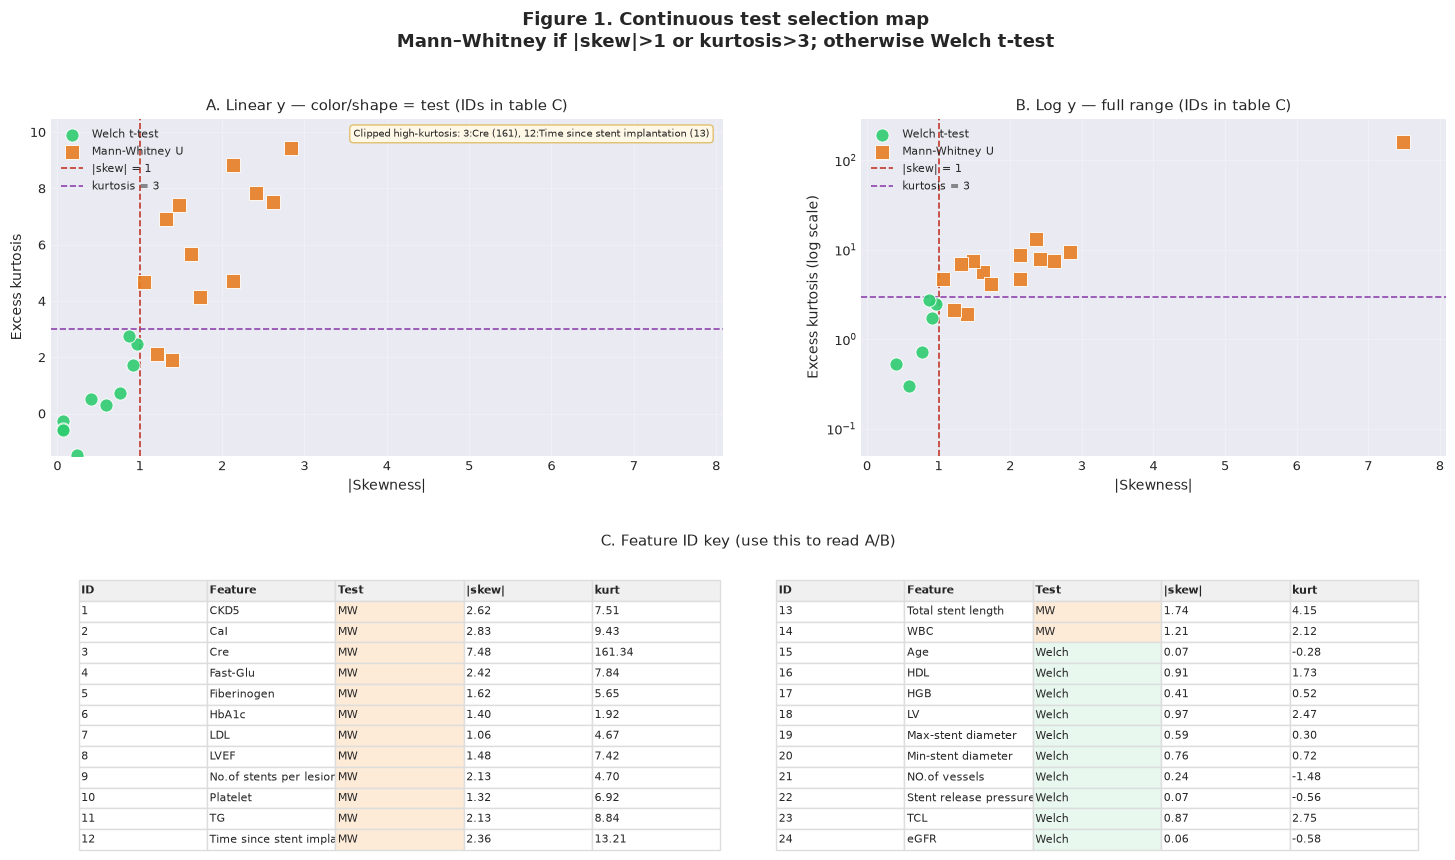

✓ Saved: paper_fig1_test_selection_map.png

Table R — Test-choice rationale (all continuous features)


,ID,Feature,Chosen test,Skewness,Kurtosis,Var. ratio,Why this test,p (raw),q (FDR),Sig
0,1,CKD5,Mann-Whitney U,2.62,7.51,1.32,Heavy skew/tails (|skew|>1 or kurt>3) → MW,1.19e-05,5.69e-05,***
1,2,CaI,Mann-Whitney U,2.83,9.43,1.37,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0507,0.0869,ns
2,3,Cre,Mann-Whitney U,7.48,161.34,1.70,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.8785,0.9384,ns
3,4,Fast-Glu,Mann-Whitney U,2.42,7.84,2.13,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0246,0.0536,ns
4,5,Fiberinogen,Mann-Whitney U,1.62,5.65,1.31,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0119,0.0286,*
5,6,HbA1c,Mann-Whitney U,1.40,1.92,1.11,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0002,0.0007,***
6,7,LDL,Mann-Whitney U,1.06,4.67,1.78,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.3274,0.4911,ns
7,8,LVEF,Mann-Whitney U,-1.48,7.42,1.51,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0333,0.0666,ns
8,9,No.of stents per lesion,Mann-Whitney U,2.13,4.70,2.03,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.0001,0.0006,***
9,10,Platelet,Mann-Whitney U,1.32,6.92,1.24,Heavy skew/tails (|skew|>1 or kurt>3) → MW,0.8160,0.9384,ns


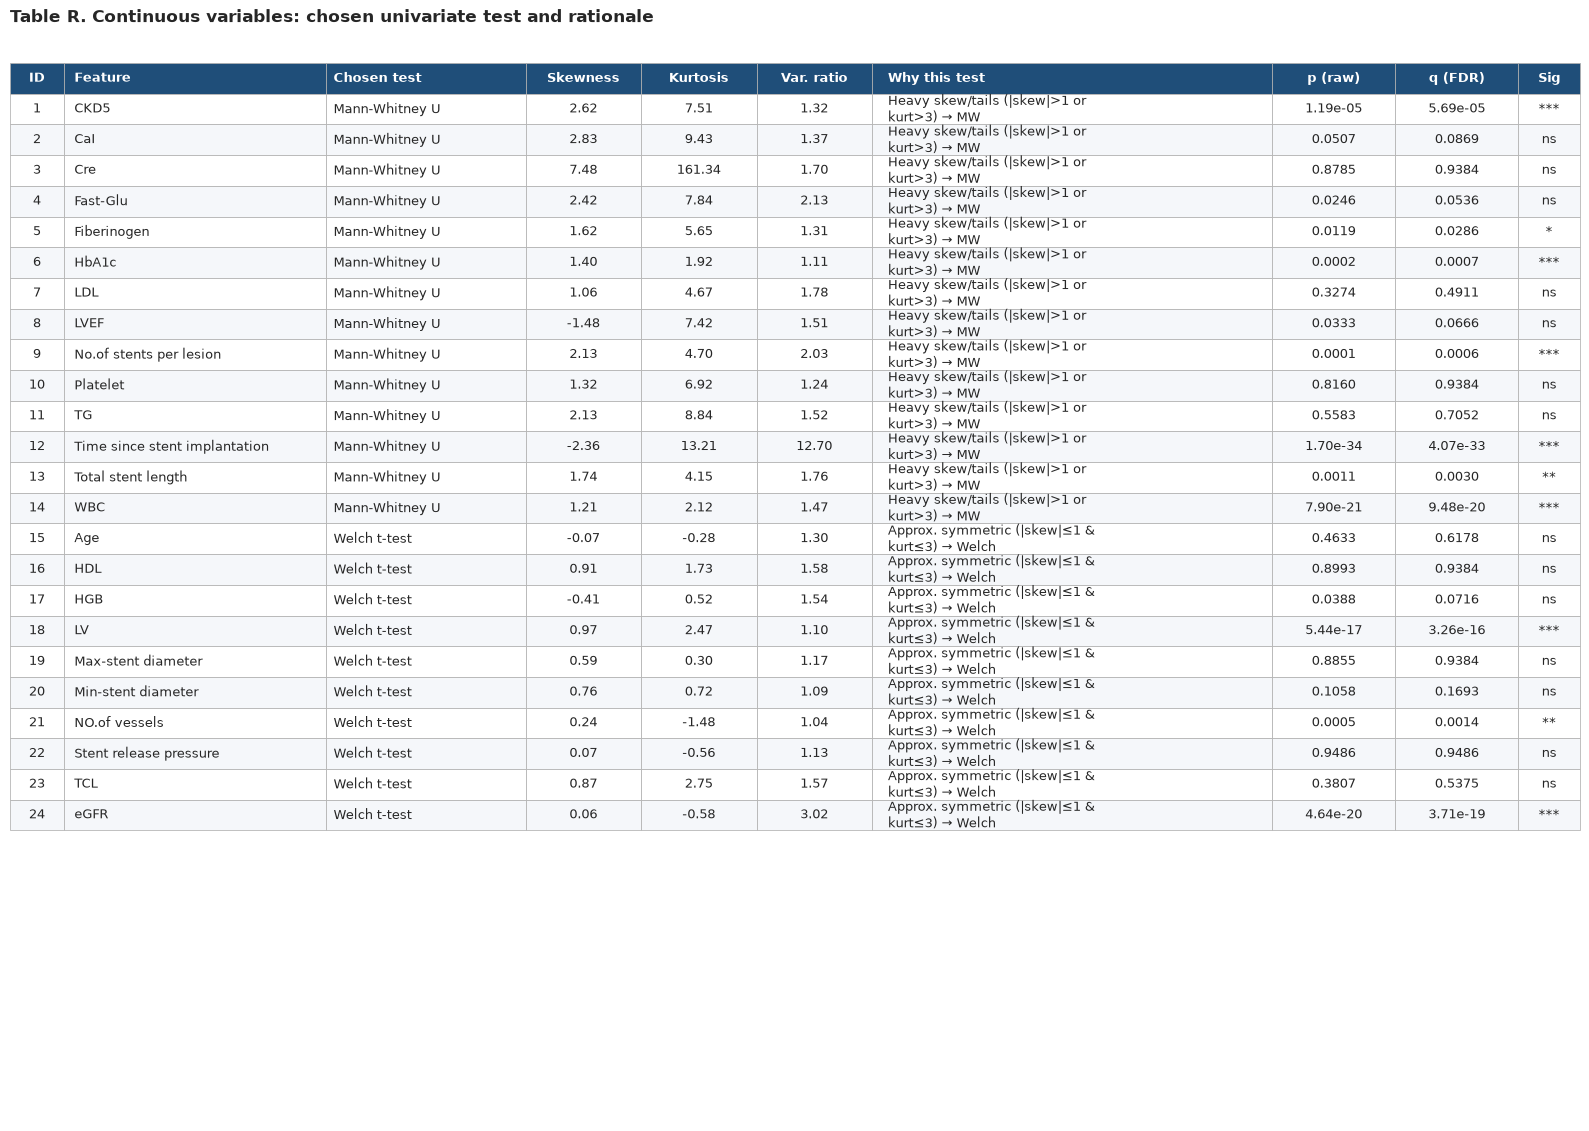

✓ Saved table figure: paper_table_test_rationale.png  (16.0×11.4 in)


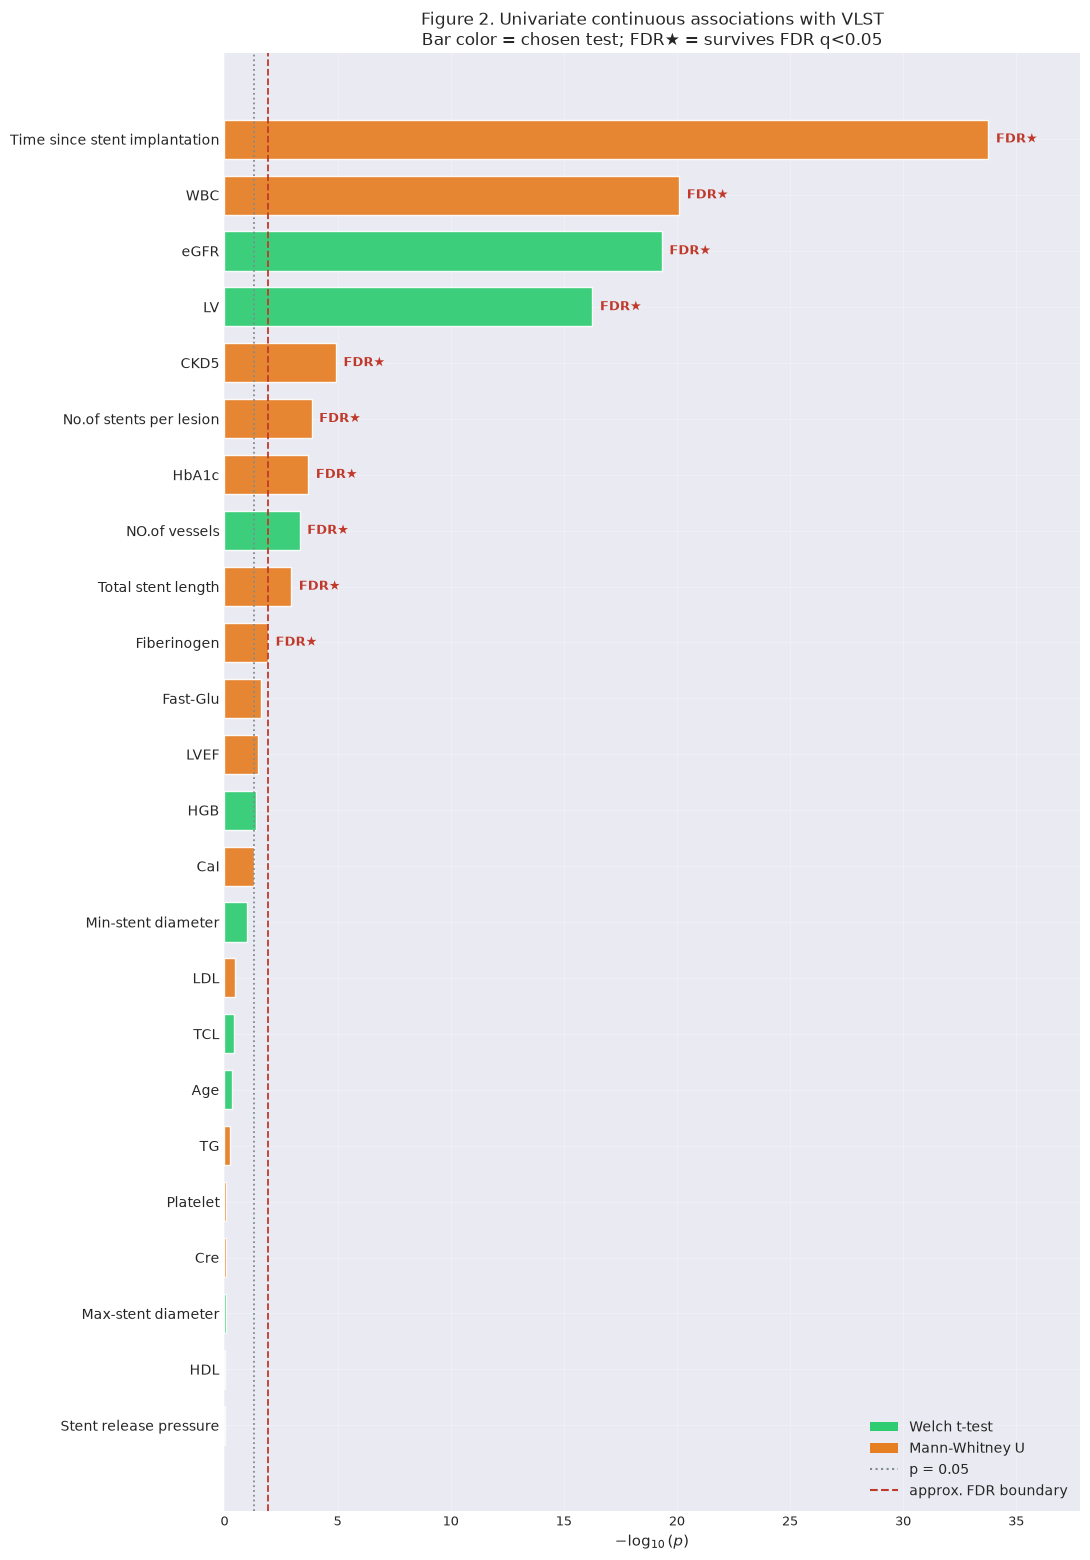

✓ Saved: paper_fig2_univariate_significance.png

Table 1 — Continuous univariate associations with VLST


,Feature,Test,Rationale,Direction,Effect size,ES,Δ mean,Δ median,p,q (FDR),Sig,Note
0,Time since stent implantation,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=2.36, kurt=13.21",Negative,Mann-Whitney r,-0.170,-572.05,-683.00,1.70e-34,4.07e-33,***,Time-at-risk / structural
1,WBC,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=1.21, kurt=2.12",Positive,Mann-Whitney r,0.130,3.75,3.82,7.90e-21,9.48e-20,***,
2,eGFR,Welch t-test,"approx symmetric → Welch; |skew|=0.06, kurt=-0.58",Negative,Cohen's d,-0.712,-24.15,-17.58,4.64e-20,3.71e-19,***,
3,LV,Welch t-test,"approx symmetric → Welch; |skew|=0.97, kurt=2.47",Positive,Cohen's d,1.127,4.56,4.00,5.44e-17,3.26e-16,***,
4,CKD5,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=2.62, kurt=7.51",Positive,Mann-Whitney r,0.040,0.18,0.00,1.19e-05,5.69e-05,***,
5,No.of stents per lesion,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=2.13, kurt=4.70",Positive,Mann-Whitney r,0.037,0.21,0.00,0.0001,0.0006,***,
6,HbA1c,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=1.40, kurt=1.92",Positive,Mann-Whitney r,0.052,0.47,1.05,0.0002,0.0007,***,
7,NO.of vessels,Welch t-test,"approx symmetric → Welch; |skew|=0.24, kurt=-1.48",Positive,Cohen's d,0.388,0.32,0.00,0.0005,0.0014,**,
8,Total stent length,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=1.74, kurt=4.15",Positive,Mann-Whitney r,0.045,6.76,2.00,0.0011,0.0030,**,
9,Fiberinogen,Mann-Whitney U,"skew>1 or kurt>3 → MW; |skew|=1.62, kurt=5.65",Positive,Mann-Whitney r,0.035,0.20,0.17,0.0119,0.0286,*,


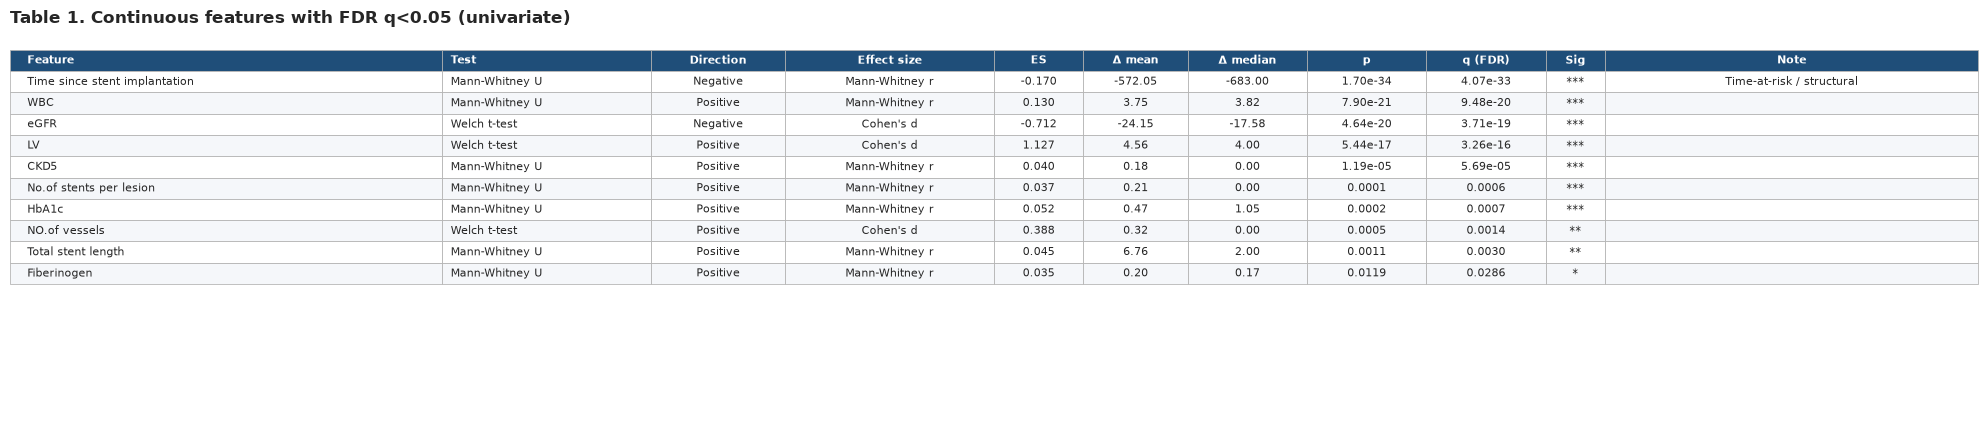

✓ Saved table figure: paper_table1_continuous_fdr.png  (20.0×4.3 in)


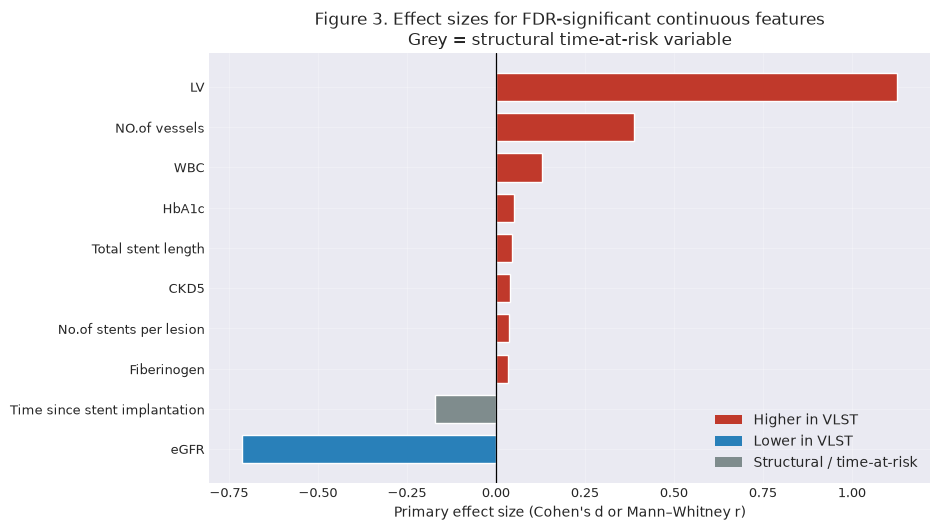

✓ Saved: paper_fig3_continuous_effect_sizes.png

Table 2 — Binary univariate associations with VLST (top by p shown in figure if many)


,Feature,Test,OR,RR,Phi,VLST% (1),VLST% (0),p,q (FDR),Sig
0,1.1:1Post dilation,Chi-square,0.187,0.191,-0.089,0.56,2.92,1.30e-10,3.69e-09,***
1,No postdilation,Chi-square,5.355,5.228,0.089,2.92,0.56,1.30e-10,3.69e-09,***
2,CKD90,Chi-square,2.625,2.567,0.063,3.59,1.40,6.55e-06,0.0001,***
3,Previous PCI,Fisher exact,6.485,5.958,0.085,9.62,1.61,1.25e-05,0.0002,***
4,3-vessel disease,Chi-square,2.169,2.135,0.052,2.87,1.34,0.0002,0.0021,**
5,Clopidogrel,Chi-square,0.503,0.509,-0.043,1.17,2.29,0.0022,0.0209,*
6,Diabetes,Chi-square,1.889,1.865,0.042,2.71,1.45,0.0028,0.0226,*
7,PES,Chi-square,2.158,2.133,0.040,2.12,1.00,0.0044,0.0315,*
8,Multi-vessel CAD,Chi-square,1.890,1.870,0.038,2.19,1.17,0.0062,0.0351,*
9,Single-vessel disease,Chi-square,0.529,0.535,-0.038,1.17,2.19,0.0062,0.0351,*


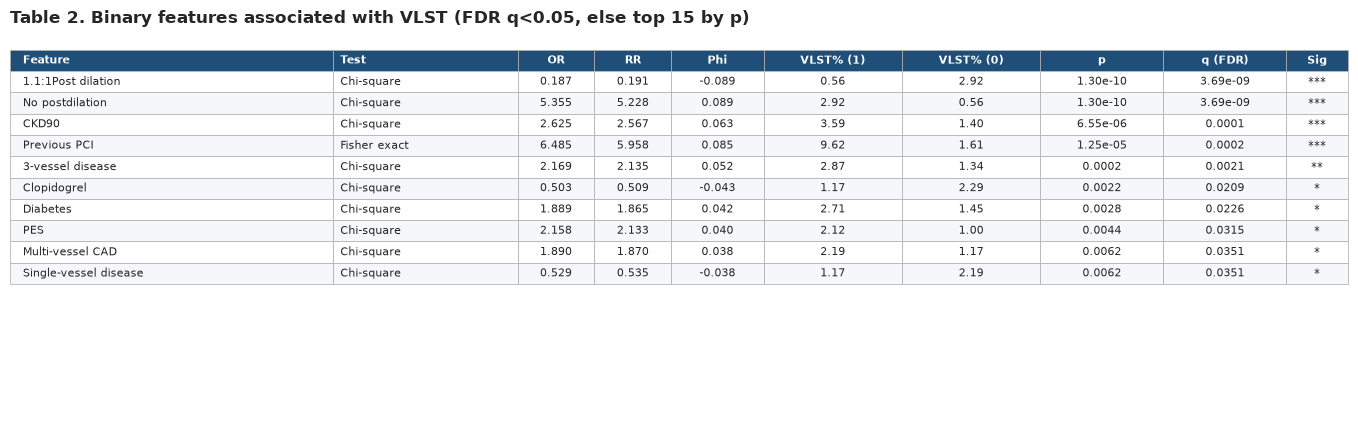

✓ Saved table figure: paper_table2_binary_fdr.png  (13.7×4.3 in)


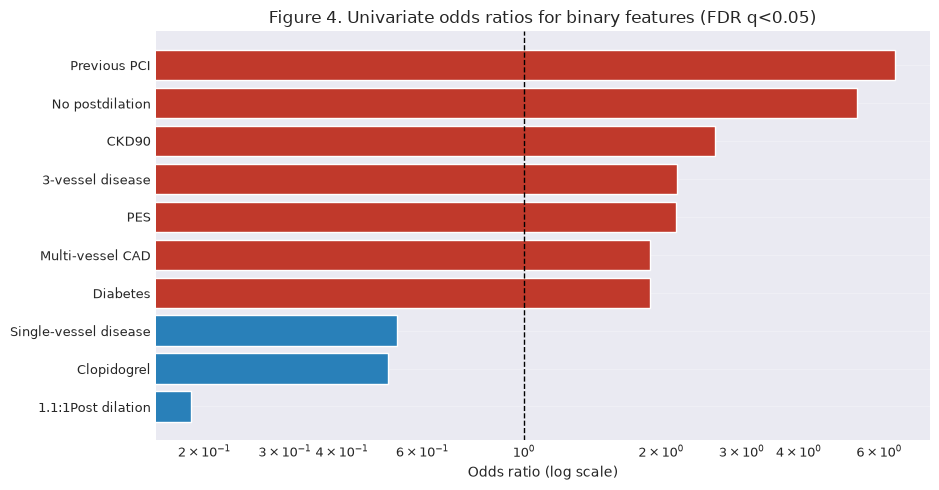

✓ Saved: paper_fig4_binary_odds_ratios.png

Table 3 — Categorical association with VLST


,Feature,Test,Levels used,Chi-square,df,Cramér's V,p,q (FDR),Sig
0,Stent type-SES,Chi-square,9,44.90,8,0.093,3.85e-07,3.85e-07,***


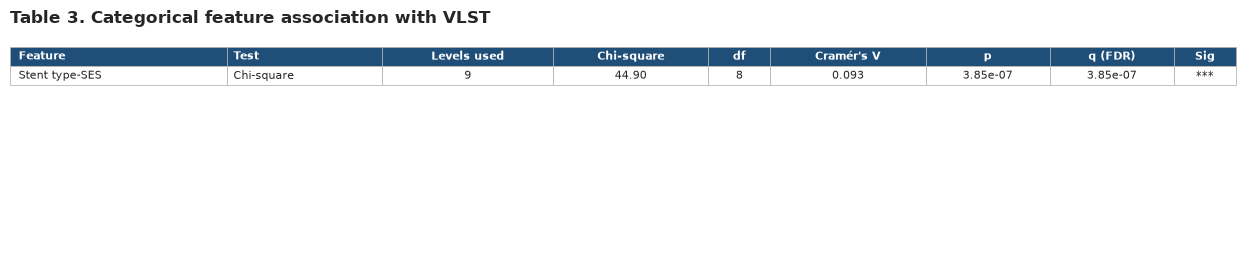

✓ Saved table figure: paper_table3_categorical.png  (12.6×2.8 in)


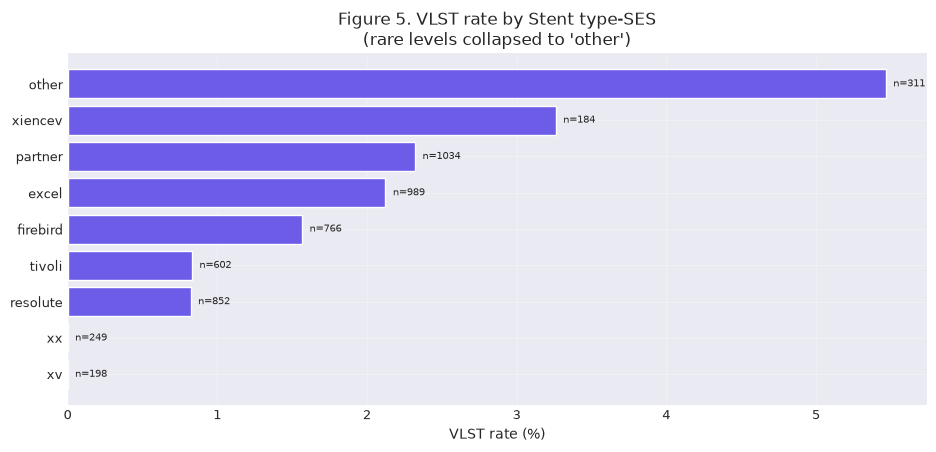

✓ Saved: paper_fig5_categorical_rates_Stent_type-SES.png

--------------------------------------------------------------------------------
Multivariable logistic regression (exploratory adjusted associations)
--------------------------------------------------------------------------------
Model n=5,185, events=92, predictors=17 (excluded: Time since stent implantation).

Table 4 — Multivariable logistic regression (exploratory)


,Feature,Type,Univariate OR,Adjusted OR,95% CI
0,WBC,continuous (per 1 SD),2.694,3.002,"[2.424, 4.225]"
1,eGFR,continuous (per 1 SD),0.334,0.113,"[0.060, 0.158]"
2,LV,continuous (per 1 SD),3.116,3.282,"[2.335, 5.254]"
3,CKD5,continuous (per 1 SD),1.391,0.156,"[0.023, 0.285]"
4,No.of stents per lesion,continuous (per 1 SD),1.379,1.297,"[0.693, 2.177]"
5,HbA1c,continuous (per 1 SD),1.367,0.870,"[0.569, 1.280]"
6,NO.of vessels,continuous (per 1 SD),1.456,1.498,"[0.774, 3.392]"
7,Total stent length,continuous (per 1 SD),1.391,1.127,"[0.658, 2.269]"
8,Fiberinogen,continuous (per 1 SD),1.220,1.045,"[0.804, 1.348]"
9,1.1:1Post dilation,binary,0.187,0.144,"[0.040, 0.245]"


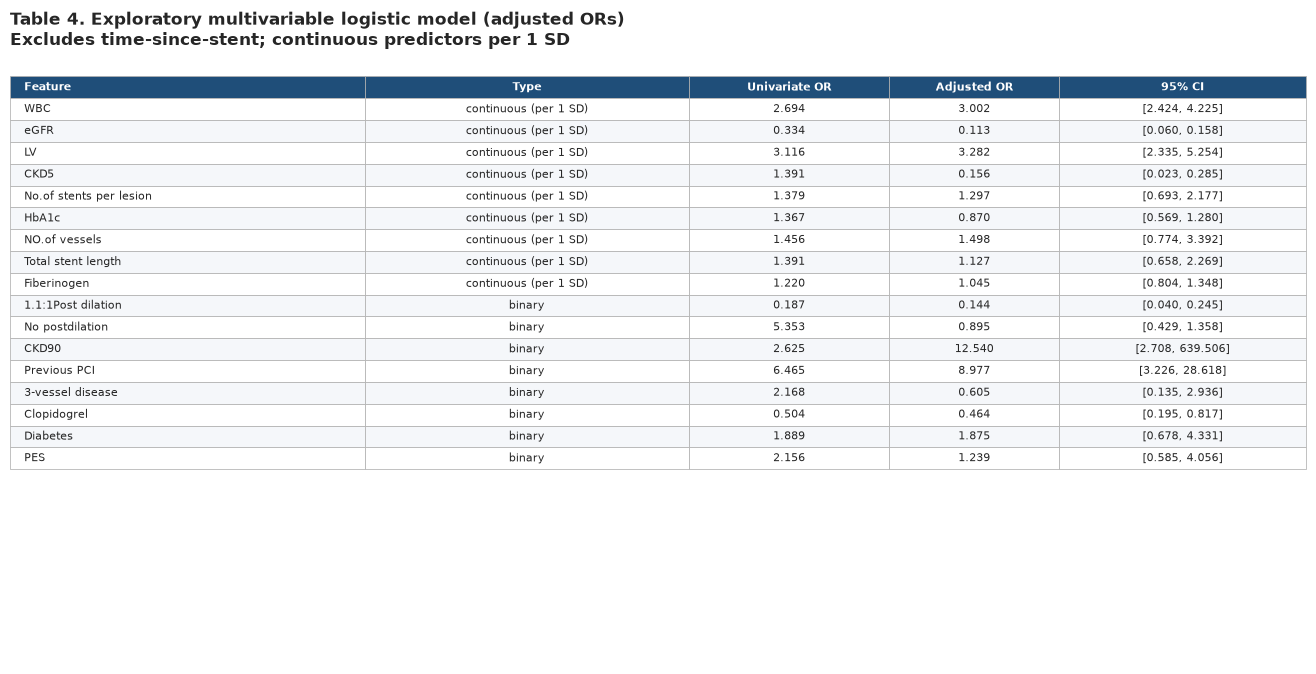

✓ Saved table figure: paper_table4_multivariable_or.png  (13.3×6.8 in)


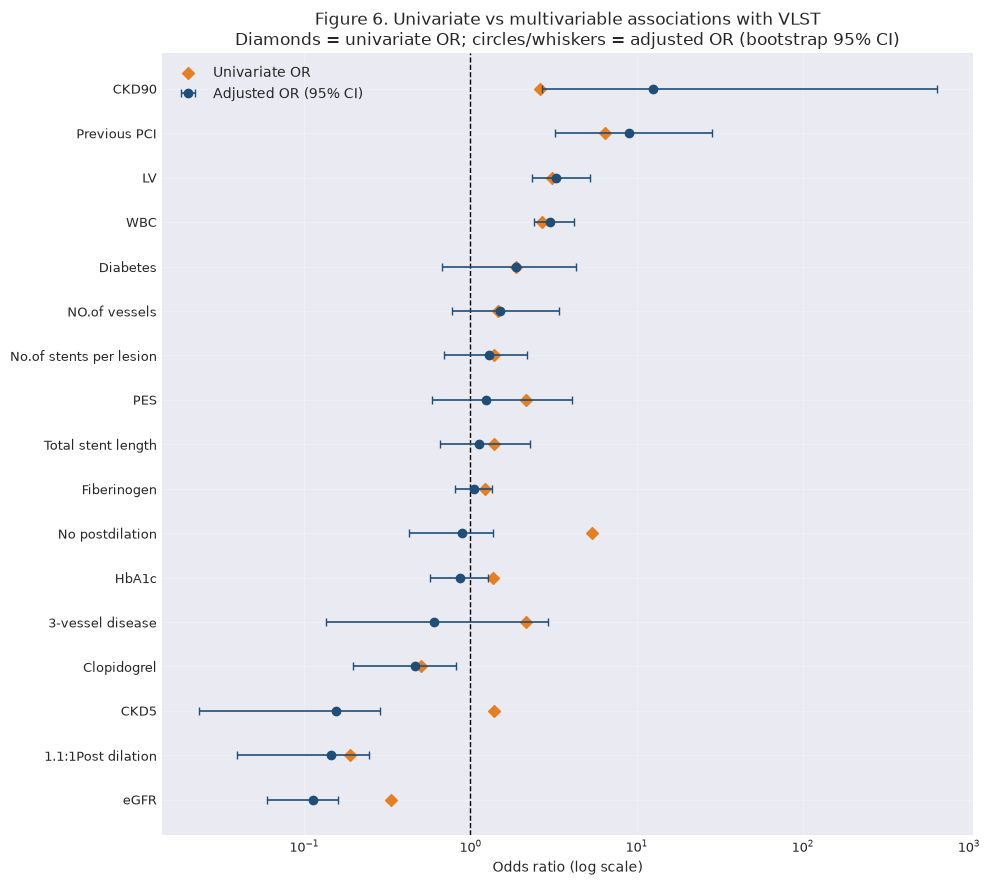

✓ Saved: paper_fig6_uni_vs_multivariable_or.png | paper_table4_multivariable_or.csv
Caveat: exploratory multivariable screening with class imbalance; not a causal model. Prefer reporting FDR univariate + this adjusted panel together.

✓ Paper-ready formal results finished.
Outputs written under: ../data/result/eda/plots


In [347]:
# 10f. FORMAL RESULTS — paper-ready tables, univariate rationale, multivariable panel
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)


import textwrap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from scipy.stats import chi2

print("=" * 80)
print("FORMAL RESULTS (PAPER-READY)")
print("=" * 80)

# -------------------- style helpers --------------------
PAPER_RC = {
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}


def _fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 1e-4:
        return f"{x:.2e}"
    return f"{x:.4f}"


def _fmt_num(x, nd=3):
    if pd.isna(x):
        return "—"
    return f"{float(x):.{nd}f}"


def _sig_stars(p):
    if pd.isna(p):
        return ""
    p = float(p)
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def render_paper_table(
    df,
    title,
    out_png,
    col_widths=None,
    wrap_cols=None,
    wrap_width=32,
    fontsize=8,
    fig_w=None,
    fig_h=None,
    left_align_cols=None,
):
    """Draw a clean matplotlib table with auto-sized / adjustable columns.

    Parameters
    ----------
    col_widths : dict[int|str, float] | None
        Relative widths (fractions of axes). Keys may be column index or name.
        If None, widths are inferred from header + cell content length.
    wrap_cols : list[str] | None
        Column names whose text is wrapped so long rationales fit.
    wrap_width : int
        Character width for wrapping.
    left_align_cols : list[str] | None
        Extra columns to left-align (Feature / Why / Chosen test / Test are default).
    fig_w, fig_h : float | None
        Override figure size (inches).
    """
    if df is None or df.empty:
        print(f"(skip table) {title}: empty")
        return

    plot_df = df.copy().astype(object)
    wrap_cols = list(wrap_cols or [])
    for col in wrap_cols:
        if col in plot_df.columns:
            plot_df[col] = [
                "\n".join(textwrap.wrap(str(v), width=wrap_width))
                if pd.notna(v) and str(v).strip()
                else "—"
                for v in plot_df[col]
            ]

    n_rows, n_cols = plot_df.shape
    cols = list(plot_df.columns)

    # Infer relative column widths from content (including wrapped lines)
    char_w = []
    for col in cols:
        header_len = len(str(col))
        cell_lens = []
        for v in plot_df[col]:
            parts = str(v).split("\n")
            cell_lens.append(max((len(p) for p in parts), default=0))
        char_w.append(max(header_len, max(cell_lens) if cell_lens else 0, 3))
    # Soft floor/cap so tiny numeric cols don't vanish and huge text doesn't dominate
    char_w = [min(max(w, 4), 42) for w in char_w]
    total_chars = float(sum(char_w))
    widths = {i: char_w[i] / total_chars for i in range(n_cols)}

    # Resolve user overrides (by index or name), then renormalize
    if col_widths:
        for k, w in col_widths.items():
            idx = cols.index(k) if isinstance(k, str) else int(k)
            widths[idx] = float(w)
        s = sum(widths[i] for i in range(n_cols))
        widths = {i: widths[i] / s for i in range(n_cols)}

    # Figure size grows with content; wrapped columns need more row height
    max_lines = 1
    for col in wrap_cols:
        if col in plot_df.columns:
            max_lines = max(
                max_lines,
                int(plot_df[col].astype(str).map(lambda s: s.count("\n") + 1).max()),
            )
    if fig_w is None:
        fig_w = max(12.0, 0.14 * total_chars + 1.5)
    if fig_h is None:
        # height tracks rows; wrap adds a modest bump (avoid giant empty tables)
        fig_h = max(2.8, 0.36 * (n_rows + 2) * (1.0 + 0.22 * max(0, max_lines - 1)))

    default_left = {"Feature", "Why this test", "Chosen test", "Test", "Rationale", "Level"}
    left_align_cols = set(left_align_cols or []) | (default_left & set(cols))
    left_idx = {cols.index(c) for c in left_align_cols if c in cols}

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=14, loc="left")
    tbl = ax.table(
        cellText=plot_df.values.tolist(),
        colLabels=cols,
        cellLoc="center",
        colLoc="center",
        loc="upper center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    row_scale = 1.15 + 0.35 * max(0, max_lines - 1)
    tbl.scale(1.0, row_scale)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.55)
        cell.set_edgecolor("#b0b0b0")
        cell.set_width(widths[c])
        cell.PAD = 0.04
        if c in left_idx:
            cell.set_text_props(ha="left")
        if r == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(
                color="white",
                fontweight="bold",
                ha="left" if c in left_idx else "center",
            )
        elif r % 2 == 0:
            cell.set_facecolor("#f5f7fa")
        else:
            cell.set_facecolor("white")

    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Saved table figure: {Path(out_png).name}  ({fig_w:.1f}×{fig_h:.1f} in)")


def why_test_row(row):
    sk = row.get("Skewness", np.nan)
    kurt = row.get("Kurtosis (excess)", np.nan)
    test = row.get("Test", "")
    bits = []
    if pd.notna(sk):
        bits.append(f"|skew|={abs(sk):.2f}")
    if pd.notna(kurt):
        bits.append(f"kurt={kurt:.2f}")
    rule = "skew>1 or kurt>3 → MW" if test == "Mann-Whitney U" else "approx symmetric → Welch"
    return f"{rule}; " + ", ".join(bits)


with plt.rc_context(PAPER_RC):
    # ============================================================
    # FIGURE 1 — Test-choice rationale (clean scatter + ID table; no overlapping names)
    # ============================================================
    # Prefer section-10 screening frame; fall back if a later cell overwrote shape_df
    sdf = None
    if "shape_df" in globals() and isinstance(shape_df, pd.DataFrame) and not shape_df.empty:
        sdf = shape_df.copy()
    if sdf is None or "Primary test" not in sdf.columns:
        if (
            "continuous_test_df" in globals()
            and isinstance(continuous_test_df, pd.DataFrame)
            and not continuous_test_df.empty
            and {"Feature", "Skewness", "Kurtosis (excess)", "Test"}.issubset(continuous_test_df.columns)
        ):
            sdf = continuous_test_df[
                ["Feature", "Skewness", "Kurtosis (excess)", "Test"]
            ].copy()
            if "Variance ratio" in continuous_test_df.columns:
                sdf["Variance ratio"] = continuous_test_df["Variance ratio"].values
            else:
                sdf["Variance ratio"] = np.nan
            sdf = sdf.rename(columns={"Test": "Primary test"})
        elif sdf is not None and {"Skewness", "Kurtosis (excess)"}.issubset(sdf.columns):
            sdf = sdf.copy()
            sdf["Primary test"] = np.where(
                (sdf["Skewness"].abs() > 1.0) | (sdf["Kurtosis (excess)"] > 3.0),
                "Mann-Whitney U",
                "Welch t-test",
            )
        else:
            sdf = None

    if sdf is not None and not sdf.empty and "Primary test" in sdf.columns:
        sdf = sdf.copy()
        sdf["abs_skew"] = sdf["Skewness"].abs()
        sdf["kurt"] = sdf["Kurtosis (excess)"]
        # Sort for stable IDs: Welch first (left region), then MW; alpha within
        sdf = sdf.sort_values(["Primary test", "Feature"]).reset_index(drop=True)
        sdf["ID"] = np.arange(1, len(sdf) + 1)

        color_map = {"Welch t-test": "#2ecc71", "Mann-Whitney U": "#e67e22"}
        marker_map = {"Welch t-test": "o", "Mann-Whitney U": "s"}

        # Layout: scatter (linear + log-y) | ID table
        fig = plt.figure(figsize=(18, 9.5))
        gs = fig.add_gridspec(
            2, 2,
            height_ratios=[1.15, 1.0],
            width_ratios=[1.15, 1.0],
            hspace=0.32,
            wspace=0.22,
        )
        ax_lin = fig.add_subplot(gs[0, 0])
        ax_log = fig.add_subplot(gs[0, 1])
        ax_tab = fig.add_subplot(gs[1, :])

        def _draw_scatter(ax_, y_log=False):
            for test, color in color_map.items():
                sub = sdf[sdf["Primary test"] == test]
                y = sub["kurt"].clip(lower=0) + 1e-3 if y_log else sub["kurt"]
                ax_.scatter(
                    sub["abs_skew"],
                    y,
                    c=color,
                    marker=marker_map[test],
                    s=90,
                    alpha=0.9,
                    edgecolors="white",
                    linewidths=0.7,
                    label=test,
                    zorder=3,
                )
                # No point labels here — IDs live only in panel C table (avoids overlap)
            ax_.axvline(1.0, color="#c0392b", ls="--", lw=1.2, label="|skew| = 1")
            thr_y = 3.0 + 1e-3 if y_log else 3.0
            ax_.axhline(thr_y, color="#8e44ad", ls="--", lw=1.2, label="kurtosis = 3")
            ax_.set_xlabel("|Skewness|")
            ax_.set_ylabel("Excess kurtosis" + (" (log scale)" if y_log else ""))
            if y_log:
                ax_.set_yscale("log")
                ax_.set_ylim(bottom=0.05)
            else:
                # focus on bulk; list clipped extremes in corner
                y_hi = max(8.0, float(np.nanpercentile(sdf["kurt"], 85)) * 1.25)
                ax_.set_ylim(-1.5, y_hi)
                clipped = sdf[sdf["kurt"] > y_hi]
                if not clipped.empty:
                    note = "Clipped high-kurtosis: " + ", ".join(
                        f"{int(r['ID'])}:{r['Feature']} ({r['kurt']:.0f})" for _, r in clipped.iterrows()
                    )
                    ax_.text(
                        0.98, 0.97, note,
                        transform=ax_.transAxes, ha="right", va="top", fontsize=7.5,
                        bbox=dict(boxstyle="round,pad=0.35", facecolor="#fff8e7", edgecolor="#e0c070"),
                    )
            ax_.set_xlim(-0.08, max(2.0, float(sdf["abs_skew"].max()) * 1.08))

        _draw_scatter(ax_lin, y_log=False)
        ax_lin.set_title("A. Linear y — color/shape = test (IDs in table C)", fontsize=11)
        ax_lin.legend(frameon=False, loc="upper left", fontsize=8)

        _draw_scatter(ax_log, y_log=True)
        ax_log.set_title("B. Log y — full range (IDs in table C)", fontsize=11)
        ax_log.legend(frameon=False, loc="upper left", fontsize=8)

        # C. Full feature key as a real table (never overlaps points)
        ax_tab.axis("off")
        ax_tab.set_title("C. Feature ID key (use this to read A/B)", fontsize=11, pad=8)
        tab_df = sdf[["ID", "Feature", "Primary test", "abs_skew", "kurt"]].copy()
        tab_df["Primary test"] = tab_df["Primary test"].map(
            {"Welch t-test": "Welch", "Mann-Whitney U": "MW"}
        )
        tab_df["abs_skew"] = tab_df["abs_skew"].map(lambda x: f"{x:.2f}")
        tab_df["kurt"] = tab_df["kurt"].map(lambda x: f"{x:.2f}")
        tab_df.columns = ["ID", "Feature", "Test", "|skew|", "kurt"]
        # split into two side-by-side tables if many rows
        n = len(tab_df)
        mid = int(np.ceil(n / 2))
        for col_i, part in enumerate([tab_df.iloc[:mid], tab_df.iloc[mid:]]):
            if part.empty:
                continue
            left = 0.02 if col_i == 0 else 0.52
            tbl = ax_tab.table(
                cellText=part.values.tolist(),
                colLabels=list(part.columns),
                cellLoc="left",
                colLoc="left",
                bbox=[left, 0.0, 0.46, 0.92],
            )
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(8)
            for (r, c), cell in tbl.get_celld().items():
                cell.set_edgecolor("#dddddd")
                cell.PAD = 0.02
                if r == 0:
                    cell.set_facecolor("#f0f0f0")
                    cell.set_text_props(fontweight="bold")
                else:
                    test_val = part.iloc[r - 1]["Test"] if c == 2 else None
                    if c == 2 and test_val == "Welch":
                        cell.set_facecolor("#e8f8ef")
                    elif c == 2 and test_val == "MW":
                        cell.set_facecolor("#fdebd8")

        fig.suptitle(
            "Figure 1. Continuous test selection map\n"
            "Mann–Whitney if |skew|>1 or kurtosis>3; otherwise Welch t-test",
            fontsize=13,
            fontweight="bold",
            y=0.995,
        )
        fig.savefig(
            str(PLOT_DIR / "paper_fig1_test_selection_map.png"),
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        plt.show()
        print("✓ Saved: paper_fig1_test_selection_map.png")

        # Rationale table for all continuous features
        # Rationale table for all continuous features
        rationale = sdf.copy()
        if "continuous_test_df" in globals() and not continuous_test_df.empty:
            merge_cols = [
                "Feature",
                "P-value",
                "p_fdr_bh",
                "Test",
                "Primary effect size",
                "Primary effect size name",
            ]
            merge_cols = [c for c in merge_cols if c in continuous_test_df.columns]
            rationale = rationale.merge(
                continuous_test_df[merge_cols], on="Feature", how="left", suffixes=("", "_test")
            )
            if "Test_test" in rationale.columns:
                rationale["Test"] = rationale["Test_test"].fillna(rationale.get("Primary test"))
        _chosen = (
            rationale["Primary test"]
            if "Primary test" in rationale.columns
            else rationale["Test"]
            if "Test" in rationale.columns
            else pd.Series([""] * len(rationale))
        )
        if "Variance ratio" not in rationale.columns:
            rationale["Variance ratio"] = np.nan
        rationale_show = pd.DataFrame(
            {
                "ID": rationale.get("ID", np.arange(1, len(rationale) + 1)),
                "Feature": rationale["Feature"],
                "Chosen test": _chosen,
                "Skewness": rationale["Skewness"].map(lambda v: _fmt_num(v, 2)),
                "Kurtosis": rationale["Kurtosis (excess)"].map(lambda v: _fmt_num(v, 2)),
                "Var. ratio": rationale["Variance ratio"].map(lambda v: _fmt_num(v, 2)),
                "Why this test": [
                    (
                        "Heavy skew/tails (|skew|>1 or kurt>3) → MW"
                        if t == "Mann-Whitney U"
                        else "Approx. symmetric (|skew|≤1 & kurt≤3) → Welch"
                    )
                    for t in _chosen
                ],
                "p (raw)": rationale["P-value"].map(_fmt_p) if "P-value" in rationale.columns else "—",
                "q (FDR)": rationale["p_fdr_bh"].map(_fmt_p) if "p_fdr_bh" in rationale.columns else "—",
                "Sig": [
                    _sig_stars(p)
                    for p in (
                        rationale["p_fdr_bh"]
                        if "p_fdr_bh" in rationale.columns
                        else [np.nan] * len(rationale)
                    )
                ],
            }
        ).sort_values(["Chosen test", "Feature"]).reset_index(drop=True)
        print("\nTable R — Test-choice rationale (all continuous features)")
        display(rationale_show.reset_index(drop=True))
        rationale_show.to_csv(str(PLOT_DIR / "paper_table_test_rationale.csv"), index=False)
        render_paper_table(
            rationale_show,
            "Table R. Continuous variables: chosen univariate test and rationale",
            str(PLOT_DIR / "paper_table_test_rationale.png"),
            wrap_cols=["Why this test", "Feature"],
            wrap_width=36,
            fontsize=9,
            fig_w=16,
            fig_h=None,  # auto from rows + wrap
            col_widths={
                "ID": 0.035,
                "Feature": 0.17,
                "Chosen test": 0.13,
                "Skewness": 0.075,
                "Kurtosis": 0.075,
                "Var. ratio": 0.075,
                "Why this test": 0.26,
                "p (raw)": 0.08,
                "q (FDR)": 0.08,
                "Sig": 0.04,
            },
        )
    else:
        print("Run shape screening (10a) for Figure 1 / Table R.")

    # ============================================================
    # FIGURE 2 — Univariate significance (horizontal bars = readable names)
    # ============================================================

    if "continuous_test_df" in globals() and not continuous_test_df.empty:
        cdf = continuous_test_df.copy().sort_values("P-value", ascending=True)
        cdf["neglog10p"] = -np.log10(cdf["P-value"].clip(lower=1e-300))
        color_map = {"Welch t-test": "#2ecc71", "Mann-Whitney U": "#e67e22"}
        cdf["color"] = cdf["Test"].map(color_map).fillna("#7f8c8d")
        fdr_hits = set(cdf.loc[cdf["p_fdr_bh"] < 0.05, "Feature"]) if "p_fdr_bh" in cdf.columns else set()

        # Tall figure so every feature name has its own row
        fig_h = max(9.0, 0.55 * len(cdf) + 2.5)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        y = np.arange(len(cdf))
        ax.barh(
            y,
            cdf["neglog10p"],
            color=cdf["color"].tolist(),
            edgecolor="white",
            height=0.7,
            alpha=0.92,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(cdf["Feature"].tolist(), fontsize=10)
        ax.invert_yaxis()  # strongest at top
        ax.axvline(-np.log10(0.05), color="#7f8c8d", ls=":", lw=1.3, label="p = 0.05")
        if fdr_hits:
            thr = cdf.loc[cdf["Feature"].isin(fdr_hits), "P-value"].max()
            ax.axvline(-np.log10(thr), color="#c0392b", ls="--", lw=1.3, label="approx. FDR boundary")
        for i, (_, r) in enumerate(cdf.iterrows()):
            if r["Feature"] in fdr_hits:
                ax.text(
                    r["neglog10p"] + max(0.12, 0.01 * cdf["neglog10p"].max()),
                    i,
                    "FDR★",
                    va="center",
                    fontsize=9,
                    color="#c0392b",
                    fontweight="bold",
                )
        ax.set_xlabel(r"$-\log_{10}(p)$", fontsize=11)
        ax.set_ylabel("")
        ax.set_title(
            "Figure 2. Univariate continuous associations with VLST\n"
            "Bar color = chosen test; FDR★ = survives FDR q<0.05",
            fontsize=12,
        )
        ax.legend(
            handles=[
                Patch(facecolor="#2ecc71", label="Welch t-test"),
                Patch(facecolor="#e67e22", label="Mann-Whitney U"),
                Line2D([0], [0], color="#7f8c8d", ls=":", label="p = 0.05"),
                Line2D([0], [0], color="#c0392b", ls="--", label="approx. FDR boundary"),
            ],
            frameon=False,
            loc="lower right",
        )
        ax.set_xlim(0, cdf["neglog10p"].max() * 1.12)
        ax.grid(axis="x", alpha=0.25)
        fig.tight_layout()
        fig.savefig(
            str(PLOT_DIR / "paper_fig2_univariate_significance.png"),
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        plt.show()
        print("✓ Saved: paper_fig2_univariate_significance.png")

        # Formal continuous table (all tested, with stars on FDR)
        # Formal continuous table (all tested, with stars on FDR)
        cont_table = pd.DataFrame(
            {
                "Feature": cdf["Feature"],
                "Test": cdf["Test"],
                "Rationale": cdf.apply(why_test_row, axis=1),
                "Direction": cdf.get("Direction (Spearman)", ""),
                "Effect size": cdf.get("Primary effect size name", ""),
                "ES": cdf.get("Primary effect size", pd.Series([np.nan] * len(cdf))).map(
                    lambda v: _fmt_num(v, 3)
                ),
                "Δ mean": cdf.get("Mean diff (VLST - no)", pd.Series([np.nan] * len(cdf))).map(
                    lambda v: _fmt_num(v, 2)
                ),
                "Δ median": cdf.get(
                    "Median diff (VLST - no)", pd.Series([np.nan] * len(cdf))
                ).map(lambda v: _fmt_num(v, 2)),
                "p": cdf["P-value"].map(_fmt_p),
                "q (FDR)": cdf["p_fdr_bh"].map(_fmt_p) if "p_fdr_bh" in cdf.columns else "—",
                "Sig": cdf["p_fdr_bh"].map(_sig_stars)
                if "p_fdr_bh" in cdf.columns
                else cdf["P-value"].map(_sig_stars),
                "Note": np.where(
                    cdf["Feature"].astype(str).str.contains("Time since stent", case=False, na=False),
                    "Time-at-risk / structural",
                    "",
                ),
            }
        )
        print("\nTable 1 — Continuous univariate associations with VLST")
        display(cont_table.reset_index(drop=True))
        cont_table.to_csv(str(PLOT_DIR / "paper_table1_continuous_univariate.csv"), index=False)
        main_cont = cont_table[cont_table["Sig"].isin(["*", "**", "***"])].copy()
        render_paper_table(
            main_cont.drop(columns=["Rationale"]) if "Rationale" in main_cont.columns else main_cont,
            "Table 1. Continuous features with FDR q<0.05 (univariate)",
            str(PLOT_DIR / "paper_table1_continuous_fdr.png"),
        )
    else:
        print("Run 10b for continuous formal outputs.")

    # ============================================================
    # FIGURE 3 — Continuous effect sizes (FDR hits)
    # ============================================================
    if "continuous_test_df" in globals() and not continuous_test_df.empty and "p_fdr_bh" in continuous_test_df.columns:
        hits = continuous_test_df[continuous_test_df["p_fdr_bh"] < 0.05].copy()
        if not hits.empty and "Primary effect size" in hits.columns:
            hits["ES"] = pd.to_numeric(hits["Primary effect size"], errors="coerce")
            hits = hits.dropna(subset=["ES"]).sort_values("ES")
            colors = [
                "#7f8c8d"
                if "Time since stent" in str(f)
                else ("#c0392b" if es > 0 else "#2980b9")
                for f, es in zip(hits["Feature"], hits["ES"])
            ]
            fig, ax = plt.subplots(figsize=(9.5, max(3.8, 0.42 * len(hits) + 1.2)))
            ax.barh(hits["Feature"], hits["ES"], color=colors, edgecolor="white", height=0.7)
            ax.axvline(0, color="black", lw=0.9)
            ax.set_xlabel("Primary effect size (Cohen's d or Mann–Whitney r)")
            ax.set_title("Figure 3. Effect sizes for FDR-significant continuous features\nGrey = structural time-at-risk variable")
            ax.legend(
                handles=[
                    Patch(facecolor="#c0392b", label="Higher in VLST"),
                    Patch(facecolor="#2980b9", label="Lower in VLST"),
                    Patch(facecolor="#7f8c8d", label="Structural / time-at-risk"),
                ],
                frameon=False,
                loc="lower right",
            )
            fig.tight_layout()
            fig.savefig(str(PLOT_DIR / "paper_fig3_continuous_effect_sizes.png"), dpi=300, bbox_inches="tight")
            plt.show()
            print("✓ Saved: paper_fig3_continuous_effect_sizes.png")

    # ============================================================
    # FIGURE 4 + Table 2 — Binary FDR / OR forest
    # ============================================================
    if "binary_test_df" in globals() and not binary_test_df.empty:
        bdf = binary_test_df.copy().sort_values("P-value")
        bin_table = pd.DataFrame(
            {
                "Feature": bdf["Feature"],
                "Test": bdf.get("Recommended test", ""),
                "OR": bdf.get("Odds Ratio", pd.Series([np.nan] * len(bdf))).map(lambda v: _fmt_num(v, 3)),
                "RR": bdf.get("Relative Risk", pd.Series([np.nan] * len(bdf))).map(lambda v: _fmt_num(v, 3)),
                "Phi": bdf.get("Phi", pd.Series([np.nan] * len(bdf))).map(lambda v: _fmt_num(v, 3)),
                "VLST% (1)": (100 * bdf.get("VLST rate (feature=1)", pd.Series([np.nan] * len(bdf)))).map(lambda v: _fmt_num(v, 2)),
                "VLST% (0)": (100 * bdf.get("VLST rate (feature=0)", pd.Series([np.nan] * len(bdf)))).map(lambda v: _fmt_num(v, 2)),
                "p": bdf["P-value"].map(_fmt_p),
                "q (FDR)": bdf["p_fdr_bh"].map(_fmt_p) if "p_fdr_bh" in bdf.columns else "—",
                "Sig": bdf["p_fdr_bh"].map(_sig_stars) if "p_fdr_bh" in bdf.columns else bdf["P-value"].map(_sig_stars),
            }
        )
        print("\nTable 2 — Binary univariate associations with VLST (top by p shown in figure if many)")
        # show FDR hits in display; save full csv
        bin_fdr = bin_table[bin_table["Sig"].isin(["*", "**", "***"])].copy()
        display((bin_fdr if not bin_fdr.empty else bin_table.head(20)).reset_index(drop=True))
        bin_table.to_csv(str(PLOT_DIR / "paper_table2_binary_univariate.csv"), index=False)
        render_paper_table(
            bin_fdr if not bin_fdr.empty else bin_table.head(15),
            "Table 2. Binary features associated with VLST (FDR q<0.05, else top 15 by p)",
            str(PLOT_DIR / "paper_table2_binary_fdr.png"),
        )

        plot_src = bdf[bdf["p_fdr_bh"] < 0.05] if "p_fdr_bh" in bdf.columns else bdf.nsmallest(15, "P-value")
        plot_src = plot_src.copy()
        plot_src["OR"] = pd.to_numeric(plot_src.get("Odds Ratio"), errors="coerce")
        plot_src = plot_src.dropna(subset=["OR"]).sort_values("OR")
        if not plot_src.empty:
            fig, ax = plt.subplots(figsize=(9.5, max(3.8, 0.38 * len(plot_src) + 1.2)))
            colors = ["#c0392b" if x >= 1 else "#2980b9" for x in plot_src["OR"]]
            ax.barh(plot_src["Feature"], plot_src["OR"], color=colors, edgecolor="white")
            ax.axvline(1.0, color="black", ls="--", lw=1)
            ax.set_xscale("log")
            ax.set_xlabel("Odds ratio (log scale)")
            ax.set_title("Figure 4. Univariate odds ratios for binary features (FDR q<0.05)")
            fig.tight_layout()
            fig.savefig(str(PLOT_DIR / "paper_fig4_binary_odds_ratios.png"), dpi=300, bbox_inches="tight")
            plt.show()
            print("✓ Saved: paper_fig4_binary_odds_ratios.png")
    else:
        print("Run binary tests for Table 2 / Figure 4.")

    # ============================================================
    # FIGURE 5 + Table 3 — Categorical
    # ============================================================
    if "categorical_test_df" in globals() and not categorical_test_df.empty:
        cat = categorical_test_df.copy()
        cat_table = pd.DataFrame(
            {
                "Feature": cat["Feature"],
                "Test": cat["Test"],
                "Levels used": cat.get("Levels used (after collapse)", ""),
                "Chi-square": cat.get("Chi-square", pd.Series([np.nan] * len(cat))).map(lambda v: _fmt_num(v, 2)),
                "df": cat.get("df", ""),
                "Cramér's V": cat.get("Cramer's V", pd.Series([np.nan] * len(cat))).map(lambda v: _fmt_num(v, 3)),
                "p": cat["P-value"].map(_fmt_p),
                "q (FDR)": cat["p_fdr_bh"].map(_fmt_p) if "p_fdr_bh" in cat.columns else "—",
                "Sig": cat["p_fdr_bh"].map(_sig_stars) if "p_fdr_bh" in cat.columns else cat["P-value"].map(_sig_stars),
            }
        )
        print("\nTable 3 — Categorical association with VLST")
        display(cat_table.reset_index(drop=True))
        cat_table.to_csv(str(PLOT_DIR / "paper_table3_categorical.csv"), index=False)
        render_paper_table(
            cat_table,
            "Table 3. Categorical feature association with VLST",
            str(PLOT_DIR / "paper_table3_categorical.png"),
        )

        if "categorical_level_tables" in globals() and categorical_level_tables:
            for col, level_df in categorical_level_tables.items():
                ld = level_df.copy().reset_index().rename(columns={level_df.index.name or level_df.columns[0]: "Level"})
                if "Level" not in ld.columns:
                    ld = level_df.copy().reset_index()
                    ld = ld.rename(columns={ld.columns[0]: "Level"})
                ld = ld.sort_values("VLST_rate", ascending=True)
                fig, ax = plt.subplots(figsize=(9.5, max(3.8, 0.38 * len(ld) + 1.2)))
                bars = ax.barh(ld["Level"].astype(str), ld["VLST_rate"] * 100, color="#6c5ce7", edgecolor="white")
                for bar, n in zip(bars, ld["n"]):
                    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f"n={int(n)}", va="center", fontsize=7)
                ax.set_xlabel("VLST rate (%)")
                ax.set_title(f"Figure 5. VLST rate by {col}\n(rare levels collapsed to 'other')")
                fig.tight_layout()
                safe = str(col).replace(" ", "_").replace("/", "_")
                fig.savefig(str(PLOT_DIR / f"paper_fig5_categorical_rates_{safe}.png"), dpi=300, bbox_inches="tight")
                plt.show()
                print(f"✓ Saved: paper_fig5_categorical_rates_{safe}.png")
    else:
        print("Run categorical tests (10c) for Table 3 / Figure 5.")

    # ============================================================
    # FIGURE 6 + Table 4 — Multivariable logistic (adjusted ORs)
    # ============================================================
    print("\n" + "-" * 80)
    print("Multivariable logistic regression (exploratory adjusted associations)")
    print("-" * 80)

    mv_ok = (
        "continuous_test_df" in globals()
        and isinstance(continuous_test_df, pd.DataFrame)
        and not continuous_test_df.empty
        and "p_fdr_bh" in continuous_test_df.columns
    )
    if mv_ok:
        cont_feats = continuous_test_df.loc[
            (continuous_test_df["p_fdr_bh"] < 0.05)
            & (~continuous_test_df["Feature"].astype(str).str.contains("Time since stent", case=False, na=False)),
            "Feature",
        ].tolist()
        bin_feats = []
        if "binary_test_df" in globals() and isinstance(binary_test_df, pd.DataFrame) and not binary_test_df.empty:
            if "p_fdr_bh" in binary_test_df.columns:
                bin_feats = binary_test_df.loc[binary_test_df["p_fdr_bh"] < 0.05, "Feature"].tolist()
            # keep model identifiability: cap binary covariates
            bin_feats = bin_feats[:8]

        model_feats = cont_feats + bin_feats
        model_feats = [f for f in model_feats if f in df.columns]
        if len(model_feats) < 2:
            print("Not enough FDR features for multivariable model (need ≥2 after excluding time).")
        else:
            use = df[model_feats + [TARGET_COL]].dropna().copy()
            use = use[use[TARGET_COL].isin([0, 1])]
            X = use[model_feats].astype(float)
            y = use[TARGET_COL].astype(int)
            # Standardize continuous only
            cont_in_model = [f for f in cont_feats if f in X.columns]
            bin_in_model = [f for f in bin_feats if f in X.columns]
            Xs = X.copy()
            if cont_in_model:
                scaler = StandardScaler()
                Xs[cont_in_model] = scaler.fit_transform(Xs[cont_in_model])

            # Unweighted MLE (statsmodels). class_weight="balanced" is for *prediction*,
            # not for reporting odds ratios / Wald tests (it distorts the likelihood).
            N_BOOT_MV = 2000
            X_mat = np.asarray(Xs, dtype=float)
            y_arr = np.asarray(y, dtype=float)
            Xc = sm.add_constant(X_mat, has_constant="add")
            res = sm.Logit(y_arr, Xc).fit(disp=False, maxiter=4000, method="lbfgs")
            params = np.asarray(res.params)[1:]
            se = np.asarray(res.bse)[1:]
            wald_p = np.asarray(res.pvalues)[1:]
            wald_z = params / np.where(se == 0, np.nan, se)
            ci = np.asarray(res.conf_int())[1:]
            ors = np.exp(params)
            lo = np.exp(ci[:, 0])
            hi = np.exp(ci[:, 1])
            lr_stat = float(res.llr)
            lr_p = float(res.llr_pvalue)
            epv = float(y_arr.sum()) / max(len(model_feats), 1)

            # Percentile bootstrap of the *same unweighted* MLE (robustness, not the primary CI)
            rng = np.random.default_rng(42)
            boot = np.full((N_BOOT_MV, len(model_feats)), np.nan)
            idx_all = np.arange(len(y_arr))
            for b in range(N_BOOT_MV):
                take = rng.choice(idx_all, size=len(idx_all), replace=True)
                yb = y_arr[take]
                if np.unique(yb).size < 2:
                    continue
                try:
                    rb = sm.Logit(yb, sm.add_constant(X_mat[take], has_constant="add")).fit(
                        disp=False, maxiter=4000, method="lbfgs"
                    )
                    boot[b, :] = np.exp(np.asarray(rb.params)[1:])
                except Exception:
                    continue
            boot_lo = np.nanpercentile(boot, 2.5, axis=0)
            boot_hi = np.nanpercentile(boot, 97.5, axis=0)

            uni_or = []
            for f in model_feats:
                x1 = sm.add_constant(np.asarray(Xs[[f]], dtype=float), has_constant="add")
                try:
                    r1 = sm.Logit(y_arr, x1).fit(disp=False, maxiter=2000, method="lbfgs")
                    uni_or.append(float(np.exp(np.asarray(r1.params)[1])))
                except Exception:
                    if f in bin_in_model and "binary_test_df" in globals():
                        row = binary_test_df.loc[binary_test_df["Feature"] == f]
                        uni_or.append(float(row["Odds Ratio"].iloc[0]) if len(row) else np.nan)
                    else:
                        uni_or.append(np.nan)

            mv = pd.DataFrame(
                {
                    "Feature": model_feats,
                    "Type": ["continuous (per 1 SD)" if f in cont_in_model else "binary" for f in model_feats],
                    "Univariate OR": uni_or,
                    "Adjusted OR": ors,
                    "SE (logOR)": se,
                    "Wald z": wald_z,
                    "Wald p": wald_p,
                    "Adj OR 95% CI low": lo,
                    "Adj OR 95% CI high": hi,
                    "Boot OR 95% CI low": boot_lo,
                    "Boot OR 95% CI high": boot_hi,
                }
            )
            mv_show = pd.DataFrame(
                {
                    "Feature": mv["Feature"],
                    "Type": mv["Type"],
                    "Univariate OR": mv["Univariate OR"].map(lambda v: _fmt_num(v, 3)),
                    "Adjusted OR": mv["Adjusted OR"].map(lambda v: _fmt_num(v, 3)),
                    "SE (logOR)": mv["SE (logOR)"].map(lambda v: _fmt_num(v, 3)),
                    "Wald p": mv["Wald p"].map(lambda v: f"{v:.3g}"),
                    "95% CI (Wald)": [
                        f"[{_fmt_num(a, 3)}, {_fmt_num(b, 3)}]"
                        for a, b in zip(mv["Adj OR 95% CI low"], mv["Adj OR 95% CI high"])
                    ],
                }
            )
            print(
                f"Model n={len(use):,}, events={int(y_arr.sum())}, predictors={len(model_feats)} "
                f"(excluded: Time since stent implantation). EPV≈{epv:.2f}. "
                f"LR vs intercept-only: stat={lr_stat:.2f}, p={lr_p:.3g}."
            )
            print("\nTable 4 — Multivariable logistic regression (unweighted MLE, Wald CI)")
            display(mv_show.reset_index(drop=True))
            mv_show.to_csv(str(PLOT_DIR / "paper_table4_multivariable_or.csv"), index=False)
            mv.to_csv(str(PLOT_DIR / "paper_table4_multivariable_or_numeric.csv"), index=False)
            render_paper_table(
                mv_show,
                "Table 4. Exploratory multivariable logistic (unweighted MLE, Wald 95% CI)\nExcludes time-since-stent; continuous per 1 SD; class_weight not used",
                str(PLOT_DIR / "paper_table4_multivariable_or.png"),
            )

            # Figure 6: uni vs adjusted OR forest
            plot_df = mv.copy().sort_values("Adjusted OR")
            fig, ax = plt.subplots(figsize=(10, max(4.0, 0.45 * len(plot_df) + 1.3)))
            y_pos = np.arange(len(plot_df))
            ax.errorbar(
                plot_df["Adjusted OR"],
                y_pos,
                xerr=[
                    plot_df["Adjusted OR"] - plot_df["Adj OR 95% CI low"],
                    plot_df["Adj OR 95% CI high"] - plot_df["Adjusted OR"],
                ],
                fmt="o",
                color="#1f4e79",
                ecolor="#1f4e79",
                elinewidth=1.2,
                capsize=3,
                label="Adjusted OR (95% CI)",
                zorder=3,
            )
            ax.scatter(
                plot_df["Univariate OR"],
                y_pos,
                marker="D",
                color="#e67e22",
                s=36,
                label="Univariate OR",
                zorder=2,
            )
            ax.axvline(1.0, color="black", ls="--", lw=1)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(plot_df["Feature"])
            ax.set_xscale("log")
            ax.set_xlabel("Odds ratio (log scale)")
            ax.set_title(
                "Figure 6. Univariate vs multivariable associations with VLST\n"
                "Diamonds = univariate OR; circles/whiskers = adjusted OR (Wald 95% CI)"
            )
            ax.legend(frameon=False, loc="best")
            fig.tight_layout()
            fig.savefig(str(PLOT_DIR / "paper_fig6_uni_vs_multivariable_or.png"), dpi=300, bbox_inches="tight")
            plt.show()
            print("✓ Saved: paper_fig6_uni_vs_multivariable_or.png | paper_table4_multivariable_or.csv")
            print(
                "Caveat: exploratory unweighted logit (statsmodels). Wald SE/CI are primary; "
                f"{N_BOOT_MV}-replicate percentile bootstrap is in the numeric CSV. "
                "class_weight is reserved for predictive models, not this table. Not causal."
            )
    else:
        print("Need continuous_test_df with FDR columns for multivariable panel.")

print("\n✓ Paper-ready formal results finished.")
print(f"Outputs written under: {PLOT_DIR}")


### §10g. Medical domain analysis — clinical blocks, correlation clusters, sparse multivariable

Clinical meaning first (procedural vs lab vs demographics…), then statistics.

**Why this design (≈92 VLST events)**
- Domain-wise univariate screening + within-domain FDR
- Correlation clustering to drop redundant mates before modeling
- Sparse multivariable logistics (≤8–12 predictors): per-domain then joint
- Limited, clinically motivated interaction screen only

**Excluded from risk-factor models:** `Time since stent implantation` (time-at-risk / follow-up structure — shown only in inventory).

Requires §10 objects when available: `continuous_test_df`, `binary_test_df`, `adjust_pvalues`.


§10g DOMAIN INVENTORY


,Domain,n features
0,Anatomy / lesion,23
1,Cardiac function,2
2,Comorbidities / history,10
3,Demographics / lifestyle,4
4,Laboratory,16
5,Medications (1y),4
6,Presentation / ACS,5
7,Procedural / stent,17
8,Time-at-risk (excluded from risk models),1


,Domain,Feature,In dataset,Dtype,n non-null,Missing %,n unique
0,Demographics / lifestyle,Age,Yes,int64,5185,0.0,59
1,Demographics / lifestyle,Men,Yes,int64,5185,0.0,2
2,Demographics / lifestyle,Current smoker,Yes,int64,5185,0.0,2
3,Demographics / lifestyle,Current drinking,Yes,int64,5185,0.0,2
4,Comorbidities / history,Diabetes,Yes,int64,5185,0.0,2
5,Comorbidities / history,Hypertension,Yes,int64,5185,0.0,2
6,Comorbidities / history,HL,Yes,int64,5185,0.0,2
7,Comorbidities / history,Stroke/TIA,Yes,int64,5185,0.0,2
8,Comorbidities / history,History of peripheral vascualr disease,Yes,int64,5185,0.0,2
9,Comorbidities / history,Chronic renal insufficiency,Yes,int64,5185,0.0,2


✓ Saved: domain_feature_map.csv (82 rows)

Domain strength (excl. time-at-risk):


,Domain,n_features,n_raw_p05,n_fdr_global,n_fdr_domain,min_p,max_neglog10p,top_feature
0,Laboratory,16,8,6,6,7.902144e-21,20.102255,WBC
1,Cardiac function,2,2,1,2,5.438331e-17,16.264534,LV
2,Procedural / stent,16,6,5,6,1.295177e-10,9.887671,1.1:1Post dilation
3,Comorbidities / history,10,3,2,2,1.250528e-05,4.902907,Previous PCI
4,Anatomy / lesion,23,6,4,4,1.807139e-04,3.743008,3-vessel disease
5,Medications (1y),4,2,1,2,2.196625e-03,2.658244,Clopidogrel
6,Presentation / ACS,5,0,0,0,5.415468e-02,1.266364,Initial diagnosis-AMI
7,Demographics / lifestyle,4,0,0,0,2.680571e-01,0.571773,Men


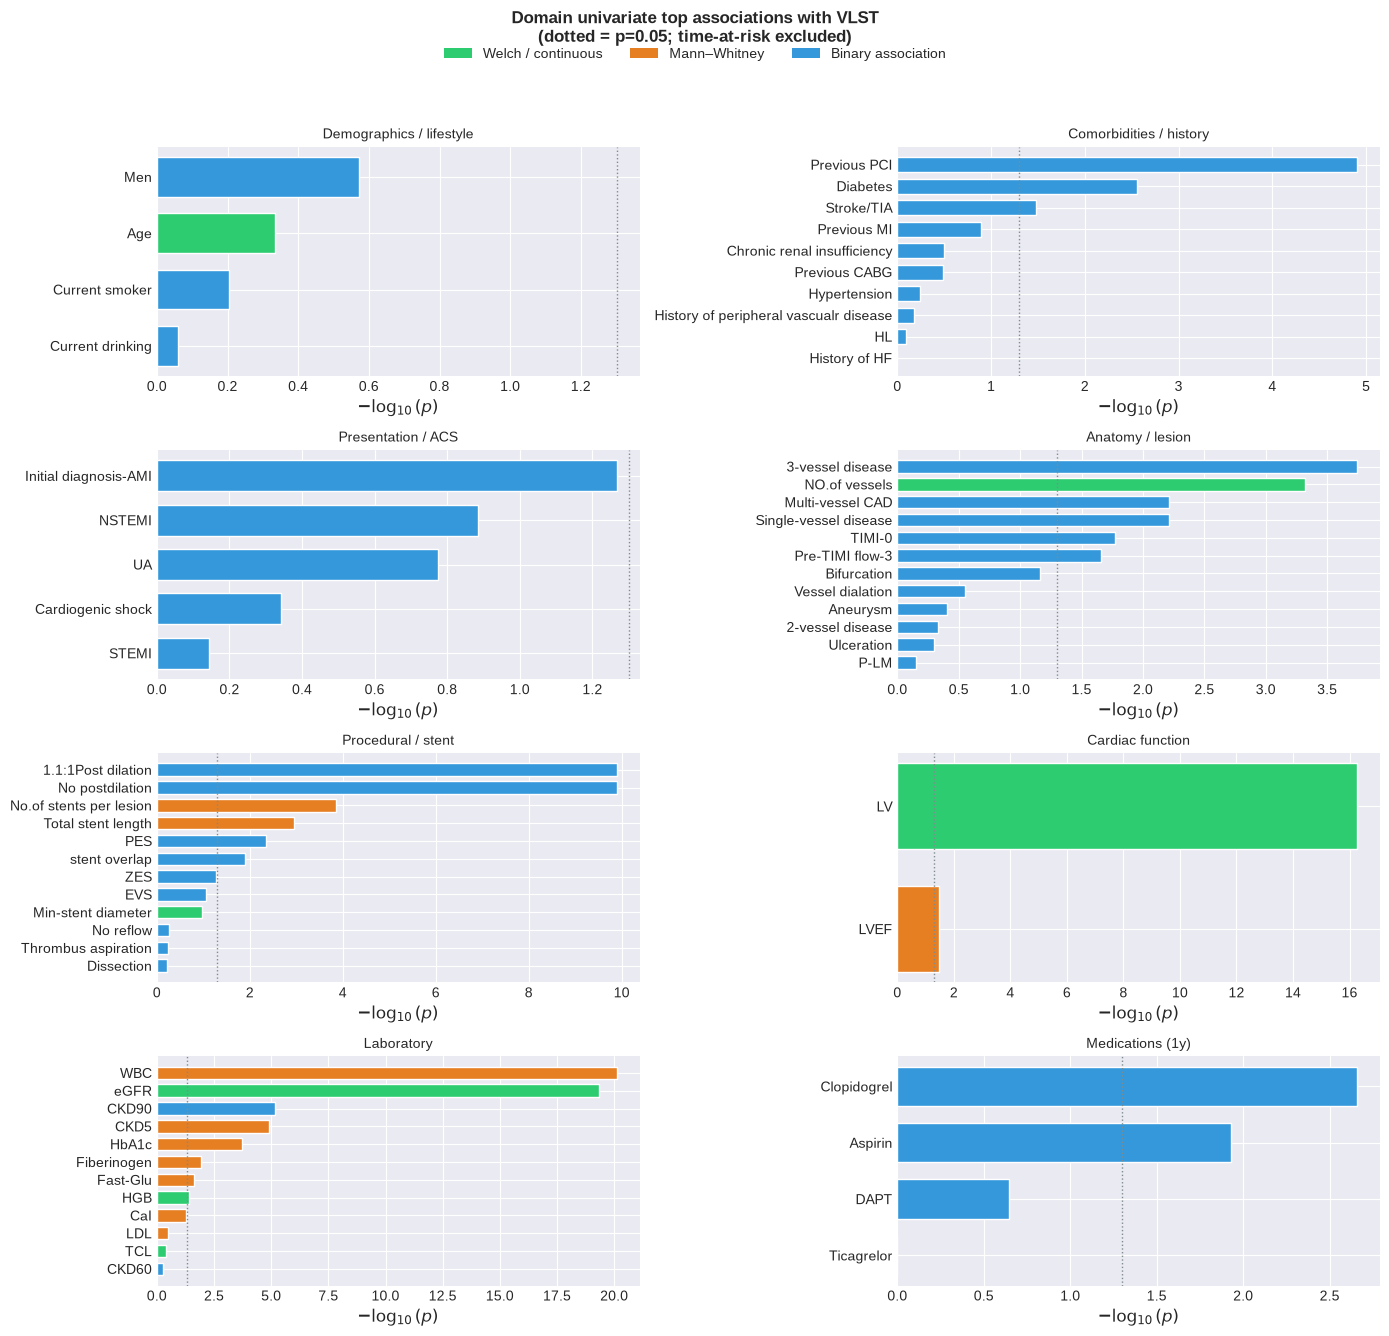

✓ Saved: domain_univariate_summary.csv | domain_strength_summary.csv | domain_univariate_top_hits.png


In [348]:
# 10g-1. Clinical DOMAIN_MAP + inventory + domain-tagged univariate summary
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

if "TARGET_COL" not in globals():
    TARGET_COL = "Stent thrombosis"

# ---------------------------------------------------------------------------
# Clinical domain map (medical meaning)
# ---------------------------------------------------------------------------
DOMAIN_GROUPS = {
    "Demographics / lifestyle": [
        "Age",
        "Men",
        "Current smoker",
        "Current drinking",
    ],
    "Comorbidities / history": [
        "Diabetes",
        "Hypertension",
        "HL",
        "Stroke/TIA",
        "History of peripheral vascualr disease",
        "Chronic renal insufficiency",
        "History of HF",
        "Previous CABG",
        "Previous PCI",
        "Previous MI",
    ],
    "Presentation / ACS": [
        "Initial diagnosis-AMI",
        "STEMI",
        "NSTEMI",
        "UA",
        "Cardiogenic shock",
    ],
    "Anatomy / lesion": [
        "NO.of vessels",
        "Multi-vessel CAD",
        "Single-vessel disease",
        "2-vessel disease",
        "3-vessel disease",
        "Chronic total occlusion",
        "Moderate/severe calcification",
        "Moderate/severe tortuosity",
        "Lesion location-Ostial",
        "Proximal",
        "Bifurcation",
        "Visual thrombus",
        "Aneurysm",
        "Vessel dialation",
        "Ulceration",
        "P-LM",
        "P-LAD",
        "P-LCX",
        "P-RCA",
        "Pre-TIMI flow-3",
        "TIMI-2",
        "TIMI-1",
        "TIMI-0",
    ],
    "Procedural / stent": [
        "Staged PCI",
        "Thrombus aspiration",
        "Slow flow",
        "No reflow",
        "Dissection",
        "Stent type-SES",
        "PES",
        "ZES",
        "EVS",
        "Min-stent diameter",
        "Max-stent diameter",
        "Total stent length",
        "Stent release pressure",
        "No.of stents per lesion",
        "stent overlap",
        "1.1:1Post dilation",
        "No postdilation",
    ],
    "Cardiac function": ["LV", "LVEF"],
    "Laboratory": [
        "CaI",
        "WBC",
        "HGB",
        "Platelet",
        "Cre",
        "eGFR",
        "CKD60",
        "CKD90",
        "CKD5",
        "TCL",
        "LDL",
        "HDL",
        "TG",
        "Fast-Glu",
        "HbA1c",
        "Fiberinogen",
    ],
    "Medications (1y)": ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"],
    "Time-at-risk (excluded from risk models)": ["Time since stent implantation"],
}

DOMAIN_MAP = {feat: dom for dom, feats in DOMAIN_GROUPS.items() for feat in feats}
RISK_DOMAINS = [d for d in DOMAIN_GROUPS if not d.startswith("Time-at-risk")]

# Unmapped predictors present in df
_skip = {"NO.", "Name", TARGET_COL}
_present = [c for c in df.columns if c not in _skip]
_unmapped = [c for c in _present if c not in DOMAIN_MAP]
if _unmapped:
    DOMAIN_GROUPS.setdefault("Other / unmapped", [])
    for c in _unmapped:
        DOMAIN_GROUPS["Other / unmapped"].append(c)
        DOMAIN_MAP[c] = "Other / unmapped"
    if "Other / unmapped" not in RISK_DOMAINS:
        RISK_DOMAINS.append("Other / unmapped")

# Inventory
inv_rows = []
for dom, feats in DOMAIN_GROUPS.items():
    for f in feats:
        if f not in df.columns:
            inv_rows.append(
                {
                    "Domain": dom,
                    "Feature": f,
                    "In dataset": "No",
                    "Dtype": "—",
                    "n non-null": 0,
                    "Missing %": np.nan,
                    "n unique": 0,
                }
            )
            continue
        s = df[f]
        inv_rows.append(
            {
                "Domain": dom,
                "Feature": f,
                "In dataset": "Yes",
                "Dtype": str(s.dtype),
                "n non-null": int(s.notna().sum()),
                "Missing %": round(100.0 * s.isna().mean(), 2),
                "n unique": int(s.nunique(dropna=True)),
            }
        )

domain_inventory_df = pd.DataFrame(inv_rows)
domain_inventory_df.to_csv(PLOT_DIR / "domain_feature_map.csv", index=False)
domain_inventory_df.to_csv(PLOT_DIR / "paper_domain_feature_map.csv", index=False)

print("=" * 80)
print("§10g DOMAIN INVENTORY")
print("=" * 80)
summary_counts = (
    domain_inventory_df[domain_inventory_df["In dataset"] == "Yes"]
    .groupby("Domain")
    .size()
    .rename("n features")
    .reset_index()
)
display(summary_counts)
display(domain_inventory_df.head(20))
print(f"✓ Saved: domain_feature_map.csv ({len(domain_inventory_df)} rows)")
if _unmapped:
    print(f"⚠ Unmapped features added to Other: {_unmapped}")

# ---------------------------------------------------------------------------
# Tag §10 univariate results by domain
# ---------------------------------------------------------------------------

def _bh_fdr(p):
    if "adjust_pvalues" in globals():
        return adjust_pvalues(p, "fdr_bh")
    p = np.asarray(p, dtype=float)
    m = len(p)
    adj = np.full(m, np.nan)
    valid = np.isfinite(p)
    if valid.sum() == 0:
        return adj
    pv = p[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]
    ranks = np.arange(1, n + 1)
    raw = np.minimum(1.0, ranked * n / ranks)
    out = np.minimum.accumulate(raw[::-1])[::-1]
    adj_valid = np.empty(n)
    adj_valid[order] = out
    adj[valid] = adj_valid
    return adj


uni_parts = []
if (
    "continuous_test_df" in globals()
    and isinstance(continuous_test_df, pd.DataFrame)
    and not continuous_test_df.empty
):
    c = continuous_test_df.copy()
    c["Feature type"] = "continuous"
    c["Effect"] = c.get("Primary effect size", np.nan)
    if "Odds Ratio" not in c.columns:
        c["Odds Ratio"] = np.nan
    uni_parts.append(
        c.rename(columns={"Test": "Test / method"})[
            [
                "Feature",
                "Feature type",
                "Test / method",
                "P-value",
                "p_fdr_bh",
                "Effect",
                "Odds Ratio",
            ]
        ]
    )

if (
    "binary_test_df" in globals()
    and isinstance(binary_test_df, pd.DataFrame)
    and not binary_test_df.empty
):
    b = binary_test_df.copy()
    b["Feature type"] = "binary"
    b["Effect"] = b.get("Phi", np.nan)
    b["Test / method"] = b.get("Recommended test", "binary association")
    uni_parts.append(
        b[
            [
                "Feature",
                "Feature type",
                "Test / method",
                "P-value",
                "p_fdr_bh",
                "Effect",
                "Odds Ratio",
            ]
        ]
    )

if not uni_parts:
    raise RuntimeError("Need continuous_test_df and/or binary_test_df from §10. Run those cells first.")

domain_uni_df = pd.concat(uni_parts, ignore_index=True)
domain_uni_df["Domain"] = domain_uni_df["Feature"].map(DOMAIN_MAP).fillna("Other / unmapped")
domain_uni_df["neglog10p"] = -np.log10(domain_uni_df["P-value"].clip(lower=1e-300))
domain_uni_df["Is time-at-risk"] = domain_uni_df["Domain"].str.startswith("Time-at-risk")

# Within-domain FDR (risk domains only for ranking; still compute for all)
domain_uni_df["p_fdr_within_domain"] = np.nan
for dom, g in domain_uni_df.groupby("Domain"):
    domain_uni_df.loc[g.index, "p_fdr_within_domain"] = _bh_fdr(g["P-value"].values)

domain_uni_df = domain_uni_df.sort_values(["Domain", "P-value"]).reset_index(drop=True)
domain_uni_df.to_csv(PLOT_DIR / "domain_univariate_summary.csv", index=False)

# Domain strength summary (exclude time-at-risk from “which block matters”)
risk_uni = domain_uni_df[~domain_uni_df["Is time-at-risk"]].copy()
domain_strength = (
    risk_uni.groupby("Domain")
    .agg(
        n_features=("Feature", "count"),
        n_raw_p05=("P-value", lambda s: int((s < 0.05).sum())),
        n_fdr_global=("p_fdr_bh", lambda s: int((s < 0.05).sum())),
        n_fdr_domain=("p_fdr_within_domain", lambda s: int((s < 0.05).sum())),
        min_p=("P-value", "min"),
        max_neglog10p=("neglog10p", "max"),
        top_feature=("Feature", lambda s: risk_uni.loc[s.index, "Feature"].iloc[0]),
    )
    .sort_values("max_neglog10p", ascending=False)
    .reset_index()
)
domain_strength.to_csv(PLOT_DIR / "domain_strength_summary.csv", index=False)

print("\nDomain strength (excl. time-at-risk):")
display(domain_strength)

# Top-hit multi-panel figure (one panel per risk domain)
n_dom = len(RISK_DOMAINS)
ncols = 2
nrows = int(np.ceil(n_dom / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), squeeze=False)
for i, dom in enumerate(RISK_DOMAINS):
    ax = axes[i // ncols][i % ncols]
    sub = risk_uni[risk_uni["Domain"] == dom].nsmallest(12, "P-value")
    if sub.empty:
        ax.set_visible(False)
        continue
    sub = sub.sort_values("neglog10p")
    colors = [
        "#e67e22" if "Mann" in str(t) else "#2ecc71" if "Welch" in str(t) else "#3498db"
        for t in sub["Test / method"]
    ]
    ax.barh(sub["Feature"], sub["neglog10p"], color=colors, edgecolor="white", height=0.7)
    ax.axvline(-np.log10(0.05), color="#7f8c8d", ls=":", lw=1)
    ax.set_title(dom, fontsize=10)
    ax.set_xlabel(r"$-\log_{10}(p)$")
for j in range(i + 1, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)
fig.legend(
    handles=[
        Patch(facecolor="#2ecc71", label="Welch / continuous"),
        Patch(facecolor="#e67e22", label="Mann–Whitney"),
        Patch(facecolor="#3498db", label="Binary association"),
    ],
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle(
    "Domain univariate top associations with VLST\n(dotted = p=0.05; time-at-risk excluded)",
    fontsize=12,
    fontweight="bold",
    y=1.04,
)
fig.tight_layout()
fig.savefig(PLOT_DIR / "domain_univariate_top_hits.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved: domain_univariate_summary.csv | domain_strength_summary.csv | domain_univariate_top_hits.png")


In [349]:
# 10g-2. Correlation clustering (hierarchical + clustermap) + VIF on candidates
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path("../data/result/eda/plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Features for clustering: numeric predictors excluding time-at-risk & IDs
_cluster_skip = {"NO.", "Name", TARGET_COL, "Time since stent implantation"}
cluster_feats = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c not in _cluster_skip and df[c].nunique(dropna=True) > 1
]
# Drop near-constant (prevalence <1% or >99% for binary-like)
kept = []
for c in cluster_feats:
    s = df[c].dropna()
    if s.nunique() <= 2:
        rate = s.mean()
        if rate < 0.01 or rate > 0.99:
            continue
    kept.append(c)
cluster_feats = kept

Xcorr = df[cluster_feats].copy()
# pairwise complete Spearman (robust) + Pearson
pearson_corr = Xcorr.corr(method="pearson")
spearman_corr = Xcorr.corr(method="spearman")
# Prefer Spearman absolute association for clustering distance
abs_corr = spearman_corr.abs().fillna(0.0).to_numpy(dtype=float, copy=True)
np.fill_diagonal(abs_corr, 1.0)
dist = 1.0 - abs_corr
dist = np.clip(dist, 0, 1)
# numerical symmetry
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")

# Cut so that |r|≳0.7 → same cluster (distance ≤ 0.3)
CLUSTER_DIST = 0.30
labels = fcluster(Z, t=CLUSTER_DIST, criterion="distance")
cluster_membership = pd.DataFrame(
    {
        "Feature": cluster_feats,
        "Corr cluster": labels,
        "Domain": [DOMAIN_MAP.get(f, "Other / unmapped") for f in cluster_feats],
    }
)
# Attach univariate p for representative picking
if "domain_uni_df" in globals():
    cluster_membership = cluster_membership.merge(
        domain_uni_df[["Feature", "P-value", "p_fdr_bh"]], on="Feature", how="left"
    )
else:
    cluster_membership["P-value"] = np.nan
    cluster_membership["p_fdr_bh"] = np.nan

cluster_membership = cluster_membership.sort_values(["Corr cluster", "P-value"])
cluster_membership.to_csv(PLOT_DIR / "feature_correlation_clusters.csv", index=False)

# Representative per cluster: best univariate p (clinical preference for eGFR over Cre if tied)
CLINICAL_PREF = {"eGFR": -1, "Cre": 1, "WBC": -1, "CKD5": 0}


def _rep_key(row):
    pref = CLINICAL_PREF.get(row["Feature"], 0)
    p = row["P-value"] if pd.notna(row["P-value"]) else 1.0
    return (p, pref)


reps = []
for cid, g in cluster_membership.groupby("Corr cluster"):
    g2 = g.copy()
    g2["_k"] = g2.apply(_rep_key, axis=1)
    rep = g2.sort_values("_k").iloc[0]
    mates = [f for f in g2["Feature"] if f != rep["Feature"]]
    reps.append(
        {
            "Corr cluster": cid,
            "Representative": rep["Feature"],
            "Domain": rep["Domain"],
            "P-value": rep["P-value"],
            "n in cluster": len(g2),
            "Cluster mates": ", ".join(mates) if mates else "—",
        }
    )
cluster_reps_df = pd.DataFrame(reps).sort_values("P-value")
cluster_reps_df.to_csv(PLOT_DIR / "feature_correlation_cluster_reps.csv", index=False)

print("=" * 80)
print(f"CORRELATION CLUSTERS (Spearman |r|, average linkage, cut dist={CLUSTER_DIST} ≈ |r|≥{1-CLUSTER_DIST:.1f})")
print("=" * 80)
print(f"Features clustered: {len(cluster_feats)} → {cluster_membership['Corr cluster'].nunique()} clusters")
display(cluster_reps_df.head(25))
multi = cluster_reps_df[cluster_reps_df["n in cluster"] > 1].sort_values("n in cluster", ascending=False)
print(f"\nMulti-feature clusters: {len(multi)}")
display(multi.head(15))

# Global clustermap (subsample columns if huge — we have ~80, OK but figure large)
plot_corr = spearman_corr.loc[cluster_feats, cluster_feats]
g = sns.clustermap(
    plot_corr,
    row_linkage=Z,
    col_linkage=Z,
    cmap="vlag",
    center=0,
    figsize=(16, 14),
    dendrogram_ratio=0.12,
    xticklabels=True,
    yticklabels=True,
)
g.ax_heatmap.tick_params(axis="both", labelsize=5)
g.fig.suptitle("Global Spearman correlation clustermap (features)", y=1.02, fontsize=12, fontweight="bold")
g.savefig(PLOT_DIR / "domain_clustermap_global.png", dpi=200, bbox_inches="tight")
plt.close()
print("✓ Saved: domain_clustermap_global.png")

# Within-domain clustermaps for high-redundancy domains
for dom_name, tag in [
    ("Laboratory", "lab"),
    ("Anatomy / lesion", "anatomy"),
    ("Procedural / stent", "procedural"),
]:
    feats = [f for f in DOMAIN_GROUPS.get(dom_name, []) if f in spearman_corr.columns]
    if len(feats) < 3:
        print(f"(skip clustermap) {dom_name}: <3 features")
        continue
    sub = spearman_corr.loc[feats, feats]
    abs_sub = sub.abs().fillna(0.0).to_numpy(dtype=float, copy=True)
    np.fill_diagonal(abs_sub, 1.0)
    d = 1.0 - abs_sub
    d = np.clip((d + d.T) / 2, 0, 1)
    np.fill_diagonal(d, 0.0)
    try:
        Zs = linkage(squareform(d, checks=False), method="average")
    except Exception as e:
        print(f"(skip clustermap) {dom_name}: {e}")
        continue
    gg = sns.clustermap(
        sub,
        row_linkage=Zs,
        col_linkage=Zs,
        cmap="vlag",
        center=0,
        figsize=(10, 8),
        dendrogram_ratio=0.15,
    )
    gg.ax_heatmap.tick_params(axis="both", labelsize=8)
    gg.fig.suptitle(f"{dom_name}: Spearman clustermap", y=1.02, fontsize=12, fontweight="bold")
    gg.savefig(PLOT_DIR / f"domain_clustermap_{tag}.png", dpi=250, bbox_inches="tight")
    plt.close()
    print(f"✓ Saved: domain_clustermap_{tag}.png")

# Simple VIF on top cluster representatives (numeric)
from numpy.linalg import lstsq

vif_feats = [
    r
    for r in cluster_reps_df.sort_values("P-value")["Representative"].tolist()
    if r in df.columns
][:15]
vif_rows = []
Xv = df[vif_feats].apply(pd.to_numeric, errors="coerce")
Xv = Xv.dropna()
if len(Xv) > 50 and Xv.shape[1] >= 2:
    Xz = (Xv - Xv.mean()) / Xv.std(ddof=0).replace(0, np.nan)
    Xz = Xz.dropna(axis=1)
    for col in Xz.columns:
        y = Xz[col].values
        Xo = Xz.drop(columns=[col]).values
        if Xo.shape[1] == 0:
            continue
        beta, *_ = lstsq(Xo, y, rcond=None)
        pred = Xo @ beta
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif = 1.0 / max(1e-8, 1 - r2)
        vif_rows.append({"Feature": col, "VIF": round(vif, 2)})
    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    vif_df.to_csv(PLOT_DIR / "domain_vif_cluster_reps.csv", index=False)
    print("\nVIF among top cluster representatives:")
    display(vif_df)
else:
    vif_df = pd.DataFrame()
    print("VIF skipped (insufficient complete cases).")

print("✓ Saved: feature_correlation_clusters.csv | feature_correlation_cluster_reps.csv")


CORRELATION CLUSTERS (Spearman |r|, average linkage, cut dist=0.3 ≈ |r|≥0.7)
Features clustered: 77 → 64 clusters


,Corr cluster,Representative,Domain,P-value,n in cluster,Cluster mates
19,20,WBC,Laboratory,7.902144e-21,1,—
28,29,eGFR,Laboratory,4.643061e-20,1,—
14,15,LV,Cardiac function,5.438331e-17,1,—
44,45,1.1:1Post dilation,Procedural / stent,1.295177e-10,2,No postdilation
26,27,CKD90,Laboratory,6.550244e-06,2,CKD5
3,4,Previous PCI,Comorbidities / history,1.250528e-05,1,—
45,46,No.of stents per lesion,Procedural / stent,1.412198e-04,2,stent overlap
53,54,3-vessel disease,Anatomy / lesion,1.807139e-04,1,—
8,9,HbA1c,Laboratory,1.975000e-04,1,—
52,53,NO.of vessels,Anatomy / lesion,4.766857e-04,3,"Multi-vessel CAD, Single-vessel disease"



Multi-feature clusters: 11


,Corr cluster,Representative,Domain,P-value,n in cluster,Cluster mates
52,53,NO.of vessels,Anatomy / lesion,4.766857e-04,3,"Multi-vessel CAD, Single-vessel disease"
18,19,Initial diagnosis-AMI,Presentation / ACS,5.415468e-02,3,"UA, STEMI"
44,45,1.1:1Post dilation,Procedural / stent,1.295177e-10,2,No postdilation
45,46,No.of stents per lesion,Procedural / stent,1.412198e-04,2,stent overlap
26,27,CKD90,Laboratory,6.550244e-06,2,CKD5
58,59,Clopidogrel,Medications (1y),2.196625e-03,2,DAPT
16,17,TIMI-0,Anatomy / lesion,1.688441e-02,2,Pre-TIMI flow-3
50,51,Min-stent diameter,Procedural / stent,1.058401e-01,2,Max-stent diameter
12,13,LDL,Laboratory,3.274224e-01,2,TCL
17,18,Thrombus aspiration,Procedural / stent,5.748790e-01,2,Visual thrombus


✓ Saved: domain_clustermap_global.png
✓ Saved: domain_clustermap_lab.png
✓ Saved: domain_clustermap_anatomy.png
✓ Saved: domain_clustermap_procedural.png

VIF among top cluster representatives:


,Feature,VIF
10,Total stent length,4.03
6,No.of stents per lesion,3.96
9,NO.of vessels,3.94
7,3-vessel disease,3.87
8,HbA1c,1.78
12,Diabetes,1.77
1,eGFR,1.69
4,CKD90,1.68
11,Clopidogrel,1.53
14,Aspirin,1.53


✓ Saved: feature_correlation_clusters.csv | feature_correlation_cluster_reps.csv


PER-DOMAIN ADJUSTED ORs (demos + up to 5 domain reps; continuous per 1 SD)


,Domain model,Feature,OR,OR_lo,OR_hi,n,events
26,Anatomy / lesion,TIMI-0,1.792638,1.157382,2.818579,5185,92
28,Anatomy / lesion,Vessel dialation,1.664488,0.000061,5.352138,5185,92
27,Anatomy / lesion,Bifurcation,1.550637,0.720084,2.780294,5185,92
25,Anatomy / lesion,3-vessel disease,1.443166,0.568916,4.178864,5185,92
22,Anatomy / lesion,Men,1.352524,0.771804,2.266298,5185,92
23,Anatomy / lesion,Current smoker,1.211997,0.774423,1.890246,5185,92
21,Anatomy / lesion,NO.of vessels,1.209729,0.732796,1.918793,5185,92
24,Anatomy / lesion,Current drinking,0.832765,0.463257,1.604512,5185,92
20,Anatomy / lesion,Age,1.083870,0.857408,1.373859,5185,92
39,Cardiac function,LV,3.480874,2.684491,4.784077,5185,92


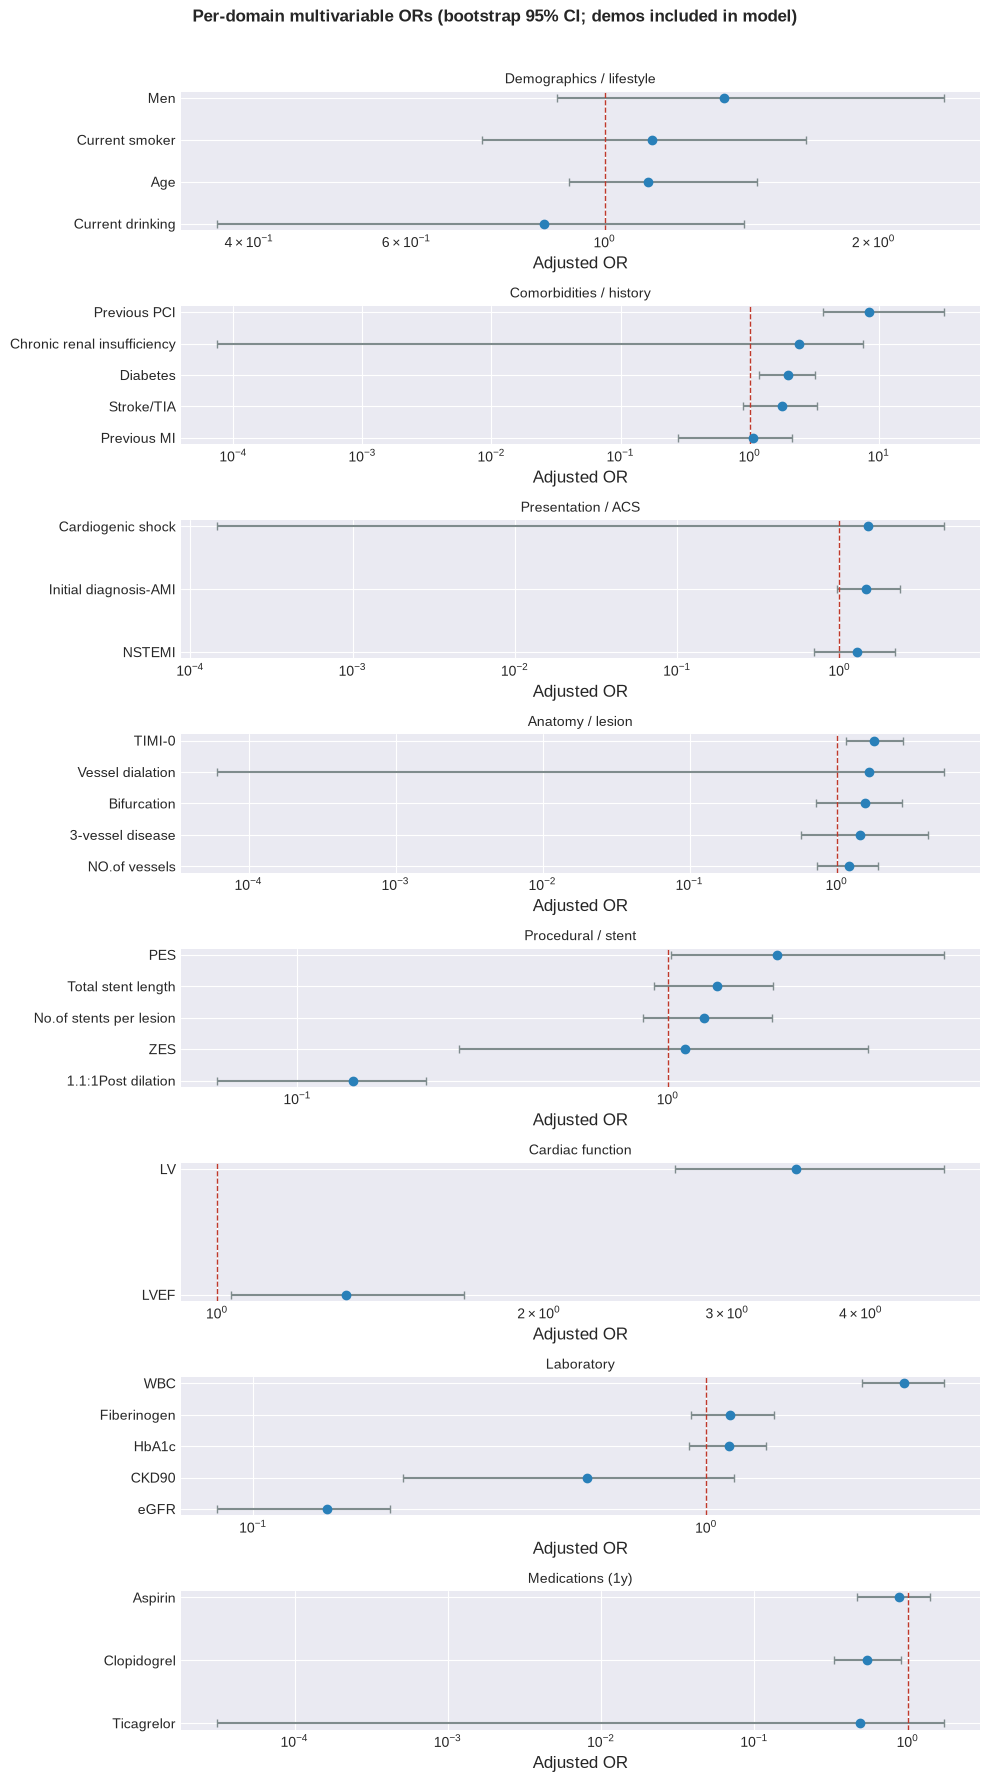

✓ Saved: domain_multivariable_or.csv | domain_multivariable_or_panels.png

Joint model features: ['Age', 'Men', 'Current smoker', 'Current drinking', 'WBC', 'eGFR', 'LV', 'LVEF', '1.1:1Post dilation', 'No.of stents per lesion', 'Previous PCI', 'Diabetes']
JOINT CROSS-DOMAIN MODEL (uni OR vs adjusted OR)


,Feature,Domain,Univariate OR,OR,OR_lo,OR_hi
10,Previous PCI,Comorbidities / history,6.733333,9.575541,3.308190,23.576265
6,Men,Demographics / lifestyle,1.285586,3.282943,1.577014,7.900396
3,LV,Cardiac function,3.116073,2.949842,2.197089,5.035701
1,WBC,Laboratory,2.693871,2.942103,2.342629,4.396300
4,LVEF,Cardiac function,0.850817,1.650171,1.301037,2.259840
5,No.of stents per lesion,Procedural / stent,1.379386,1.551936,1.173478,2.270229
11,Diabetes,Comorbidities / history,1.898098,1.459509,0.789459,2.596816
0,Age,Demographics / lifestyle,1.080372,1.098963,0.835869,1.344280
8,Current drinking,Demographics / lifestyle,0.981245,1.071179,0.423119,2.114367
7,Current smoker,Demographics / lifestyle,1.105299,0.976397,0.540767,2.074367


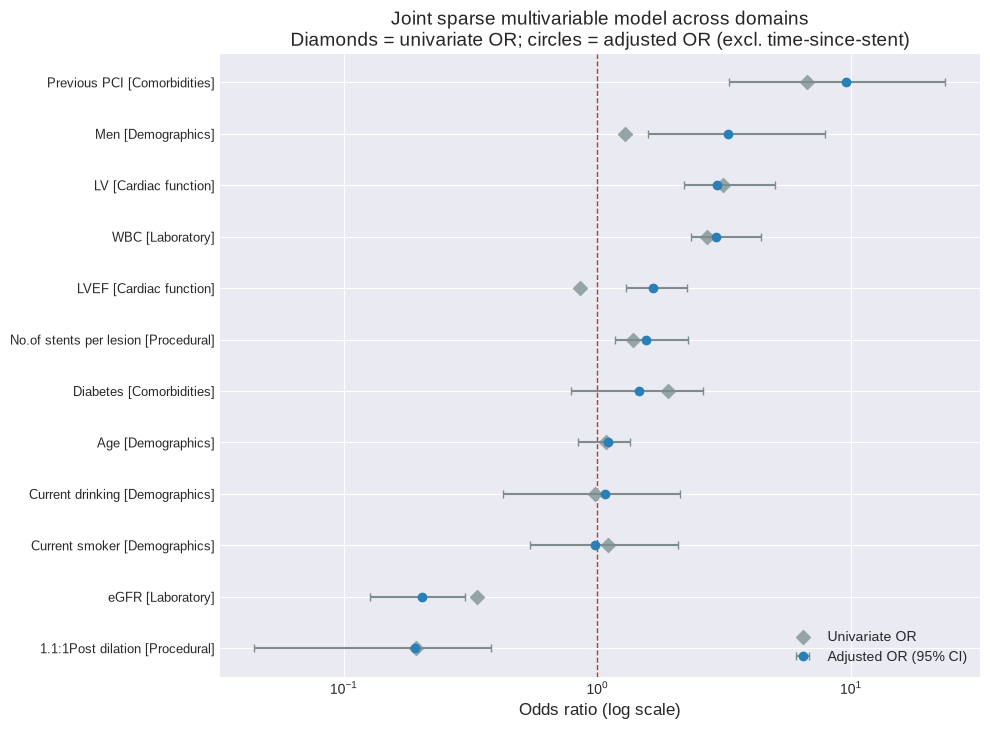

✓ Saved: domain_joint_multivariable_or.csv | domain_joint_uni_vs_multi_or.png

Features whose adjusted 95% CI excludes 1 (independent signal in joint model):


,Feature,Domain,Univariate OR,OR,OR_lo,OR_hi
10,Previous PCI,Comorbidities / history,6.733333,9.575541,3.308190,23.576265
9,1.1:1Post dilation,Procedural / stent,0.192186,0.190536,0.044367,0.381864
2,eGFR,Laboratory,0.334236,0.203176,0.126540,0.299096
6,Men,Demographics / lifestyle,1.285586,3.282943,1.577014,7.900396
3,LV,Cardiac function,3.116073,2.949842,2.197089,5.035701
1,WBC,Laboratory,2.693871,2.942103,2.342629,4.396300
4,LVEF,Cardiac function,0.850817,1.650171,1.301037,2.259840
5,No.of stents per lesion,Procedural / stent,1.379386,1.551936,1.173478,2.270229


INTERACTION SCREEN (exploratory; low power with ~92 events)


,Pair,Feature A,Feature B,LR statistic,Interaction p,Interaction OR,p_fdr_bh
5,LV × eGFR,LV,eGFR,9.812779,0.001733,1.244833,0.027729
13,Men × eGFR,Men,eGFR,8.527282,0.003499,0.341807,0.027989
1,WBC × eGFR,WBC,eGFR,2.648502,0.103648,1.125265,0.552787
4,Current smoker × DAPT,Current smoker,DAPT,2.073824,0.149845,1.860714,0.599382
6,Aspirin × Clopidogrel,Aspirin,Clopidogrel,1.493663,0.221649,2.966520,0.622667
3,Diabetes × HbA1c,Diabetes,HbA1c,1.248337,0.263870,0.786967,0.622667
12,Men × Previous PCI,Men,Previous PCI,1.194333,0.274457,0.442017,0.622667
14,LV × Previous PCI,LV,Previous PCI,0.963852,0.326218,0.786105,0.622667
15,LV × Men,LV,Men,0.872551,0.350250,1.174765,0.622667
0,DAPT × Diabetes,DAPT,Diabetes,0.427691,0.513124,1.488709,0.820999


✓ Saved: domain_interaction_screen.csv

CLINICAL TAKEAWAYS (§10g)
Strongest domains by max −log10(p):
  • Laboratory: top=WBC, raw p05=8, FDR(global)=6
  • Cardiac function: top=LV, raw p05=2, FDR(global)=1
  • Procedural / stent: top=1.1:1Post dilation, raw p05=6, FDR(global)=5
  • Comorbidities / history: top=Previous PCI, raw p05=3, FDR(global)=2
  • Anatomy / lesion: top=3-vessel disease, raw p05=6, FDR(global)=4

Largest correlation clusters (pick representative only for modeling):
  • Cluster 53: rep=NO.of vessels | mates=Multi-vessel CAD, Single-vessel disease
  • Cluster 19: rep=Initial diagnosis-AMI | mates=UA, STEMI
  • Cluster 45: rep=1.1:1Post dilation | mates=No postdilation
  • Cluster 46: rep=No.of stents per lesion | mates=stent overlap
  • Cluster 27: rep=CKD90 | mates=CKD5
  • Cluster 59: rep=Clopidogrel | mates=DAPT
  • Cluster 17: rep=TIMI-0 | mates=Pre-TIMI flow-3
  • Cluster 51: rep=Min-stent diameter | mates=Max-stent diameter

Independent signals in joint model 

In [350]:
# 10g-3. Sparse per-domain + joint multivariable logistic + interaction screen
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
import statsmodels.api as sm
from scipy.stats import chi2

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path("../data/result/eda/plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEMO_COVARS = [c for c in ["Age", "Men", "Current smoker", "Current drinking"] if c in df.columns]
TIME_FEAT = "Time since stent implantation"
MAX_DOMAIN_EXTRA = 5  # + demos → keep models sparse
N_BOOT = 2000
RNG = np.random.default_rng(42)


def _is_binary_col(s):
    u = set(pd.Series(s).dropna().unique())
    return u.issubset({0, 1, 0.0, 1.0})


def _prepare_design(frame, features, target=TARGET_COL):
    cols = [c for c in features if c in frame.columns]
    d = frame[cols + [target]].copy()
    for c in cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna()
    y = d[target].astype(int).values
    X = d[cols].copy()
    cont_cols = [c for c in cols if not _is_binary_col(X[c])]
    bin_cols = [c for c in cols if c not in cont_cols]
    scaler = StandardScaler()
    X_out = pd.DataFrame(index=X.index)
    if cont_cols:
        X_out[cont_cols] = scaler.fit_transform(X[cont_cols])
    for c in bin_cols:
        X_out[c] = X[c].astype(float)
    return X_out.values, y, list(X_out.columns), d.index


def _fit_logit_sm(X, y):
    """Unweighted binomial MLE. class_weight is not used (it distorts LR/Wald)."""
    Xc = sm.add_constant(np.asarray(X, dtype=float), has_constant="add")
    return sm.Logit(np.asarray(y, dtype=float), Xc).fit(disp=False, maxiter=4000, method="lbfgs")


def _or_table(res, names):
    params = np.asarray(res.params)[1:]
    se = np.asarray(res.bse)[1:]
    p = np.asarray(res.pvalues)[1:]
    ci = np.asarray(res.conf_int())[1:]
    return pd.DataFrame(
        {
            "Feature": names,
            "logOR": params,
            "SE": se,
            "Wald_p": p,
            "OR": np.exp(params),
            "OR_lo": np.exp(ci[:, 0]),
            "OR_hi": np.exp(ci[:, 1]),
        }
    )


def _bootstrap_or(X, y, names, n_boot=N_BOOT):
    ors = []
    n = len(y)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    for _ in range(n_boot):
        idx = RNG.integers(0, n, n)
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        try:
            res = _fit_logit_sm(X[idx], yb)
            ors.append(np.exp(np.asarray(res.params)[1:]))
        except Exception:
            continue
    if not ors:
        return np.full(len(names), np.nan), np.full(len(names), np.nan)
    arr = np.vstack(ors)
    return np.nanpercentile(arr, 2.5, axis=0), np.nanpercentile(arr, 97.5, axis=0)


def _univariate_or_approx(feature):
    """Crude univariate OR: binary 2x2; continuous = logistic OR per 1 SD."""
    if feature not in df.columns:
        return np.nan
    d = df[[feature, TARGET_COL]].dropna()
    d[feature] = pd.to_numeric(d[feature], errors="coerce")
    d = d.dropna()
    if d.empty:
        return np.nan
    y = d[TARGET_COL].astype(int).values
    x = d[feature].values.astype(float)
    if _is_binary_col(d[feature]):
        # OR from counts
        a = ((x == 1) & (y == 1)).sum()
        b = ((x == 1) & (y == 0)).sum()
        c = ((x == 0) & (y == 1)).sum()
        d0 = ((x == 0) & (y == 0)).sum()
        return ((a + 0.5) * (d0 + 0.5)) / ((b + 0.5) * (c + 0.5))
    xs = (x - x.mean()) / (x.std() if x.std() > 0 else 1)
    X = xs.reshape(-1, 1)
    try:
        res = _fit_logit_sm(X, y)
        return float(np.exp(np.asarray(res.params)[1]))
    except Exception:
        return np.nan


# Representatives allowed in models (exclude time)
rep_set = set()
if "cluster_reps_df" in globals() and not cluster_reps_df.empty:
    rep_set = set(cluster_reps_df["Representative"].tolist())
else:
    rep_set = set(domain_uni_df["Feature"])

# ---------------------------------------------------------------------------
# A. Per-domain sparse multivariable
# ---------------------------------------------------------------------------
domain_mv_rows = []
domain_mv_models = {}

for dom in RISK_DOMAINS:
    if dom.startswith("Other"):
        continue
    cand = domain_uni_df[domain_uni_df["Domain"] == dom].sort_values("P-value")
    # prefer cluster representatives
    feats = []
    for f in cand["Feature"]:
        if f == TIME_FEAT:
            continue
        if f in DEMO_COVARS:
            continue
        if rep_set and f not in rep_set and f not in DEMO_COVARS:
            # allow if singleton domain (cardiac function etc.)
            mates = cluster_membership.loc[
                cluster_membership["Feature"] == f, "Corr cluster"
            ]
            if len(mates) and (cluster_membership["Corr cluster"] == mates.iloc[0]).sum() > 1:
                continue
        feats.append(f)
        if len(feats) >= MAX_DOMAIN_EXTRA:
            break
    model_feats = list(dict.fromkeys(DEMO_COVARS + feats))
    if len(model_feats) < 2:
        continue
    try:
        X, y, names, _idx = _prepare_design(df, model_feats)
    except Exception as e:
        print(f"(skip domain MV) {dom}: {e}")
        continue
    if y.sum() < 10 or len(y) < 100:
        print(f"(skip domain MV) {dom}: too few events/rows")
        continue
    res = _fit_logit_sm(X, y)
    tab = _or_table(res, names)
    boot_lo, boot_hi = _bootstrap_or(X, y, names)
    tab["OR_lo_boot"] = boot_lo
    tab["OR_hi_boot"] = boot_hi
    tab["Domain model"] = dom
    tab["n"] = len(y)
    tab["events"] = int(y.sum())
    tab["pseudo_R2"] = float(res.prsquared)
    tab["LR_vs_null"] = float(res.llr)
    tab["LR_p"] = float(res.llr_pvalue)
    domain_mv_rows.append(tab)
    domain_mv_models[dom] = tab

if domain_mv_rows:
    domain_mv_df = pd.concat(domain_mv_rows, ignore_index=True)
    domain_mv_df.to_csv(PLOT_DIR / "domain_multivariable_or.csv", index=False)
    print("=" * 80)
    print("PER-DOMAIN ADJUSTED ORs (demos + up to 5 domain reps; continuous per 1 SD)")
    print("=" * 80)
    _show = domain_mv_df[["Domain model", "Feature", "OR", "OR_lo", "OR_hi", "n", "events"]].copy()
    _show["_abs_logOR"] = np.abs(np.log(_show["OR"].clip(lower=1e-6)))
    display(_show.sort_values(["Domain model", "_abs_logOR"], ascending=[True, False]).drop(columns="_abs_logOR").head(40))
    # Figure: one panel per domain with domain-specific (non-demo) ORs
    plot_doms = [d for d in RISK_DOMAINS if d in domain_mv_models][:8]
    n = len(plot_doms)
    fig, axes = plt.subplots(n, 1, figsize=(10, max(3, 2.2 * n)), squeeze=False)
    for i, dom in enumerate(plot_doms):
        ax = axes[i][0]
        t = domain_mv_models[dom]
        t = t[~t["Feature"].isin(DEMO_COVARS)].copy()
        if t.empty:
            t = domain_mv_models[dom].copy()
        t = t.sort_values("OR")
        ax.errorbar(
            t["OR"],
            np.arange(len(t)),
            xerr=[t["OR"] - t["OR_lo"], t["OR_hi"] - t["OR"]],
            fmt="o",
            color="#2980b9",
            ecolor="#7f8c8d",
            capsize=3,
        )
        ax.axvline(1.0, color="#c0392b", ls="--", lw=1)
        ax.set_yticks(np.arange(len(t)))
        ax.set_yticklabels(t["Feature"])
        ax.set_xscale("log")
        ax.set_xlabel("Adjusted OR")
        ax.set_title(dom, fontsize=10)
    fig.suptitle(
        "Per-domain multivariable ORs (bootstrap 95% CI; demos included in model)",
        fontsize=12,
        fontweight="bold",
        y=1.01,
    )
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "domain_multivariable_or_panels.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("✓ Saved: domain_multivariable_or.csv | domain_multivariable_or_panels.png")
else:
    domain_mv_df = pd.DataFrame()
    print("No domain multivariable models fitted.")

# ---------------------------------------------------------------------------
# B. Joint cross-domain sparse model
# ---------------------------------------------------------------------------
joint_feats = list(DEMO_COVARS)
# 1–2 top non-redundant features per strong domain
for dom in domain_strength["Domain"].tolist():
    if dom.startswith("Time") or dom.startswith("Other"):
        continue
    if dom == "Demographics / lifestyle":
        continue
    sub = domain_uni_df[domain_uni_df["Domain"] == dom].sort_values("P-value")
    added = 0
    for f in sub["Feature"]:
        if f in joint_feats or f == TIME_FEAT:
            continue
        if rep_set and f not in rep_set:
            mates = cluster_membership.loc[cluster_membership["Feature"] == f, "Corr cluster"]
            if len(mates) and (cluster_membership["Corr cluster"] == mates.iloc[0]).sum() > 1:
                continue
        joint_feats.append(f)
        added += 1
        if added >= 2:
            break
    if len(joint_feats) >= 12:
        break

print("\nJoint model features:", joint_feats)
Xj, yj, names_j, _ = _prepare_design(df, joint_feats)
res_j = _fit_logit_sm(Xj, yj)
lo_j, hi_j = _bootstrap_or(Xj, yj, names_j)
joint_df = _or_table(res_j, names_j)
joint_df["OR_lo_boot"] = lo_j
joint_df["OR_hi_boot"] = hi_j
joint_df["Univariate OR"] = [ _univariate_or_approx(f) for f in names_j ]
joint_df["Domain"] = [DOMAIN_MAP.get(f, "—") for f in names_j]
joint_df["n"] = len(yj)
joint_df["events"] = int(yj.sum())
joint_df.to_csv(PLOT_DIR / "domain_joint_multivariable_or.csv", index=False)

print("=" * 80)
print("JOINT CROSS-DOMAIN MODEL (uni OR vs adjusted OR)")
print("=" * 80)
display(joint_df[["Feature", "Domain", "Univariate OR", "OR", "OR_lo", "OR_hi"]].sort_values("OR", ascending=False))

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(joint_df) + 2)))
ord_df = joint_df.sort_values("OR")
ypos = np.arange(len(ord_df))
ax.scatter(ord_df["Univariate OR"], ypos, marker="D", color="#95a5a6", s=50, label="Univariate OR", zorder=3)
ax.errorbar(
    ord_df["OR"],
    ypos,
    xerr=[ord_df["OR"] - ord_df["OR_lo"], ord_df["OR_hi"] - ord_df["OR"]],
    fmt="o",
    color="#2980b9",
    ecolor="#7f8c8d",
    capsize=3,
    label="Adjusted OR (95% CI)",
    zorder=4,
)
ax.axvline(1.0, color="#c0392b", ls="--", lw=1)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r.Feature} [{r.Domain.split('/')[0].strip()}]" for _, r in ord_df.iterrows()], fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio (log scale)")
ax.set_title(
    "Joint sparse multivariable model across domains\n"
    "Diamonds = univariate OR; circles = adjusted OR (excl. time-since-stent)"
)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(PLOT_DIR / "domain_joint_uni_vs_multi_or.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved: domain_joint_multivariable_or.csv | domain_joint_uni_vs_multi_or.png")

# Attenuation vs persistence
joint_df["log_uni"] = np.log(joint_df["Univariate OR"].clip(lower=1e-6))
joint_df["log_adj"] = np.log(joint_df["OR"].clip(lower=1e-6))
joint_df["abs_attenuation"] = (joint_df["log_uni"].abs() - joint_df["log_adj"].abs())
persist = joint_df[(joint_df["OR_lo"] > 1) | (joint_df["OR_hi"] < 1)].copy()
persist["_abs_logOR"] = np.abs(np.log(persist["OR"].clip(lower=1e-6)))
persist = persist.sort_values("_abs_logOR", ascending=False).drop(columns="_abs_logOR")
print("\nFeatures whose adjusted 95% CI excludes 1 (independent signal in joint model):")
display(persist[["Feature", "Domain", "Univariate OR", "OR", "OR_lo", "OR_hi"]])

# ---------------------------------------------------------------------------
# C. Limited clinical interaction screen
# ---------------------------------------------------------------------------
# Candidate main-effect pool: top joint features by |log OR|
top_mains = (
    joint_df.assign(abs_logOR=lambda d: np.abs(np.log(d["OR"].clip(lower=1e-6))))
    .sort_values("abs_logOR", ascending=False)["Feature"]
    .tolist()
)
# Clinically motivated pairs (only if both present)
motivation = [
    ("DAPT", "Diabetes"),
    ("WBC", "eGFR"),
    ("Total stent length", "No.of stents per lesion"),
    ("HbA1c", "Diabetes"),
    ("Current smoker", "DAPT"),
    ("LV", "eGFR"),
    ("Aspirin", "Clopidogrel"),
]
# Also a few top×top pairs
for a in top_mains[:5]:
    for b in top_mains[:5]:
        if a < b:
            motivation.append((a, b))
# unique
seen = set()
pairs = []
for a, b in motivation:
    if a not in df.columns or b not in df.columns:
        continue
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    pairs.append(key)

interact_rows = []
for a, b in pairs[:20]:
    base_feats = list(dict.fromkeys(DEMO_COVARS + [a, b]))
    # drop if a/b in demos duplicate
    try:
        X0, y0, n0, _ = _prepare_design(df, base_feats)
        # interaction on standardized/binary columns already in design — rebuild with product
        d = df[base_feats + [TARGET_COL]].copy()
        for c in base_feats:
            d[c] = pd.to_numeric(d[c], errors="coerce")
        d = d.dropna()
        y = d[TARGET_COL].astype(int).values
        Xdf = d[base_feats].copy()
        cont = [c for c in base_feats if not _is_binary_col(Xdf[c])]
        sc = StandardScaler()
        Xs = Xdf.copy().astype(float)
        if cont:
            Xs[cont] = sc.fit_transform(Xdf[cont])
        inter_name = f"{a}×{b}"
        Xs[inter_name] = Xs[a].values * Xs[b].values
        names0 = base_feats
        names1 = base_feats + [inter_name]
        X0m = Xs[names0].values
        X1m = Xs[names1].values
        if y.sum() < 10:
            continue
        res0 = _fit_logit_sm(X0m, y)
        res1 = _fit_logit_sm(X1m, y)
        lr_stat = 2.0 * (float(res1.llf) - float(res0.llf))
        p_int = float(chi2.sf(max(lr_stat, 0.0), 1))
        interact_rows.append(
            {
                "Pair": f"{a} × {b}",
                "Feature A": a,
                "Feature B": b,
                "LR statistic": lr_stat,
                "Interaction p": p_int,
                "Interaction OR": float(np.exp(np.asarray(res1.params)[-1])),
            }
        )
    except Exception as e:
        interact_rows.append(
            {"Pair": f"{a} × {b}", "Feature A": a, "Feature B": b, "LR statistic": np.nan, "Interaction p": np.nan, "Interaction OR": np.nan, "Error": str(e)}
        )

interact_df = pd.DataFrame(interact_rows)
if not interact_df.empty and "Interaction p" in interact_df.columns:
    interact_df["p_fdr_bh"] = _bh_fdr(interact_df["Interaction p"].values)
    interact_df = interact_df.sort_values("Interaction p")
interact_df.to_csv(PLOT_DIR / "domain_interaction_screen.csv", index=False)
print("=" * 80)
print("INTERACTION SCREEN (exploratory; low power with ~92 events)")
print("=" * 80)
display(interact_df.head(20))
print("✓ Saved: domain_interaction_screen.csv")

# ---------------------------------------------------------------------------
# Clinical takeaways (printed)
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("CLINICAL TAKEAWAYS (§10g)")
print("=" * 80)
print("Strongest domains by max −log10(p):")
for _, r in domain_strength.head(5).iterrows():
    print(f"  • {r['Domain']}: top={r['top_feature']}, raw p05={r['n_raw_p05']}, FDR(global)={r['n_fdr_global']}")
print("\nLargest correlation clusters (pick representative only for modeling):")
if "multi" in dir() or "multi" in globals():
    pass
_multi = cluster_reps_df[cluster_reps_df["n in cluster"] > 1].sort_values("n in cluster", ascending=False).head(8)
for _, r in _multi.iterrows():
    print(f"  • Cluster {int(r['Corr cluster'])}: rep={r['Representative']} | mates={r['Cluster mates']}")
print("\nIndependent signals in joint model (CI excludes 1):")
if len(persist):
    for _, r in persist.iterrows():
        print(f"  • {r['Feature']} ({r['Domain']}): adj OR={r['OR']:.3f} [{r['OR_lo']:.3f},{r['OR_hi']:.3f}]")
else:
    print("  (none with CI excluding 1 — interpret cautiously under class imbalance)")
print("\nNote: Time since stent implantation excluded from risk models (time-at-risk).")
print("Interactions are exploratory only.")


### §10g takeaways — how to read the domain analysis

1. **Domain inventory** (`domain_feature_map.csv`): every predictor sits in a clinical block (demographics, comorbidities, presentation, anatomy, procedural, cardiac function, labs, meds; time-at-risk separate).
2. **Which blocks matter**: `domain_strength_summary.csv` + `domain_univariate_top_hits.png` — compare domains by FDR hits and peak association (time-at-risk excluded from ranking).
3. **Correlation groups**: hierarchical clustering on Spearman `|r|` (`feature_correlation_clusters.csv`, clustermaps). Use **one representative per tight cluster** before multivariable fitting (VIF on reps as a check).
4. **Combinations**:
   - Per-domain adjusted ORs = signal that survives demographics within that clinical block.
   - Joint cross-domain model = which domain representatives stay important **together**.
   - Interaction screen = few clinical pairs only; treat as hypothesis-generating.
5. **Caveats**: ~92 events → keep models sparse; class imbalance; no causation; do not interpret time-since-stent as a baseline risk factor.


In [351]:
# Fisher's Exact Test: Stent thrombosis rate in Men vs Women
from scipy.stats import fisher_exact

print("\n" + "-" * 80)
print("FISHER'S EXACT TEST: MEN vs WOMEN")
print("-" * 80)

sex_col_candidates = ["Men", "men", "Male", "male", "Sex", "sex", "Gender", "gender"]
sex_col = next((c for c in sex_col_candidates if c in df.columns), None)

if sex_col is None:
    print("Could not find a sex/gender column. Expected one of:")
    print(sex_col_candidates)
else:
    # Keep only rows with valid binary values (0/1) for sex and target
    tmp = df[[sex_col, TARGET_COL]].dropna().copy()
    tmp = tmp[tmp[sex_col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]

    contingency = pd.crosstab(tmp[sex_col], tmp[TARGET_COL])

    print(f"Using sex column: {sex_col}")
    print("\nContingency table [rows: sex (0/1), cols: thrombosis (0/1)]")
    display(contingency)

    if contingency.shape == (2, 2):
        odds_ratio, p_value = fisher_exact(contingency, alternative="two-sided")

        # Event rates for interpretation
        rate_women = contingency.loc[0, 1] / contingency.loc[0].sum() if contingency.loc[0].sum() > 0 else np.nan
        rate_men = contingency.loc[1, 1] / contingency.loc[1].sum() if contingency.loc[1].sum() > 0 else np.nan

        print(f"\nWomen thrombosis rate (sex=0): {rate_women:.4%}")
        print(f"Men thrombosis rate (sex=1):   {rate_men:.4%}")
        print(f"Odds Ratio: {odds_ratio:.4f}")
        print(f"P-value (Fisher exact, two-sided): {p_value:.6g}")

        if p_value < 0.05:
            print("\n✓ Significant difference in thrombosis rate between men and women (p < 0.05).")
        else:
            print("\n⚠ No statistically significant difference in thrombosis rate between men and women (p >= 0.05).")
    else:
        print("\nFisher's exact test requires a 2x2 table. Please check coding of sex/target as binary 0/1.")


--------------------------------------------------------------------------------
FISHER'S EXACT TEST: MEN vs WOMEN
--------------------------------------------------------------------------------
Using sex column: Men

Contingency table [rows: sex (0/1), cols: thrombosis (0/1)]


Stent thrombosis,0,1
Men,,
0,1604,24
1,3489,68



Women thrombosis rate (sex=0): 1.4742%
Men thrombosis rate (sex=1):   1.9117%
Odds Ratio: 1.3026
P-value (Fisher exact, two-sided): 0.308089

⚠ No statistically significant difference in thrombosis rate between men and women (p >= 0.05).


In [352]:
# Alcohol use significance test vs Stent thrombosis
# Rule: use Fisher's exact for sparse 2x2 tables (expected count < 5), else Chi-square.

print("\n" + "-" * 80)
print("ALCOHOL USE vs STENT THROMBOSIS: SIGNIFICANCE TEST")
print("-" * 80)

alcohol_candidates = [
    "Current drinking",
    "current drinking",
    "Alcohol use",
    "alcohol use",
    "Alcohol",
    "alcohol",
    "Drinking",
    "drinking",
]

alcohol_col = next((c for c in alcohol_candidates if c in df.columns), None)

if alcohol_col is None:
    print("Could not find alcohol-use column. Tried:")
    print(alcohol_candidates)
else:
    tmp = df[[alcohol_col, TARGET_COL]].dropna().copy()
    tmp = tmp[tmp[alcohol_col].isin([0, 1]) & tmp[TARGET_COL].isin([0, 1])]

    contingency = pd.crosstab(tmp[alcohol_col], tmp[TARGET_COL])

    print(f"Using alcohol column: {alcohol_col}")
    print("\nContingency table [rows: alcohol (0/1), cols: thrombosis (0/1)]")
    display(contingency)

    if contingency.shape == (2, 2):
        # Expected counts from chi-square (for decision rule)
        chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency)
        min_expected = expected.min()

        if min_expected < 5:
            # Prefer Fisher for sparse tables
            odds_ratio, p_value = fisher_exact(contingency, alternative="two-sided")
            test_used = "Fisher's exact test"
            print(f"\nExpected cell count min = {min_expected:.3f} (<5) -> using Fisher's exact test")
            print(f"Odds Ratio: {odds_ratio:.4f}")
        else:
            p_value = chi2_p
            test_used = "Chi-square test of independence"
            print(f"\nExpected cell count min = {min_expected:.3f} (>=5) -> using Chi-square test")
            print(f"Chi-square statistic: {chi2_stat:.4f}")

        # Event rates for interpretation
        rate_no_alcohol = contingency.loc[0, 1] / contingency.loc[0].sum() if contingency.loc[0].sum() > 0 else np.nan
        rate_alcohol = contingency.loc[1, 1] / contingency.loc[1].sum() if contingency.loc[1].sum() > 0 else np.nan

        print(f"\nNo alcohol thrombosis rate (0): {rate_no_alcohol:.4%}")
        print(f"Alcohol-use thrombosis rate (1): {rate_alcohol:.4%}")
        print(f"P-value ({test_used}): {p_value:.6g}")

        if p_value < 0.05:
            print("\n✓ Significant association between alcohol use and stent thrombosis (p < 0.05).")
        else:
            print("\n⚠ No statistically significant association between alcohol use and stent thrombosis (p >= 0.05).")
    else:
        print("\nThis analysis requires a 2x2 table. Please check binary coding (0/1).")


--------------------------------------------------------------------------------
ALCOHOL USE vs STENT THROMBOSIS: SIGNIFICANCE TEST
--------------------------------------------------------------------------------
Using alcohol column: Current drinking

Contingency table [rows: alcohol (0/1), cols: thrombosis (0/1)]


Stent thrombosis,0,1
Current drinking,,
0,4342,79
1,751,13



Expected cell count min = 13.556 (>=5) -> using Chi-square test
Chi-square statistic: 0.0003

No alcohol thrombosis rate (0): 1.7869%
Alcohol-use thrombosis rate (1): 1.7016%
P-value (Chi-square test of independence): 0.986734

⚠ No statistically significant association between alcohol use and stent thrombosis (p >= 0.05).


## 11. Distribution Analysis - Continuous Variables by Target

Understanding how continuous variables differ between patients with and without stent thrombosis helps identify:
- **Risk Factors**: Variables where distributions differ significantly
- **Biomarkers**: Lab values or measurements that may indicate higher risk
- **Clinical Patterns**: Features that distinguish between the two groups

We visualize **all continuous variables** (not a top-N subset) using histograms and box plots split by VLST status.


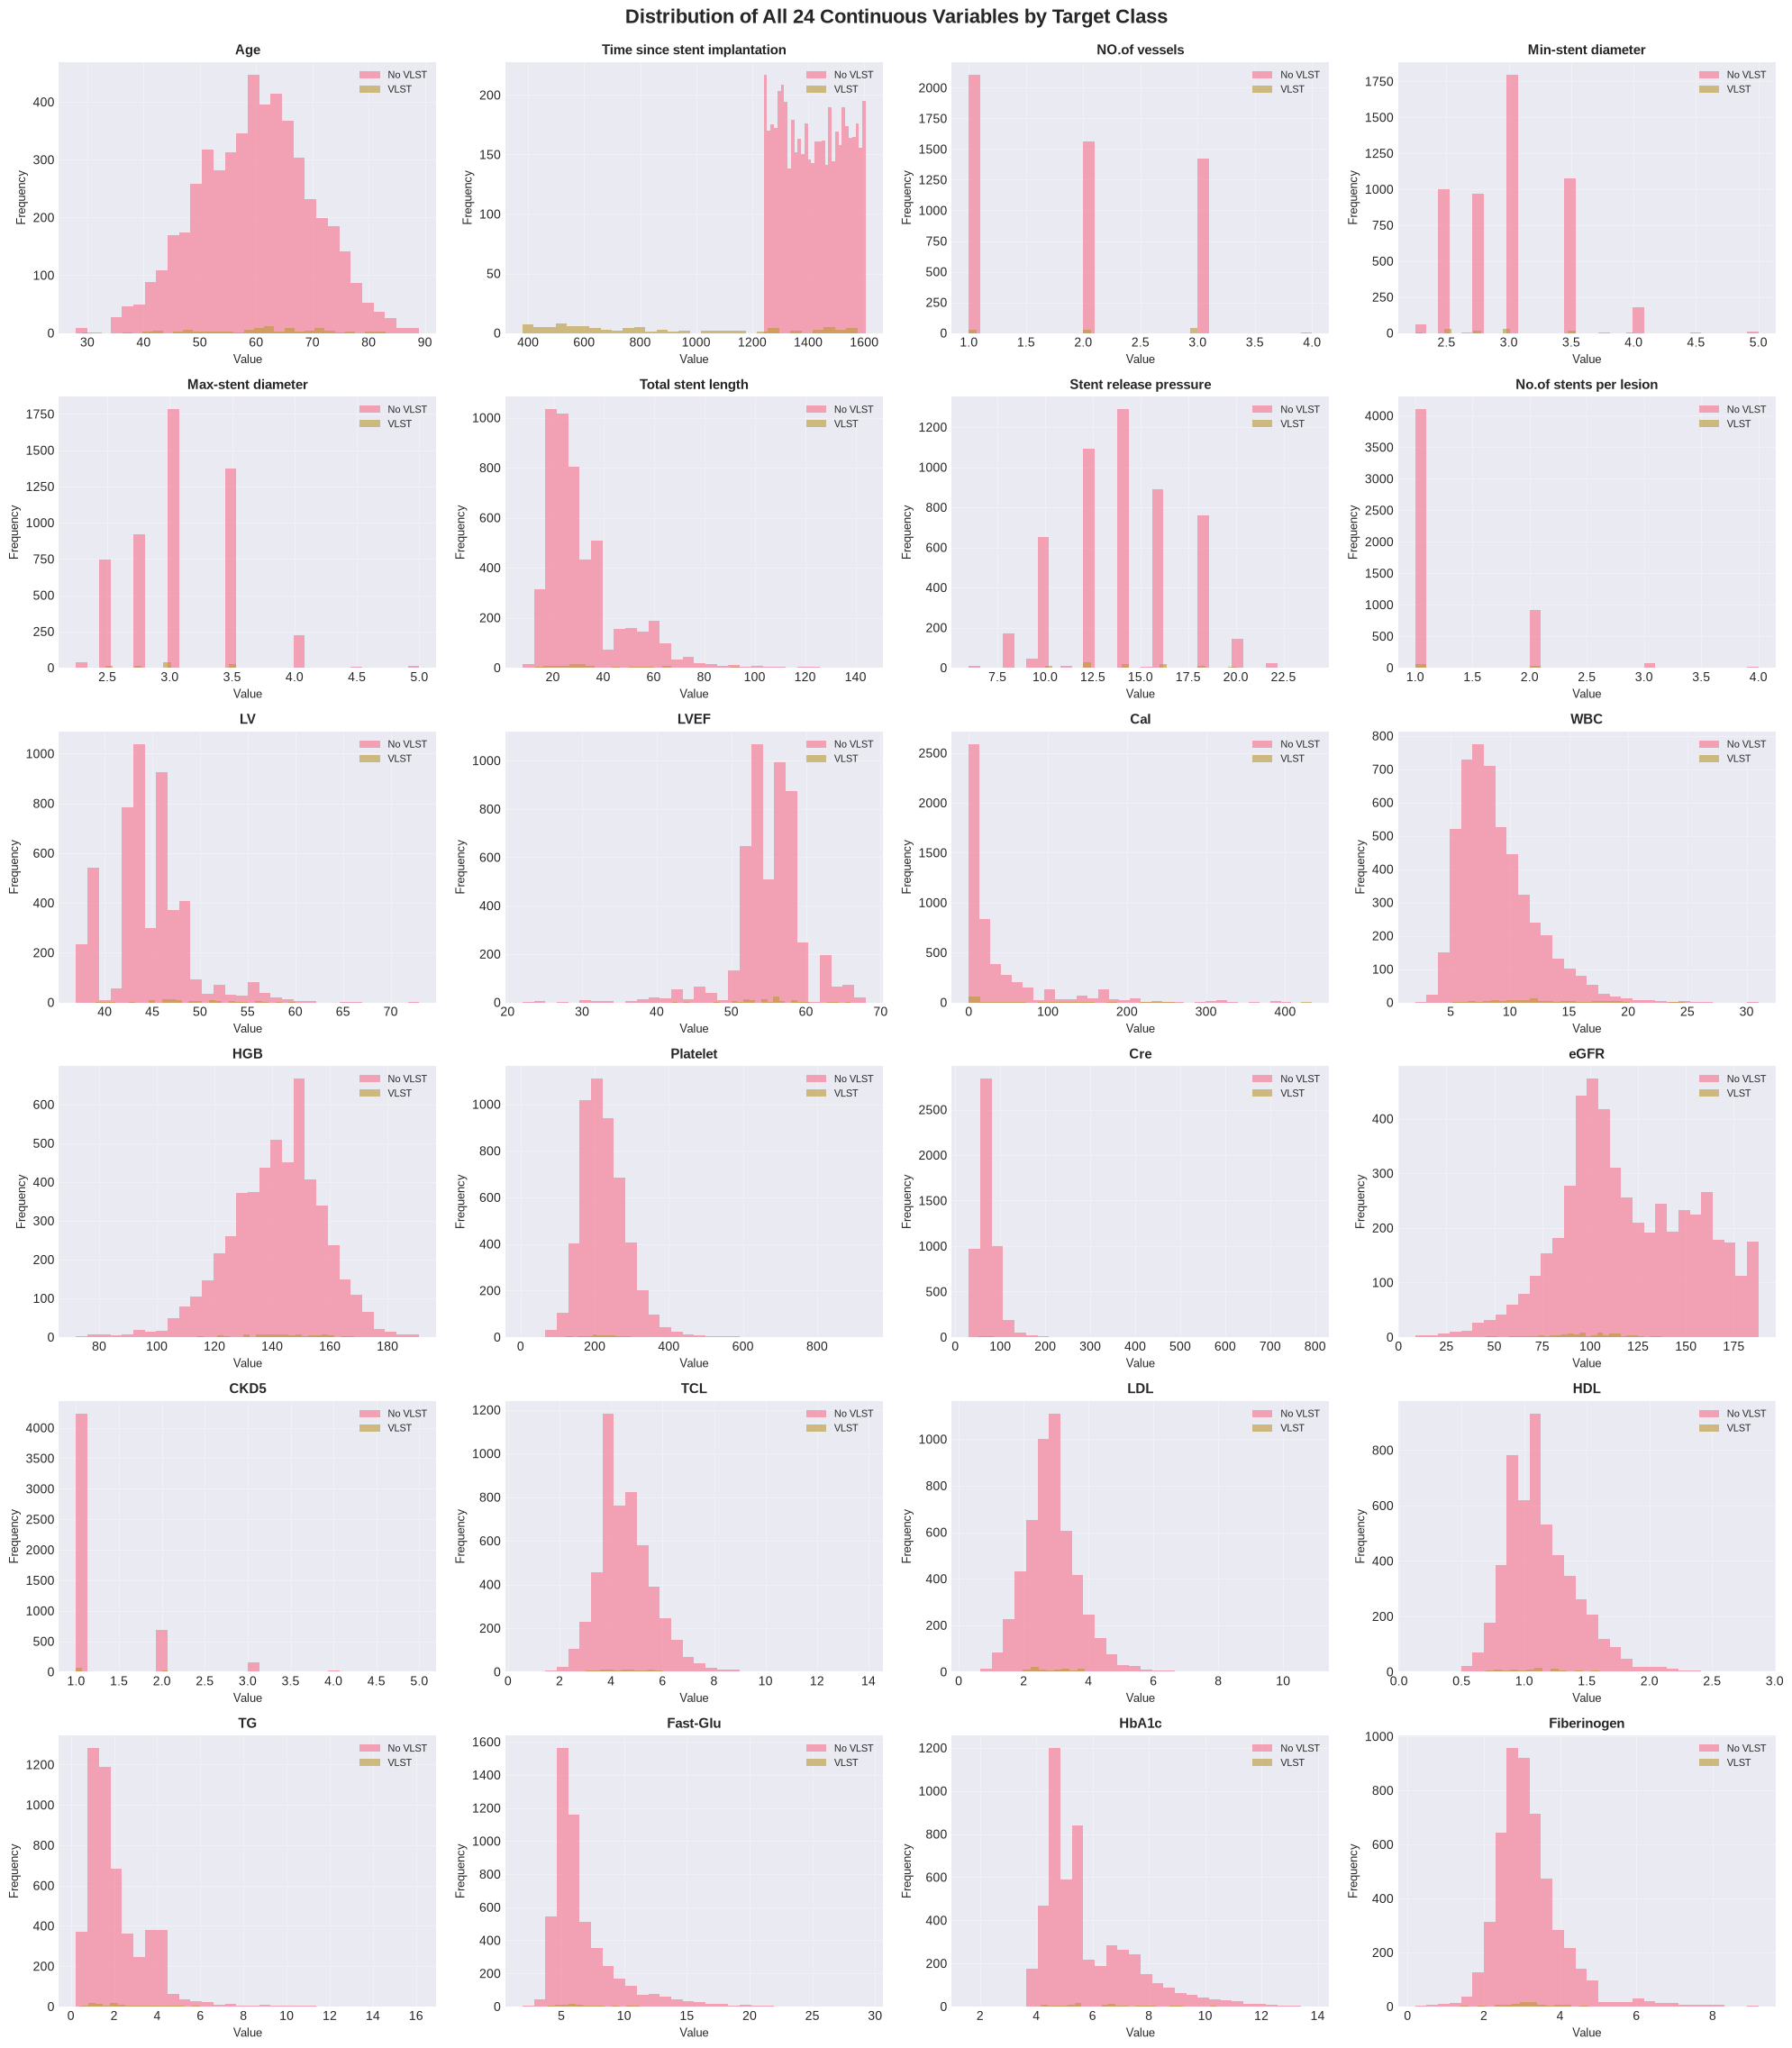

✓ Visualization saved: plots/04_continuous_distributions.png (24 continuous variables)


In [353]:
# Distribution of ALL continuous variables by target
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

if len(continuous_cols) > 0:
    n_vars = len(continuous_cols)
    n_cols = 4
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for idx, col in enumerate(continuous_cols):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                for target_val in [0, 1]:
                    data = df_clean[df_clean[TARGET_COL] == target_val][col]
                    axes[idx].hist(
                        data,
                        alpha=0.6,
                        label=("No VLST" if target_val == 0 else "VLST"),
                        bins=30,
                    )
                axes[idx].set_title(col, fontsize=11, fontweight="bold")
                axes[idx].set_xlabel("Value", fontsize=9)
                axes[idx].set_ylabel("Frequency", fontsize=9)
                axes[idx].legend(fontsize=8)
                axes[idx].grid(True, alpha=0.3)
            else:
                axes[idx].axis("off")
        except Exception:
            axes[idx].axis("off")

    for idx in range(n_vars, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(
        f"Distribution of All {n_vars} Continuous Variables by Target Class",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(str(PLOT_DIR / "04_continuous_distributions.png"), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✓ Visualization saved: plots/04_continuous_distributions.png ({n_vars} continuous variables)")
else:
    print("No continuous variables to plot.")


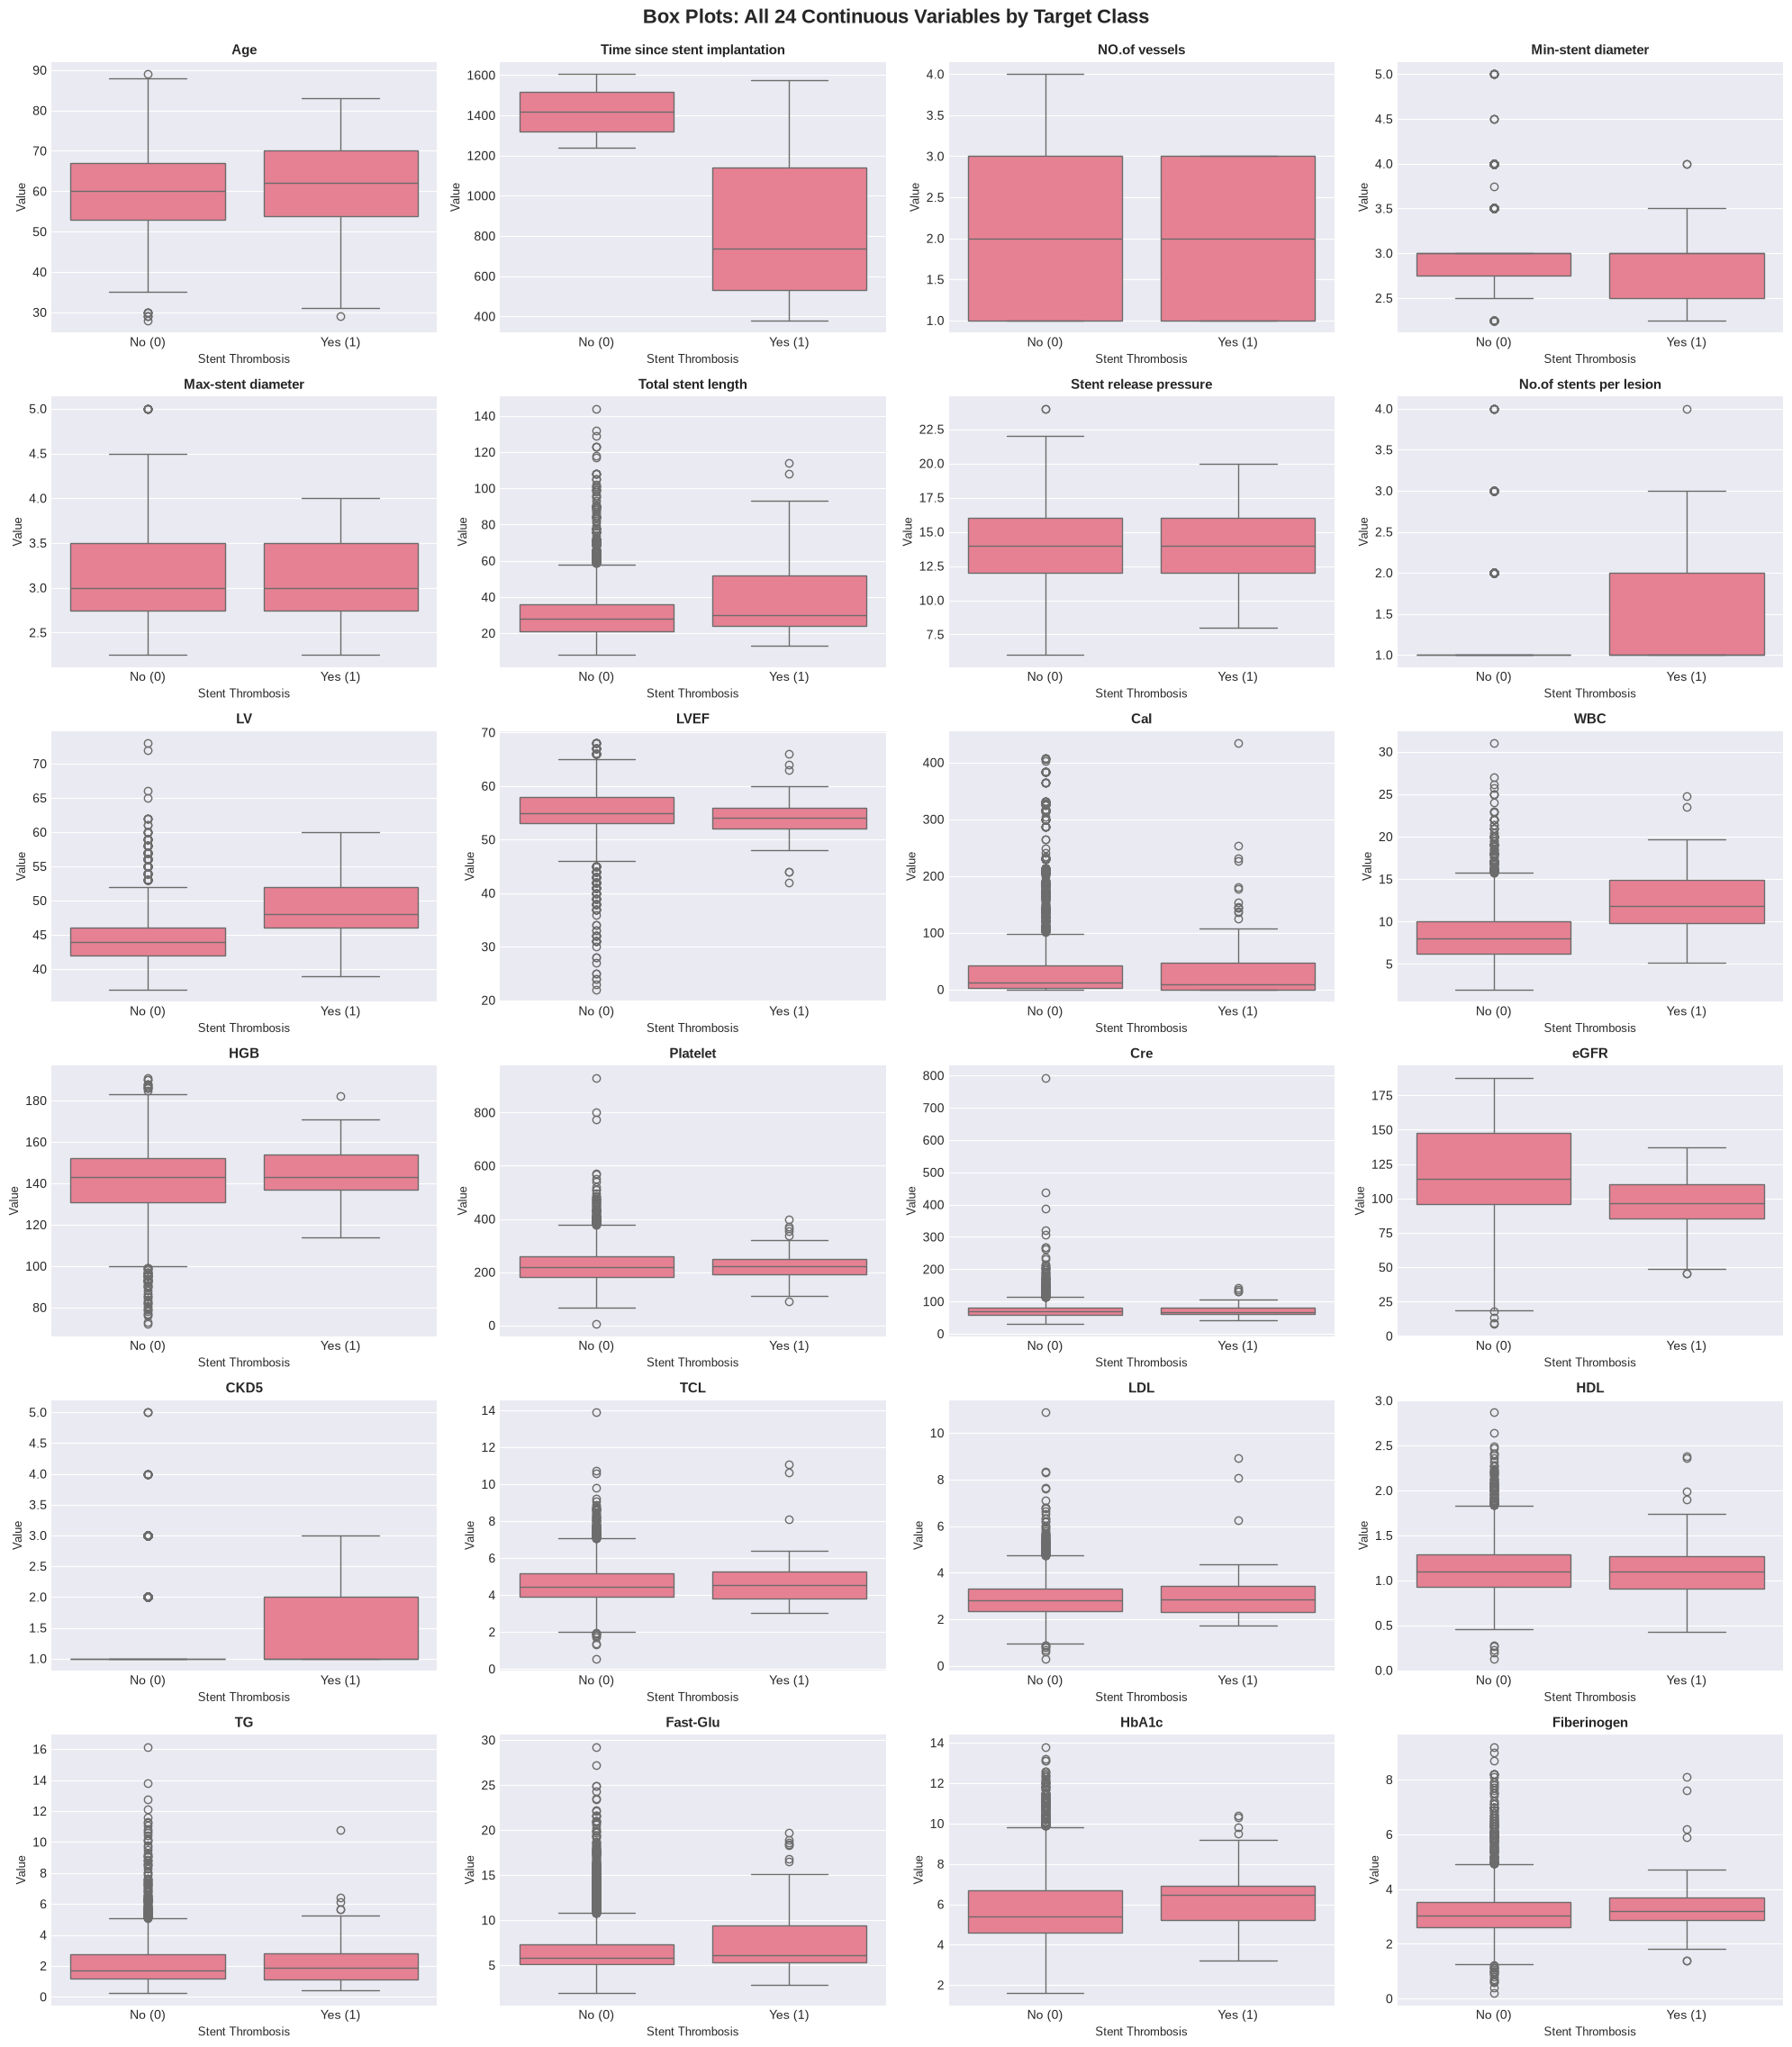

✓ Visualization saved: plots/05_boxplots_continuous.png (24 continuous variables)


In [354]:
# Box plots for ALL continuous variables by target
from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

if len(continuous_cols) > 0:
    n_vars = len(continuous_cols)
    n_cols = 4
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for idx, col in enumerate(continuous_cols):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                sns.boxplot(data=df_clean, x=TARGET_COL, y=col, ax=axes[idx])
                axes[idx].set_title(col, fontsize=11, fontweight="bold")
                axes[idx].set_xlabel("Stent Thrombosis", fontsize=9)
                axes[idx].set_ylabel("Value", fontsize=9)
                axes[idx].set_xticks([0, 1])
                axes[idx].set_xticklabels(["No (0)", "Yes (1)"])
            else:
                axes[idx].axis("off")
        except Exception:
            axes[idx].axis("off")

    for idx in range(n_vars, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(
        f"Box Plots: All {n_vars} Continuous Variables by Target Class",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(str(PLOT_DIR / "05_boxplots_continuous.png"), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✓ Visualization saved: plots/05_boxplots_continuous.png ({n_vars} continuous variables)")
else:
    print("No continuous variables to plot.")


## 12. Binary Variables Association with Target

For binary variables, we examine how the presence or absence of each feature relates to stent thrombosis. This helps identify:
- **Risk Factors**: Binary features that are more common in thrombosis cases
- **Protective Factors**: Binary features that are less common in thrombosis cases
- **Clinical Indicators**: Features that may serve as markers for risk assessment


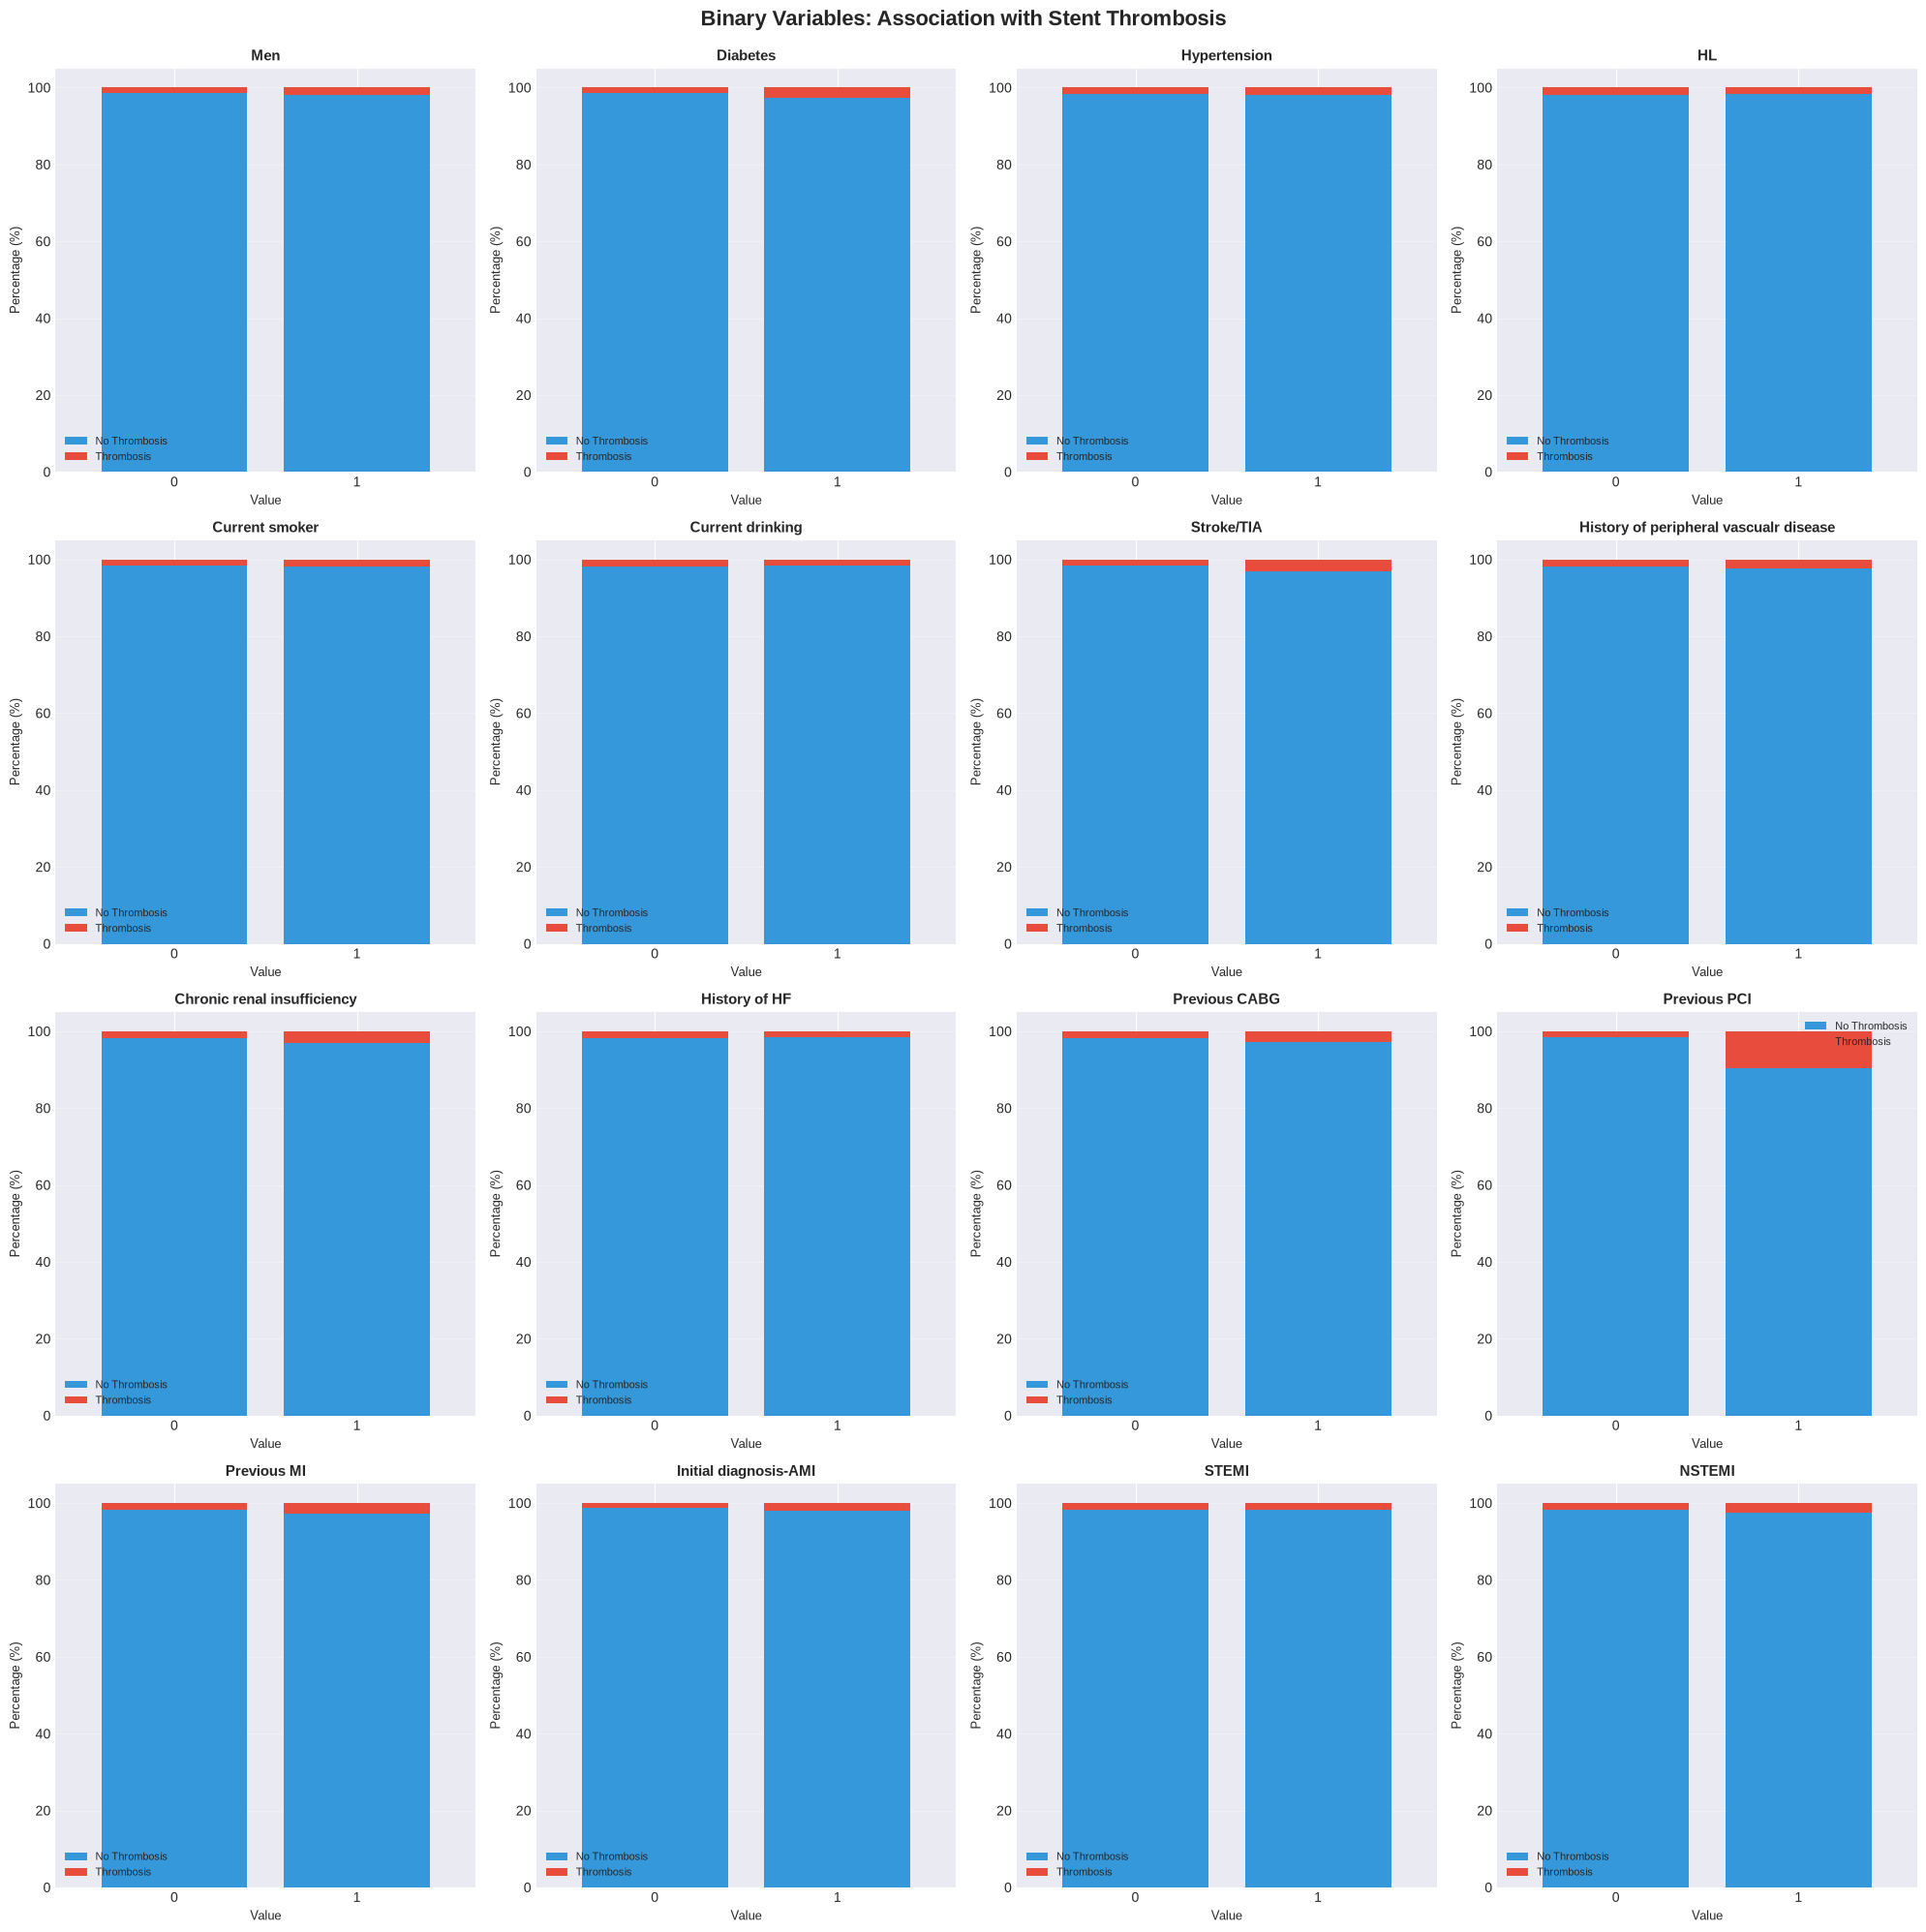

✓ Visualization saved: plots/06_binary_associations.png


In [355]:
# Binary variables association with target
if len(binary_cols) > 0:
    top_binary = binary_cols[:16]  # Top 16 binary variables

    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = axes.flatten()

    for idx, col in enumerate(top_binary):
        try:
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
            crosstab.plot(
                kind="bar",
                ax=axes[idx],
                stacked=True,
                color=["#3498db", "#e74c3c"],
                width=0.8,
            )
            axes[idx].set_title(f"{col}", fontsize=11, fontweight="bold")
            axes[idx].set_xlabel("Value", fontsize=9)
            axes[idx].set_ylabel("Percentage (%)", fontsize=9)
            axes[idx].set_xticklabels(["0", "1"], rotation=0)
            axes[idx].legend(["No Thrombosis", "Thrombosis"], fontsize=8)
            axes[idx].grid(True, alpha=0.3, axis="y")
        except:
            axes[idx].axis("off")

    plt.suptitle(
        "Binary Variables: Association with Stent Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/06_binary_associations.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/06_binary_associations.png")

## 13. Feature Importance Summary

Combining correlation analysis and statistical significance, we can identify the most important features for predicting stent thrombosis. This comprehensive view helps prioritize features for modeling.


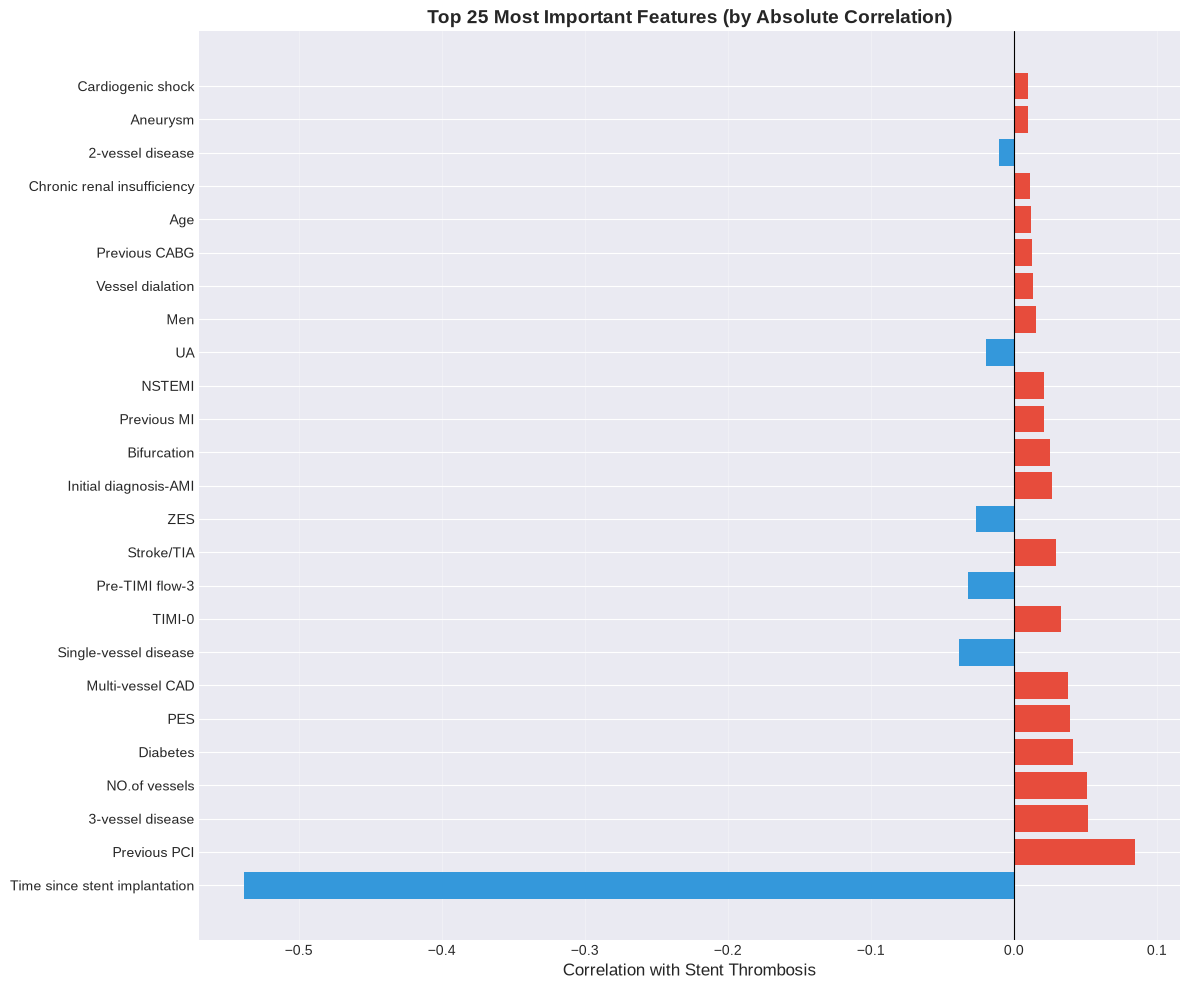

✓ Visualization saved: plots/09_feature_importance.png


In [356]:
# Feature importance summary (combined view)
if TARGET_COL in df.columns and len(correlations) > 0:
    # Create combined importance score
    importance_data = []
    for col in numeric_cols[:50]:  # Top 50 features
        try:
            corr_val = correlations.get(col, 0)
            importance_data.append(
                {
                    "Feature": col,
                    "Abs_Correlation": abs(corr_val),
                    "Correlation": corr_val,
                }
            )
        except:
            pass

    if importance_data:
        importance_df = (
            pd.DataFrame(importance_data)
            .sort_values("Abs_Correlation", ascending=False)
            .head(25)
        )

        fig, ax = plt.subplots(figsize=(12, 10))
        colors = [
            "#e74c3c" if x > 0 else "#3498db" for x in importance_df["Correlation"]
        ]
        ax.barh(range(len(importance_df)), importance_df["Correlation"], color=colors)
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df["Feature"])
        ax.set_xlabel("Correlation with Stent Thrombosis", fontsize=12)
        ax.set_title(
            "Top 25 Most Important Features (by Absolute Correlation)",
            fontsize=14,
            fontweight="bold",
        )
        ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
        ax.grid(True, alpha=0.3, axis="x")

        plt.tight_layout()
        plt.savefig(
            "../data/result/eda/plots/09_feature_importance.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        print("✓ Visualization saved: plots/09_feature_importance.png")

## 14. Key Insights and Summary

Let's synthesize all the findings from our analysis to extract actionable insights. This summary will help guide:
- **Feature Selection**: Which features are most predictive?
- **Data Preprocessing**: What transformations or imputations are needed?
- **Modeling Strategy**: What techniques should be considered?
- **Clinical Interpretation**: What are the key risk factors?


In [357]:
# Generate key insights
print("=" * 80)
print("KEY INSIGHTS AND SUMMARY")
print("=" * 80)

insights = []

# Target distribution insights
if imbalance_ratio < 0.3:
    insights.append(
        f"⚠ Class imbalance detected (ratio: {imbalance_ratio:.3f}). Consider using techniques like SMOTE or class weights."
    )
else:
    insights.append(
        f"✓ Class distribution is relatively balanced (ratio: {imbalance_ratio:.3f})"
    )

# Missing data insights
if len(missing_df) > 0:
    insights.append(
        f"⚠ {len(missing_df)} columns have missing values. Total missing: {missing_data.sum():,} ({missing_data.sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)"
    )
    insights.append(
        "   Consider imputation strategies for columns with <20% missing values."
    )

# Correlation insights
if TARGET_COL in df.columns and len(correlations) > 0:
    strong_pos = correlations[correlations > 0.3]
    strong_neg = correlations[correlations < -0.3]
    if len(strong_pos) > 0:
        insights.append(
            f"✓ {len(strong_pos)} features show strong positive correlation (>0.3) with stent thrombosis"
        )
    if len(strong_neg) > 0:
        insights.append(
            f"✓ {len(strong_neg)} features show strong negative correlation (<-0.3) with stent thrombosis"
        )
    if len(strong_pos) == 0 and len(strong_neg) == 0:
        insights.append(
            "⚠ No features show strong correlation (>0.3) with target. May need feature engineering."
        )

# Statistical significance insights (use current section-10 result frames)
if "continuous_test_df" in globals() and isinstance(continuous_test_df, pd.DataFrame) and not continuous_test_df.empty:
    sig_continuous = int((continuous_test_df["P-value"] < 0.05).sum())
    if "p_fdr_bh" in continuous_test_df.columns:
        fdr_continuous = int((continuous_test_df["p_fdr_bh"] < 0.05).sum())
        insights.append(
            f"✓ Continuous: {sig_continuous} raw p<0.05; {fdr_continuous} survive FDR q<0.05"
        )
    elif sig_continuous > 0:
        insights.append(
            f"✓ {sig_continuous} continuous features show statistically significant association (p < 0.05)"
        )

if "binary_test_df" in globals() and isinstance(binary_test_df, pd.DataFrame) and not binary_test_df.empty:
    sig_binary = int((binary_test_df["P-value"] < 0.05).sum())
    if "p_fdr_bh" in binary_test_df.columns:
        fdr_binary = int((binary_test_df["p_fdr_bh"] < 0.05).sum())
        insights.append(
            f"✓ Binary: {sig_binary} raw p<0.05; {fdr_binary} survive FDR q<0.05"
        )
    elif sig_binary > 0:
        insights.append(
            f"✓ {sig_binary} binary features show statistically significant association (p < 0.05)"
        )
elif "chi2_df" in globals() and isinstance(chi2_df, pd.DataFrame) and not chi2_df.empty:
    sig_binary = int((chi2_df["P-value"] < 0.05).sum())
    if sig_binary > 0:
        insights.append(
            f"✓ {sig_binary} binary features show statistically significant association (p < 0.05)"
        )

if "categorical_test_df" in globals() and isinstance(categorical_test_df, pd.DataFrame) and not categorical_test_df.empty:
    sig_cat = int((categorical_test_df["P-value"] < 0.05).sum())
    insights.append(
        f"✓ Categorical: {sig_cat} feature(s) with significant association (p < 0.05)"
    )

# Feature count insights
insights.append(
    f"✓ Dataset contains {len(binary_cols)} binary features, {len(continuous_cols)} continuous features, and {len(categorical_cols)} categorical features"
)

print("\nKey Insights:")
for i, insight in enumerate(insights, 1):
    print(f"  {i}. {insight}")


KEY INSIGHTS AND SUMMARY

Key Insights:
  1. ⚠ Class imbalance detected (ratio: 0.018). Consider using techniques like SMOTE or class weights.
  2. ✓ 1 features show strong negative correlation (<-0.3) with stent thrombosis
  3. ✓ Continuous: 13 raw p<0.05; 10 survive FDR q<0.05
  4. ✓ Binary: 15 raw p<0.05; 10 survive FDR q<0.05
  5. ✓ Categorical: 1 feature(s) with significant association (p < 0.05)
  6. ✓ Dataset contains 57 binary features, 24 continuous features, and 1 categorical features


In [358]:
# Top important features
if TARGET_COL in df.columns and len(correlations) > 0:
    print("\n" + "-" * 80)
    print("TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)")
    print("-" * 80)
    top_features = correlations.abs().nlargest(10)
    for idx, (feature, corr) in enumerate(top_features.items(), 1):
        direction = "increases" if correlations[feature] > 0 else "decreases"
        print(
            f"  {idx:2d}. {feature:40s} | Correlation: {correlations[feature]:7.4f} | {direction} risk"
        )


--------------------------------------------------------------------------------
TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)
--------------------------------------------------------------------------------
   1. Time since stent implantation            | Correlation: -0.5384 | decreases risk
   2. WBC                                      | Correlation:  0.1502 | increases risk
   3. LV                                       | Correlation:  0.1472 | increases risk
   4. eGFR                                     | Correlation: -0.0937 | decreases risk
   5. 1.1:1Post dilation                       | Correlation: -0.0893 | decreases risk
   6. No postdilation                          | Correlation:  0.0893 | increases risk
   7. Previous PCI                             | Correlation:  0.0850 | increases risk
   8. CKD90                                    | Correlation:  0.0626 | increases risk
   9. No.of stents per lesion                  | Correlation:  0.0604 | increases ri

## 15. Export Summary Statistics

Finally, let's save all the summary statistics and analysis results to CSV files for further reference and reporting.


In [359]:
# Save correlations / summary statistics
print("\n" + "=" * 80)
print("SAVING SUMMARY STATISTICS")
print("=" * 80)

from pathlib import Path

if "PLOT_DIR" not in globals():
    for _cand in [
        Path("../data/result/eda/plots"),
        Path("data/result/eda/plots"),
        Path("code/data/result/eda/plots"),
    ]:
        try:
            _cand.mkdir(parents=True, exist_ok=True)
            PLOT_DIR = _cand
            break
        except Exception:
            continue
    else:
        PLOT_DIR = Path("../data/result/eda/plots")
        PLOT_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL in df.columns:
    corr_df = pd.DataFrame(
        {
            "Feature": correlations.index,
            "Correlation": correlations.values,
            "Abs_Correlation": correlations.abs().values,
        }
    ).sort_values("Abs_Correlation", ascending=False)
    corr_df.to_csv(str(PLOT_DIR / "correlations_with_target.csv"), index=False)
    print("✓ Saved: plots/correlations_with_target.csv")

# Save statistical test results from section 10 frames
if "continuous_test_df" in globals() and isinstance(continuous_test_df, pd.DataFrame) and not continuous_test_df.empty:
    continuous_test_df.to_csv(str(PLOT_DIR / "statistical_tests_continuous.csv"), index=False)
    print("✓ Saved: plots/statistical_tests_continuous.csv")

if "binary_test_df" in globals() and isinstance(binary_test_df, pd.DataFrame) and not binary_test_df.empty:
    binary_test_df.to_csv(str(PLOT_DIR / "statistical_tests_binary.csv"), index=False)
    print("✓ Saved: plots/statistical_tests_binary.csv")
elif "chi2_df" in globals() and isinstance(chi2_df, pd.DataFrame) and not chi2_df.empty:
    chi2_df.to_csv(str(PLOT_DIR / "statistical_tests_binary.csv"), index=False)
    print("✓ Saved: plots/statistical_tests_binary.csv")

if "categorical_test_df" in globals() and isinstance(categorical_test_df, pd.DataFrame) and not categorical_test_df.empty:
    categorical_test_df.to_csv(str(PLOT_DIR / "statistical_tests_categorical.csv"), index=False)
    print("✓ Saved: plots/statistical_tests_categorical.csv")

# Save data summary
summary = {
    "Total_Rows": df.shape[0],
    "Total_Columns": df.shape[1],
    "Target_Class_0": target_counts.get(0, 0),
    "Target_Class_1": target_counts.get(1, 0),
    "Class_Imbalance_Ratio": imbalance_ratio,
    "Missing_Values_Total": int(missing_data.sum()) if "missing_data" in globals() else None,
    "Binary_Features": len(binary_cols),
    "Continuous_Features": len(continuous_cols),
    "Categorical_Features": len(categorical_cols),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(str(PLOT_DIR / "data_summary.csv"), index=False)
print("✓ Saved: plots/data_summary.csv")



SAVING SUMMARY STATISTICS
✓ Saved: plots/correlations_with_target.csv
✓ Saved: plots/statistical_tests_continuous.csv
✓ Saved: plots/statistical_tests_binary.csv
✓ Saved: plots/statistical_tests_categorical.csv
✓ Saved: plots/data_summary.csv


## 16. Additional Deep-Dive Analyses

Let's perform some additional analyses that provide deeper insights into the data:
- **Demographic Analysis**: Age and gender breakdowns by target
- **Categorical Variable Analysis**: Detailed analysis of stent types and other categorical features
- **Time-based Analysis**: Time since stent implantation patterns
- **Multicollinearity Check**: Identify highly correlated features that might cause redundancy
- **Distribution Shape Analysis**: Skewness and kurtosis for continuous variables


### 16.1 Demographic Analysis

Understanding how demographic factors (age, gender) relate to stent thrombosis can provide important clinical insights.


DEMOGRAPHIC ANALYSIS

Age Statistics by Target:
                   mean  median    std  min  max
Stent thrombosis                                
0                 59.83    60.0   9.93   28   89
1                 60.71    62.0  11.33   29   83


Gender Distribution by Target:
Stent thrombosis     0   1   All
Men                             
0                 1604  24  1628
1                 3489  68  3557
All               5093  92  5185

Gender Distribution (Percentages):
Stent thrombosis      0     1
Men                          
0                 98.53  1.47
1                 98.09  1.91


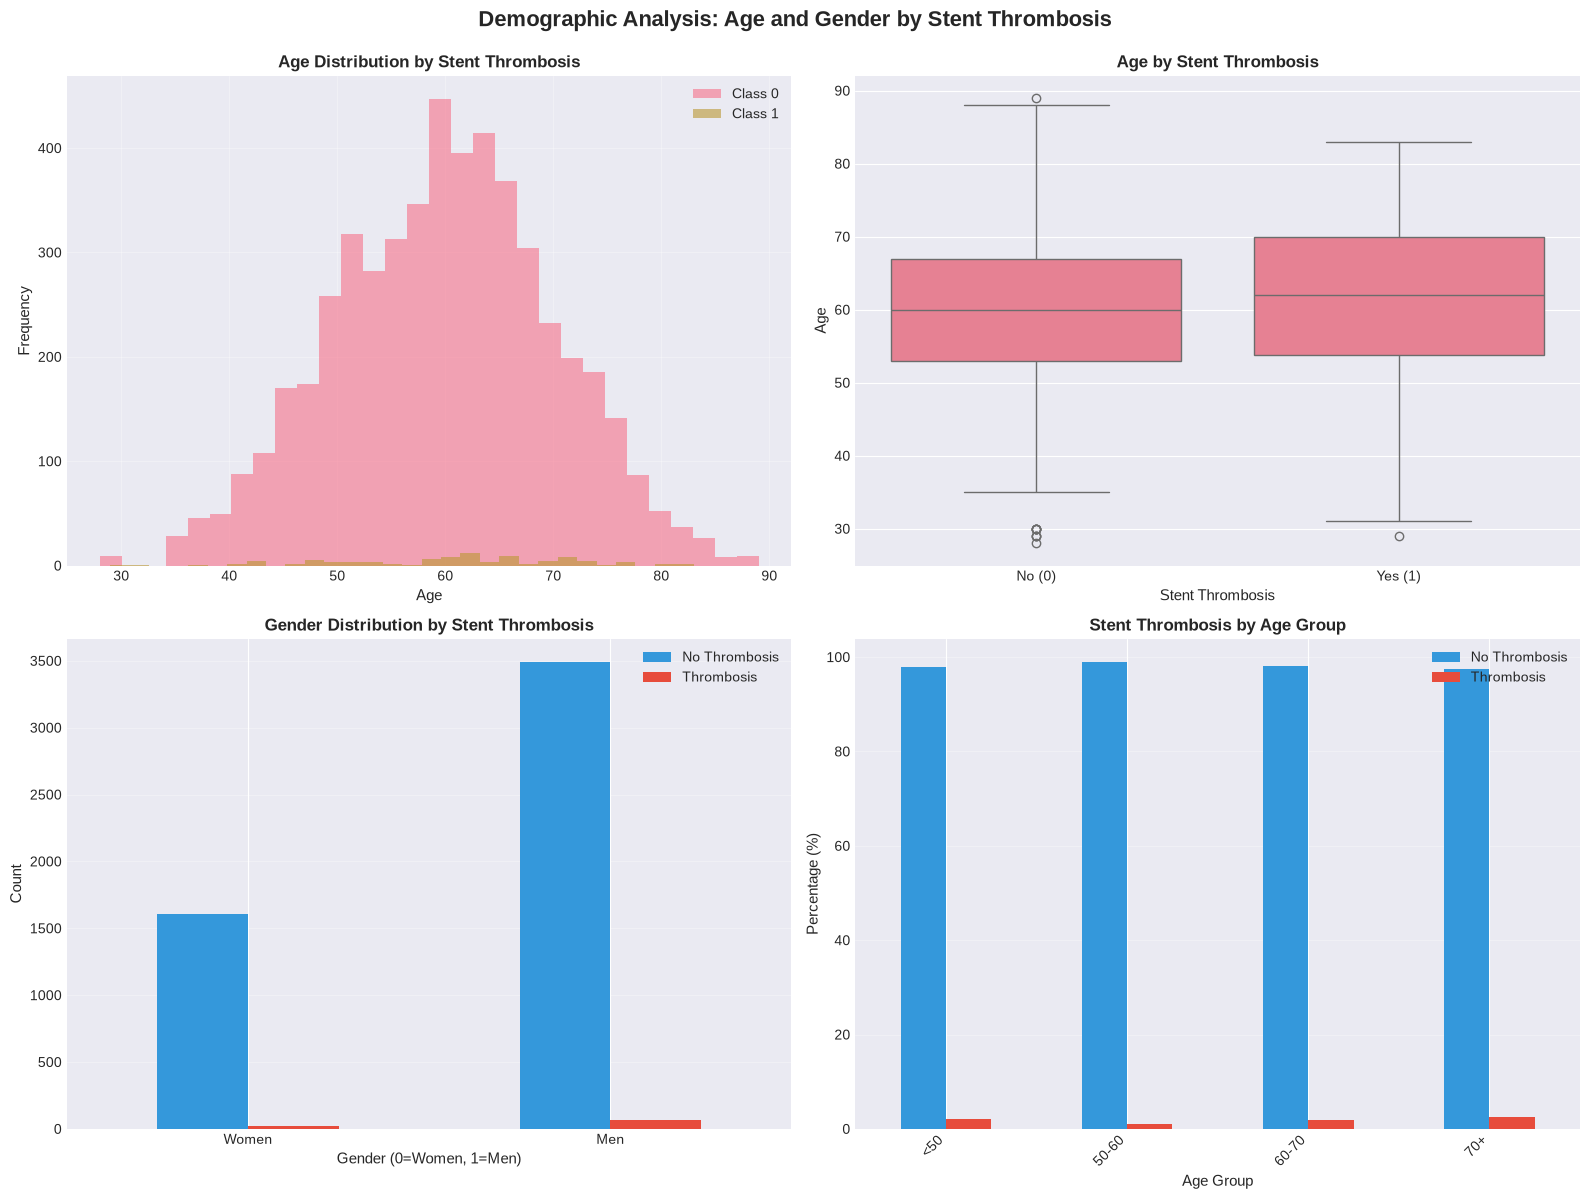


✓ Visualization saved: plots/10_demographic_analysis.png


In [360]:
# Demographic analysis
if "Age" in df.columns and "Men" in df.columns:
    print("=" * 80)
    print("DEMOGRAPHIC ANALYSIS")
    print("=" * 80)

    # Age analysis
    print("\nAge Statistics by Target:")
    age_by_target = df.groupby(TARGET_COL)["Age"].agg(
        ["mean", "median", "std", "min", "max"]
    )
    print(age_by_target.round(2))

    # Gender analysis
    print("\n\nGender Distribution by Target:")
    gender_crosstab = pd.crosstab(df["Men"], df[TARGET_COL], margins=True)
    print(gender_crosstab)
    print("\nGender Distribution (Percentages):")
    gender_pct = pd.crosstab(df["Men"], df[TARGET_COL], normalize="index") * 100
    print(gender_pct.round(2))

    # Visualize demographics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Age distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Age"].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f"Class {target_val}", bins=30)
    axes[0, 0].set_title(
        "Age Distribution by Stent Thrombosis", fontsize=12, fontweight="bold"
    )
    axes[0, 0].set_xlabel("Age", fontsize=11)
    axes[0, 0].set_ylabel("Frequency", fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Age box plot
    sns.boxplot(data=df, x=TARGET_COL, y="Age", ax=axes[0, 1])
    axes[0, 1].set_title("Age by Stent Thrombosis", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Stent Thrombosis", fontsize=11)
    axes[0, 1].set_ylabel("Age", fontsize=11)
    axes[0, 1].set_xticklabels(["No (0)", "Yes (1)"])

    # Gender distribution
    gender_target = pd.crosstab(df["Men"], df[TARGET_COL])
    gender_target.plot(kind="bar", ax=axes[1, 0], color=["#3498db", "#e74c3c"])
    axes[1, 0].set_title(
        "Gender Distribution by Stent Thrombosis", fontsize=12, fontweight="bold"
    )
    axes[1, 0].set_xlabel("Gender (0=Women, 1=Men)", fontsize=11)
    axes[1, 0].set_ylabel("Count", fontsize=11)
    axes[1, 0].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 0].set_xticklabels(["Women", "Men"], rotation=0)
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Age groups analysis
    df["Age_Group"] = pd.cut(
        df["Age"], bins=[0, 50, 60, 70, 100], labels=["<50", "50-60", "60-70", "70+"]
    )
    age_group_crosstab = (
        pd.crosstab(df["Age_Group"], df[TARGET_COL], normalize="index") * 100
    )
    age_group_crosstab.plot(kind="bar", ax=axes[1, 1], color=["#3498db", "#e74c3c"])
    axes[1, 1].set_title(
        "Stent Thrombosis by Age Group", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Age Group", fontsize=11)
    axes[1, 1].set_ylabel("Percentage (%)", fontsize=11)
    axes[1, 1].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha="right")
    axes[1, 1].grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        "Demographic Analysis: Age and Gender by Stent Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/10_demographic_analysis.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("\n✓ Visualization saved: plots/10_demographic_analysis.png")

    # Clean up temporary column
    df.drop("Age_Group", axis=1, inplace=True)

### 16.2 Categorical Variable Analysis

Let's analyze categorical variables like stent types to understand their distribution and relationship with the target.


In [361]:
# Categorical variable analysis
if len(categorical_cols) > 0:
    print("=" * 80)
    print("CATEGORICAL VARIABLE ANALYSIS")
    print("=" * 80)

    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print("  Most common values:")
        value_counts = df[col].value_counts().head(10)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"    {val}: {count} ({pct:.2f}%)")

        # Analyze relationship with target
        if (
            df[col].nunique() <= 20
        ):  # Only for variables with reasonable number of categories
            print("\n  Relationship with Stent Thrombosis:")
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
            print(crosstab.round(2))

            # Statistical test if binary
            if df[col].nunique() == 2:
                try:
                    contingency = pd.crosstab(df[col], df[TARGET_COL])
                    if contingency.shape == (2, 2) and contingency.min().min() > 0:
                        chi2, p_value, dof, expected = chi2_contingency(contingency)
                        print(f"  Chi-square test: p-value = {p_value:.4f}")
                except:
                    pass
        print("-" * 80)

CATEGORICAL VARIABLE ANALYSIS

Stent type-SES:
  Unique values: 106
  Most common values:
    Partner: 1017 (19.61%)
    Excel: 959 (18.50%)
    Resolute: 844 (16.28%)
    Firebird: 750 (14.46%)
    Tivoli: 590 (11.38%)
    XX: 249 (4.80%)
    XV: 198 (3.82%)
    XienceV: 184 (3.55%)
    excel: 30 (0.58%)
    XP: 25 (0.48%)
--------------------------------------------------------------------------------


### 17.3 Time-Based Analysis

"Time since stent implantation" is a critical feature. Let's analyze how time patterns relate to stent thrombosis.


TIME-BASED ANALYSIS

Time since stent implantation statistics:
  Mean: 1410.0 days (3.86 years)
  Median: 1416.0 days (3.88 years)
  Min: 380.0 days (1.04 years)
  Max: 1605.0 days (4.39 years)

Time statistics by Target:
                     mean  median     std   min   max
Stent thrombosis                                     
0                 1420.11  1419.0  107.70  1241  1605
1                  848.05   736.0  383.77   380  1575


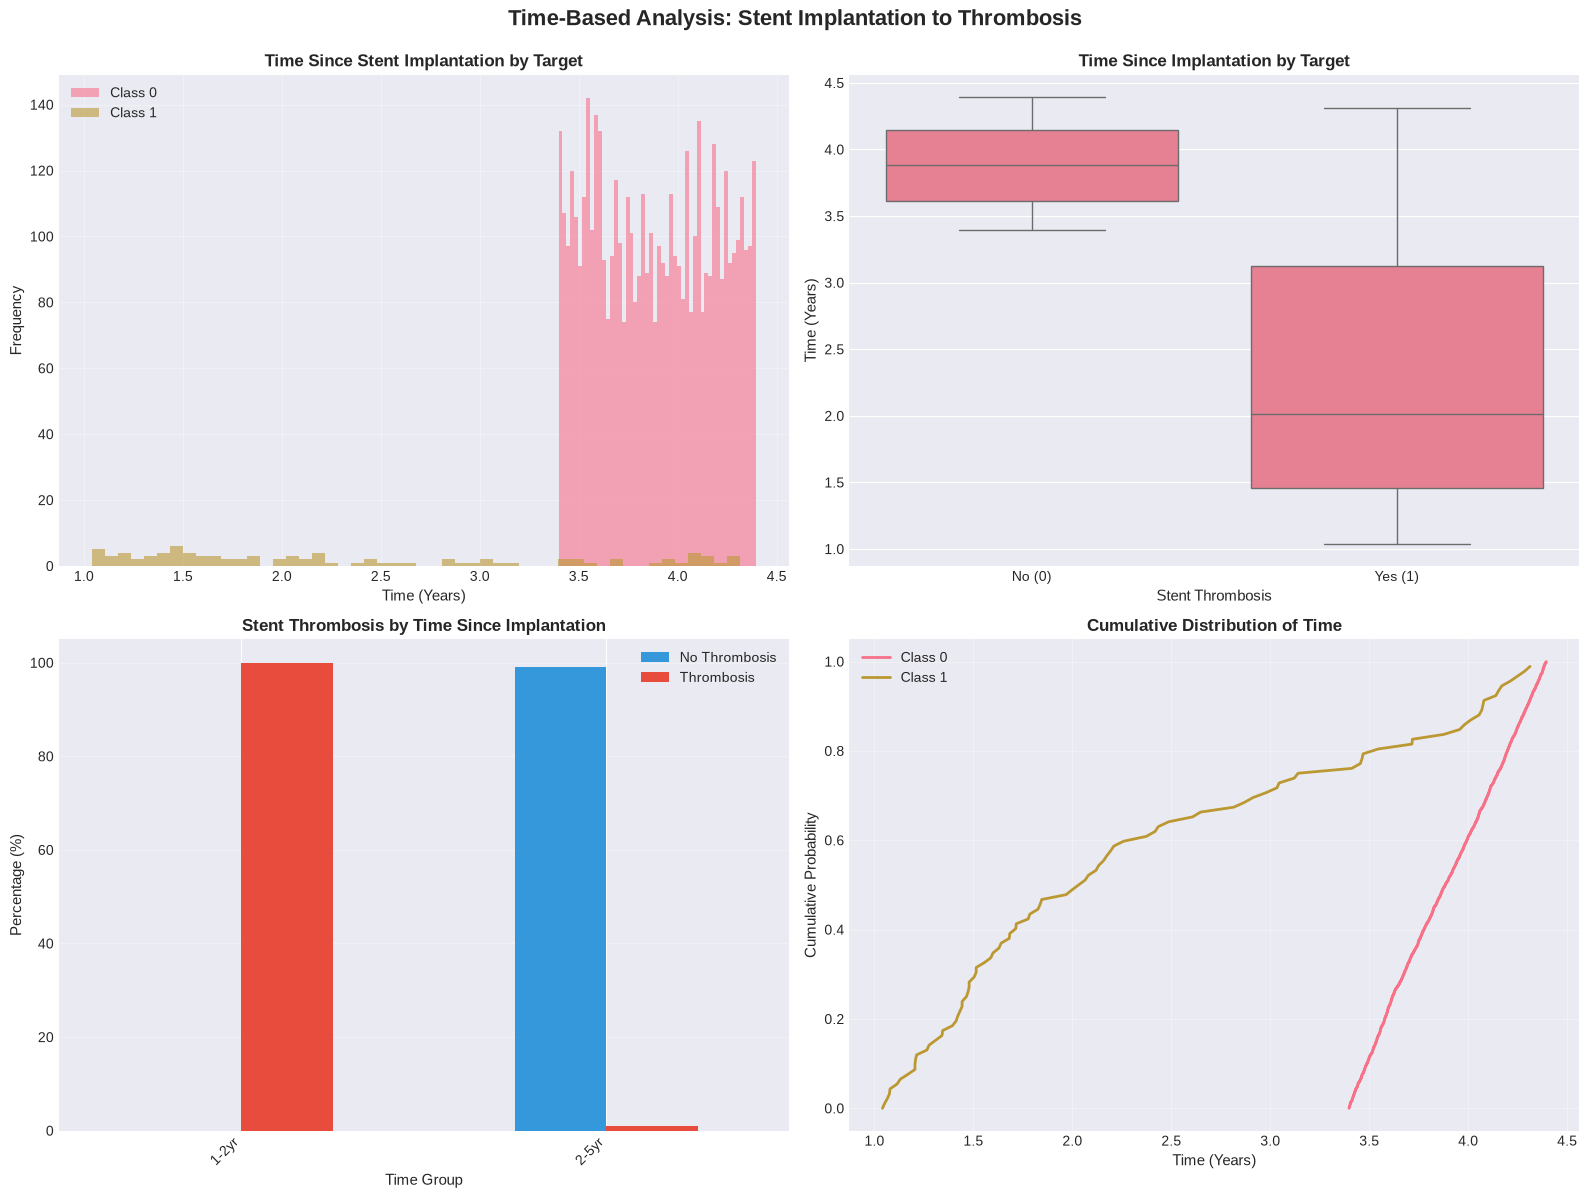


✓ Visualization saved: plots/11_time_analysis.png


In [362]:
# Time-based analysis
time_col = "Time since stent implantation"
if time_col in df.columns:
    print("=" * 80)
    print("TIME-BASED ANALYSIS")
    print("=" * 80)

    # Convert to years for easier interpretation
    df["Time_years"] = df[time_col] / 365.25

    print("\nTime since stent implantation statistics:")
    print(
        f"  Mean: {df[time_col].mean():.1f} days ({df['Time_years'].mean():.2f} years)"
    )
    print(
        f"  Median: {df[time_col].median():.1f} days ({df['Time_years'].median():.2f} years)"
    )
    print(f"  Min: {df[time_col].min():.1f} days ({df['Time_years'].min():.2f} years)")
    print(f"  Max: {df[time_col].max():.1f} days ({df['Time_years'].max():.2f} years)")

    print("\nTime statistics by Target:")
    time_by_target = df.groupby(TARGET_COL)[time_col].agg(
        ["mean", "median", "std", "min", "max"]
    )
    print(time_by_target.round(2))

    # Create time groups
    df["Time_Group"] = pd.cut(
        df["Time_years"],
        bins=[0, 1, 2, 5, 10, 100],
        labels=["<1yr", "1-2yr", "2-5yr", "5-10yr", "10+yr"],
    )

    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Time_years"].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f"Class {target_val}", bins=50)
    axes[0, 0].set_title(
        "Time Since Stent Implantation by Target", fontsize=12, fontweight="bold"
    )
    axes[0, 0].set_xlabel("Time (Years)", fontsize=11)
    axes[0, 0].set_ylabel("Frequency", fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Box plot
    sns.boxplot(data=df, x=TARGET_COL, y="Time_years", ax=axes[0, 1])
    axes[0, 1].set_title(
        "Time Since Implantation by Target", fontsize=12, fontweight="bold"
    )
    axes[0, 1].set_xlabel("Stent Thrombosis", fontsize=11)
    axes[0, 1].set_ylabel("Time (Years)", fontsize=11)
    axes[0, 1].set_xticklabels(["No (0)", "Yes (1)"])

    # Time groups
    time_group_crosstab = (
        pd.crosstab(df["Time_Group"], df[TARGET_COL], normalize="index") * 100
    )
    time_group_crosstab.plot(kind="bar", ax=axes[1, 0], color=["#3498db", "#e74c3c"])
    axes[1, 0].set_title(
        "Stent Thrombosis by Time Since Implantation", fontsize=12, fontweight="bold"
    )
    axes[1, 0].set_xlabel("Time Group", fontsize=11)
    axes[1, 0].set_ylabel("Percentage (%)", fontsize=11)
    axes[1, 0].legend(["No Thrombosis", "Thrombosis"])
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha="right")
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Cumulative distribution
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]["Time_years"].dropna().sort_values()
        axes[1, 1].plot(
            data,
            np.arange(len(data)) / len(data),
            label=f"Class {target_val}",
            linewidth=2,
        )
    axes[1, 1].set_title(
        "Cumulative Distribution of Time", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Time (Years)", fontsize=11)
    axes[1, 1].set_ylabel("Cumulative Probability", fontsize=11)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(
        "Time-Based Analysis: Stent Implantation to Thrombosis",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/11_time_analysis.png", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print("\n✓ Visualization saved: plots/11_time_analysis.png")

    # Clean up temporary columns
    df.drop(["Time_years", "Time_Group"], axis=1, inplace=True)

### 17.4 Medicine Use After One Year

Antiplatelet therapy is recorded as binary indicators (`Aspirin`, `Clopidogrel`, `Ticagrelor`, `DAPT`). Here we summarize which medicines were used and how many patients received each regimen among patients with at least one year of follow-up since stent implantation.


MEDICINE USE AFTER ONE YEAR

Patients with >= 1 year follow-up: 5,185 / 5,185
Follow-up range in this group: 380 to 1605 days

Individual medicine usage:


,Patients on medicine,Patients not on medicine,Percentage on medicine
Aspirin,3193,1992,61.58
Clopidogrel,2396,2789,46.21
Ticagrelor,91,5094,1.76
DAPT,2295,2890,44.26



Medicine regimen distribution:


,Medicine regimen,Number of patients,Percentage of patients
0,Aspirin + Clopidogrel + DAPT,2215,42.72
1,No antiplatelet medicine,1788,34.48
2,Aspirin,903,17.42
3,Clopidogrel,181,3.49
4,Aspirin + Ticagrelor + DAPT,72,1.39
5,Ticagrelor,18,0.35
6,DAPT,4,0.08
7,Aspirin + DAPT,3,0.06
8,Ticagrelor + DAPT,1,0.02


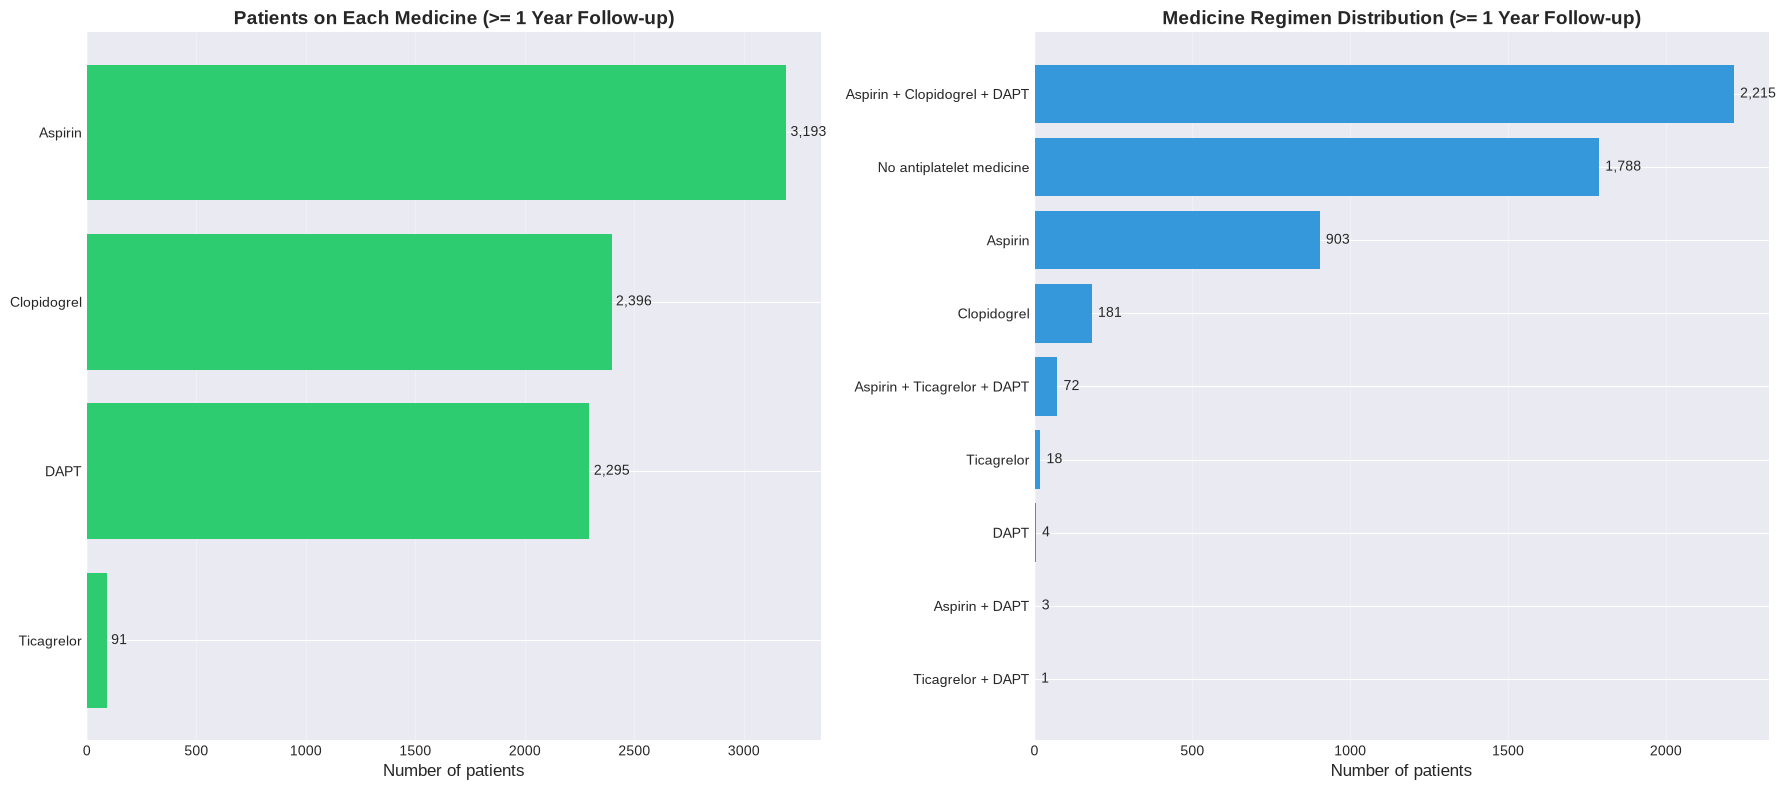

✓ Visualization saved: plots/13_medicine_use_after_one_year.png
✓ Saved: plots/medicine_use_after_one_year_individual.csv
✓ Saved: plots/medicine_use_after_one_year_regimens.csv


In [363]:
# Medicine distribution among patients with >= 1 year follow-up
time_col = "Time since stent implantation"
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
one_year_days = 365

if time_col in df.columns and all(col in df.columns for col in medicine_cols):
    print("=" * 80)
    print("MEDICINE USE AFTER ONE YEAR")
    print("=" * 80)

    df_after_1y = df[df[time_col] >= one_year_days].copy()
    n_after_1y = len(df_after_1y)

    print(f"\nPatients with >= 1 year follow-up: {n_after_1y:,} / {len(df):,}")
    print(
        f"Follow-up range in this group: {df_after_1y[time_col].min():.0f} to "
        f"{df_after_1y[time_col].max():.0f} days"
    )

    # Individual medicine usage counts
    med_counts = (
        df_after_1y[medicine_cols]
        .sum()
        .astype(int)
        .rename("Patients on medicine")
        .to_frame()
    )
    med_counts["Patients not on medicine"] = n_after_1y - med_counts["Patients on medicine"]
    med_counts["Percentage on medicine"] = (
        med_counts["Patients on medicine"] / n_after_1y * 100
    ).round(2)

    print("\nIndividual medicine usage:")
    display(med_counts)

    # Combination regimens
    def medicine_regimen(row):
        active = [col for col in medicine_cols if row[col] == 1]
        return " + ".join(active) if active else "No antiplatelet medicine"

    regimen_counts = (
        df_after_1y[medicine_cols]
        .apply(medicine_regimen, axis=1)
        .value_counts()
        .rename_axis("Medicine regimen")
        .reset_index(name="Number of patients")
    )
    regimen_counts["Percentage of patients"] = (
        regimen_counts["Number of patients"] / n_after_1y * 100
    ).round(2)

    print("\nMedicine regimen distribution:")
    display(regimen_counts)

    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    med_plot = med_counts["Patients on medicine"].sort_values(ascending=True)
    axes[0].barh(med_plot.index, med_plot.values, color="#2ecc71")
    axes[0].set_title(
        "Patients on Each Medicine (>= 1 Year Follow-up)",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_xlabel("Number of patients", fontsize=12)
    axes[0].grid(True, alpha=0.3, axis="x")
    for i, value in enumerate(med_plot.values):
        axes[0].text(value + 20, i, f"{value:,}", va="center", fontsize=10)

    regimen_plot = regimen_counts.sort_values("Number of patients", ascending=True)
    axes[1].barh(
        regimen_plot["Medicine regimen"],
        regimen_plot["Number of patients"],
        color="#3498db",
    )
    axes[1].set_title(
        "Medicine Regimen Distribution (>= 1 Year Follow-up)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Number of patients", fontsize=12)
    axes[1].grid(True, alpha=0.3, axis="x")
    for i, value in enumerate(regimen_plot["Number of patients"].values):
        axes[1].text(value + 20, i, f"{value:,}", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/13_medicine_use_after_one_year.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/13_medicine_use_after_one_year.png")

    med_counts.to_csv(
        "../data/result/eda/plots/medicine_use_after_one_year_individual.csv"
    )
    regimen_counts.to_csv(
        "../data/result/eda/plots/medicine_use_after_one_year_regimens.csv",
        index=False,
    )
    print("✓ Saved: plots/medicine_use_after_one_year_individual.csv")
    print("✓ Saved: plots/medicine_use_after_one_year_regimens.csv")
else:
    missing = [col for col in [time_col] + medicine_cols if col not in df.columns]
    print(f"Missing required columns for medicine analysis: {missing}")


### 17.5 Medicine Use vs Stent Thrombosis (VLST)

Compare antiplatelet medicine use between patients with and without stent thrombosis, then examine the stent thrombosis rate within each medicine-consuming subgroup.


MEDICINE USE BY STENT THROMBOSIS OUTCOME

Medicine use by outcome (includes patients on no antiplatelet medicine):


,Outcome,Medicine,Patients on medicine,Patients not on medicine,Percentage on medicine
0,Stent thrombosis (VLST),Aspirin,45,47,48.91
1,Stent thrombosis (VLST),Clopidogrel,28,64,30.43
2,Stent thrombosis (VLST),Ticagrelor,1,91,1.09
3,Stent thrombosis (VLST),DAPT,35,57,38.04
4,Stent thrombosis (VLST),No antiplatelet medicine,41,51,44.57
5,No stent thrombosis,Aspirin,3148,1945,61.81
6,No stent thrombosis,Clopidogrel,2368,2725,46.50
7,No stent thrombosis,Ticagrelor,90,5003,1.77
8,No stent thrombosis,DAPT,2260,2833,44.37
9,No stent thrombosis,No antiplatelet medicine,1747,3346,34.30


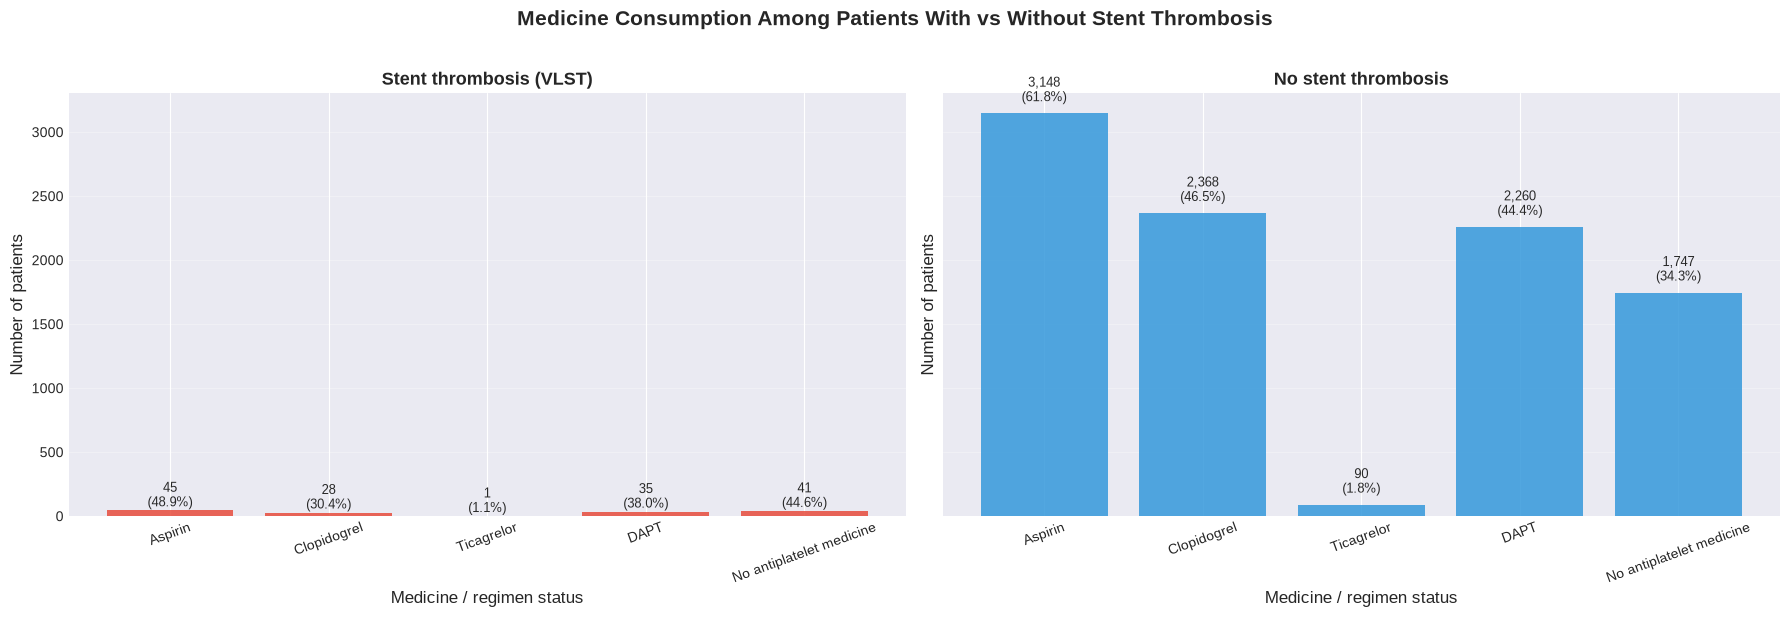

✓ Visualization saved: plots/14_medicine_use_by_vlst_outcome.png
✓ Saved: plots/medicine_use_by_vlst_outcome.csv


In [364]:
# Medicine consumption distribution by stent thrombosis outcome
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    print("=" * 80)
    print("MEDICINE USE BY STENT THROMBOSIS OUTCOME")
    print("=" * 80)

    df = df.copy()
    df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    outcome_labels = {
        1: "Stent thrombosis (VLST)",
        0: "No stent thrombosis",
    }

    med_by_outcome = []
    for outcome_value, outcome_label in outcome_labels.items():
        group = df[df[TARGET_COL] == outcome_value]
        group_size = len(group)

        for med in medicine_display_cols:
            on_med = int(group[med].sum())
            med_by_outcome.append(
                {
                    "Outcome": outcome_label,
                    "Medicine": med,
                    "Patients on medicine": on_med,
                    "Patients not on medicine": group_size - on_med,
                    "Percentage on medicine": round(on_med / group_size * 100, 2),
                }
            )

    med_by_outcome_df = pd.DataFrame(med_by_outcome)
    print("\nMedicine use by outcome (includes patients on no antiplatelet medicine):")
    display(med_by_outcome_df)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    colors = ["#e74c3c", "#3498db"]

    for ax, (outcome_value, outcome_label), color in zip(
        axes, outcome_labels.items(), colors
    ):
        subset = med_by_outcome_df[med_by_outcome_df["Outcome"] == outcome_label]
        bars = ax.bar(
            subset["Medicine"],
            subset["Patients on medicine"],
            color=color,
            alpha=0.85,
        )
        ax.set_title(outcome_label, fontsize=13, fontweight="bold")
        ax.set_xlabel("Medicine / regimen status", fontsize=12)
        ax.set_ylabel("Number of patients", fontsize=12)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(True, alpha=0.3, axis="y")
        ymax = subset["Patients on medicine"].max()
        for bar, pct in zip(bars, subset["Percentage on medicine"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.02,
                f"{int(bar.get_height()):,}\n({pct:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    fig.suptitle(
        "Medicine Consumption Among Patients With vs Without Stent Thrombosis",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/14_medicine_use_by_vlst_outcome.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/14_medicine_use_by_vlst_outcome.png")

    med_by_outcome_df.to_csv(
        "../data/result/eda/plots/medicine_use_by_vlst_outcome.csv", index=False
    )
    print("✓ Saved: plots/medicine_use_by_vlst_outcome.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


STENT THROMBOSIS RATE BY MEDICINE CONSUMPTION

VLST rate by medicine consumption:


,Medicine,Patients on medicine,VLST cases on medicine,VLST rate on medicine (%),Patients not on medicine,VLST cases not on medicine,VLST rate not on medicine (%)
0,Aspirin,3193,45,1.41,1992,47,2.36
1,Clopidogrel,2396,28,1.17,2789,64,2.29
2,Ticagrelor,91,1,1.10,5094,91,1.79
3,DAPT,2295,35,1.53,2890,57,1.97
4,No antiplatelet medicine,1788,41,2.29,3397,51,1.50


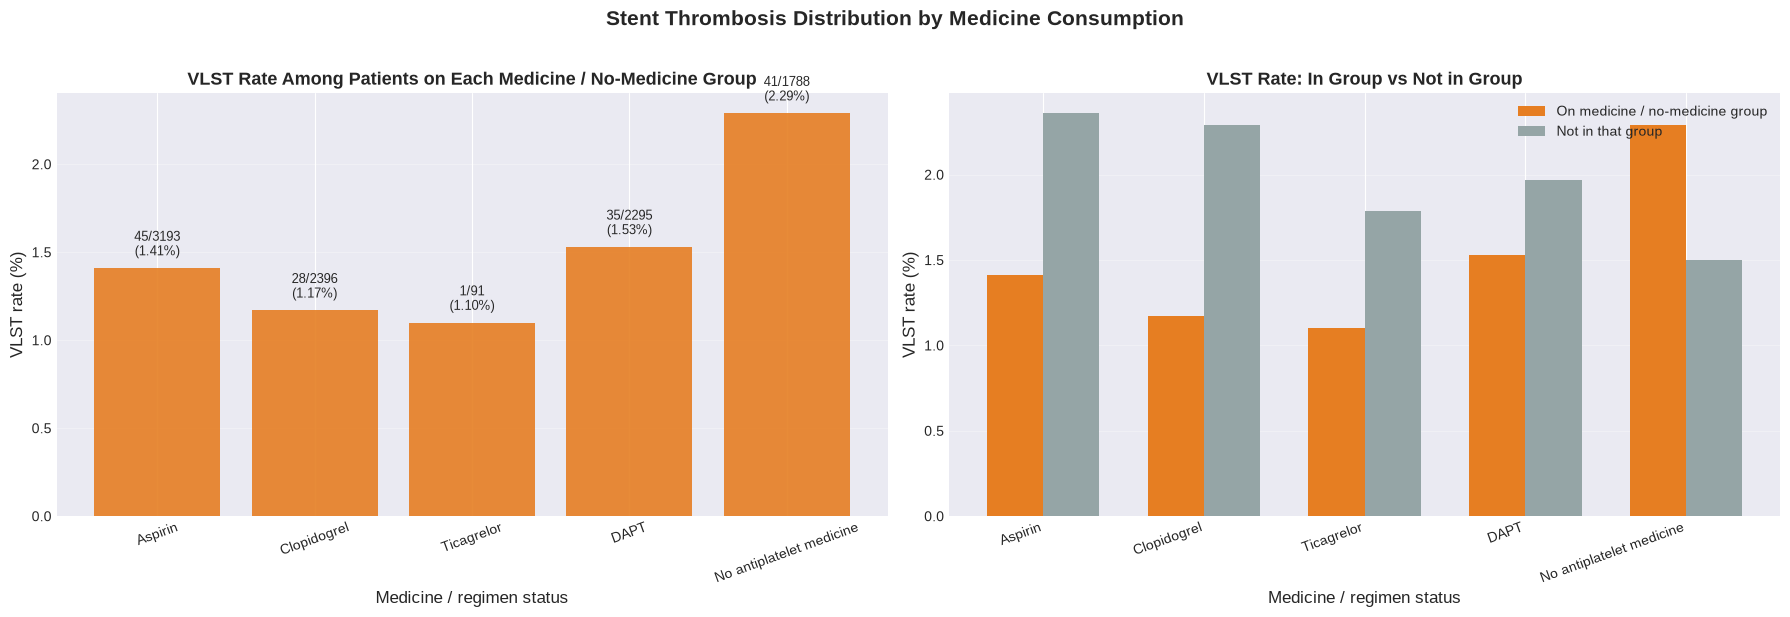

✓ Visualization saved: plots/15_vlst_rate_by_medicine_consumption.png
✓ Saved: plots/vlst_rate_by_medicine_consumption.csv


In [365]:
# Stent thrombosis rate among patients on each medicine (including no medicine)
medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    if "No antiplatelet medicine" not in df.columns:
        df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    print("=" * 80)
    print("STENT THROMBOSIS RATE BY MEDICINE CONSUMPTION")
    print("=" * 80)

    vlst_by_medicine = []
    for med in medicine_display_cols:
        on_med = df[df[med] == 1]
        off_med = df[df[med] == 0]

        vlst_on = int(on_med[TARGET_COL].sum())
        vlst_off = int(off_med[TARGET_COL].sum())

        vlst_by_medicine.append(
            {
                "Medicine": med,
                "Patients on medicine": len(on_med),
                "VLST cases on medicine": vlst_on,
                "VLST rate on medicine (%)": round(vlst_on / len(on_med) * 100, 2),
                "Patients not on medicine": len(off_med),
                "VLST cases not on medicine": vlst_off,
                "VLST rate not on medicine (%)": round(vlst_off / len(off_med) * 100, 2),
            }
        )

    vlst_by_medicine_df = pd.DataFrame(vlst_by_medicine)
    print("\nVLST rate by medicine consumption:")
    display(vlst_by_medicine_df)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    bars_on = axes[0].bar(
        vlst_by_medicine_df["Medicine"],
        vlst_by_medicine_df["VLST rate on medicine (%)"],
        color="#e67e22",
        alpha=0.9,
    )
    axes[0].set_title(
        "VLST Rate Among Patients on Each Medicine / No-Medicine Group",
        fontsize=13,
        fontweight="bold",
    )
    axes[0].set_xlabel("Medicine / regimen status", fontsize=12)
    axes[0].set_ylabel("VLST rate (%)", fontsize=12)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(True, alpha=0.3, axis="y")
    for i, bar in enumerate(bars_on):
        row = vlst_by_medicine_df.iloc[i]
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{int(row['VLST cases on medicine'])}/{int(row['Patients on medicine'])}\n"
            f"({row['VLST rate on medicine (%)']:.2f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    x = np.arange(len(medicine_display_cols))
    width = 0.35
    axes[1].bar(
        x - width / 2,
        vlst_by_medicine_df["VLST rate on medicine (%)"],
        width,
        label="On medicine / no-medicine group",
        color="#e67e22",
    )
    axes[1].bar(
        x + width / 2,
        vlst_by_medicine_df["VLST rate not on medicine (%)"],
        width,
        label="Not in that group",
        color="#95a5a6",
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(medicine_display_cols, rotation=20, ha="right")
    axes[1].set_title(
        "VLST Rate: In Group vs Not in Group",
        fontsize=13,
        fontweight="bold",
    )
    axes[1].set_xlabel("Medicine / regimen status", fontsize=12)
    axes[1].set_ylabel("VLST rate (%)", fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis="y")

    fig.suptitle(
        "Stent Thrombosis Distribution by Medicine Consumption",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/15_vlst_rate_by_medicine_consumption.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/15_vlst_rate_by_medicine_consumption.png")

    vlst_by_medicine_df.to_csv(
        "../data/result/eda/plots/vlst_rate_by_medicine_consumption.csv", index=False
    )
    print("✓ Saved: plots/vlst_rate_by_medicine_consumption.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


### 17.6 Statistical Association: Medicine Use and VLST

Both **medicine use** and **stent thrombosis** are binary variables, so the appropriate primary tests are **2×2 association tests**:

- **Chi-square test of independence**: tests whether medicine status and VLST are associated in a contingency table. It is appropriate here because both variables are categorical and we compare group proportions.
- **Fisher's exact test**: preferred when any expected cell count is small (often < 5), which is common for rare medicines such as Ticagrelor. Fisher's exact is more reliable than chi-square in sparse tables.
- **Odds ratio (OR)**: quantifies effect size. OR > 1 means higher odds of VLST in the medicine-taking group; OR < 1 means lower odds.

**Why not other tests?**
- *t-test / Mann-Whitney*: for comparing continuous outcomes, not binary medicine vs binary VLST.
- *Correlation (Pearson/Spearman)*: measures linear/monotonic association between numeric variables; less interpretable for two binary variables than OR + Fisher/chi-square.
- *Logistic regression*: useful for multivariable adjustment (confounders), but univariate 2×2 tests are the correct first step for this EDA question.

**Important caveat:** these are observational associations, not causal effects. Medicine prescribing may be related to patient risk profile, so significant results should be interpreted as hypothesis-generating.


STATISTICAL ASSOCIATION: MEDICINE USE vs VLST

Univariate association tests (medicine vs VLST):


,Medicine,VLST on medicine,No VLST on medicine,VLST not on medicine,No VLST not on medicine,VLST rate on medicine (%),VLST rate not on medicine (%),Odds ratio,Chi-square p-value,Fisher p-value,Test used,P-value,Significant (p < 0.05)
1,Clopidogrel,28,2368,64,2725,1.17,2.29,0.503,0.003109,0.002133,Chi-square,0.003109,Yes
0,Aspirin,45,3148,47,1945,1.41,2.36,0.592,0.015844,0.012886,Chi-square,0.015844,Yes
4,No antiplatelet medicine,41,1747,51,3346,2.29,1.50,1.540,0.052142,0.046083,Chi-square,0.052142,No
3,DAPT,35,2260,57,2833,1.53,1.97,0.770,0.268807,0.244929,Chi-square,0.268807,No
2,Ticagrelor,1,90,91,5003,1.10,1.79,0.611,0.926815,1.000000,Fisher's exact,1.000000,No



--------------------------------------------------------------------------------
INTERPRETATION FROM CHARTS + STATISTICAL TESTS
--------------------------------------------------------------------------------

Medicines with statistically significant univariate association (p < 0.05):
  - Clopidogrel: OR=0.503, p=0.0031 (Chi-square) -> lower VLST odds in the 'on/group' category
  - Aspirin: OR=0.592, p=0.0158 (Chi-square) -> lower VLST odds in the 'on/group' category

Still significant after Bonferroni correction (p < 0.0100): Clopidogrel

Clinical reading:
  - Aspirin and Clopidogrel show lower VLST rates among users in the descriptive charts.
  - 'No antiplatelet medicine' patients have a higher VLST rate than patients on any medicine.
  - Ticagrelor has very few users/events, so it is underpowered and not reliable for strong conclusions.
  - DAPT alone does not show a clear univariate association with VLST in this dataset.
  - These patterns are associative; causal interpretation r

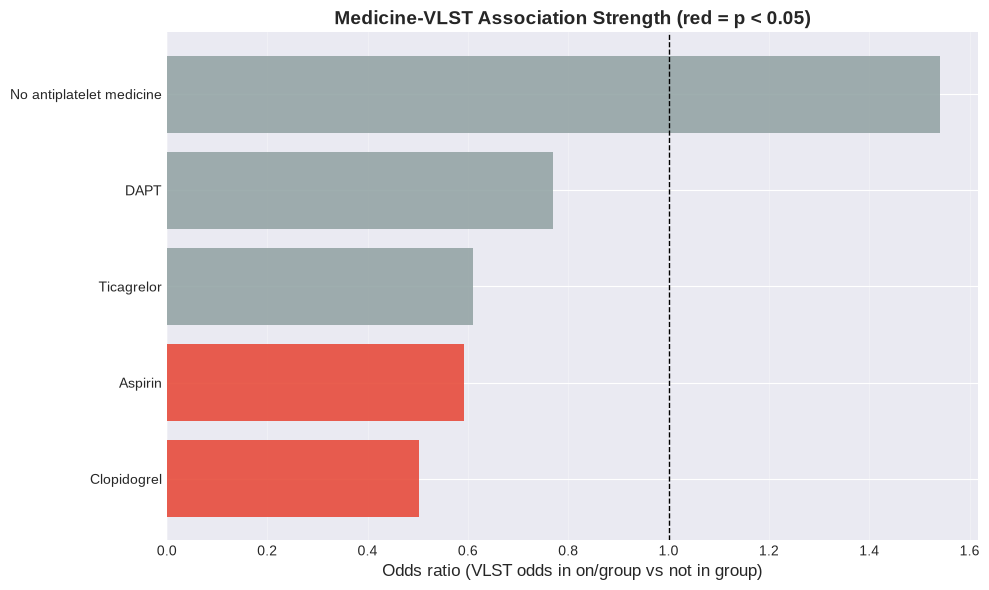

✓ Visualization saved: plots/16_medicine_vlst_odds_ratios.png
✓ Saved: plots/medicine_vlst_statistical_tests.csv


In [366]:
# Statistical tests for medicine-VLST association
from scipy.stats import chi2_contingency, fisher_exact

medicine_cols = ["Aspirin", "Clopidogrel", "Ticagrelor", "DAPT"]
medicine_display_cols = medicine_cols + ["No antiplatelet medicine"]

if TARGET_COL in df.columns and all(col in df.columns for col in medicine_cols):
    if "No antiplatelet medicine" not in df.columns:
        df["No antiplatelet medicine"] = (df[medicine_cols].sum(axis=1) == 0).astype(int)

    print("=" * 80)
    print("STATISTICAL ASSOCIATION: MEDICINE USE vs VLST")
    print("=" * 80)

    stat_rows = []
    for med in medicine_display_cols:
        contingency = pd.crosstab(df[med], df[TARGET_COL])
        # Ensure 2x2 layout: rows = medicine off/on, cols = no VLST / VLST
        a = int(contingency.loc[1, 1]) if (1 in contingency.index and 1 in contingency.columns) else 0
        b = int(contingency.loc[1, 0]) if (1 in contingency.index and 0 in contingency.columns) else 0
        c = int(contingency.loc[0, 1]) if (0 in contingency.index and 1 in contingency.columns) else 0
        d = int(contingency.loc[0, 0]) if (0 in contingency.index and 0 in contingency.columns) else 0
        table = np.array([[a, b], [c, d]])

        chi2, chi2_p, dof, expected = chi2_contingency(table)
        odds_ratio, fisher_p = fisher_exact(table, alternative="two-sided")
        min_expected = expected.min()

        if min_expected < 5:
            test_used = "Fisher's exact"
            p_value = fisher_p
        else:
            test_used = "Chi-square"
            p_value = chi2_p

        vlst_rate_on = round(a / (a + b) * 100, 2) if (a + b) > 0 else np.nan
        vlst_rate_off = round(c / (c + d) * 100, 2) if (c + d) > 0 else np.nan

        stat_rows.append(
            {
                "Medicine": med,
                "VLST on medicine": a,
                "No VLST on medicine": b,
                "VLST not on medicine": c,
                "No VLST not on medicine": d,
                "VLST rate on medicine (%)": vlst_rate_on,
                "VLST rate not on medicine (%)": vlst_rate_off,
                "Odds ratio": round(odds_ratio, 3),
                "Chi-square p-value": round(chi2_p, 6),
                "Fisher p-value": round(fisher_p, 6),
                "Test used": test_used,
                "P-value": round(p_value, 6),
                "Significant (p < 0.05)": "Yes" if p_value < 0.05 else "No",
            }
        )

    med_vlst_stats_df = pd.DataFrame(stat_rows).sort_values("P-value")
    print("\nUnivariate association tests (medicine vs VLST):")
    display(med_vlst_stats_df)

    # Bonferroni-adjusted significance across 5 tests
    alpha = 0.05
    bonferroni_alpha = alpha / len(medicine_display_cols)
    med_vlst_stats_df["Bonferroni significant"] = med_vlst_stats_df["P-value"] < bonferroni_alpha

    significant = med_vlst_stats_df[med_vlst_stats_df["P-value"] < alpha]
    bonf_significant = med_vlst_stats_df[med_vlst_stats_df["Bonferroni significant"]]

    print("\n" + "-" * 80)
    print("INTERPRETATION FROM CHARTS + STATISTICAL TESTS")
    print("-" * 80)

    if len(significant) > 0:
        print(f"\nMedicines with statistically significant univariate association (p < {alpha}):")
        for _, row in significant.iterrows():
            direction = "higher" if row["Odds ratio"] > 1 else "lower"
            print(
                f"  - {row['Medicine']}: OR={row['Odds ratio']:.3f}, p={row['P-value']:.4f} "
                f"({row['Test used']}) -> {direction} VLST odds in the 'on/group' category"
            )
    else:
        print("\nNo medicine showed a statistically significant univariate association at p < 0.05.")

    if len(bonf_significant) > 0:
        print(
            f"\nStill significant after Bonferroni correction (p < {bonferroni_alpha:.4f}): "
            f"{', '.join(bonf_significant['Medicine'].tolist())}"
        )
    else:
        print(
            f"\nAfter Bonferroni correction (p < {bonferroni_alpha:.4f}), no medicine remains significant."
        )

    print(
        "\nClinical reading:"
        "\n  - Aspirin and Clopidogrel show lower VLST rates among users in the descriptive charts."
        "\n  - 'No antiplatelet medicine' patients have a higher VLST rate than patients on any medicine."
        "\n  - Ticagrelor has very few users/events, so it is underpowered and not reliable for strong conclusions."
        "\n  - DAPT alone does not show a clear univariate association with VLST in this dataset."
        "\n  - These patterns are associative; causal interpretation requires adjusted modeling."
    )

    # Visualization: odds ratios with reference line OR=1
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = med_vlst_stats_df.sort_values("Odds ratio")
    colors = ["#e74c3c" if p < alpha else "#95a5a6" for p in plot_df["P-value"]]
    ax.barh(plot_df["Medicine"], plot_df["Odds ratio"], color=colors, alpha=0.9)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Odds ratio (VLST odds in on/group vs not in group)", fontsize=12)
    ax.set_title(
        "Medicine-VLST Association Strength (red = p < 0.05)",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(
        "../data/result/eda/plots/16_medicine_vlst_odds_ratios.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("✓ Visualization saved: plots/16_medicine_vlst_odds_ratios.png")

    med_vlst_stats_df.to_csv(
        "../data/result/eda/plots/medicine_vlst_statistical_tests.csv", index=False
    )
    print("✓ Saved: plots/medicine_vlst_statistical_tests.csv")
else:
    missing = [col for col in [TARGET_COL] + medicine_cols if col not in df.columns]
    print(f"Missing required columns: {missing}")


### 16.4 Multicollinearity Analysis

High correlations between features can indicate redundancy and may cause issues in modeling. Let's identify highly correlated feature pairs.


MULTICOLLINEARITY ANALYSIS

⚠ Found 4 highly correlated feature pairs (|r| > 0.7):

Top 20 highly correlated pairs:


,Feature 1,Feature 2,Correlation
0,Min-stent diameter,Max-stent diameter,0.904075
2,TCL,LDL,0.878888
1,Total stent length,No.of stents per lesion,0.863269
3,Fast-Glu,HbA1c,0.761349


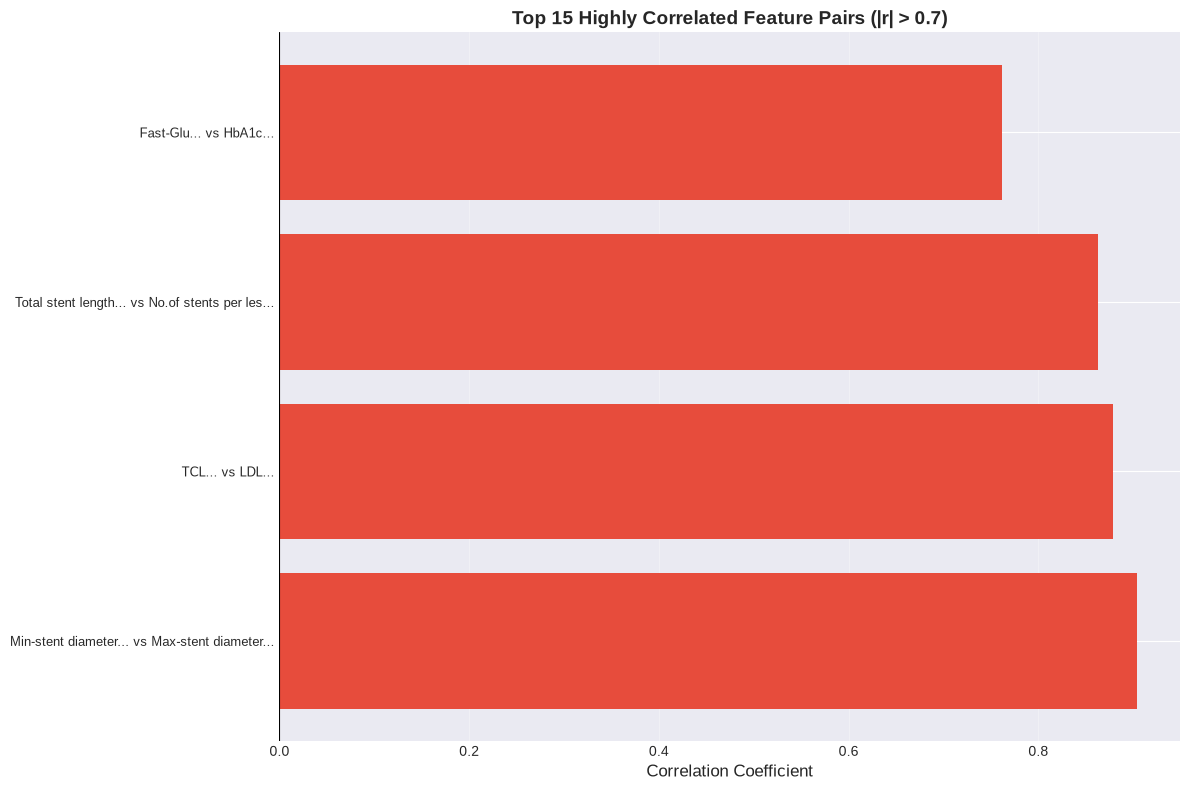


✓ Visualization saved: plots/12_multicollinearity.png


In [367]:
# Multicollinearity analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("MULTICOLLINEARITY ANALYSIS")
    print("=" * 80)

    # Calculate correlation matrix for continuous variables
    corr_matrix = df[continuous_cols].corr()

    # Find highly correlated pairs (excluding diagonal and duplicates)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:  # Threshold for high correlation
                high_corr_pairs.append(
                    {
                        "Feature 1": corr_matrix.columns[i],
                        "Feature 2": corr_matrix.columns[j],
                        "Correlation": corr_val,
                    }
                )

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
            "Correlation", key=abs, ascending=False
        )
        print(
            f"\n⚠ Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.7):"
        )
        print("\nTop 20 highly correlated pairs:")
        display(high_corr_df.head(20))

        # Visualize top correlations
        if len(high_corr_pairs) > 0:
            top_pairs = high_corr_df.head(15)
            fig, ax = plt.subplots(figsize=(12, 8))
            y_pos = np.arange(len(top_pairs))
            colors = [
                "#e74c3c" if x > 0 else "#3498db" for x in top_pairs["Correlation"]
            ]
            ax.barh(y_pos, top_pairs["Correlation"], color=colors)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(
                [
                    f"{row['Feature 1'][:20]}... vs {row['Feature 2'][:20]}..."
                    for _, row in top_pairs.iterrows()
                ],
                fontsize=9,
            )
            ax.set_xlabel("Correlation Coefficient", fontsize=12)
            ax.set_title(
                "Top 15 Highly Correlated Feature Pairs (|r| > 0.7)",
                fontsize=14,
                fontweight="bold",
            )
            ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
            ax.grid(True, alpha=0.3, axis="x")
            plt.tight_layout()
            plt.savefig(
                "../data/result/eda/plots/12_multicollinearity.png",
                dpi=300,
                bbox_inches="tight",
            )
            plt.show()
            print("\n✓ Visualization saved: plots/12_multicollinearity.png")
    else:
        print("\n✓ No highly correlated feature pairs found (|r| > 0.7)")
        print("  This suggests low multicollinearity, which is good for modeling.")

### 16.5 Distribution Shape Analysis

Understanding the shape of distributions (skewness and kurtosis) helps determine if transformations are needed for modeling.


DISTRIBUTION SHAPE ANALYSIS

Distribution Shape Statistics (Top 20 by absolute skewness):


,Feature,Skewness,Kurtosis,Abs_Skewness,Interpretation_Skew,Interpretation_Kurt
14,Cre,7.484056,161.335262,7.484056,Highly Skewed,Heavy Tailed
10,CaI,2.834164,9.432386,2.834164,Highly Skewed,Heavy Tailed
16,CKD5,2.617650,7.507913,2.617650,Highly Skewed,Heavy Tailed
21,Fast-Glu,2.417145,7.838604,2.417145,Highly Skewed,Heavy Tailed
1,Time since stent implantation,-2.359276,13.211717,2.359276,Highly Skewed,Heavy Tailed
20,TG,2.134846,8.837294,2.134846,Highly Skewed,Heavy Tailed
7,No.of stents per lesion,2.131825,4.700423,2.131825,Highly Skewed,Heavy Tailed
5,Total stent length,1.737190,4.154201,1.737190,Highly Skewed,Heavy Tailed
23,Fiberinogen,1.621689,5.653460,1.621689,Highly Skewed,Heavy Tailed
9,LVEF,-1.482588,7.416341,1.482588,Highly Skewed,Heavy Tailed



⚠ 14 features are highly skewed (|skewness| > 1)
   Consider log transformation or other normalization techniques.


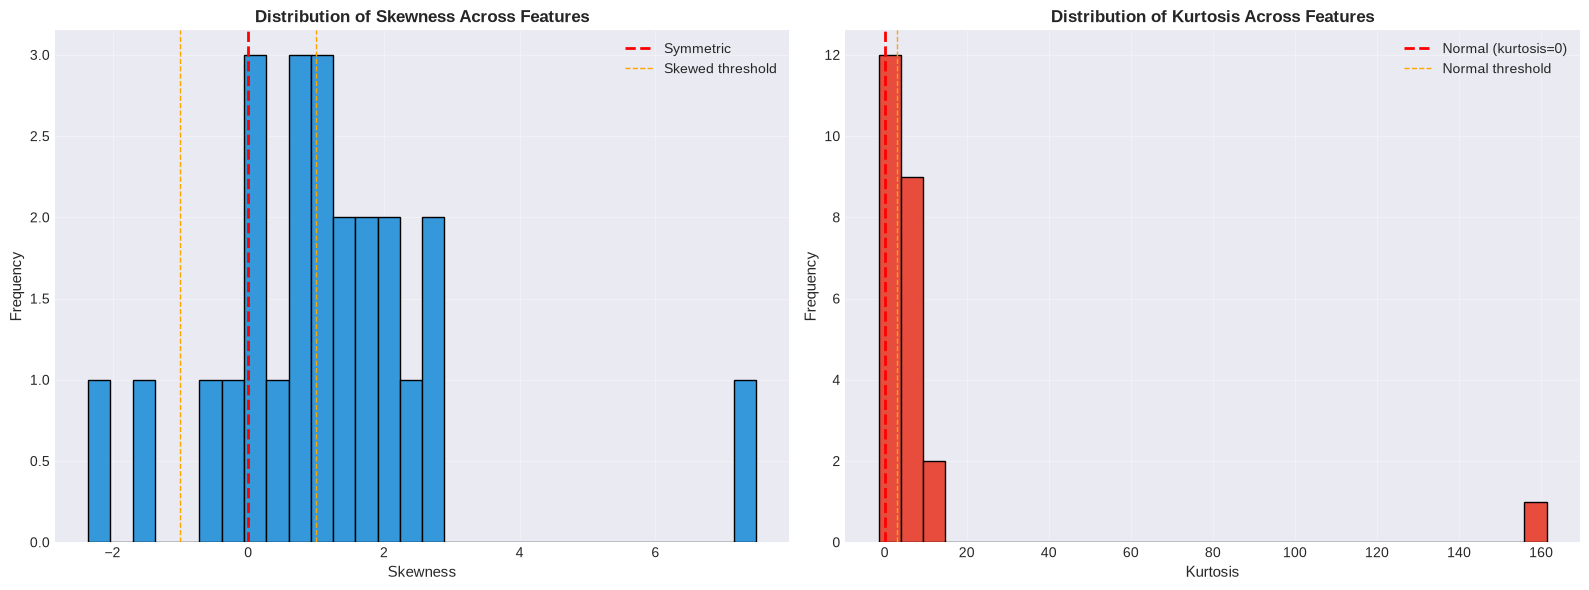


✓ Visualization saved: plots/13_distribution_shape.png


In [368]:
# Distribution shape analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("DISTRIBUTION SHAPE ANALYSIS")
    print("=" * 80)

    from scipy.stats import skew, kurtosis

    shape_stats = []
    for col in continuous_cols:
        data = df[col].dropna()
        if len(data) > 3:
            skewness = skew(data)
            kurt = kurtosis(data)
            shape_stats.append(
                {
                    "Feature": col,
                    "Skewness": skewness,
                    "Kurtosis": kurt,
                    "Abs_Skewness": abs(skewness),
                    "Interpretation_Skew": "Highly Skewed"
                    if abs(skewness) > 1
                    else "Moderately Skewed"
                    if abs(skewness) > 0.5
                    else "Symmetric",
                    "Interpretation_Kurt": "Heavy Tailed"
                    if kurt > 3
                    else "Light Tailed"
                    if kurt < 0
                    else "Normal",
                }
            )

    if shape_stats:
        dist_shape_df = pd.DataFrame(shape_stats).sort_values(
            "Abs_Skewness", ascending=False
        )
        print("\nDistribution Shape Statistics (Top 20 by absolute skewness):")
        display(dist_shape_df.head(20))

        # Summary
        highly_skewed = dist_shape_df[dist_shape_df["Abs_Skewness"] > 1]
        if len(highly_skewed) > 0:
            print(
                f"\n⚠ {len(highly_skewed)} features are highly skewed (|skewness| > 1)"
            )
            print("   Consider log transformation or other normalization techniques.")

        # Visualize skewness distribution
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        axes[0].hist(dist_shape_df["Skewness"], bins=30, color="#3498db", edgecolor="black")
        axes[0].axvline(
            x=0, color="red", linestyle="--", linewidth=2, label="Symmetric"
        )
        axes[0].axvline(
            x=1, color="orange", linestyle="--", linewidth=1, label="Skewed threshold"
        )
        axes[0].axvline(x=-1, color="orange", linestyle="--", linewidth=1)
        axes[0].set_title(
            "Distribution of Skewness Across Features", fontsize=12, fontweight="bold"
        )
        axes[0].set_xlabel("Skewness", fontsize=11)
        axes[0].set_ylabel("Frequency", fontsize=11)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].hist(dist_shape_df["Kurtosis"], bins=30, color="#e74c3c", edgecolor="black")
        axes[1].axvline(
            x=0, color="red", linestyle="--", linewidth=2, label="Normal (kurtosis=0)"
        )
        axes[1].axvline(
            x=3, color="orange", linestyle="--", linewidth=1, label="Normal threshold"
        )
        axes[1].set_title(
            "Distribution of Kurtosis Across Features", fontsize=12, fontweight="bold"
        )
        axes[1].set_xlabel("Kurtosis", fontsize=11)
        axes[1].set_ylabel("Frequency", fontsize=11)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            "../data/result/eda/plots/13_distribution_shape.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        print("\n✓ Visualization saved: plots/13_distribution_shape.png")

## 17. Final Summary and Recommendations

Based on all analyses performed, here are the final recommendations for data preprocessing and modeling.


In [369]:
print("=" * 80)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

recommendations = []

# Data quality recommendations
if "missing_df" in locals() and len(missing_df) > 0:
    high_missing = missing_df[missing_df["Missing Percentage"] > 20]
    if len(high_missing) > 0:
        recommendations.append(
            f"⚠ Consider removing or imputing {len(high_missing)} features with >20% missing values"
        )
    recommendations.append(
        "✓ Use appropriate imputation strategies (mean/median for continuous, mode for categorical)"
    )

# Feature engineering recommendations
if "correlations" in locals() and len(correlations) > 0:
    weak_corr = correlations[abs(correlations) < 0.1]
    if len(weak_corr) > 0:
        recommendations.append(
            f"⚠ {len(weak_corr)} features show very weak correlation (<0.1) - consider feature engineering or removal"
        )

# Transformation recommendations
if "shape_df" in locals():
    highly_skewed = (
        shape_df[shape_df["Abs_Skewness"] > 1] if "shape_df" in locals() else []
    )
    if len(highly_skewed) > 0:
        recommendations.append(
            f"⚠ {len(highly_skewed)} features are highly skewed - consider log/square root transformation"
        )

# Modeling recommendations
if "imbalance_ratio" in locals() and imbalance_ratio < 0.3:
    recommendations.append(
        "⚠ Use stratified sampling and consider SMOTE, class weights, or ensemble methods"
    )
    recommendations.append(
        "✓ Use appropriate metrics: AUC-ROC, Precision-Recall, F1-score (not just accuracy)"
    )

if "high_corr_pairs" in locals() and len(high_corr_pairs) > 0:
    recommendations.append(
        f"⚠ {len(high_corr_pairs)} highly correlated feature pairs detected - consider feature selection or PCA"
    )

recommendations.append(
    "✓ Use cross-validation with stratification to maintain class distribution"
)
recommendations.append(
    "✓ Consider feature selection techniques (mutual information, recursive feature elimination)"
)

print("\nRecommendations for Data Preprocessing and Modeling:")
for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

print("\n" + "=" * 80)
print("EDA COMPLETE - All analyses finished!")
print("=" * 80)
print("\nTotal visualizations generated: 13")
print("Total summary files: 4")
print("\nAll outputs saved to '../data/result/eda/plots/' directory")

FINAL SUMMARY AND RECOMMENDATIONS


KeyError: 'Abs_Skewness'